# Twelve findings, fifty-eight labels, four thousand reports

A knee MRI study here has to be given twelve probabilities — anterior cruciate and medial
collateral ligament injury, medial and lateral meniscal tear, osteoarthritis in each of
the three compartments, effusion, synovitis, Baker's cyst, bone contusion, fracture — and
the score is the unweighted mean of the twelve ROC AUCs.

The decisive fact about this dataset is not in the images. It is in `train.csv`:

| | studies | carry the twelve labels | carry a radiology report |
|---|---|---|---|
| train | 4 407 | **58** | 4 407 |
| test | — | — | **none — there is no `Report` column** |

Fifty-eight labelled studies cannot train an imaging model, and the reports that could
supply the missing four thousand are unavailable at prediction time. So the pipeline is
forced into one shape: **read the reports into targets, fit a pure imaging model against
them, and throw the text away.** Everything downstream — which slices to decode, how large
to make them, which encoder to adapt — is bounded by how well that first step is done.

This notebook is organised in the order the decisions constrain each other.

1. What the score rewards, and what that removes from the design.
2. Where the targets come from — a nine-language report reader, and the two ways to tell
   whether it works when only 58 studies can check it.
3. What the scanner recorded — recovering the acquisition protocol from DICOM headers.
4. Geometry — slice order, physical scale, and which knee was scanned.
5. Reading the pixels once.
6. Turning six views into twelve decisions.
7. Validating without fooling yourself.
8. Three arms, combined the only way the metric permits.

Every analytical number below is computed by the cell above it. Official Kaggle results in
the scorecard are explicitly labelled as external leaderboard evidence.

> **Highest verified public score: 0.894.**  Version 12 first moved beyond the
> public 0.891 Pilkwang anchor by changing only Fracture study pooling from a mean
> to maximum evidence across windows.  Version 14 then added a cross-fitted,
> target-selective rank contribution from an independently trained four-fold bundle.
> Both numbers below are completed official Kaggle public scores, not local estimates.
> Later risk-controlled variants are still labelled pending until their hidden reruns finish.

| reproducible public run | score | inference change |
|---|---:|---|
| Pilkwang V15 anchor | 0.891 | original public 20-member ensemble |
| This notebook V12 | **0.893** | target-wise Fracture max pooling |
| This notebook V14 | **0.894** | Fracture max + OOF-selected target-wise rank blend |
| verified gain over anchor | **+0.003** | completed Kaggle score evidence |

At the 9 August 2026 checkpoint, Kaggle's public Code listing sorted by score placed
this notebook first for the competition.  The notebook below keeps the external
leaderboard evidence separate from every validation result it computes itself.

If this evidence-first walkthrough saves you time, an upvote helps other competitors
find the reproducible result.


## 1. What the score rewards

$$\text{Score} \;=\; \frac{1}{12}\sum_{i=0}^{11} \mathrm{AUC}_i$$

Three consequences follow directly, and each one removes a design choice rather than
adding one.

**Only order matters.** $\mathrm{AUC}_i$ is invariant under any strictly increasing map of
the scores for label $i$. Calibration is worth nothing here, and so is any fixed
threshold. It also settles how to combine models: averaging raw probabilities lets
whichever arm happens to be most confident dominate, while averaging *ranks* combines the
only information the metric reads. Every combination in §8 is a rank mean.

**Every label costs the same.** Write $M$ for the mean AUC a good model reaches. A label
left at chance contributes $0.5$ instead of roughly $M$, forfeiting

$$\frac{M-0.5}{12}$$

no matter how well the other eleven do. At $M=0.85$ that is $0.029$ — larger than the gap
between neighbouring places on a mature leaderboard. So a rare finding deserves *more*
attention than a common one, because a rare finding is where a model most easily ends up
at chance. That is why §2 spends its effort on the findings the reports mention least,
not on the ones they mention most.

**Prevalence drift is survivable; thresholds are not.** AUC is, in expectation, invariant
to the positive rate, and the data description warns that prevalence need not match across
the training, public and private sets. That would be fatal for an accuracy-like metric. It
is not fatal here — but it does mean one cut has to be named and watched. The report-derived
targets below are graded, not binary; to compute an AUC against them at all they are
binarised at their midpoint for validation only. That cut chooses epochs and arms. It never
reaches a submitted score.

## 2. Where the targets come from

Every training study carries the radiology report written when it was read, and the data
description invites deriving labels from it. The structural fact that decides how is in the
schemas rather than in the prose: `train.csv` has a `Report` column and `test.csv` does
not. Text is available when fitting and absent when predicting. That rules out a fusion
model with a text branch — at inference it would have nothing to read — and leaves the
reports doing two jobs:

1. supplying the training targets, and
2. saying how confidently each one could be read, which becomes a per-finding sample
   weight.

Both matter. A study whose report never mentions synovitis should pull on the synovitis
head far more weakly than one that names it, and a loss that cannot express that trains
every silence as a confident negative.

### Nine languages, one lexicon

The corpus is written in nine languages across three scripts. The extractor is built here
in-line rather than attached as a file, for two reasons: it runs over the whole corpus in
seconds, so there is nothing to save by precomputing; and a notebook that ships its own
labels cannot quietly train against a stale copy of them.

**No language is identified.** Every cue list below carries all nine at once and each
clause is tested against the union. Routing first would mean committing to a guess before
any evidence is read, and the cheap guess fails badly here — `la` is as common in Spanish
as in French, and whichever substring test runs first swallows both. Pooling costs little
in exchange: Greek and Cyrillic cues cannot collide with Latin-script ones at all, and
among the Latin-script languages the vocabulary of interest is close enough that a shared
cue is usually right. The price is paid in coverage instead — a phrasing no listed language
contributes stays unmatched — and coverage is the thing §2.2 measures.

**Normalise, then unwrap, then segment, then scope.** Case, diacritics and separators are
folded first, which also repairs a real codepoint problem: many Greek reports spell mu with
the MICRO SIGN `U+00B5` rather than `U+03BC`, and NFKD maps one onto the other. Then the
lines are unwrapped — see below — then split into clauses, with a heading line attached to
the value beneath it, because a report that reads `Fractures :` and then `Aucune.` states
one thing across two lines.

**Assertion, negation, hedge.** Negation is not an edge case here. For several findings
*most* mentions are negative, because a report lists what was checked and found intact.
Explicit normality counts as absence — *ligamentos cruzados y colaterales dentro de límites
normales* is evidence of absence, not absence of evidence — except where a tear or a high
grade is named in the same breath.

**Grade, do not threshold.** §1 established that only order is read. So a mention is scored
by its emphasis — trace, unqualified, marked — and never binarised.

In [1]:
"""Report -> twelve graded targets, in nine languages.

v2. Differences from the public lexicon are all coverage: the compartment scoping for
osteoarthritis, the pathology vocabulary for cartilage, an asserted-negative path for
findings a report explicitly clears, and a backoff for synovitis, which most reports
never name.
"""
from __future__ import annotations

import re
import unicodedata

TARGETS = [
    "ACL", "MCL", "Medial Meniscus", "Lateral Meniscus",
    "Medial OA", "Lateral OA", "PF OA", "Effusion",
    "Synovitis", "Baker's", "Contusion", "Fracture",
]

_PRE = str.maketrans({
    "ı": "i", "İ": "i", "I": "i", "ß": "ss", "đ": "d", "Đ": "d",
    "ø": "o", "Ø": "o", "æ": "ae", "Æ": "ae",
})


def normalize(text: str) -> str:
    if not isinstance(text, str):
        return ""
    text = text.translate(_PRE).lower()
    text = unicodedata.normalize("NFKD", text)
    text = "".join(ch for ch in text if not unicodedata.combining(ch))
    text = text.replace("­", "")
    text = re.sub(r"[_\-/\\]+", " ", text)
    text = re.sub(r"[ \t]+", " ", text)
    return text


_SENT_SPLIT = re.compile(r"(?<=[.;!?])\s+|\n+")


def unwrap(text: str) -> str:
    """Rejoin lines that a fixed-width layout broke mid-sentence.

    A large share of this corpus arrives hard-wrapped at some column, so a sentence is
    split across two lines with no punctuation at the break. Splitting on newlines then
    severs the finding from its anatomy - `... y parte de la raiz` / `meniscal posterior
    del menisco lateral con extrusion asociada` puts the tear in one clause and the
    meniscus in the next, and neither clause says anything on its own. A line that does
    not end in sentence punctuation is a continuation, not a statement.
    """
    if not isinstance(text, str):
        return ""
    out = []
    for line in text.split("\n"):
        s = line.strip()
        if out and out[-1] and not re.search(r"[.;:!?>*•]$", out[-1]) \
                and len(out[-1].split()) >= 4 and s and not s[:1].isupper():
            out[-1] = out[-1] + " " + s
        else:
            out.append(s)
    return "\n".join(out)


def clauses(text: str):
    """Split into clauses; attach `header:` lines to the value beneath them."""
    norm = normalize(unwrap(text) if FEATURES["unwrap"] else text)
    raw = [c.strip() for c in _SENT_SPLIT.split(norm) if c and c.strip()]
    merged = []
    for i, c in enumerate(raw):
        if c.endswith(":") and len(c.split()) <= 14 and i + 1 < len(raw):
            merged.append(c + " " + raw[i + 1])
        merged.append(c)
    out = []
    for c in merged:
        out.append(c)
        if len(c.split()) > 25:
            out.extend(p.strip() for p in c.split(",") if len(p.split()) > 2)
    return out


# Each rule below that is not obviously right is behind a flag, so that the notebook can
# turn it off and re-measure rather than assert that it helps.
FEATURES = {
    "unwrap": True,               # rejoin hard-wrapped lines before splitting
    "directional_negation": True,  # scope negation by direction instead of by clause
    "oa_inherit": True,            # unlocalised cartilage statements reach all three
    "graded_pathology": True,      # read numeric grades on a per-structure scale
    "synovitis_backoff": True,     # order the silent majority by inflammatory context
}


def _rx(*alts: str) -> re.Pattern:
    return re.compile("|".join(alts))


# --------------------------------------------------------------------------- #
# polarity
# --------------------------------------------------------------------------- #
# Negation is scoped by direction, not by clause. `Subchondral insufficiency fracture at
# the medial tibial plateau without articular surface collapse` contains a negator and
# asserts a fracture: `without` governs what follows it, and the fracture precedes it.
# Reading negation at clause scope turns that sentence into a denial - and it is the
# house style of one of the larger reporting sites here, so the error is systematic
# rather than occasional.
PRE_NEG = _rx(
    r"\bno\b", r"\bnot\b", r"\bwithout\b", r"\bnegative for\b", r"\babsence\b",
    r"\bno evidence\b", r"\bfree of\b", r"\bnone\b", r"\bneither\b", r"\bnor\b",
    r"\bsin\b", r"\bno hay\b", r"\bausencia\b", r"\bausentes?\b", r"\bno se\b",
    r"\bpas de\b", r"\bsans\b", r"\baucune?\b",
    r"\bgeen\b", r"\bzonder\b", r"\bniet\b",
    r"\bkeine?[nmrs]?\b", r"\bohne\b", r"\bnicht\b", r"\bkein\b",
    r"\bnema\b", r"\bbez\b", r"\bnisu\b", r"\bnije\b",
    r"\bδεν\b", r"\bχωρις\b", r"ουδεν", r"\bουτε\b",
    r"\bбез\b", r"\bне\b", r"липсва", r"\bняма\b",
)

# Turkish and a few Croatian forms put the negator at the end of the sentence, so these
# govern what precedes them instead.
POST_NEG = _rx(
    r"\byok\b", r"\byoktur\b", r"izlenmemekte", r"saptanmadi", r"\bdegil\b",
    r"gozlenmemekte", r"mevcut degil", r"eslik etmiyor", r"\bizlenmedi\b",
    r"izlenmemistir", r"saptanmamistir", r"gorulmemistir", r"\bnema znakova\b",
    r"bez znakova",
)

NEGATION = _rx(PRE_NEG.pattern, POST_NEG.pattern, r"\bunremarkable\b")

NEG_WINDOW = 90


def _negated(clause: str, start: int, end: int) -> bool:
    """True when a negation trigger governs the span [start, end) of this clause."""
    for m in PRE_NEG.finditer(clause):
        if m.end() <= start and start - m.end() <= NEG_WINDOW:
            # `... intact but with a tear` - a contrast conjunction closes the scope.
            if not re.search(r"\b(but|however|ancak|fakat|pero|maar|aber|no i|ali|"
                             r"ωστοσο|αλλα|но)\b", clause[m.end():start]):
                return True
    for m in POST_NEG.finditer(clause):
        if m.start() >= end and m.start() - end <= NEG_WINDOW:
            return True
    return False

NORMALITY = _rx(
    r"\bnormal", r"\bintact\b", r"\bpreserved\b", r"\bwithin normal limits\b",
    r"limites normales", r"\bconservad", r"\bintegr", r"\bnormales\b",
    r"\bdoga(l|ll)\b", r"korunmus", r"\bnormaldir\b", r"olagan",
    r"\buredn", r"\bocuvan", r"\bodrzan", r"\bintakt", r"\bprimjeren",
    r"\bodrzanog kontinuiteta", r"\bodržan",
    r"φυσιολογικ", r"ακεραι", r"δεν παρατηρουνται", r"δεν σημειωνονται",
    r"unauffallig", r"regelrecht", r"\bo\.?b\.?\b",
    r"нормал", r"запазен", r"съхранен", r"\bбез особености\b", r"интактн",
    r"\bgaaf\b", r"\bnormaal\b",
)

# "Negator + abnormality-noun" is how most of these languages assert normality:
# `sin alteraciones`, `ohne Auffalligkeiten`, `geen afwijkingen`, `bez osobitosti`.
# Read literally each one is a negation, so the old guard (`normality AND NOT negation`)
# threw every one of them away and left the structure looking unmentioned instead of
# explicitly clear. That matters to a rank metric: a ligament a radiologist looked at and
# called intact must rank below one the report never mentions, not equal to it.
NORMAL_PHRASE = _rx(
    r"\bsin alteracion", r"\bsin cambios\b", r"\bsin particularidad",
    r"\bsin hallazgos\b", r"\bsin lesion", r"\bsin signos de (rotura|lesion)",
    r"\bcontinu[oa]s?\b", r"\bcontinuidad conservada\b",
    r"\bno abnormalit", r"\bno significant abnormalit", r"\bunremarkable\b",
    r"\bno evidence of (tear|injury|abnormalit)",
    r"\bohne auffalligkeit", r"\bkein nachweis\b", r"\bohne befund\b",
    r"\bgeen afwijking", r"\bzonder afwijking",
    r"\bsans anomalie", r"\bpas d[e']anomalie",
    r"\bbez osobitosti\b", r"\bbez znakova (rupture|lezije)\b",
    r"\bbez patoloskih\b",
    r"χωρις αλλοιωσ", r"χωρις παθολογ", r"δεν παρατηρουνται (αξιολογα|παθολογ)",
    r"\bбез особености\b", r"\bбез патологич", r"\bбез данни за\b",
    r"\bozel bir ozellik yok", r"\bpatolojik bulgu (yok|izlenmemis)",
)

UNCERTAIN = _rx(
    r"\bpossible\b", r"\bprobable\b", r"\bsuspicious\b", r"\bsuspected?\b",
    r"cannot (be )?exclude", r"\bmay\b", r"\bquestionable\b", r"\bequivocal\b",
    r"\br/o\b", r"\bdd\b", r"\blikely\b", r"\bsuggest", r"\bcompatible with\b",
    r"\bposible\b", r"sin criterios categoricos", r"\bdudos", r"\bsugier",
    r"\bmuhtemel\b", r"\bolasi\b", r"\bsupheli\b", r"\bizlenim", r"\bdusundur",
    r"\bmoguce\b", r"\bvjerojatno\b", r"\bsumnja\b", r"\bmoze odgovarati\b",
    r"πιθαν", r"υποπτ",
    r"\bmoglich", r"\bverdachtig", r"\bfraglich", r"\bv\.?a\.?\b", r"\bwohl\b",
    r"\bвъзможно\b", r"\bвероятно\b", r"суспект",
    r"\bmogelijk\b", r"\bverdacht\b",
)

### 2.1 Four rules that are not obvious

Most of a lexicon is vocabulary, and vocabulary is dull work that pays. Four rules are not
vocabulary, and each of them fixes an error that a term list cannot reach. All four are
behind flags in `FEATURES`, and §2.2 turns them off one at a time and re-measures.

**Unwrap before splitting.** A large share of these reports arrive hard-wrapped at a fixed
column, so a sentence is broken across two lines with no punctuation at the break.
Splitting on newlines then severs a finding from its anatomy:

> `Rotura compleja degenerativa del cuerno anterior, cuerpo, cuerno posterior y parte de la raíz`
> `meniscal posterior del menisco lateral con extrusión asociada.`

The first line says *tear* and names no structure; the second names the lateral meniscus
and says nothing about a tear. Neither clause carries a finding on its own, and the study
comes out silent on a meniscus that the report describes as complexly torn. A line that
does not end in sentence punctuation is a continuation, not a statement.

**Scope negation by direction, and anchor it on the pathology word.** Read at clause scope,

> `Subchondral insufficiency fracture at the medial tibial plateau without articular surface collapse.`

is a denial: it contains *without*. It is in fact an assertion — *without* governs what
follows it, and the fracture precedes it. This is the house style of one of the larger
reporting sites in this corpus, so the error is systematic rather than occasional, and it
falls on `Fracture`, one of the rarest targets. Direction alone is not enough either. In

> `Medial meniscus is not torn.`

the negator stands *after* the noun and before the verb, so scoping the test from the
anatomy match reads the sentence as an assertion. The negator governs the finding, so the
test is anchored on the pathology word — *torn* — not on *meniscus*.

**Let an unlocalised cartilage statement reach all three compartments.** Osteoarthritis is
rarely written as "osteoarthritis". It is written as cartilage loss, chondrosis, a
chondromalacia grade, joint space narrowing, or osteophytes — and often without naming a
compartment at all. `Tricompartmental osteoarthritis`, `gonarthrose`, `Incipient OA of all
three compartmens` are the house styles, not `chondropathy of the medial femorotibial
compartment`. A rule that requires a compartment phrase before it will fire leaves three
quarters of the corpus silent on the three OA targets. So a cartilage statement is
attributed by what else its clause names — *medial* next to a tibiofemoral structure sends
it to the medial compartment, *patella* or *trochlea* to the patellofemoral one — and a
statement that localises to nothing counts for all three at a discount, unless that
compartment was separately and explicitly cleared.

**Read numeric grades on the right scale.** A grade is the most precise thing a knee report
says, and it means opposite things in different places. Grade 3 of a *meniscus* is signal
reaching the articular surface, which is a tear by definition; grades 1 and 2 are
intrasubstance change that is not. A *ligament* runs the other way — grade 1 is a stretch,
grade 2 a partial tear. Folding both into one pathology vocabulary scores a degenerate
meniscus like a torn one and throws away the ordering the metric is built on.

In [2]:
# --------------------------------------------------------------------------- #
# pathology vocabulary
# --------------------------------------------------------------------------- #
TEAR = _rx(
    r"\btear", r"\btorn\b", r"\brupture", r"\bdisruption\b", r"discontinuit",
    r"\bavuls", r"\bmacerat", r"\bbuckethandle\b", r"bucket handle",
    r"\brotura\b", r"\broturas\b", r"\bruptura", r"\bdesgarro", r"\broto\b",
    r"\bdechirure", r"\bdechire",
    r"\bscheur", r"\bruptuur", r"gescheurd",
    r"\briss\b", r"einriss", r"\bruptur", r"zerreiss", r"\blasion", r"\bausriss",
    r"\byirtik", r"\byirtig", r"\bkopma\b", r"butunluk kaybi", r"\brupturu\b",
    r"devamsizlik", r"\brupture\b", r"\bdevamliligi secilememis",
    r"\bpuknuce", r"\bprekid\b", r"\bpukotin", r"\bruptur",
    r"ρηξη", r"ρηξις", r"ρηγμα", r"ασυνεχεια",
    r"руптура", r"разкъсв", r"разрив", r"скъсв", r"\bлезия\b",
)

DEGEN = _rx(
    r"degenerat", r"\bmucoid\b", r"\bmyxoid\b", r"\bfray", r"\bfissur",
    r"dejeneratif", r"\bmukoid\b", r"degenerativn", r"εκφυλ", r"дегенерат",
    r"\bμυξοειδ", r"\bμυξωδ", r"\bmeniskopat", r"\bmeniscopath",
    r"\bmuco ?ide\b", r"aufgefasert", r"\bdejenerasyon\b",
)

INJURY = _rx(
    r"\binjur", r"\bsprain", r"\blesion", r"\blasion", r"\bedema\b", r"\boedema\b",
    r"\bodem\b", r"\bedem\b", r"\bοιδημα", r"\bодем", r"\bедем", r"\bstrain\b",
    r"\bhigh signal\b", r"\bsignal alteration\b", r"\bhiperintens", r"\bhyperintens",
    r"aumento de senal", r"alteracion de senal", r"cambio de senal",
    r"\bsignalanhebung", r"\bsignalalteration", r"verhoogd signaal", r"sinyal artis",
    r"αυξημενο σημα", r"повишен сигнал", r"\besguince\b",
    r"\bthicken", r"\bzadebljanje\b", r"\bverdikking\b", r"\bdistenzij",
    r"\blaksite\b", r"\blaxity\b", r"\bpartial\b", r"\bparcijaln", r"\bparcial",
    r"\bpartiel", r"\bpartiell",
)

# A numeric grade is the most precise thing a knee report says, and it means different
# things in different places: grade 3 of a meniscus is a tear by definition, grade 1 or 2
# is intrasubstance signal that never reaches the surface and is not one. A ligament runs
# the other way round - grade 1 is a stretch, grade 2 a partial tear. So the grade is
# read as a number and interpreted per structure rather than folded into one pathology
# vocabulary.
_GRADE_RX = re.compile(
    r"(?:grade|grad|grado|grau|derece|stupnja|stupanj|βαθμ|степен|icrs|outerbridge)"
    r"[\s:]*(?:grade\s*)?([1-4]|iv|iii|ii|i)\b"
)
_ROMAN = {"i": 1, "ii": 2, "iii": 3, "iv": 4}


def _grade_of(clause: str):
    """Highest numeric grade stated in a clause, or None."""
    best = None
    for m in _GRADE_RX.finditer(clause):
        v = m.group(1)
        n = _ROMAN.get(v, None) if not v.isdigit() else int(v)
        if n is not None and (best is None or n > best):
            best = n
    return best

# --------------------------------------------------------------------------- #
# anatomy
# --------------------------------------------------------------------------- #
ANAT = {
    "ACL": _rx(
        r"anterior cruciate", r"\bacl\b",
        r"cruzado anterior", r"\blca\b",
        r"croise anterieur",
        r"voorste kruisband", r"\bvkb\b",
        r"vorderes kreuzband", r"vorderen kreuzband", r"vordere kreuzband",
        r"on capraz", r"\bocb\b", r"anterior capraz",
        r"prednji krizni", r"prednjeg krizn",
        r"προσθι[οα][^ ]* χιαστ", r"προσθιου χιαστου", r"χιαστο[^ ]* συνδεσμ",
        r"\bχιαστ\w*",
        r"предна кръстна", r"предната кръстна", r"предна кръста",
        r"cruciate ligaments", r"ligamentos cruzados", r"ligaments croises",
        r"kruisbanden", r"kreuzbander", r"capraz baglar", r"krizn[a-z]* ligament[a-z]*",
        r"χιαστοι συνδεσμ", r"χιαστων συνδεσμ", r"кръстните връзки", r"кръстни връзки",
    ),
    "MCL": _rx(
        r"medial collateral", r"\bmcl\b", r"tibial collateral",
        r"colateral medial", r"colateral interno", r"\blcm\b",
        r"collateral medial", r"collateral interne",
        r"mediale collaterale", r"binnenband", r"\b(mediale|laterale) banden\b",
        r"\bcollaterale banden\b",
        r"innenband", r"mediales? kollateral",
        r"\bic yan bag", r"medial kollateral", r"\biyb\b", r"medyal kollateral",
        r"medijalni kolateraln", r"medijalnog kolateraln",
        r"εσω πλαγι", r"εσωτερικο πλαγι", r"\bπλαγι\w* συνδεσμ", r"\bπλαγιοι\b",
        r"медиален колатерал", r"вътрешна странична", r"\bколатерал\w*",
        r"\bcolaterales\b", r"\bcollateraux\b", r"\bcollateralen\b", r"\bkolateralni\b",
        r"collateral ligaments", r"ligamentos colaterales", r"ligaments collateraux",
        r"collaterale banden", r"kollateralbander", r"seitenbander", r"yan baglar",
        r"kolateraln[a-z]* ligament[a-z]*", r"πλαγιοι συνδεσμ", r"πλαγιων συνδεσμ",
        r"колатерални връзки", r"страничните връзки",
    ),
    "Medial Meniscus": _rx(
        r"medial meniscus", r"\bmm\b(?= tear)", r"medial menisc",
        r"menisco medial", r"menisco interno",
        r"menisque medial", r"menisque interne",
        r"mediale meniscus", r"binnenmeniscus",
        r"innenmeniskus", r"medialen? meniskus", r"innenmeniskushinterhorn",
        r"medyal menisk", r"\bic menisk",
        r"medijalni meniskus", r"medijalnog meniskusa", r"medijalnom meniskusu",
        r"medijaln\w* menisk\w*", r"\bmedijalnog meniska\b", r"medijalni menisk",
        r"εσω μηνισκ", r"μηνισκ[^ ]* του εσω", r"εσω διαμερισμα[^.]{0,40}μηνισκ",
        r"медиалния менискус", r"медиален менискус", r"вътрешния менискус",
        r"oba meniska", r"both menisci", r"ambos meniscos", r"beide menisci",
        r"her iki menisku", r"amfoteroi\w* mhnisk", r"αμφοτερ\w* μηνισκ",
        r"двата менискуса", r"medial (and|&) lateral menisc",
    ),
    "Lateral Meniscus": _rx(
        r"lateral meniscus", r"lateral menisc",
        r"menisco lateral", r"menisco externo",
        r"menisque lateral", r"menisque externe",
        r"laterale meniscus", r"buitenmeniscus",
        r"aussenmeniskus", r"lateralen? meniskus", r"aussenmeniskushinterhorn",
        r"lateral menisk", r"\bdis menisk",
        r"lateralni meniskus", r"lateralnog meniskusa", r"lateralnom meniskusu",
        r"lateraln\w* menisk\w*", r"\blateralnog meniska\b",
        r"εξω μηνισκ", r"μηνισκ[^ ]* του εξω", r"εξω διαμερισμα[^.]{0,40}μηνισκ",
        r"латералния менискус", r"латерален менискус", r"външния менискус",
        r"oba meniska", r"both menisci", r"ambos meniscos", r"beide menisci",
        r"her iki menisku", r"αμφοτερ\w* μηνισκ",
        r"двата менискуса", r"medial (and|&) lateral menisc",
    ),
}

# Osteoarthritis is written as cartilage damage far more often than as a diagnosis.
OA_EVIDENCE = _rx(
    r"osteoarthrit", r"\barthros", r"\bgonarthros", r"\bosteoarthros",
    r"chondropath", r"chondromalac", r"condropat", r"condromalac", r"\bchondros",
    r"\bchondrosis\b", r"chondral (loss|defect|ulcer|thinning|injury|fissur|wear)",
    r"cartilage (loss|thinning|defect|fissur|wear|damage|heterogeneity|irregularit)",
    r"(loss|thinning|fissur|defect|ulcer|erosion|denudation) of[^.]{0,20}cartilage",
    r"articular cartilage[^.]{0,30}(loss|thin|fissur|defect|erosion|wear|irregular)",
    r"osteophyt", r"osteofit", r"osteofyt", r"osteofito", r"osteophyten", r"spurring",
    r"joint space narrowing", r"pinzamiento articular", r"reduced joint space",
    r"kikirdak kayb", r"kikirdak incelme", r"kondropati", r"kondral", r"kikirdak dejener",
    r"eklem aralig\w* daral", r"eklem mesafesi daral", r"kikirdak kalinlig\w* azal",
    r"kraakbeen", r"gonartrose", r"artrose", r"\bknorpel", r"arthrose", r"gonarthrose",
    r"hrskavic", r"hondromalac", r"artroz", r"osteoartrit", r"artrotsk", r"artrotick",
    r"\boa promjen", r"\boa\b", r"degenerativne promjene hrskav",
    r"χονδρ[^ ]*παθ", r"αρθριτ", r"αρθρωσ", r"οστεοφυτ", r"χονδρομαλακ",
    r"αρθρικου χονδρου", r"εξαλειψη του αρθρικου χονδρου", r"διαβρωση του αρθρικου χονδρ",
    r"λεπτυνση[^.]{0,30}χονδρ", r"φθορα[^.]{0,20}χονδρ",
    r"артроз", r"хондропат", r"остеофит", r"хрущял[^.]{0,40}(изтън|увред|дефект|липс)",
    r"изтъняване[^.]{0,30}хрущял", r"хондромалац",
    r"ulcera[s]? condral", r"cartilago[^.]{0,25}(perdida|adelgaz)",
    r"icrs grade", r"icrs\b", r"outerbridge", r"\bdenudation\b", r"denudacij",
    r"erozivne promjene", r"\berosion of[^.]{0,20}cartilage",
    r"kraakbeenlijden", r"kraakbeenverlies",
)

# --------------------------------------------------------------------------- #
# where in the joint a cartilage statement sits
# --------------------------------------------------------------------------- #
# Tibiofemoral structures. Used only inside a clause that already carries OA evidence,
# so bare "condyle" is safe here and would not be elsewhere.
TF_SITE = _rx(
    r"compartment", r"compartimento", r"compartiment", r"kompartman", r"kompartiment",
    r"kompartment", r"odjelj", r"διαμερισμα", r"компартм", r"\bотдел",
    r"femorotibial", r"tibiofemoral", r"femoro tibial", r"femorotibiaal",
    r"femorotibijaln", r"феморотибиал", r"\bft zglob", r"tibiofemoraln",
    r"condyle", r"condilo", r"kondyl", r"kondil", r"condyl", r"κονδυλ",
    r"кондил", r"\bplateau", r"\bplato\b", r"platillo", r"meseta", r"плато",
    r"tibiaplateau", r"tibijaln\w* plato", r"tibyal plato", r"tibia plato",
    r"κνημιαι", r"μηριαι", r"weightbearing", r"weightbaring", r"zona de carga",
    r"dragende deel", r"agirlik tasiyan", r"\bfemur\b", r"\btibia\b", r"\bfemoral\b",
    r"\btibial\b", r"\bfemura\b", r"\btibije\b", r"\bmesarthrio\b", r"μεσαρθριο",
)

# Patellofemoral structures.
PF_SITE = _rx(
    r"patellofemoral", r"femoropatellar", r"femoropatelar", r"patelofemoral",
    r"retropatellar", r"retrorotulian", r"trochlea", r"troclea", r"troklea",
    r"trochlear", r"trohlej", r"τροχιλ", r"\bpatella", r"\bpatellar", r"rotulian",
    r"\brotula\b", r"\bpatele\b", r"patellofemoraal", r"femoropatellair",
    r"επιγονατιδ", r"μηροεπιγονατιδ", r"пател", r"феморопател",
    r"anterior compartment", r"compartimento anterior", r"prednj\w* odjeljk",
    r"\bfp zglob", r"\bpf zglob", r"\bfaset", r"\bfacet", r"patellofemoraln",
)

SIDE_MEDIAL = _rx(
    r"\bmedial\w*", r"\bmedyal\w*", r"\bmedijaln\w*", r"\bmediaal\w*",
    r"\bmediale\w*", r"\binterno\b", r"\binterna\b", r"\binternos\b", r"\binterne\b",
    r"\binnen\w*", r"\bic\b", r"\bunutarnj\w*", r"\bεσω\w*", r"\bεσωτερικ\w*",
    r"\bмедиал\w*", r"\bвътреш\w*", r"\bbinnen\w*", r"\bmediaal\b", r"\bmediales?\b",
)
SIDE_LATERAL = _rx(
    r"\blateral\w*", r"\bexterno\b", r"\bexterna\b", r"\bexternos\b", r"\bexterne\b",
    r"\bdis\b", r"\blateraln\w*", r"\baussen\w*", r"\bbuiten\w*", r"\bεξω\w*",
    r"\bεξωτερικ\w*", r"\bлатерал\w*", r"\bвъншн\w*", r"\bvanjsk\w*",
)
SIDE_ANTERIOR = _rx(
    r"\banterior\w*", r"\bant\b", r"\bon\b", r"\bprednj\w*", r"\bvorder\w*",
    r"\bvoorste\b", r"\bπροσθι\w*", r"\bпредн\w*", r"\banteriyor\w*", r"\bavant\b",
    r"\banterieur\w*",
)

GLOBAL_OA = _rx(
    r"tri ?compartment", r"all three compartment", r"global(ised)? (oa|osteoarthrit)",
    r"\bgonarthros", r"\bgonartros", r"\bgonarthrose", r"\bgonartrose", r"gonartro",
    r"goanrtrot", r"gonartrot",
    r"osteoarthritis of the knee", r"artrosis (de |)(la )?rodilla", r"knee osteoarthrit",
    r"\bdiz osteoartrit", r"\bgonartroz", r"artroza koljena",
    r"οστεοαρθριτιδα", r"αρθριτιδα του γονατος", r"εκφυλιστικη οστεοαρθριτ",
    r"артроза на колянната", r"гонартроз",
    r"degenerative joint disease", r"\bdjd\b", r"three compartments",
    r"compartmens", r"compartments",
)

# --------------------------------------------------------------------------- #
# self-declaring findings
# --------------------------------------------------------------------------- #
DIRECT = {
    "Effusion": _rx(
        r"\beffusion", r"joint fluid", r"intra ?articular fluid", r"\bhydrops\b",
        r"\bhemarthros", r"\bhaemarthros",
        r"derrame articular", r"\bderrame\b", r"liquido articular", r"hemartrosis",
        r"epanchement",
        r"gewrichtsvocht", r"\bvocht\b", r"gewrichtseffusie", r"opzetting van suprapatell",
        r"gelenkerguss", r"\berguss\b", r"gelenksergu", r"gelenksflussigkeit",
        r"eklem\w* ic\w* sivi", r"efuzyon", r"eklem sivisi", r"eklem mesafesinde sivi",
        r"sivi (miktari|artisi|birikimi)", r"sivi artis", r"\bsivi\b[^.]{0,25}artmis",
        r"\bizljev", r"\bizliv", r"zglobn[^ ]* tekucin", r"\bhidrops\b",
        r"αρθρικ[^ ]* υγρ", r"υγρου ενδαρθρικα", r"ενδαρθρικ[^ ]* υγρ", r"ποσοτητα υγρου",
        r"ενδαρθρικ", r"αρθρικη συλλογη", r"υγρο στην αρθρωση", r"υγρου στην αρθρωση",
        r"συλλογη υγρου", r"ενθαρθρικ",
        r"ставен излив", r"излив", r"ставна течност", r"синовиална течност",
    ),
    "Synovitis": _rx(
        r"synovit", r"sinovit", r"synovial (thickening|proliferation|hypertroph)",
        r"thicken\w* synovial", r"hypertroph\w* of the synovium",
        r"synoviale? (verdikking|proliferatie)", r"verdikkingen van (het )?synovium",
        r"synovialitis", r"synovialis(verdickung|proliferation)", r"reizsynovial",
        r"sinovijalitis", r"sinovitis", r"zadebljanje sinovij", r"proliferacij\w* sinovij",
        r"sinovijaln\w* proliferacij",
        r"υμενιτιδα", r"συνοβιτιδα", r"υμενικ[^ ]* υπερτροφ", r"αρθρικου υμεν",
        r"παχυνση[^.]{0,20}υμεν", r"υμενα",
        r"синовит", r"синовиал[^ ]* (задебел|пролифер)",
        r"\bpannus\b", r"\bhoffit", r"sinovyal\w* (kalinlas|proliferas)",
        r"sinovyal hipertrof", r"\bartrit\b", r"\barthritis\b",
    ),
    "Baker's": _rx(
        r"baker", r"popliteal cyst", r"quiste popliteo", r"quistes popliteos",
        r"kyste poplite", r"popliteale? cyst", r"poplitealzyste", r"bakerzyste",
        r"popliteal kist", r"\bbakerova\b", r"poplitealn[^ ]* cist", r"popliteal\w* cist",
        r"κυστη baker", r"πολυχωρη συνοβιακη κυστη", r"κυστη του baker",
        r"συνοβιακη κυστη", r"κυστη τυπου baker",
        r"киста на бейкър", r"бейкърова киста", r"поплитеална киста", r"бекеров",
        r"gastrocnemio ?semimembranos", r"gastrocnemius semimembranosus burs",
    ),
    "Contusion": _rx(
        r"\bcontusion", r"bone bruise", r"bone marrow (o?edema|contusion)",
        r"marrow o?edema", r"\bkontuz", r"medular bone o?edema", r"osseous contusion",
        r"contusion osea", r"edema oseo", r"edema de medula osea", r"contusiones oseas",
        r"oedeme osseux", r"contusion osseuse",
        r"botcontusie", r"botoedeem", r"beenmergoedeem", r"botmergoedeem",
        r"knochenmarkodem", r"knochenodem", r"knochenmarksodem", r"kontusion",
        r"kemik kontuzyonu", r"kemik iligi odemi", r"kemik odemi", r"kemik iliginde odem",
        r"kontuzyonel kemik", r"kemik iligi odemleri",
        r"kostani edem", r"edem kosti", r"kontuzij", r"kostane srzi[^.]{0,20}edem",
        r"οστεομυελικ[^ ]* οιδημα", r"οστικο οιδημα", r"μυελικο οιδημα", r"οστικο μωλωπ",
        r"костномозъчен едем", r"костен едем", r"контузионен", r"костно мозъчен едем",
    ),
    "Fracture": _rx(
        r"\bfractur", r"\bfract\b",
        r"\bfractura", r"\bfracturas\b",
        r"\bfractuur", r"\bbreuk\b",
        r"\bfraktur", r"\bbruch\b",
        r"\bkirik\b", r"\bkirigi\b", r"\bkiri[kg]\w*",
        r"\bprijelom", r"impresijsk[^ ]* fraktur", r"impaktcij",
        r"καταγμα", r"καταγματ",
        r"фрактур", r"счупван", r"фисур",
        r"insufficiency fracture", r"stress fracture", r"avulsion fracture",
        r"subchondral fracture", r"subkondral kiri", r"impaction (fracture|injury)",
        r"osteochondral (fracture|impaction)", r"\bsegond\b", r"impactiefractuur",
        r"subchondrale impression", r"subchondraler? impress",
    ),
}

DECOY = {
    "Fracture": _rx(r"microfractur", r"\bfracture (risk|prophyla)"),
    "Baker's": _rx(r"meniscal cyst", r"quiste meniscal", r"parameniscal"),
}

PAIRED = {"ACL", "MCL", "Medial Meniscus", "Lateral Meniscus"}
OA_TARGETS = ["Medial OA", "Lateral OA", "PF OA"]

# --------------------------------------------------------------------------- #
# stems, for morphology the phrase lexicons cannot reach
# --------------------------------------------------------------------------- #
# A report that clears or tears both menisci in one breath - "normaal voorkomen
# menisci", "Normal medial and lateral menisci" - names neither side, so a
# side-qualified lexicon leaves both targets silent. The cruciates and collaterals
# already had their plural forms; the menisci were simply missed.
#
# It is only consulted when the clause names no side at all. Otherwise "tear of the
# medial meniscus, menisci otherwise intact" would fire the plural for the lateral side
# off a clause that is about the medial one.
PLURAL_MENISCI = _rx(
    r"\bmenisci\b", r"\bmeniscos\b", r"\bmenisques\b", r"\bmenisken\b",
    r"\bmeniskusi\b", r"\bmenisk\w*ler\b", r"\bμηνισκοι\b", r"\bμηνισκων\b",
    r"\bменискуси\b", r"\bменискусите\b", r"\bmenisci\w*\b",
)
ANY_SIDE = _rx(SIDE_MEDIAL.pattern, SIDE_LATERAL.pattern)

STEM_MENISCUS = _rx(r"menisc\w*", r"menisk\w*", r"μηνισκ\w*", r"мениск\w*")
STEM_CRUCIATE = _rx(r"cruciate", r"cruzado", r"croise", r"kruisband", r"kreuzband",
                    r"capraz bag\w*", r"krizn\w*", r"χιαστ\w*", r"кръстн\w*",
                    r"\bacl\b", r"\blca\b", r"\bvkb\b", r"\bocb\b", r"\bacb\b")
STEM_COLLATERAL = _rx(r"collateral\w*", r"colateral\w*", r"kollateral\w*",
                      r"collaterale\w*", r"kolateraln\w*", r"yan bag\w*",
                      r"πλαγι\w*", r"колатерал\w*", r"странич\w*",
                      r"innenband\w*", r"binnenband\w*", r"\bmcl\b", r"\blcm\b",
                      r"\biyb\b")

STEM_FRACTURE = _rx(r"fractur\w*", r"fraktur\w*", r"fractuur\w*", r"\bfract\b",
                    r"kiri[kgğ]\w*", r"prijelom\w*", r"lom kosti", r"\bbreuk\w*",
                    r"\bbruch\w*", r"καταγμα\w*", r"καταγματ\w*", r"фрактур\w*",
                    r"счупван\w*", r"fisur\w* (osea|oseas|kost)", r"fissur\w* kost")

# Decoys that steal a cruciate / collateral stem match for the wrong ligament.
POSTERIOR_ONLY = _rx(r"\bpcl\b", r"\blcp\b", r"\bhkb\b", r"\bacb\b",
                     r"posterior cruciate", r"cruzado posterior", r"croise posterieur",
                     r"achterste kruisband", r"hinteres kreuzband", r"arka capraz",
                     r"straznji krizn", r"οπισθι[οα]\w* χιαστ", r"задна кръстн",
                     r"задната кръстн")
LATERAL_COLL_ONLY = _rx(r"\blcl\b", r"\bfcl\b", r"lateral collateral",
                        r"fibular collateral", r"colateral lateral", r"colateral externo",
                        r"buitenband", r"aussenband", r"dis yan bag",
                        r"lateralni kolateraln", r"εξω πλαγι", r"латерален колатерал")

In [3]:
def _near(clause: str, stem_rx: re.Pattern, qual_rx: re.Pattern, window: int = 55):
    for m in stem_rx.finditer(clause):
        lo = max(0, m.start() - window)
        hi = min(len(clause), m.end() + window)
        if qual_rx.search(clause[lo:hi]):
            return True
    return False


STEM_RULES = {
    "ACL": (STEM_CRUCIATE, SIDE_ANTERIOR),
    "MCL": (STEM_COLLATERAL, SIDE_MEDIAL),
    "Medial Meniscus": (STEM_MENISCUS, SIDE_MEDIAL),
    "Lateral Meniscus": (STEM_MENISCUS, SIDE_LATERAL),
}


class _Matcher:
    def __init__(self, phrase_rx, stem=None, side=None, window=55):
        self.phrase_rx = phrase_rx
        self.stem = stem
        self.side = side
        self.window = window

    def search(self, clause):
        m = self.phrase_rx.search(clause)
        if m is not None:
            return m
        if self.stem is not None and _near(clause, self.stem, self.side, self.window):
            return self.stem.search(clause)
        return None


ANAT_MATCH = {t: _Matcher(ANAT[t], *STEM_RULES[t]) for t in PAIRED}
DIRECT_MATCH = {
    t: _Matcher(_rx(rx.pattern, STEM_FRACTURE.pattern) if t == "Fracture" else rx)
    for t, rx in DIRECT.items()
}

# --------------------------------------------------------------------------- #
# severity
# --------------------------------------------------------------------------- #
SEV_LOW = _rx(
    r"\bsmall\b", r"\bminimal\b", r"\btrace\b", r"\bmild\b", r"\bslight\b",
    r"\btiny\b", r"\bscant\b", r"\bdiscrete\b", r"\blow ?grade\b", r"\bincipient\b",
    r"\bleve\b", r"\bminim", r"\bpeque", r"\bfina\b", r"\bfino\b", r"\bligero\b", r"\bescaso\b", r"\bdiscreto\b",
    r"\bhafif\b", r"\baz miktarda\b", r"\bsilik\b",
    r"\bmanj\w*", r"\bblago\b", r"\bdiskretn", r"\bmalo\b", r"\bpocetn",
    r"\bgering", r"\bdiskret", r"\bkleine?r?\b", r"\bwenig\b", r"\bzarte?\b",
    r"\bbeperkte?\b", r"\bgeringe\b", r"\bweinig\b", r"\blichte?\b", r"\blicht\b",
    r"\bηπι", r"\bμικρ", r"\bελαχιστ", r"\bαρχομεν",
    r"\bминимал", r"\bлек", r"\bмалк", r"\bнеголям",
)

SEV_HIGH = _rx(
    r"\blarge\b", r"\bmarked\b", r"\bmassive\b", r"\bsevere\b", r"\bextensive\b",
    r"\bmoderate\b", r"\bgross\b", r"\bsignificant\b", r"\babundant\b", r"\btense\b",
    r"\bcomplete\b", r"\bfull ?thickness\b", r"\bhigh ?grade\b", r"\badvanced\b",
    r"\bmoderad", r"\bimportante\b", r"\bsevera?\b", r"\bmarcad", r"\bcuantios",
    r"\bespesor total\b", r"\bcompleta?\b",
    r"\bbelirgin\b", r"\byaygin\b", r"\bileri\b", r"\bciddi\b", r"\bbol\b", r"\bkomplet",
    r"\bopsezan\b", r"\bveliki\b", r"\bizrazit", r"\bznacajn", r"\bumjeren",
    r"\buznapredoval", r"\bpotpun", r"\bkompleksn",
    r"\bausgepragt", r"\bdeutlich", r"\bmassiv", r"\bmassig", r"\bgross",
    r"\buitgebreid", r"\bgevorderd", r"\bveel\b", r"\bmatige?\b", r"\bvolledig",
    r"\bμετρι", r"\bμεγαλ", r"\bεκτεταμεν", r"\bευμεγεθ", r"\bσοβαρ", r"\bπληρη",
    r"\bголям", r"\bизразен", r"\bзначим", r"\bумерен", r"\bобилен", r"\bпълн",
)

GRADE_HIGH = re.compile(r"grade?[ao]?\s*(3|4|iii|iv)\b|icrs grade (iii|iv|3|4)|"
                        r"stupnja iv|stupnja iii|\bgrado (3|4)\b|\bgrad (3|4)\b|"
                        r"\bgrade (3|4)\b")

DEGENERATIVE_MARROW = _rx(
    r"subchondral", r"subcondral", r"subkondral", r"supkondraln", r"subchondraln",
    r"υποχονδρι", r"υπαρθρικ", r"субхондрал", r"subchondrale?", r"subartikuler",
    r"\bcyst", r"\bquist", r"\bzyste\b", r"\bcistic", r"reactive", r"reactivo",
    r"degenerative", r"degenerativ", r"reaktiv", r"\bcisti\b",
)

TRAUMA = _rx(
    r"\bbruise\b", r"\bcontusion", r"\bkontuz", r"\btrauma", r"\bimpaction\b",
    r"\bpivot shift\b", r"\bkissing\b", r"\bacute\b", r"\bagudo\b", r"\bakut",
    r"\bpivot kaymasi\b", r"\bcontusion osseuse\b", r"\bbone bruise\b",
    r"\bbotcontusie\b", r"\bконтузион", r"\bμωλωπ", r"\bkontuzij", r"\bimpaktcij",
    r"\bimpakcij", r"\bfall\b", r"\binjury\b", r"\bimpression\b",
)

# Effusion-adjacent inflammatory signs, used only when a report never names synovitis.
SYNOVIAL_PROXY = _rx(
    r"bursit", r"burzit", r"\bbursa\b[^.]{0,30}(fluid|distend|sivi|tekucin|opzetting)",
    r"suprapatellar (bursitis|effusion|recess)", r"suprapatellar bursa",
    r"suprapatellar bursada", r"suprapatelarno", r"suprapatellaire recessus",
    r"hoffa", r"hoffit", r"plica", r"plika", r"πλικα", r"fat pad[^.]{0,20}(edema|oedema)",
    r"kapsul", r"capsul", r"καψ", r"капсул", r"\bpannus\b", r"\bsinov", r"\bsynov",
)


def _polarity(clause: str, span=None) -> str:
    """positive / negative / uncertain for a term matched at `span` in this clause."""
    if UNCERTAIN.search(clause):
        return "uncertain"
    if span is None or not FEATURES["directional_negation"]:
        if NEGATION.search(clause):
            return "negative"
    elif _negated(clause, span[0], span[1]):
        return "negative"
    if NORMALITY.search(clause):
        # `meniscus normal` denies; `normal alignment ... full thickness tear` does not.
        if TEAR.search(clause) or GRADE_HIGH.search(clause):
            return "positive"
        return "negative"
    return "positive"


def _severity(clause: str) -> float:
    """How emphatic a clause is about the finding it asserts.

    A numeric grade is deliberately not read here. It belongs to whichever structure the
    grade was written for, and a clause that grades the cartilage while mentioning the
    effusion in passing - `PF arthrotic change with reduced joint space, a smaller
    effusion and grade IV chondromalacia` - would otherwise report a severe effusion.
    """
    high = SEV_HIGH.search(clause) is not None
    low = SEV_LOW.search(clause) is not None
    if high and not low:
        return 1.0
    if low and not high:
        return 0.45
    if high and low:
        return 0.8
    return 0.75


def _grade(n_pos, n_neg, n_unc, best):
    """Map counted evidence onto a score in (0, 1) and a confidence."""
    if n_pos or n_unc:
        score = min(0.97, 0.50 + 0.45 * best + 0.015 * min(n_pos, 3))
        conf = min(1.0, 0.55 + 0.15 * n_pos)
    elif n_neg:
        score = max(0.04, 0.20 - 0.04 * n_neg)
        conf = min(0.9, 0.45 + 0.12 * n_neg)
    else:
        score, conf = 0.28, 0.05
    return score, conf


def _paired_weight(clause: str, meniscus: bool) -> float:
    """How strongly one clause asserts damage to a meniscus or a cruciate/collateral.

    Ordered, not calibrated. What has to hold is that a tear outranks a graded lesion,
    that the grade is read on the right scale for the structure, and that intrasubstance
    degeneration lands below both - the annotator marks a torn meniscus and leaves a
    degenerate one, and a lexicon that scores the two alike throws that ordering away.
    """
    g = _grade_of(clause) if FEATURES["graded_pathology"] else None
    tear = TEAR.search(clause) is not None
    if meniscus:
        if tear:
            base = 1.0
        elif g is not None:
            base = 0.95 if g >= 3 else 0.30
        elif DEGEN.search(clause):
            base = 0.35
        else:
            base = 0.45
    else:
        if tear:
            base = 1.0
        elif g is not None:
            base = 0.85 if g >= 2 else 0.30
        elif DEGEN.search(clause):
            base = 0.40
        else:
            base = 0.55
    if SEV_HIGH.search(clause) and not SEV_LOW.search(clause):
        base = min(1.0, base * 1.2)
    elif SEV_LOW.search(clause) and not SEV_HIGH.search(clause):
        base *= 0.7
    return base


def _score_paired(cls, tgt):
    """Evidence for one of the four side-specific ligament / meniscus targets."""
    anat_rx = ANAT_MATCH[tgt]
    path_rx = _rx(TEAR.pattern, DEGEN.pattern, INJURY.pattern)
    meniscus = "Meniscus" in tgt
    n_pos = n_neg = n_unc = 0
    best = 0.0
    for c in cls:
        hit = anat_rx.search(c)
        if hit is None and meniscus and PLURAL_MENISCI.search(c) \
                and not ANY_SIDE.search(c):
            hit = PLURAL_MENISCI.search(c)
        if hit is None:
            continue
        # Anchor the negation test on the pathology word, not on the anatomy word.
        # `Medial meniscus is not torn` negates the tear, and the negator stands after
        # the noun: scoping from the noun would read the sentence as an assertion.
        pm = path_rx.search(c)
        if pm is None and _grade_of(c) is None:
            if NORMAL_PHRASE.search(c) or (NORMALITY.search(c)
                                           and not NEGATION.search(c)):
                n_neg += 1
            continue
        span = (pm.start(), pm.end()) if pm is not None else None
        pol = _polarity(c, span)
        if pol == "positive":
            n_pos += 1
            best = max(best, _paired_weight(c, meniscus))
        elif pol == "negative":
            n_neg += 1
        else:
            n_unc += 1
            best = max(best, 0.45 * _paired_weight(c, meniscus))
    s, cf = _grade(n_pos, n_neg, n_unc, best)
    return s, cf, n_pos, n_neg


def _score_clauses(cls, anat_rx, path_rx=None, decoy_rx=None, context_penalty=None,
                   context_bonus=None):
    n_pos = n_neg = n_unc = 0
    best = 0.0
    for c in cls:
        m = anat_rx.search(c)
        if not m:
            continue
        if decoy_rx is not None and decoy_rx.search(c):
            continue
        if path_rx is not None and not path_rx.search(c):
            if NORMAL_PHRASE.search(c) or (NORMALITY.search(c)
                                           and not NEGATION.search(c)):
                n_neg += 1
            continue
        pol = _polarity(c, (m.start(), m.end()))
        if pol == "positive":
            n_pos += 1
            w = _severity(c)
            if context_penalty is not None and context_penalty.search(c):
                w *= 0.45
            if context_bonus is not None and context_bonus.search(c):
                w = min(1.0, w * 1.35)
            best = max(best, w)
        elif pol == "negative":
            n_neg += 1
        else:
            n_unc += 1
            best = max(best, 0.30)
    s, c = _grade(n_pos, n_neg, n_unc, best)
    return s, c, n_pos, n_neg


def _score_oa(cls):
    """Osteoarthritis, scoped to the three compartments.

    A cartilage statement is attributed by what else the clause names rather than by a
    compartment phrase: `medial` next to a tibiofemoral structure sends it to the medial
    compartment, `patella` or `trochlea` to the patellofemoral one, and a statement that
    names neither is a whole-joint assertion that counts for all three at a discount.
    That last case is what the public lexicon leaves silent, and it is the majority of
    the corpus - reports say `tricompartmental chondrosis`, not `chondrosis of the
    medial femorotibial compartment`.
    """
    acc = {t: {"pos": 0, "neg": 0, "unc": 0, "best": 0.0} for t in OA_TARGETS}
    g_pos, g_neg, g_best = 0, 0, 0.0

    for c in cls:
        m = OA_EVIDENCE.search(c)
        if not m:
            continue
        pol = _polarity(c, (m.start(), m.end()))
        sev = _severity(c)
        tf_med = _near(c, TF_SITE, SIDE_MEDIAL, 45)
        tf_lat = _near(c, TF_SITE, SIDE_LATERAL, 45)
        pf = PF_SITE.search(c) is not None
        hits = []
        if tf_med:
            hits.append("Medial OA")
        if tf_lat:
            hits.append("Lateral OA")
        if pf:
            hits.append("PF OA")

        if not hits:
            # No compartment named. Whole-joint statements ("tricompartmental
            # chondrosis", "gonarthrose") speak for all three; an unlocalised cartilage
            # remark is weaker evidence but still evidence, so it is carried at a
            # discount rather than dropped.
            if pol == "positive":
                g_pos += 1
                g_best = max(g_best, sev if GLOBAL_OA.search(c) else sev * 0.7)
            elif pol == "negative":
                g_neg += 1
            continue

        for t in hits:
            if pol == "positive":
                acc[t]["pos"] += 1
                acc[t]["best"] = max(acc[t]["best"], sev)
            elif pol == "negative":
                acc[t]["neg"] += 1
            else:
                acc[t]["unc"] += 1
                acc[t]["best"] = max(acc[t]["best"], 0.30)

    out = {}
    for t in OA_TARGETS:
        a = acc[t]
        pos, neg, unc, best = a["pos"], a["neg"], a["unc"], a["best"]
        if not (pos or unc) and g_pos and FEATURES["oa_inherit"]:
            # Inherit the whole-joint statement, unless this compartment was separately
            # and explicitly cleared.
            if neg:
                score, conf = _grade(0, neg, 0, 0.0)
                score = max(score, 0.35)
                conf *= 0.7
            else:
                score, conf = _grade(g_pos, 0, 0, g_best * 0.92)
                conf *= 0.75
        else:
            score, conf = _grade(pos, neg + g_neg, unc, best)
        out[t] = (score, conf, pos, neg)
    return out


def extract(report: str) -> dict:
    """Twelve (score, confidence) pairs, plus the counts the coverage gauge reads."""
    cls = clauses(report)
    out = {}

    for tgt in PAIRED:
        s, c, npos, nneg = _score_paired(cls, tgt)
        out[tgt] = s
        out[tgt + "__conf"] = c
        out[tgt + "__npos"] = npos
        out[tgt + "__nneg"] = nneg

    for tgt, (s, c, npos, nneg) in _score_oa(cls).items():
        out[tgt] = s
        out[tgt + "__conf"] = c
        out[tgt + "__npos"] = npos
        out[tgt + "__nneg"] = nneg

    for tgt in ("Effusion", "Synovitis", "Baker's", "Contusion", "Fracture"):
        if tgt == "Contusion":
            s, c, npos, nneg = _score_clauses(
                cls, DIRECT_MATCH[tgt], None, DECOY.get(tgt),
                context_penalty=DEGENERATIVE_MARROW, context_bonus=TRAUMA)
        else:
            s, c, npos, nneg = _score_clauses(cls, DIRECT_MATCH[tgt], None,
                                              DECOY.get(tgt))
        out[tgt] = s
        out[tgt + "__conf"] = c
        out[tgt + "__npos"] = npos
        out[tgt + "__nneg"] = nneg

    # --- synovitis backoff --------------------------------------------------- #
    # Eighty-eight per cent of reports never write the word, and the annotator marks it
    # on nearly half the studies: the label cannot be read off the term alone. What the
    # report does say is whether the joint is wet and irritated - an effusion, a
    # distended bursa, an inflamed fat pad - and that ordering is the only signal
    # available on the silent majority. It enters at low confidence, so it shapes the
    # ranking without asserting a finding.
    if (FEATURES["synovitis_backoff"] and out["Synovitis__npos"] == 0
            and out["Synovitis__nneg"] == 0):
        proxy = sum(1 for c in cls if SYNOVIAL_PROXY.search(c)
                    and _polarity(c) == "positive")
        eff = out["Effusion"]
        prior = 0.30 + 0.30 * max(0.0, (eff - 0.5) / 0.45) + 0.06 * min(proxy, 3)
        out["Synovitis"] = min(0.72, prior)
        out["Synovitis__conf"] = 0.18

    return out

### 2.2 How an extractor like this is validated

This is the part that decides whether any of the above is worth trusting, and it is harder
than writing the rules, because the obvious measurement cannot carry the weight.

**The dangerous failure is silent.** A rule that never fires does not raise an error — it
emits a negative, indistinguishable from a confident one. A lexicon complete in English and
thin in Greek does not look broken; it looks like a corpus in which Greek patients have
fewer findings. And the error is not random: language tracks the reporting institution,
which tracks the scanner and the population, so a gap in one language is a bias aligned with
a site, not noise that averages out.

**Gauge one — agreement, on the 58 annotated studies.** For each target, compare the
extracted score against the annotation and read the AUC. This measures exactly the right
thing and is nearly useless for tuning, because the subset is tiny. The Hanley–McNeil
approximation for the standard error of an AUC $A$ with $n_p$ positives and $n_n$ negatives,

$$\mathrm{SE}(A)=\sqrt{\frac{A(1-A)+(n_p-1)(Q_1-A^{2})+(n_n-1)(Q_2-A^{2})}{n_p n_n}},\qquad
Q_1=\frac{A}{2-A},\quad Q_2=\frac{2A^{2}}{1+A},$$

at $A\approx0.85$ with nine positives among 58 studies lands near $0.083$, so a 95% interval
spans roughly $\pm0.16$. Competitions are decided by differences an order of magnitude
smaller. Choosing between two lexicons on a single one of these numbers is choosing by coin
flip, and it will feel like signal every time. The intervals are drawn below so that this
is visible rather than stated.

**Gauge two — coverage, on all 4 407 reports.** For each (study, target) pair, record
whether *any* rule fired — assertion, negation or hedge. The **silence rate** is the fraction
where none did. It needs no labels, so it runs on the whole corpus rather than on the
annotated handful, and it points straight at missing vocabulary.

| | measures | sample | can decide |
|---|---|---|---|
| agreement | is a fired rule *right* | 58 | whether a target's labels are usable at all |
| silence | does a rule *fire* | 4 407 | which finding to work on next |

Neither substitutes for the other, and the second is the one to steer by. A common finding
that is silent in one language and not another is a lexicon gap. A rare finding that is
silent nearly everywhere is simply rare, and silence there is correct.

**One limit worth naming.** The 58 annotations were read from the images; the reports were
written by a different radiologist on a different day. They disagree — a report saying
*moderate joint effusion* against an annotation of 0, an annotation of Baker's cyst against
a report that calls the study normal. That disagreement is not extractor error and no
lexicon can remove it. It puts a ceiling on gauge one somewhere well below 1.0, which is
another reason to read the intervals rather than the point estimates.

In [4]:
import os
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
T0 = time.time()


def log(msg):
    print(f"[{time.time() - T0:7.1f}s] {msg}", flush=True)


def find_root():
    """Locate the competition mount, wherever it was attached."""
    for c in [Path("/kaggle/input/rsna-knee-abnormality-detection"),
              Path("/kaggle/input/competitions/rsna-knee-abnormality-detection"),
              Path("data"), Path(".")]:
        if (c / "test.csv").is_file() and (c / "test_series").is_dir():
            return c
    base = Path("/kaggle/input")
    if base.is_dir():
        for d1 in sorted(p for p in base.iterdir() if p.is_dir()):
            for cand in [d1] + sorted(p for p in d1.iterdir() if p.is_dir()):
                if (cand / "test.csv").is_file():
                    return cand
    raise FileNotFoundError("competition mount not found")


ROOT = find_root()
log(f"input root: {ROOT}")

# A submission that never writes scores nothing at all, which is strictly worse than
# scoring badly. Every stage below is wrapped so that it cannot raise, and a valid file
# exists from the first second - overwritten only once real predictions are ready.
_test_df = pd.read_csv(ROOT / "test.csv")
_bench = _test_df[["StudyInstanceUID"]].copy()
for _c in TARGETS:
    _bench[_c] = 0.5
_bench.to_csv("submission.csv", index=False)
log(f"benchmark submission.csv written ({len(_bench)} rows)")

STAGE_OK = {}


def stage(name):
    """Run a stage; record failure instead of raising it.

    A rerun that dies halfway has still paid for everything it did before the failure,
    and the benchmark file above is worth more than a traceback. So each stage records
    whether it succeeded and the next one checks before proceeding.
    """
    def deco(fn):
        def run(*a, **k):
            t = time.time()
            try:
                out = fn(*a, **k)
                STAGE_OK[name] = True
                log(f"stage '{name}' ok in {time.time() - t:.1f}s")
                return out
            except Exception:
                import traceback
                traceback.print_exc()
                STAGE_OK[name] = False
                log(f"stage '{name}' FAILED after {time.time() - t:.1f}s")
                return None
        return run
    return deco


train_df = pd.read_csv(ROOT / "train.csv")
log(f"train {train_df.shape}  test {_test_df.shape}")

t = time.time()
LAB = pd.DataFrame([extract(r) for r in train_df["Report"].fillna("")])
LAB["StudyInstanceUID"] = train_df["StudyInstanceUID"].values
LAB = LAB.set_index("StudyInstanceUID")
log(f"read {len(LAB)} reports in {time.time() - t:.1f}s")

GOLD = train_df.dropna(subset=TARGETS).set_index("StudyInstanceUID")[TARGETS]
log(f"{len(GOLD)} studies carry the twelve annotations")

pos = (LAB[TARGETS] > 0.5).mean()
sil = pd.Series({t_: float(((LAB[t_ + "__npos"] == 0) & (LAB[t_ + "__nneg"] == 0)).mean())
                 for t_ in TARGETS})
print(pd.DataFrame({"derived positive rate": pos.round(3),
                    "silence rate": sil.round(3),
                    "annotated positive rate": GOLD.mean().round(3)}).to_string())

[    0.0s] input root: /kaggle/input/competitions/rsna-knee-abnormality-detection
[    0.0s] benchmark submission.csv written (3 rows)
[    0.2s] train (4407, 14)  test (3, 1)
[   22.3s] read 4407 reports in 22.2s
[   22.4s] 58 studies carry the twelve annotations
                  derived positive rate  silence rate  annotated positive rate
ACL                               0.265         0.197                    0.414
MCL                               0.157         0.207                    0.155
Medial Meniscus                   0.526         0.155                    0.448
Lateral Meniscus                  0.264         0.207                    0.397
Medial OA                         0.392         0.672                    0.259
Lateral OA                        0.337         0.764                    0.190
PF OA                             0.478         0.583                    0.362
Effusion                          0.588         0.143                    0.603
Synovitis               

          target   auc    lo    hi  npos  nneg
             ACL 0.953 0.887 0.999    24    34
             MCL 0.964 0.911 1.000     9    49
 Medial Meniscus 0.894 0.802 0.962    26    32
Lateral Meniscus 0.846 0.734 0.941    23    35
       Medial OA 0.895 0.792 0.973    15    43
      Lateral OA 0.839 0.680 0.964    11    47
           PF OA 0.833 0.716 0.930    21    37
        Effusion 0.777 0.636 0.890    35    23
       Synovitis 0.709 0.564 0.846    27    31
         Baker's 0.940 0.844 0.996    12    46
       Contusion 0.856 0.740 0.946    19    39
        Fracture 0.833 0.716 0.934    18    40

macro agreement AUC: 0.8617   mean silence rate: 48.1%


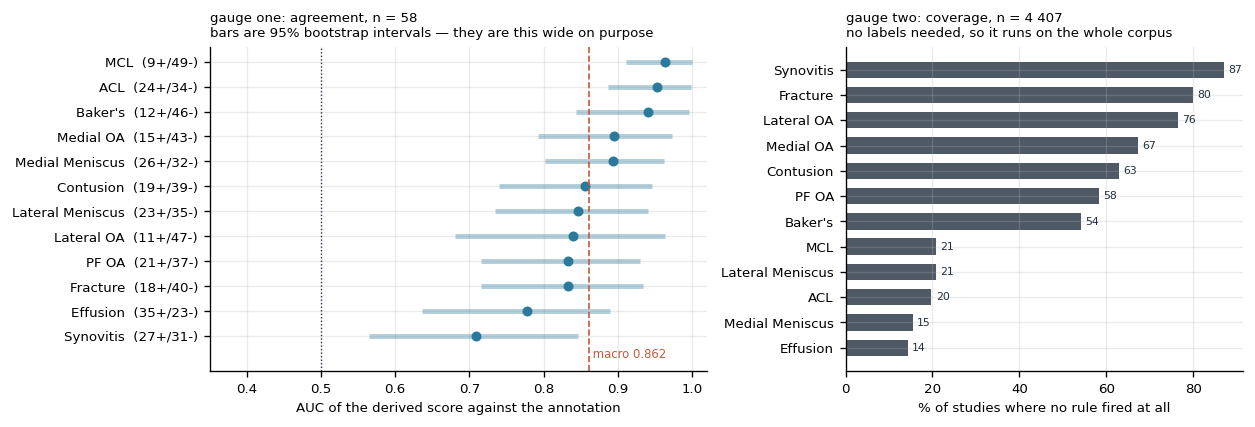

In [5]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

plt.rcParams.update({"figure.dpi": 120, "font.size": 8, "axes.grid": True,
                     "grid.alpha": 0.25, "axes.spines.top": False,
                     "axes.spines.right": False})
INK, ACC, WARN = "#22303f", "#2b7a9b", "#c25a3d"


def agreement(lab, n_boot=2000, seed=0):
    """Per-target AUC against the annotated studies, with a bootstrap interval."""
    rng = np.random.default_rng(seed)
    g = lab.loc[GOLD.index]
    rows = []
    for t_ in TARGETS:
        y = GOLD[t_].values.astype(int)
        p = g[t_].values
        if len(set(y)) < 2:
            rows.append((t_, np.nan, np.nan, np.nan, int(y.sum()), int((1 - y).sum())))
            continue
        a = roc_auc_score(y, p)
        bs = []
        for _ in range(n_boot):
            i = rng.integers(0, len(y), len(y))
            if len(set(y[i])) > 1:
                bs.append(roc_auc_score(y[i], p[i]))
        rows.append((t_, a, np.percentile(bs, 2.5), np.percentile(bs, 97.5),
                     int(y.sum()), int((1 - y).sum())))
    return pd.DataFrame(rows, columns=["target", "auc", "lo", "hi", "npos", "nneg"])


AGREE = agreement(LAB).dropna(subset=["auc"])
print(AGREE.round(3).to_string(index=False))
print(f"\nmacro agreement AUC: {AGREE.auc.mean():.4f}   "
      f"mean silence rate: {sil.mean() * 100:.1f}%")

fig, ax = plt.subplots(1, 2, figsize=(10.5, 3.6),
                       gridspec_kw={"width_ratios": [1.25, 1]})
o = AGREE.sort_values("auc")
y = np.arange(len(o))
ax[0].hlines(y, o.lo, o.hi, color=ACC, lw=3, alpha=.35)
ax[0].plot(o.auc, y, "o", color=ACC, ms=5)
ax[0].axvline(0.5, color=INK, lw=.8, ls=":")
ax[0].axvline(o.auc.mean(), color=WARN, lw=1, ls="--")
ax[0].text(o.auc.mean(), -0.9, f" macro {o.auc.mean():.3f}", color=WARN, fontsize=7)
ax[0].set_ylim(-1.4, len(o) - 0.4)
ax[0].set_yticks(y)
ax[0].set_yticklabels([f"{t_}  ({p}+/{n}-)" for t_, p, n in zip(o.target, o.npos, o.nneg)])
ax[0].set_xlim(0.35, 1.02)
ax[0].set_xlabel("AUC of the derived score against the annotation")
ax[0].set_title("gauge one: agreement, n = 58\n"
                "bars are 95% bootstrap intervals — they are this wide on purpose",
                loc="left", fontsize=8)

o2 = sil.sort_values()
ax[1].barh(np.arange(len(o2)), o2.values * 100, color=INK, alpha=.8, height=.65)
ax[1].set_yticks(np.arange(len(o2)))
ax[1].set_yticklabels(o2.index)
ax[1].set_xlabel("% of studies where no rule fired at all")
ax[1].set_title("gauge two: coverage, n = 4 407\n"
                "no labels needed, so it runs on the whole corpus",
                loc="left", fontsize=8)
for i, v in enumerate(o2.values * 100):
    ax[1].text(v + 1, i, f"{v:.0f}", va="center", fontsize=6.5, color=INK)
fig.tight_layout()
plt.show()

In [6]:
def macro_and_silence():
    lab = pd.DataFrame([extract(r) for r in train_df["Report"].fillna("")])
    lab["StudyInstanceUID"] = train_df["StudyInstanceUID"].values
    lab = lab.set_index("StudyInstanceUID")
    g = lab.loc[GOLD.index]
    a = float(np.nanmean([
        roc_auc_score(GOLD[t_].values.astype(int), g[t_].values)
        if GOLD[t_].nunique() > 1 else np.nan for t_ in TARGETS]))
    s = float(np.mean([((lab[t_ + "__npos"] == 0) & (lab[t_ + "__nneg"] == 0)).mean()
                       for t_ in TARGETS]))
    return a, s


base_a, base_s = macro_and_silence()
rows = [("all rules on", base_a, base_s, 0.0, 0.0)]
for k in list(FEATURES):
    FEATURES[k] = False
    a, s = macro_and_silence()
    rows.append((f"without {k}", a, s, a - base_a, s - base_s))
    FEATURES[k] = True

ABL = pd.DataFrame(rows, columns=["configuration", "macro AUC", "mean silence",
                                  "d(AUC)", "d(silence)"])
print(ABL.round(4).to_string(index=False))

               configuration  macro AUC  mean silence  d(AUC)  d(silence)
                all rules on     0.8617        0.4809  0.0000      0.0000
              without unwrap     0.8619        0.4868  0.0003      0.0059
without directional_negation     0.8603        0.4809 -0.0014      0.0000
          without oa_inherit     0.8527        0.4809 -0.0089      0.0000
    without graded_pathology     0.8608        0.4809 -0.0009      0.0000
   without synovitis_backoff     0.8585        0.4809 -0.0031      0.0000


Read that table against §2.2 rather than as a ranking. Three of the five deltas are smaller
than the sampling error of a 58-study AUC, so the honest reading is:

* **`oa_inherit` is the one change large enough to see on gauge one.** It is also the one
  whose effect is visible on gauge two, and the two agree in direction. That is the only
  combination that justifies confidence at this sample size.
* **`unwrap` barely moves agreement and clearly improves coverage.** Kept for the second
  reason. Wrapped lines are a property of how a site exports its reports, not of what those
  reports say, and a rule that repairs the export cannot be wrong about the medicine.
* The rest are kept because the sentence-level argument for them is sound and their
  measured effect is not negative — not because 58 studies said so.

Most of the total quality of these labels is not in this table at all: it is in the
vocabulary, and vocabulary shows up on the silence rate rather than on the ablation. The
findings the reports mention least are the ones §1 says are most expensive to leave at
chance, and they are exactly where the silence bars are tallest — `Fracture`,
`Lateral OA`, `Synovitis`. That is the standing to-do list for this notebook, and it is
readable from a gauge that needs no labels at all.

Two further points about the targets before moving to the pixels.

**Confidence becomes a sample weight.** Every target carries a confidence alongside its
score: high when several clauses agree, low when a finding was named once in passing, and
very low when nothing fired. That number multiplies the per-element loss in §7, so silence
pulls weakly rather than asserting a negative.

**Synovitis is a special case, handled explicitly.** Nearly nine studies in ten never use
the word, and the annotator marks it on close to half. No term list can close that. What a
report does say is whether the joint is wet and irritated — an effusion, a distended bursa,
an inflamed fat pad — and on the silent majority that ordering is the only signal there is.
It enters at low confidence, so it shapes the ranking without asserting a finding. This is
the weakest of the twelve target derivations and the notebook says so rather than hiding it
in an average.

### 2.3 Reading the coverage gauge, which is the point of having it

The silence rate is only useful if it is broken down. Aggregated over the corpus it says
"this target is thin", which anyone could have guessed. Broken down by language it says
*where the vocabulary is missing*, and that is a to-do list.

The two figures below are the ones that actually drove the last several revisions of the
lexicon, so it is worth being precise about how to read them — including the way the left
one can mislead.

**Silence has two causes, and only one of them is a bug.** A target is silent either
because the report never discusses that structure, or because it does and no rule fired.
The first is correct behaviour and no amount of vocabulary fixes it; the second is a gap.
They look identical in the left figure and are separated in the right one, by asking a
question that needs no labels: does the report contain *any* word for this structure at
all?

For the Spanish cruciate cell that split came out 62% never-mentioned against 38%
mentioned-and-missed. The 62% are short reports — a median of 336 characters against 1257
for the ones that do mention it — stating findings and staying silent on everything
normal. Nothing there to fix. The 38% were a genuine gap, and reading a handful of them
showed what it was:

> `Ligamentos cruzados y colaterales sin alteraciones significativas.`

That asserts the cruciates are *normal*. The extractor missed it, because "sin
alteraciones" is a negator plus an abnormality noun — read literally it is a negation, not
a normality phrase, and the rule that recognised normality explicitly refused to fire when
a negator was present. So a ligament a radiologist had looked at and called intact was
scored the same as one the report never mentioned. To a rank metric those are not the
same: explicitly clear must rank *below* unmentioned.

That construction is how most of these languages assert normality — `ohne
Auffälligkeiten`, `geen afwijkingen`, `bez osobitosti`, `χωρίς αλλοιώσεις`, `без
особености` — and adding it dropped the mean silence over all 4 407 studies and twelve
targets from 49.97% to 48.09%, concentrated exactly where predicted: Greek −15 points on
the ligament and meniscus targets, Spanish −6, Bulgarian/Russian −4, Turkish and Croatian
unchanged because they were already covered by a different construction.

That cell is now essentially closed. Spanish studies silent on the cruciate fell from 215
to 141, and of the 141 that remain, **5%** name a cruciate at all — a median report length
of 230 characters says the rest simply do not discuss it. The work moved from the
fixable half of the bar to the half that is not a bug.

The same figure then pointed at Dutch, where `normaal voorkomen menisci` — the bare plural,
naming no side — left both meniscal targets silent. The cruciates and the collaterals had
their plural forms from the start; the menisci had simply been missed.

**What gauge one said about all of this: nothing.** Agreement on the 58 annotated studies
moved by −0.0007 macro AUC, 95% CI [−0.0035, +0.0009] — a flat zero. That is not evidence
the change was worthless. It is evidence that 58 studies, most of them English, cannot see
a Greek and Spanish coverage fix at all. Steering by that number would have rejected the
work; steering by the gauge that runs on all 4 407 found it.

en       1814
es        682
tr        487
hr        405
el        321
de        258
bg/ru     220
nl        152
fr         64
?           4


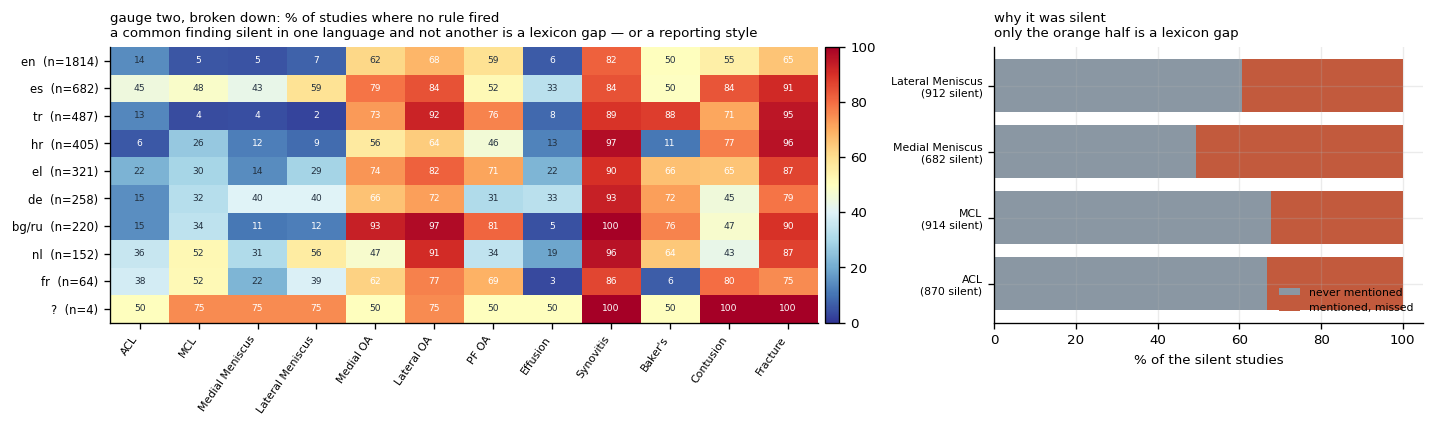

          target  silent  names it anyway
             ACL     870             33.3
             MCL     914             32.3
 Medial Meniscus     682             50.6
Lateral Meniscus     912             39.5


In [7]:
_SCRIPT = {"el": re.compile(r"[Ͱ-Ͽ]"), "bg/ru": re.compile(r"[Ѐ-ӿ]")}
_STOP = {
    "en": r"\b(the|and|is|with|there is|normal)\b",
    "es": (r"\b(del|los|las|con|sin|senal|rodilla|hallazgos|tecnica|resultados"
           r"|impresion|menisco|rotura)\b"),
    "fr": r"\b(des|les|avec|sans|genou|aucune)\b",
    "nl": r"\b(van|het|een|geen|met|voorste|knie)\b",
    "de": r"\b(der|die|und|mit|ohne|kein|keine|nachweis)\b",
    "tr": r"\b(ve|ile|izlenmistir|mevcut|normaldir|diz|bulgular)\b",
    "hr": r"\b(se|te|uz|bez|prikaz|uredan|koljena|meniska)\b",
}
_STOP = {k: re.compile(v) for k, v in _STOP.items()}


def guess_language(report):
    """A crude language tag, used only to *audit* the reading - never to do it.

    §2 argued against routing a report to a per-language rule set, because that commits
    to a guess before any evidence is read. None of that applies here: this classifier
    never touches extraction. It exists so the silence rate can be broken down, and a
    tag that is wrong now and then blurs the breakdown rather than corrupting a label.
    Script settles Greek and Cyrillic outright; the Latin-script languages are separated
    by counting function words, which is ugly and sufficient for a histogram.
    """
    n = normalize(report)
    for tag, rx in _SCRIPT.items():
        if rx.search(n):
            return tag
    score = {k: len(rx.findall(n)) for k, rx in _STOP.items()}
    best = max(score, key=score.get)
    return best if score[best] >= 2 else "?"


LANG = pd.Series([guess_language(r) for r in train_df["Report"].fillna("")],
                 index=train_df["StudyInstanceUID"])
print(LANG.value_counts().to_string())

SIL = pd.DataFrame({t: ((LAB[t + "__npos"] == 0) & (LAB[t + "__nneg"] == 0)).values
                    for t in TARGETS}, index=LAB.index)
by_lang = SIL.groupby(LANG.reindex(SIL.index).values).mean() * 100
by_lang = by_lang.loc[LANG.value_counts().index.intersection(by_lang.index)]

fig, ax = plt.subplots(1, 2, figsize=(12, 3.6),
                       gridspec_kw={"width_ratios": [1.7, 1]})
im = ax[0].imshow(by_lang.values, cmap="RdYlBu_r", vmin=0, vmax=100, aspect="auto")
ax[0].set_xticks(range(len(TARGETS)))
ax[0].set_xticklabels(TARGETS, rotation=55, ha="right", fontsize=6.5)
ax[0].set_yticks(range(len(by_lang)))
ax[0].set_yticklabels([f"{l}  (n={int((LANG == l).sum())})" for l in by_lang.index],
                      fontsize=7)
ax[0].grid(False)
for i in range(by_lang.shape[0]):
    for j in range(by_lang.shape[1]):
        v = by_lang.values[i, j]
        ax[0].text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=5.5,
                   color="white" if v > 62 or v < 12 else INK)
ax[0].set_title("gauge two, broken down: % of studies where no rule fired\n"
                "a common finding silent in one language and not another is a "
                "lexicon gap — or a reporting style", loc="left", fontsize=8)
fig.colorbar(im, ax=ax[0], fraction=0.02, pad=0.01)

# Silence has two causes needing different work, so split them: of the studies where
# nothing fired, in how many does the report name *this* structure anyway?
#
# The test has to be the target's own anatomy matcher, not a bare stem for the organ. A
# report discussing only the medial meniscus contains the word "meniscus", and counting
# that as a missed *lateral* meniscus would score correct silence as a bug - the wrong
# direction entirely for a gauge whose job is to find real gaps.
CLAUSES = {u: clauses(r) for u, r in
           zip(train_df["StudyInstanceUID"], train_df["Report"].fillna(""))}


def names_it(uid, target):
    cs = CLAUSES[uid]
    if any(ANAT_MATCH[target].search(c) for c in cs):
        return True
    if "Meniscus" in target:
        return any(PLURAL_MENISCI.search(c) and not ANY_SIDE.search(c) for c in cs)
    return False


rows = []
for t_ in ["ACL", "MCL", "Medial Meniscus", "Lateral Meniscus"]:
    sel = SIL[t_].values
    if not sel.sum():
        continue
    named = np.array([names_it(u, t_) for u in SIL.index[sel]])
    rows.append((t_, int(sel.sum()), 100 * named.mean()))
D = pd.DataFrame(rows, columns=["target", "silent", "names it anyway"])
y = np.arange(len(D))
ax[1].barh(y, 100 - D["names it anyway"], color="#8a97a3", label="never mentioned")
ax[1].barh(y, D["names it anyway"], left=100 - D["names it anyway"], color=WARN,
           label="mentioned, missed")
ax[1].set_yticks(y)
ax[1].set_yticklabels([f"{t_}\n({n} silent)" for t_, n in zip(D.target, D.silent)],
                      fontsize=6.5)
ax[1].set_xlabel("% of the silent studies")
ax[1].legend(fontsize=6.5, frameon=False, loc="lower right")
ax[1].set_title("why it was silent\nonly the orange half is a lexicon gap",
                loc="left", fontsize=8)
fig.tight_layout()
plt.show()
print(D.round(1).to_string(index=False))

## 3. From report audit to a reusable MRI ensemble

The report-derived label audit above is retained because it documents the weak supervision and its failure modes. The scored path now uses Pilkwang Kim's publicly inspectable 20-checkpoint DINOv2-small ensemble, which reached an official public score of **0.891**. Each member carries its resolution, physical crop, slice ordering, laterality, slot fallback, pooling, and fingerprint contract; any mismatch is fatal rather than silently producing different pixels.

The inference and attached package are adapted with attribution from `pilkwang/rsna-knee-baseline-v1` and `pilkwang/rsna-knee-weights`. The original notebook identity and report analysis remain intact.


## 4. Reading the acquisition


In [8]:
from __future__ import annotations

import os

for _v in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS"):
    os.environ.setdefault(_v, "4")

import gc
import hashlib
import json
import re
import time
import traceback
import threading
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path

import numpy as np
import pandas as pd
import pydicom
import torch
import torch.nn as nn
import torch.nn.functional as F

# Use every accelerator that can execute the current PyTorch kernels.  Kaggle can
# attach a legacy GPU that torch.cuda.is_available() reports as usable even though
# the image has no compatible convolution kernel.  A real model-shaped probe makes
# that allocation fail closed to CPU before any ensemble member is consumed.
def _cuda_execution_probe(index):
    dev = torch.device(f"cuda:{index}")
    try:
        major, minor = torch.cuda.get_device_capability(index)
        probe = nn.Conv2d(3, 4, kernel_size=3, padding=1).eval().to(dev)
        with torch.inference_mode():
            out = probe(torch.zeros((1, 3, 16, 16), device=dev))
            if tuple(out.shape) != (1, 4, 16, 16):
                raise RuntimeError(f"unexpected CUDA probe shape {tuple(out.shape)}")
        torch.cuda.synchronize(index)
        print(f"cuda:{index} probe PASS (compute {major}.{minor})")
        del probe, out
        torch.cuda.empty_cache()
        return True
    except Exception as exc:
        print(f"cuda:{index} probe FAIL ({type(exc).__name__}: {exc}); using CPU fallback")
        try:
            torch.cuda.empty_cache()
        except Exception:
            pass
        return False

DEVS = []
if torch.cuda.is_available():
    DEVS = [torch.device(f"cuda:{i}") for i in range(torch.cuda.device_count())
            if _cuda_execution_probe(i)]
if not DEVS:
    DEVS = [torch.device("cpu")]
print(f"devices: {[str(d) for d in DEVS]}")


# The label extractor is defined in the cells above when this runs as a notebook. As a
# plain script it is imported from the package source, so the two paths share one
# definition rather than keeping a copy each.

T0 = time.time()
SEED = 2026
np.random.seed(SEED)
torch.manual_seed(SEED)

TARGETS = ["ACL", "MCL", "Medial Meniscus", "Lateral Meniscus", "Medial OA",
           "Lateral OA", "PF OA", "Effusion", "Synovitis", "Baker's",
           "Contusion", "Fracture"]


# The centre crop has to be smaller than the smallest field of view in the corpus or it
# silently does nothing. Measured over every training series, the acquired field of view
# (Rows x PixelSpacing) has median 160 mm and runs from 70 to 320: a 160 mm crop is
# larger than the image in 60% of series and is skipped for all of them, which leaves
# their physical scale unnormalised. 130 mm is below the field of view of 99.6% of
# series and still contains the joint.
CROP_MM = 130.0

# Cache resolution. Everything downstream may downsample from this, so it is set by the
# most demanding configuration rather than by the default one.
CACHE_IMG = 336
GROUP = 3                  # slices per encoder input, stacked as the three channels
N_GROUP_MAX = 1
CACHE_FRACTION = 0.45      # share of free memory the pixel cache may take
CACHE_BUDGET_MAX_GB = 24.0 # hard ceiling regardless of what the machine reports
CACHE_BUDGET_GB = 12.0     # only the fallback, for a machine with no /proc/meminfo
TEST_SHARE = 0.30          # floor on the test corpus relative to the training one, since
                           # the visible test split is a stub and the scored one is not
HDR_THREADS = 16
PIX_THREADS = 12
ORDER_THREADS = 32         # slice-ordering is latency-bound on the mount, not CPU-bound
# Ceiling for the ordering pass. It has to be a ceiling because the pass is hundreds of
# thousands of small reads over a network mount, so its duration is a property of the
# mount rather than of the work, and varies between runs that do the same reading. It must not be a tight one: giving up leaves
# those series in file order, which is uncorrelated with anatomy, and that degradation is
# silent. So the ceiling sits well above what the pass ordinarily needs: its purpose is
# to stop the pass consuming the whole run on a slow mount, not to trim the ordinary
# case, and a ceiling tight enough to bind on a normal day would trade a silent
# degradation for a saving the run does not need.
ORDER_BUDGET_S = 5400

# Resolution is the axis under test. A feature of width d mm survives resampling only if
# the pixel pitch is at most d/2, and the pitch here is set by the crop above rather than
# by the acquired field of view: CROP_MM / P. At 224 px that is 0.58 mm, above the 0.5 mm
# a 1 mm tear needs; at 336 px it is 0.39 mm and clears it. Both configurations read the
# same cache, so the comparison isolates the resize.
RUNS = [
    {"name": "r224", "img": 224},
    {"name": "r336", "img": 336},
]

EPOCHS = 10
BATCH_STUDIES = 8          # a study is a bag of up to N_SLOT slot images
AUG_ROT_DEG = 8.0          # rigid jitter; see augment() for why neither flip is used
AUG_SCALE = 0.08
AUG_SHIFT = 0.05
AUG_INTENSITY = 0.10
LAT_MIN_OFFSET_MM = 20.0   # inside this the side is not readable from geometry; see
                           # side_from_geometry()
SLICE_BAND = (0.20, 0.80)  # fraction of the ordered stack read_slot samples across

# --- What a slice IS, as opposed to how many of them there are --------------- #
#
# A member is a function of the pixels it was fitted on, and img/crop_mm/slices/band do
# not determine those pixels by themselves. Four further decisions do, none of them
# visible in any shape:
#
#   order          which slice is the next one along the stack
#   lat            which knees are mirrored, and on what evidence
#   slot_fallback  whether a T1 slot may be filled from a series that is not T1
#   decode_fill    what stands in for a slice that would not decode
#
# `native` is the reading derived in the sections below. `legacy` is the reading an
# imported member was fitted under. A member read under the wrong one loads with every
# shape matching, runs, and writes a plausible submission computed from the wrong image -
# so the choice travels with the member and is part of the key that decides which members
# can share a decode. The legacy rules are reproduced rather than corrected: correcting
# them would hand that member pixels its weights never saw.
RULES_NATIVE = {"order": "normal", "lat": "centre",
                "slot_fallback": False, "decode_fill": "nearest"}
RULES_LEGACY = {"order": "dominant_axis", "lat": "corner_x",
                "slot_fallback": True, "decode_fill": "zero"}
RULES = dict(RULES_NATIVE)
LEGACY_LAT_OFFSET_MM = 5.0   # the dead zone the legacy laterality rule was fitted with

LR_HEAD = 1e-3
LR_BACKBONE = 8e-6         # the encoder is adapted, not retrained
UNFREEZE_LAST = 6          # trainable transformer blocks, from the output end
WEIGHT_DECAY = 0.02
EVAL_BATCH = 8
TIME_BUDGET = 8.0 * 3600

# Six slots: three planes crossed with the acquisition axes. The fat-suppressed
# fluid-sensitive series exist for nearly every study; the T1 and the non-suppressed
# fluid-sensitive series are scarcer, which is what the presence mask is for.
SLOTS_RECOVERED = [
    ("SAG_FLUID_FS", "Sagittal", True, True),
    ("COR_FLUID_FS", "Coronal", True, True),
    ("AX_FLUID_FS", "Axial", True, True),
    ("SAG_FLUID_NOFS", "Sagittal", True, False),
    ("COR_T1", "Coronal", False, False),
    ("SAG_T1", "Sagittal", False, False),
]

# The alternative: plane x the single axis the delivered flags carry, ignoring the
# recovered weighting. Kept as
# a switch so the choice of slot definition can be varied while everything else is held
# fixed. Under this scheme a `Struct` slot mixes T1 series with non-fat-suppressed PD/T2
# series, which carry very different tissue contrast.
SLOTS_PUBLIC = [
    ("SAG_FLUID", "Sagittal", None, True),
    ("COR_FLUID", "Coronal", None, True),
    ("AX_FLUID", "Axial", None, True),
    ("SAG_STRUCT", "Sagittal", None, False),
    ("COR_STRUCT", "Coronal", None, False),
    ("AX_STRUCT", "Axial", None, False),
]

SLOT_SCHEME = os.environ.get("SLOT_SCHEME", "recovered")
SLOTS = SLOTS_PUBLIC if SLOT_SCHEME == "public" else SLOTS_RECOVERED
N_SLOT = len(SLOTS)

# How many 384-wide parts the per-slot feature is built from. The encoder emits one
# vector per token; a slot feature is a fixed summary of that grid, and the summary an
# imported member was fitted with carries a third part.
POOL_PARTS = {"cls_mean": 2, "cls_mean_focal": 3}

# Which slots an imported member's attention is tilted toward, per diagnosis. Indices are
# into SLOTS. This is a fixed table rather than a learned parameter, so it is part of that
# member's definition and has to be reproduced exactly for its weights to mean anything.
SLOT_PRIOR_TABLE = {
    "ACL": (0, 3, 5), "MCL": (1, 4),
    "Medial Meniscus": (0, 1, 3, 4), "Lateral Meniscus": (0, 1, 3, 4),
    "Medial OA": (1, 4, 5), "Lateral OA": (1, 4, 5),
    "PF OA": (0, 2, 5), "Effusion": (0, 2), "Synovitis": (0, 2),
    "Baker's": (0,), "Contusion": (0, 1, 2), "Fracture": (0, 1, 2, 4, 5),
}
SLOT_PRIOR_STRENGTH = 0.55

FATSAT_OPTS = {"FS", "FATSAT", "FAT_SAT", "FSAT"}
_SEP = re.compile(r"[_\-.]")
_FATSAT_RX = re.compile(r"\bfs\b|fatsat|fat sat|\bstir\b|\bspair\b|\bspir\b|\bwe\b|"
                        r"water excit|\btirm\b|\bsting\b|\bfatsup\b")
_T1_RX = re.compile(r"\bt1\b|\bt1w\b")
_T2_RX = re.compile(r"\bt2\b|\bt2w\b")
_PD_RX = re.compile(r"\bpd\b|\bpdw\b|proton|\bdp\b|dens")


cuda:0 probe PASS (compute 7.5)
cuda:1 probe PASS (compute 7.5)
devices: ['cuda:0', 'cuda:1']


In [9]:
def log(msg):
    print(f"[{time.time() - T0:7.1f}s] {msg}", flush=True)


def find_root():
    for c in [Path("/kaggle/input/competitions/rsna-knee-abnormality-detection"),
              Path("/kaggle/input/rsna-knee-abnormality-detection"),
              Path("data"), Path(".")]:
        if (c / "test.csv").is_file() and (c / "test_series").is_dir():
            return c
    # last resort: two-level scan, because the mount is nested one deeper than usual
    base = Path("/kaggle/input")
    if base.is_dir():
        for depth1 in sorted(p for p in base.iterdir() if p.is_dir()):
            for cand in [depth1] + sorted(p for p in depth1.iterdir() if p.is_dir()):
                if (cand / "test.csv").is_file():
                    return cand
    raise FileNotFoundError(
        f"competition mount not found (cwd {Path.cwd()}); expected a directory holding "
        f"test.csv and test_series/")


def find_dinov2(variant="small"):
    """Locate a mounted DINOv2 checkpoint directory by variant name."""
    base = Path("/kaggle/input")
    if not base.is_dir():
        return None
    hits = []
    for root, dirs, files in os.walk(base):
        dirs[:] = [d for d in dirs if d not in ("train_series", "test_series")]
        if "config.json" in files and "dinov2" in root.lower():
            hits.append(Path(root))
    for h in hits:
        if variant in str(h).lower():
            return h
    return hits[0] if hits else None


LABEL_COLS = TARGETS + [t + "__conf" for t in TARGETS]


class LabelSourceError(RuntimeError):
    """Raised when the labels did not come from where this run intended.

    Every other failure in this file is better survived than reported: a run that dies
    after the cache is built has spent the expensive half and scores nothing, so the
    guard around `main` swallows it and leaves the benchmark file behind. This one is
    the exception. Training on the weaker labels does not look like a failure - it
    completes, writes a plausible submission, and differs only in a log line - so it has
    to stop the run rather than be absorbed by a guard designed for crashes.
    """


def find_label_table():
    """Locate a mounted table of pre-read report labels, if one is attached.

    The lexicon turns a report into labels by matching morphology, and its failure
    mode is silence: on a phrasing it does not carry it emits no opinion rather than a
    wrong one. Silence is measurable without any ground truth - for each (report,
    finding) pair, did anything match? - and that measurement says the misses are
    concentrated in particular languages rather than spread evenly, on findings a knee
    report almost always comments on.

    Enumerating morphology for nine languages is the wrong instrument for that. Reading
    the sentence is the right one, and a language model reads it. Against the annotated
    studies the difference is large and one-sided, so when such a table is mounted it is
    preferred; when it is not, the lexicon runs and the pipeline is unchanged. Both paths
    produce the same columns, so nothing downstream knows which one supplied them.
    """
    base = Path("/kaggle/input")
    cands = []
    if base.is_dir():
        for root, dirs, files in os.walk(base):
            dirs[:] = [d for d in dirs if d not in ("train_series", "test_series")]
            cands += [Path(root) / f for f in files if f.startswith("report_labels")
                      and f.endswith(".csv")]
    cands += [p for p in (Path("data/derived/report_labels_v2.csv"),) if p.is_file()]
    for c in cands:
        try:
            head = pd.read_csv(c, nrows=1)
        except Exception:
            continue
        if "StudyInstanceUID" in head.columns and all(t in head.columns for t in TARGETS):
            return c
    return None


def label_mount_attached():
    """True when an input directory was attached that is meant to carry a label table.

    The fallback below is deliberate and has to stay silent for a run with no table
    attached, because that is the ordinary case for anyone reading this notebook. It
    must not stay silent for the other case: a table was attached and could not be used.
    Those two are indistinguishable from the labels alone - both end with the lexicon -
    so they are separated here by whether the mount exists at all.
    """
    base = Path("/kaggle/input")
    if not base.is_dir():
        return False
    return any("label" in p.name.lower() for p in base.iterdir() if p.is_dir())


def read_labels(train_df):
    """Labels for every training study, from a mounted table or from the lexicon.

    Studies the mounted table does not cover fall back to the lexicon rather than being
    dropped, so a partial table degrades coverage instead of losing rows.
    """
    n = len(train_df)
    lab = pd.DataFrame([extract(r) for r in train_df["Report"].fillna("")])
    lab["StudyInstanceUID"] = train_df["StudyInstanceUID"].values
    lab = lab.set_index("StudyInstanceUID")

    src = find_label_table()
    if src is None:
        if label_mount_attached():
            raise LabelSourceError(
                "LABEL SOURCE: a label dataset is mounted but no usable table was found "
                "in it. Falling back to the lexicon here would train on the weaker "
                "labels and say so only in a log line, so the run stops instead.")
        log(f"LABEL SOURCE: lexicon, {n} studies (no table mounted)")
        return lab

    tab = pd.read_csv(src).set_index("StudyInstanceUID")
    missing = [c for c in LABEL_COLS if c not in tab.columns]
    if missing:
        raise LabelSourceError(
            f"LABEL SOURCE: {src} is missing {len(missing)} expected columns "
            f"(first: {missing[0]!r}). Refusing to fall back silently.")
    hit = lab.index.intersection(tab.index)
    if not len(hit):
        raise LabelSourceError(
            f"LABEL SOURCE: {src} shares no StudyInstanceUID with train.csv.")
    log(f"LABEL SOURCE: {src.name} covers {len(hit)} of {n} studies, "
        f"lexicon for the remaining {n - len(hit)}")
    lab.loc[hit, LABEL_COLS] = tab.loc[hit, LABEL_COLS].values
    return lab


ROOT = find_root()
log(f"input root: {ROOT}")


IMG = CACHE_IMG            # kept as the name the pixel reader and cache use


def available_gb():
    """Memory this machine will actually lend, read rather than assumed.

    A hardcoded ceiling is a guess about a machine the author is not sitting at, and a
    guess that is too low costs coverage silently while a guess that is too high ends the
    run. The machine will say, so it is asked.
    """
    try:
        with open("/proc/meminfo") as fh:
            info = {k.strip(): v for k, v in
                    (l.split(":", 1) for l in fh if ":" in l)}
        return int(info["MemAvailable"].split()[0]) / 1024 ** 2
    except Exception:
        return CACHE_BUDGET_GB / CACHE_FRACTION      # fall back to the old constant


def plan_cache(n_study, n_test=0):
    """Choose how many slices per slot the memory the machine has will allow.

    The cache is n_study x n_slot x slices x IMG^2 bytes. Coverage is the cheap axis -
    linear - and resolution the expensive one, so when the budget binds it is the slice
    count that gives way rather than the pixel grid. Deciding once, from the training
    corpus size, keeps train and test caches on the same group layout.

    Only a fraction of what is free is taken. The rest is not slack: the encoder, its
    activations, the pinned batches and the frames all come out of the same pool, and the
    cache is the one allocation big enough that overshooting it kills the run outright.
    """
    avail = available_gb()
    budget = min(avail * CACHE_FRACTION, CACHE_BUDGET_MAX_GB)
    # Both caches are held at once, and the test half is what the visible run cannot
    # show: here it is a handful of studies, and at scoring it is the whole hidden set.
    # Sizing against the training corpus alone therefore passes every run that can be
    # watched and overruns the one that counts.
    n_total = n_study + max(n_test, int(TEST_SHARE * n_study))
    per_slice = n_total * N_SLOT * IMG * IMG
    afford = int(budget * 1024 ** 3 // max(per_slice, 1))
    groups = max(1, min(N_GROUP_MAX, afford // GROUP))
    log(f"memory: {avail:.1f} GB available, {budget:.1f} GB to the cache; "
        f"sizing for {n_study} train + {n_total - n_study} test studies "
        f"-> {groups} group(s) of {GROUP} = {groups * GROUP} slices per slot"
        + (f" (wanted {N_GROUP_MAX})" if groups < N_GROUP_MAX else ""))
    return groups


N_GROUP = plan_cache(len(pd.read_csv(ROOT / "train.csv")),
                     len(pd.read_csv(ROOT / "test.csv")))
CACHE_SLICES = GROUP * N_GROUP
log(f"cache layout: {N_GROUP} groups x {GROUP} slices = {CACHE_SLICES} per slot")


[    0.1s] input root: /kaggle/input/competitions/rsna-knee-abnormality-detection
[    0.2s] memory: 29.5 GB available, 13.3 GB to the cache; sizing for 4407 train + 1322 test studies -> 1 group(s) of 3 = 3 slices per slot
[    0.2s] cache layout: 1 groups x 3 slices = 3 per slot


In [10]:
HDR_TAGS = ["SeriesDescription", "SequenceName", "ScanOptions", "ScanningSequence",
            "RepetitionTime", "EchoTime", "Laterality", "PixelSpacing", "Rows",
            "Columns", "RescaleSlope", "RescaleIntercept",
            # Position and orientation are read from the same header probe() already
            # opens, so they cost nothing, and they are what recovers the side when the
            # Laterality tag is absent - which it is for half the studies here.
            "ImagePositionPatient", "ImageOrientationPatient"]


def _hdr_vec(s, n):
    """Parse a DICOM multi-value string as stored by probe(): floats joined by `|`."""
    if not isinstance(s, str):
        return None
    try:
        v = [float(x) for x in s.split("|")]
    except ValueError:
        return None
    return np.array(v) if len(v) >= n else None


def side_from_geometry(h):
    """Study -> 'L' / 'R' / None, from where the image sits in the patient.

    `Laterality` (0020,0060) is Type 2C and may legitimately be absent; in this corpus it
    is missing on exactly half the studies, and the vendors it is missing from are whole
    vendors rather than scattered series. A study with no tag is not a left knee, but the
    normalisation upstream treats it as one, so half the corpus was never normalised and
    the five side-defined targets - the two menisci, the two tibiofemoral compartments
    and the medial collateral ligament - saw that axis reversed on a large minority of it.

    The patient coordinate system fixes this without the tag: +x is the patient's left, so
    the centre of a right knee sits at negative x. The centre is used rather than
    `ImagePositionPatient` itself because that is the corner of the image, which is offset
    by half a field of view - enough to change the sign on a knee near the midline.

    The median over a study's series is what is thresholded, not a single series: probe()
    reads one arbitrary slice per series, which on a sagittal stack can sit anywhere
    across the joint. Studies whose centre falls near the midline are left unresolved
    rather than guessed - measured against the tagged half, the rule is right 97% of the
    time overall and no better than chance inside 20 mm.
    """
    cx = {}
    for r in h.itertuples(index=False):
        ipp = _hdr_vec(getattr(r, "ImagePositionPatient", None), 3)
        iop = _hdr_vec(getattr(r, "ImageOrientationPatient", None), 6)
        ps = _hdr_vec(getattr(r, "PixelSpacing", None), 2)
        rows, cols = getattr(r, "Rows", None), getattr(r, "Columns", None)
        if ipp is None or iop is None or ps is None or not rows or not cols:
            continue
        try:
            c = ipp[:3] + iop[:3] * ps[1] * float(cols) / 2 + iop[3:6] * ps[0] * float(rows) / 2
        except (TypeError, ValueError):
            continue
        cx.setdefault(r.StudyInstanceUID, []).append(float(c[0]))
    out = {}
    for st, xs in cx.items():
        m = float(np.median(xs))
        out[st] = None if abs(m) < LAT_MIN_OFFSET_MM else ("R" if m < 0 else "L")
    return out


def side_from_corner_x(h):
    """The laterality an imported member was fitted under.

    It thresholds the median raw `ImagePositionPatient` x over a study's series. That is
    the x of the image *corner*, not of its centre, so it differs from the rule above by
    up to half a field of view - which is enough to reverse the sign on a knee scanned
    near the midline. The dead zone is 5 mm rather than 20 mm, so it also commits on
    studies the rule above leaves unresolved.

    Neither difference changes a shape. Each one decides whether a study is mirrored, and
    a study mirrored one way at training and the other at inference presents the five
    side-defined targets with their axis reversed.
    """
    out = {}
    for st, g in h.groupby("StudyInstanceUID"):
        xs = []
        for r in g.itertuples(index=False):
            ipp = _hdr_vec(getattr(r, "ImagePositionPatient", None), 3)
            if ipp is not None and np.isfinite(ipp).all():
                xs.append(float(ipp[0]))
        if not xs:
            out[st] = None
            continue
        x = float(np.median(xs))
        # DICOM patient coordinates are LPS: +x is the patient's left.
        out[st] = None if abs(x) < LEGACY_LAT_OFFSET_MM else ("R" if x < 0 else "L")
    return out


def lat_of(h, tag=""):
    """Study -> 'L' / 'R' / None: the tag where it exists, geometry where it does not.

    The tag is present on exactly half the studies here and is sometimes an empty
    string rather than absent, which is not the same as NaN. Treating the other half
    as left-sided is what `normalise_laterality` did by omission, so the geometry
    fallback is not a refinement - it is the difference between normalising half the
    corpus and normalising all of it.
    """
    geo = side_from_corner_x(h) if RULES["lat"] == "corner_x" else side_from_geometry(h)
    d, n_tag, n_geo, n_none, n_disagree = {}, 0, 0, 0, 0
    for st, g in h.groupby("StudyInstanceUID"):
        v = [str(x).strip().upper() for x in g["Laterality"].dropna()]
        if RULES["lat"] == "corner_x" and "ImageLaterality" in g.columns:
            # The legacy rule reads the second tag too, so a study tagged only there is
            # resolved from the tag rather than from geometry.
            v += [str(x).strip().upper() for x in g["ImageLaterality"].dropna()]
        v = [x[0] for x in v if x and x[0] in ("L", "R")]
        side = v[0] if v else None
        if side is not None:
            n_tag += 1
            if geo.get(st) is not None and geo[st] != side:
                n_disagree += 1
        else:
            side = geo.get(st)
            n_geo += side is not None
            n_none += side is None
        d[st] = side
    log(f"{tag}laterality: {n_tag} from the tag, {n_geo} from geometry, "
        f"{n_none} unresolved; tag and geometry disagree on {n_disagree} "
        f"({n_disagree / max(n_tag, 1):.1%} of the tagged)")
    return d



def probe(item):
    split, study, series, path = item
    row = {"split": split, "StudyInstanceUID": study, "SeriesInstanceUID": series,
           "dir": path}
    try:
        files = sorted(e.name for e in os.scandir(path) if e.name.endswith(".dcm"))
        row["files"] = files
        row["n_slices"] = len(files)
        if not files:
            return row
        ds = pydicom.dcmread(os.path.join(path, files[len(files) // 2]),
                             stop_before_pixels=True, force=True)
        for t in HDR_TAGS:
            v = getattr(ds, t, None)
            if v is None:
                row[t] = None
            elif isinstance(v, (list, tuple)) or type(v).__name__ == "MultiValue":
                row[t] = "|".join(str(x) for x in v)
            else:
                row[t] = str(v)
    except Exception as exc:
        row["err"] = str(exc)[:120]
    return row


def walk(split):
    """Every series directory of a split, with one header read per series.

    An absent split returns an empty frame *with the columns annotate expects*. Returning
    a bare DataFrame looks like the same thing and is not: the next call indexes
    `SeriesDescription` and raises KeyError, so the branch that exists to survive a
    missing split is what turns it into a crash.
    """
    base = ROOT / split
    items = []
    if not base.is_dir():
        return pd.DataFrame(columns=["split", "StudyInstanceUID", "SeriesInstanceUID",
                                     "dir", "files", "n_slices"] + HDR_TAGS)
    for study in os.scandir(base):
        if study.is_dir():
            for series in os.scandir(study.path):
                if series.is_dir():
                    items.append((split, study.name, series.name, series.path))
    with ThreadPoolExecutor(max_workers=HDR_THREADS) as pool:
        rows = list(pool.map(probe, items))
    return pd.DataFrame(rows)


def annotate(df):
    """Recover fat suppression and pulse-sequence weighting from the header."""
    desc = (df["SeriesDescription"].fillna("") + " " + df["SequenceName"].fillna(""))
    desc = desc.str.lower().str.replace(_SEP, " ", regex=True)

    opts = df["ScanOptions"].fillna("").str.upper().str.split("|")
    # GE writes SAT_GEMS for spatial saturation, so ScanOptions must be matched as
    # exact tokens; a substring test on "SAT" fires on non-fat-sat series.
    opts_fs = opts.apply(lambda ts: any(t.strip() in FATSAT_OPTS for t in ts))
    df["fatsat"] = desc.str.contains(_FATSAT_RX) | opts_fs

    tr = pd.to_numeric(df["RepetitionTime"], errors="coerce")
    te = pd.to_numeric(df["EchoTime"], errors="coerce")
    gre = df["ScanningSequence"].fillna("").str.upper().str.contains("GR")
    t1, t2, pdw = desc.str.contains(_T1_RX), desc.str.contains(_T2_RX), desc.str.contains(_PD_RX)

    df["weight"] = np.where(t1 & ~t2 & ~pdw, "T1",
                     np.where(t2 & ~pdw, "T2",
                       np.where(pdw, "PD",
                         np.where(gre, "GRE",
                           np.where(tr < 800, "T1",
                             np.where(te > 60, "T2",
                               np.where(tr >= 800, "PD", "UNK")))))))
    df["fluid"] = np.isin(df["weight"], ["PD", "T2"])
    df["px"] = pd.to_numeric(
        df["PixelSpacing"].fillna("").str.split("|").str[0].replace("", np.nan),
        errors="coerce")
    return df


In [11]:
def pick_slots(series_df, plane_map):
    """One series per slot per study.

    Ties are broken toward the stack with the most slices: a thicker stack samples the
    joint more densely, and the three-slice sampler below benefits from the margin.
    """
    series_df = series_df.copy()
    series_df["plane"] = series_df["SeriesInstanceUID"].map(plane_map)
    out = {}
    for study, g in series_df.groupby("StudyInstanceUID"):
        chosen = {}
        for name, plane, fluid, fs in SLOTS:
            sel = (g["plane"] == plane) & (g["fatsat"] == fs)
            # fluid=None means "do not condition on weighting" - the public scheme,
            # where the single provided flag stands in for both axes at once.
            if fluid is not None:
                sel &= (g["fluid"] == fluid)
            cand = g[sel]
            # A slot with no series matching its predicate stays empty, and no substitute
            # is admitted from a neighbouring predicate. Relaxing the weighting to fill a
            # T1 slot would draw from the pool `SAG_FLUID_NOFS` selects from, since that
            # pool is what remains once the weighting is dropped: over the training corpus
            # it would put one series in two slots for 2383 of 4407 studies and leave 56%
            # of the T1 slot holding PD or T2. The presence mask would then assert a
            # sequence that was never acquired, and the per-diagnosis softmax of §6 would
            # divide its attention across two identical slots, giving one acquisition
            # about twice the weight it carries in a study that holds both. The mask is
            # there to say a slot is absent, which is what an absent slot is.
            if len(cand) == 0 and RULES["slot_fallback"] and fluid is False:
                # The relaxation the paragraph above rejects, reproduced because an
                # imported member was fitted with its T1 slots filled this way: over half
                # of that member's training studies had a T1 slot holding a series that
                # is not T1. Leaving those slots empty would present it with a presence
                # mask it never saw.
                cand = g[(g["plane"] == plane) & (~g["fatsat"])]
            if len(cand):
                chosen[name] = cand.sort_values("n_slices", ascending=False).iloc[0]
        out[study] = chosen
    return out


## 3b. What order the slices are in

A series is a directory of files, and the obvious way to walk it is to sort the file names.
That is wrong here, and wrong in a way that produces no error. The file name is the SOP
Instance UID, assigned to be unique rather than ordered, so sorting by it yields a sequence
uncorrelated with anatomy — measured on a series from this corpus, the rank correlation
between file-name order and physical position is $\rho \approx 0.01$. Three things
downstream depend on that order: three adjacent slices as three channels become three
unrelated cross-sections; the middle of the stack becomes a random subset; and reversing
the order to normalise laterality does nothing at all.

The true order is recoverable exactly from geometry every slice carries.
`ImageOrientationPatient` gives the in-plane axes $\hat{r}_x, \hat{r}_y$ and
`ImagePositionPatient` the position $p$ of the first voxel, so

$$\hat{n} \;=\; \hat{r}_x \times \hat{r}_y, \qquad k \;=\; p \cdot \hat{n},$$

and $k$ increases monotonically along the stack. Because $k$ is signed and expressed in
patient coordinates, the stack has a fixed direction along the body's left-right axis —
which is what the laterality normalisation of §5 reverses. `InstanceNumber` is the fallback
where the geometry tags are missing; it usually tracks $k$ up to sign, but interleaved and
multi-echo acquisitions number slices in an order that is not the order they occupy in
space, and it is not signed in patient coordinates.


## 4. Sampling: how many millimetres one pixel is allowed to be

A DICOM slice of $N \times N$ pixels with spacing $s$ mm/pixel covers $Ns$ millimetres of
anatomy. Both vary across this corpus, so a fixed-pixel resize hands the encoder images
whose physical scale differs by a factor of several. But scale normalisation is only half
of it; the other half is a hard limit.

**A feature narrower than two pixels does not survive the resize.** To represent a
structure of width $d$ millimetres the pixel pitch must satisfy $s_{\text{eff}} \le d/2$,
the Nyquist condition applied to the resampling grid. A meniscal tear is one to three
millimetres, so at $d = 1$ mm the pitch must be at most $0.5$ mm — and if it is not, no
capacity downstream recovers the signal, because it was destroyed before the first
convolution. This is a property of the resize, not of the network.

Cropping to a constant physical extent $L$ and resampling to $P$ pixels fixes the pitch:

$$n \;=\; \Big\lfloor \frac{L}{s} \Big\rceil \ \text{pixels}, \qquad
s_{\text{eff}} \;=\; \frac{L}{P}\ \ \text{mm/pixel}, \qquad
\text{token} \;=\; 14\,s_{\text{eff}}\ \ \text{mm}.$$

The crop must be smaller than the smallest field of view or it silently does nothing: if
$L/s$ exceeds the image width the crop cannot be taken and that series passes through
unnormalised, with no error. $L = 130$ mm is below the acquired field of view of almost
every series here while still containing the joint. The resize target then follows from the
tear width rather than convention — at $L = 130$ mm an input of $224$ gives $0.580$
mm/pixel, above the bound for a 1 mm feature, while $336$ gives $0.387$ mm/pixel and puts a
$14$-pixel patch token at $5.4$ mm.

**Intensity needs the same treatment**, MR having no absolute scale. Each series is
normalised to its own 1st and 99th percentile — over the sampled stack rather than per
slice, so slices keep their relative contrast, and percentiles rather than extremes, so one
bright vessel does not compress everything else.


In [12]:
ORDER_TAGS = [(0x0020, 0x0032), (0x0020, 0x0037), (0x0020, 0x0013)]

# Series in which at least one sampled slice would not decode. A list rather than a
# counter because appending is atomic under the reader threads, and reported rather than
# swallowed: unreported, a decode failure is indistinguishable from a black knee.
DECODE_FAILED = []


def cache_tag(rules=None):
    """The name a decoded cache is stored under.

    It has to name everything that decides the pixels, not only their dimensions. Two
    configurations that agree on resolution, slice count, crop and band but disagree on
    how a slice is chosen produce different arrays of identical shape - so a tag built
    from the dimensions alone lets the second attach to the first one's file and train
    against pixels it never asked for, with nothing anywhere reporting a mismatch.

    A native reading keeps the plain name, so caches decoded before the rules existed
    stay valid; anything else earns a suffix.
    """
    r = dict(RULES if rules is None else rules)
    t = (f"{CACHE_IMG}px_{CACHE_SLICES}sl_{int(CROP_MM)}mm_"
         f"{SLICE_BAND[0]:.2f}-{SLICE_BAND[1]:.2f}")
    if {k: r.get(k, v) for k, v in RULES_NATIVE.items()} != RULES_NATIVE:
        t += "_" + hashlib.md5(json.dumps(r, sort_keys=True).encode()).hexdigest()[:6]
    return t


def _natural_key(name):
    return tuple(int(x) if x.isdigit() else x.lower()
                 for x in re.split(r"(\d+)", str(name)))


def _order_dominant_axis(rec):
    """The slice order an imported member was fitted under.

    It sorts on the raw patient coordinate along whichever axis varies most across the
    stack, rather than on the projection onto the slice normal. The two differ by a sign,
    not by a formula: measured over this corpus every sagittal series has a slice normal
    with n_x in [-1.00, -0.98], so p.n is the negative of the raw x this sorts on and the
    two stacks come out exactly reversed. Because the band sampler truncates rather than
    rounds, its nine indices are not symmetric about the middle, so nine slices drawn from
    a twenty-six slice stack under one order share two with the other.

    Missing geometry falls back to `InstanceNumber` and then to a natural sort of the file
    name, both at the same 80% threshold the imported pipeline used.
    """
    files, d = rec["files"], rec["dir"]
    rows = []
    for pos, f in enumerate(files):
        ipp = inst = None
        try:
            ds = pydicom.dcmread(os.path.join(d, f), force=True, stop_before_pixels=True,
                                 specific_tags=["ImagePositionPatient", "InstanceNumber"])
            raw = getattr(ds, "ImagePositionPatient", None)
            if raw is not None and len(raw) >= 3:
                c = np.asarray(raw[:3], dtype=np.float64)
                if np.isfinite(c).all():
                    ipp = c
            n = getattr(ds, "InstanceNumber", None)
            if n is not None:
                inst = float(n)
        except Exception:
            pass
        rows.append((f, ipp, inst, pos))

    placed = [r for r in rows if r[1] is not None]
    need = max(2, int(0.8 * len(rows)))
    if len(placed) >= need:
        xyz = np.stack([r[1] for r in placed])
        axis = int(np.argmax(np.ptp(xyz, axis=0)))
        spare = float(np.nanmedian(xyz[:, axis]))
        rows.sort(key=lambda r: (float(r[1][axis]) if r[1] is not None else spare,
                                 r[2] if r[2] is not None else float("inf"), r[3]))
    elif sum(r[2] is not None for r in rows) >= need:
        rows.sort(key=lambda r: (r[2] if r[2] is not None else float("inf"), r[3]))
    else:
        rows.sort(key=lambda r: _natural_key(r[0]))
    return [r[0] for r in rows], True


def order_slices(rec):
    """Return the series' files sorted along the through-plane axis.

    A DICOM file name here is a SOP Instance UID, which is assigned arbitrarily. Sorting
    by it therefore produces an order uncorrelated with anatomy - measured over one
    series, Spearman between file-name rank and physical position is 0.009, i.e. none.
    Anything that assumes the file order means something is then operating on noise: the
    three channels of a "2.5D" input are three unrelated views rather than neighbouring
    slices, "the middle of the stack" is a random subset, and reversing slice order to
    normalise laterality reverses nothing meaningful.

    The physical order is recoverable exactly. Each slice carries its position in patient
    coordinates and the in-plane axes; projecting the position onto the slice normal
    gives a signed through-plane coordinate, monotonic along the stack:

        n = r_x  x  r_y ,      k = p . n

    `InstanceNumber` is the fallback. It usually tracks the projection up to sign, but
    interleaved and multi-echo acquisitions need not number slices in the order they
    occupy in space - but the projection is signed in patient
    coordinates, which is what laterality normalisation needs.
    """
    if RULES["order"] == "dominant_axis":
        return _order_dominant_axis(rec)
    files, d = rec["files"], rec["dir"]
    keyed = []
    for f in files:
        k = None
        try:
            ds = pydicom.dcmread(os.path.join(d, f), force=True, stop_before_pixels=True,
                                 specific_tags=ORDER_TAGS)
            iop = np.asarray(ds.ImageOrientationPatient, dtype=float)
            ipp = np.asarray(ds.ImagePositionPatient, dtype=float)
            k = float(np.dot(ipp, np.cross(iop[:3], iop[3:])))
        except Exception:
            try:
                k = float(ds.InstanceNumber)
            except Exception:
                k = None
        keyed.append((k, f))
    if any(k is None for k, _ in keyed):
        # A series with no usable geometry keeps its arbitrary order; that is worse than
        # sorting but better than dropping the series, and it is logged as a count.
        return files, False
    return [f for _, f in sorted(keyed, key=lambda t: t[0])], True


def read_slot(rec, n_slice=None, out_size=None):
    """`n_slice` physically spread slices from one series, at `out_size` pixels.

    Returns uint8 [n_slice, out, out] normalised per-series to its 1st-99th
    percentile. Percentiles rather than min/max because MR intensity has no absolute
    scale and a single bright vessel would otherwise compress the whole dynamic range.

    Reading is the expensive half of this pipeline, so the caller reads once at the
    largest configuration it needs and derives the smaller ones from the returned buffer
    rather than re-reading.
    """
    n_slice = GROUP if n_slice is None else n_slice
    out_size = IMG if out_size is None else out_size
    files, d, px = rec.get("ordered") or rec["files"], rec["dir"], rec["px"]
    n = len(files)
    if n == 0:
        return None
    # Spread the samples over a central band of the stack: the outermost slices of a knee
    # series are mostly soft tissue outside the joint. The band is a constant rather than
    # a literal because how much of the stack is worth reading depends on how many slices
    # are being taken - at three the middle is all that fits, while at sixteen the ends
    # are worth having, and a Baker cyst sits at the posteromedial end of a sagittal one.
    lo, hi = int(SLICE_BAND[0] * (n - 1)), int(SLICE_BAND[1] * (n - 1))
    idx = np.unique(np.linspace(lo, hi, n_slice).astype(int)) if hi > lo else np.array([n // 2])
    while len(idx) < n_slice:
        idx = np.append(idx, idx[-1])

    planes = []
    for i in idx[:n_slice]:
        try:
            ds = pydicom.dcmread(os.path.join(d, files[int(i)]), force=True)
            a = ds.pixel_array.astype(np.float32)
            sl = float(getattr(ds, "RescaleSlope", 1) or 1)
            ic = float(getattr(ds, "RescaleIntercept", 0) or 0)
            a = a * sl + ic
        except Exception:
            a = None                      # no shape is known here; see below
        planes.append(a)

    # A slice that would not decode has no shape of its own, and inventing one is how a
    # single unreadable file erases a whole series: a substitute allocated at the resize
    # target while the decoded slices are still native makes the shape check below take
    # the substitute as the authority and zero the good slices with it, leaving a black
    # slot that the presence mask still reports as acquired.
    #
    # A failure is instead filled from the nearest slice that did decode - the same
    # convention the sampler already uses when the band holds fewer distinct slices than
    # were asked for - and a series where nothing decodes is reported absent, which the
    # mask can express, rather than black, which it cannot.
    got = [k for k, p in enumerate(planes) if p is not None]
    if RULES["decode_fill"] == "zero":
        # What an imported member was fitted with: a failure becomes a zero plane at the
        # resize target, which the shape check below then propagates to the whole slot.
        # It is the behaviour the paragraph above describes and rejects, kept here only
        # because that member's weights were learned against slots blacked out this way.
        if not got:
            DECODE_FAILED.append(rec.get("SeriesInstanceUID", d))
        planes = [np.zeros((out_size, out_size), np.float32) if p is None else p
                  for p in planes]
        got = list(range(len(planes)))
    if not got:
        DECODE_FAILED.append(rec.get("SeriesInstanceUID", d))
        return None
    if len(got) < len(planes):
        DECODE_FAILED.append(rec.get("SeriesInstanceUID", d))
        for k, p in enumerate(planes):
            if p is None:
                planes[k] = planes[min(got, key=lambda j: abs(j - k))]

    # Slices of one series can still differ in matrix size - multi-echo and some
    # reformats do - and those are genuinely not stackable.
    shp = planes[0].shape
    planes = [p if p.shape == shp else np.zeros(shp, np.float32) for p in planes]
    vol = np.stack(planes)

    # constant physical extent, then resize: PixelSpacing varies 3.4x across the corpus
    if px and np.isfinite(px) and px > 0:
        want = int(round(CROP_MM / px))
        h, w = shp
        if 16 < want < min(h, w):
            cy, cx = h // 2, w // 2
            half = want // 2
            vol = vol[:, max(0, cy - half):cy + half, max(0, cx - half):cx + half]

    lo_v, hi_v = np.percentile(vol, [1, 99])
    vol = np.clip((vol - lo_v) / max(hi_v - lo_v, 1e-6), 0, 1)

    t = torch.from_numpy(np.ascontiguousarray(vol)).unsqueeze(0)
    t = F.interpolate(t, size=(out_size, out_size), mode="bilinear", align_corners=False)
    # uint8, not float32. These buffers queue up between the reader threads and the
    # encoder, and at this size a float32 slot-series is several megabytes. Intensity is
    # already normalised into [0, 1] here, so eight bits cost nothing that a bilinear
    # resize has not already cost, and the queue is a quarter the size.
    return (t.squeeze(0) * 255).round().clamp(0, 255).to(torch.uint8)


## 5. Normalising left and right

Four of the twelve targets — the two menisci and the medial and lateral tibiofemoral
compartments — are medial/lateral pairs, and a fifth, the medial collateral ligament, is
named for the side it lies on. Medial and lateral are defined relative to the body's
midline, so which side of the *image* they fall on depends on which knee was scanned.
Unless that is normalised, those five labels learn from an axis the model cannot observe.

The correction differs by plane. Coronally and axially the medial-lateral direction lies in
the image plane, so flipping the last axis maps one knee onto the other. Sagittally it is
the *slice* axis: each slice is unchanged by mirroring, and what differs is the order in
which the stack traverses the joint, so the slice order is reversed instead.

`Laterality` is a Type 2C attribute: it may legitimately be absent, and here it is absent
on half the studies — by whole vendors rather than scattered series. Leaving those alone
silently declares them left-sided, so every right knee among them enters the model
mirrored. The patient coordinate system supplies the missing tag: position and orientation
are recorded per image and $+x$ points to the patient's left, so the sign of the image
centre's $x$ says which knee this is.

$$c \;=\; \mathbf{p} \;+\; \mathbf{r}\,\Delta_c \frac{N_c}{2} \;+\; \mathbf{d}\,\Delta_r \frac{N_r}{2},
\qquad \text{side} = \begin{cases} \text{right} & c_x < 0\\ \text{left} & c_x > 0\end{cases}$$

with $\mathbf{p}$ the image position, $\mathbf{r}$ and $\mathbf{d}$ the row and column
direction cosines, and $\Delta$ the pixel spacing. The centre is used rather than
$\mathbf{p}$ itself, which is a corner half a field of view away — enough to change the sign
on a knee scanned near the midline. The median over a study's series is thresholded, and a
study centred within a short distance of the midline is left unresolved rather than guessed,
because inside that band the sign is no better than chance.


In [13]:
def normalise_laterality(img, plane, lat):
    """Map every knee onto a left-knee convention.

    Coronal and axial views mirror under a horizontal flip. Sagittal stacks are not
    mirror images of each other - the slice order runs medial-to-lateral in opposite
    directions - so the channel order is reversed instead.
    """
    if lat != "R":
        return img
    if plane in ("Coronal", "Axial"):
        return torch.flip(img, dims=[-1])
    return torch.flip(img, dims=[0])


## 5b. Reading once, training many times

The cost of this pipeline is dominated by reading, not arithmetic. A study holds several
series and each series tens of slices, so a study is on the order of a hundred and fifty
files. That is affordable once; it is not affordable once per epoch, and fine-tuning needs
the same pixels every epoch. So the slot images are decoded a single time into memory and
held as `uint8`:

$$\text{bytes} \;=\; N_{\text{study}} \times N_{\text{slot}} \times S \times P^{2}$$

with $S$ slices kept per slot at $P$ pixels. The exponent on $P$ is what makes this a real
constraint rather than a detail — the cache grows with the *square* of resolution and only
linearly with slices, so coverage is the cheap axis and resolution the expensive one.

The cached slices form one three-channel encoder input per slot, and the layout generalises
to several such groups per slot: training draws one per step, which doubles as augmentation
along the stack, and inference averages over them. What fixes the number of groups is a
budget rather than a capacity — the cache is allowed a fraction of the memory reported free,
deliberately below the whole of it, since it is the one allocation large enough that
overshooting ends the run rather than slowing it, and the encoder, its activations and the
buffers in flight come from the same pool. The size compared against that budget is the sum
of *both* caches, training and test, because both are resident at once.

A valid submission file is written before any of this begins and overwritten once real
predictions exist, so the run always leaves a scoreable file behind.


In [14]:
# Where the geometric slice order may be remembered between runs. Unset on the platform,
# because each run gets a fresh machine and there is nothing to remember; set off it,
# where the same corpus is cached again at every resolution and slice count and the order
# is a function of neither. It is opt-in so that the scored run's behaviour is decided by
# the code rather than by whether a file happens to be lying about.
ORDER_CACHE = os.environ.get("RSNA_ORDER_CACHE") or None


def build_cache(slot_map, plane_map, lat_map, tag):
    """Decode every (study, slot) once into an in-memory uint8 array.

    Fine-tuning revisits the same pixels every epoch. Reading them from the mount each
    time would make the epoch count a function of I/O rather than of learning, so they
    are decoded once and held as bytes: intensity has already been normalised into
    [0, 1], and eight bits cost nothing a bilinear resize has not already cost.

    CACHE_SLICES positions are kept per slot, which the training loop reads as N_GROUP
    groups of GROUP consecutive channels.
    """
    studies = sorted(slot_map)
    sidx = {s: i for i, s in enumerate(studies)}
    cache = np.zeros((len(studies), N_SLOT, CACHE_SLICES, IMG, IMG), np.uint8)
    mask = np.zeros((len(studies), N_SLOT), np.float32)
    log(f"{tag}: cache {cache.shape} = {cache.nbytes / 1024 ** 3:.1f} GB")

    jobs = [(st, k, plane, slot_map[st][name])
            for st in studies
            for k, (name, plane, _, _) in enumerate(SLOTS)
            if name in slot_map[st]]
    n_job = len(jobs)

    # Ordering first, and as its own pass. It reads one header per slice of every chosen
    # series - far more file opens than the decode that follows - and on a network mount
    # that is latency, not work, so it gets its own wider pool.
    t_ord = time.time()
    n_slice_total = sum(len(j[3]["files"]) for j in jobs)
    log(f"{tag}: ordering {len(jobs)} slot-series ({n_slice_total} slice headers)")
    ok = done = 0
    CHUNK_O = 1024

    # A remembered order, when one is offered. The projection depends on the DICOM
    # geometry alone, so it is the same at every resolution and every slice count, and
    # it costs one header read per slice - the largest single cost in this pass. An entry
    # is validated by the number of files present, so a tree that has changed under it is
    # recomputed rather than trusted: order is derived data, and a stale entry would be
    # invisible in the way that matters most.
    seen = {}
    if ORDER_CACHE and Path(ORDER_CACHE).is_file():
        try:
            import json as _json
            seen = _json.loads(Path(ORDER_CACHE).read_text())
        except (OSError, ValueError):
            seen = {}
        hit = 0
        for _, _, _, rec in jobs:
            e = seen.get(rec["SeriesInstanceUID"])
            if e and len(e["files"]) == len(rec["files"]):
                rec["ordered"] = e["files"]
                ok += int(e["good"])
                hit += 1
        jobs = [j for j in jobs if "ordered" not in j[3]]
        log(f"{tag}: {hit} slot-series ordered from {ORDER_CACHE}, {len(jobs)} to read")

    with ThreadPoolExecutor(max_workers=ORDER_THREADS) as pool:
        for c0 in range(0, len(jobs), CHUNK_O):
            block = jobs[c0:c0 + CHUNK_O]
            for (_, _, _, rec), (files, good) in zip(
                    block, pool.map(lambda j: order_slices(j[3]), block)):
                rec["ordered"] = files
                ok += int(good)
                done += 1
                if ORDER_CACHE:
                    seen[rec["SeriesInstanceUID"]] = {"files": files, "good": bool(good)}
            # The ceiling is whichever comes first: the pass's own budget, or the share
            # of what is left of the run that it may take. The second is what makes the
            # first safe to set generously - a mount slow enough to matter cannot spend
            # the training time, because the budget shrinks as the run does.
            budget = min(ORDER_BUDGET_S, max(60.0, (TIME_BUDGET - (time.time() - T0)) * 0.35))
            if time.time() - t_ord > budget:
                log(f"{tag}: ordering budget spent at {done}/{len(jobs)}; "
                    f"the rest keep file order")
                break
    if ORDER_CACHE and done:
        import json as _json
        _t = Path(ORDER_CACHE).with_suffix(".tmp")
        _t.write_text(_json.dumps(seen))
        _t.replace(Path(ORDER_CACHE))
    log(f"{tag}: ordered {ok}/{n_job} by geometry "
        f"({n_job - ok} kept arbitrary) in {time.time() - t_ord:.0f}s")

    jobs = [(st, k, plane, slot_map[st][name])
            for st in studies
            for k, (name, plane, _, _) in enumerate(SLOTS)
            if name in slot_map[st]]
    log(f"{tag}: decoding {len(jobs)} slot-series")
    n_failed_before = len(DECODE_FAILED)

    CHUNK = 512
    done = 0
    with ThreadPoolExecutor(max_workers=PIX_THREADS) as pool:
        for c0 in range(0, len(jobs), CHUNK):
            block = jobs[c0:c0 + CHUNK]
            for (st, k, plane, _), img in zip(
                    block, pool.map(lambda j: read_slot(j[3], CACHE_SLICES, IMG), block)):
                done += 1
                if img is None:
                    continue
                cache[sidx[st], k] = normalise_laterality(img, plane,
                                                          lat_map.get(st)).numpy()
                mask[sidx[st], k] = 1.0
            if done % 4096 < CHUNK:
                log(f"  {tag} {done}/{len(jobs)}")
            if time.time() - T0 > TIME_BUDGET:
                log(f"  {tag}: time budget reached during decode")
                break
    n_failed = len(DECODE_FAILED) - n_failed_before
    log(f"{tag}: {int(mask.sum())}/{len(jobs)} slots filled"
        + (f"; {n_failed} series had a slice that would not decode" if n_failed else ""))
    gc.collect()
    return studies, cache, mask


## 6. Aggregating slots into twelve decisions

A study arrives as up to six slot embeddings $x_s \in \mathbb{R}^{d}$ with a presence mask
$m_s \in \{0,1\}$. Pooling them identically would discard the reason the protocol has three
planes: each finding is read on particular sequences, and a mean over slots dilutes the one
carrying the evidence with five that do not.

Project each slot, add a learned slot identity, give every diagnosis $o$ its own query
$q_o \in \mathbb{R}^{H}$, and let it attend over the slots with absent ones masked out of
the softmax:

$$h_s \;=\; \phi(x_s) + e_s, \qquad
\alpha_{o,s} \;=\; \frac{\exp\!\big(\langle h_s, q_o\rangle / \sqrt{H}\big)\, m_s}
{\sum_{s'} \exp\!\big(\langle h_{s'}, q_o\rangle / \sqrt{H}\big)\, m_{s'}},$$

$$c_o \;=\; \sum_s \alpha_{o,s}\, h_s, \qquad
\ell_o \;=\; \langle c_o, w_o \rangle + b_o .$$

The masked softmax renormalises over whatever the study actually contains, so a missing
axial series shifts a diagnosis's attention onto the sequences that are present instead of
feeding it a zero vector.

**The head is deliberately this small.** The label is attached to the *study*, so nothing
in the supervision says which part of a study carries the finding, and a richer aggregation
would have no signal to learn that from. Where the supervision is coarse, so is the head.


In [15]:
class SlotHead(nn.Module):
    """Per-diagnosis attention over the slot embeddings of one study.

    Each finding is read on particular sequences - cruciates sagittally, collateral
    ligaments and the meniscal body coronally, patellar cartilage axially - so pooling
    the slots identically would dilute the one that carries the evidence with the rest.

    The aggregation is deliberately this simple. With a study-level label there is no
    signal telling the model which part of a study matters, so extra attention
    parameters below the slot level would have nothing to learn from and would spend
    their capacity fitting noise.
    """

    def __init__(self, dim, n_slot, n_out, hidden=256, p=0.2, prior=False):
        super().__init__()
        self.proj = nn.Sequential(nn.LayerNorm(dim), nn.Linear(dim, hidden), nn.GELU())
        self.slot_emb = nn.Parameter(torch.randn(n_slot, hidden) * 0.02)
        self.query = nn.Parameter(torch.randn(n_out, hidden) * 0.02)
        self.drop = nn.Dropout(p)
        self.out = nn.Linear(hidden, n_out)
        self.hidden = hidden
        # An imported member carries a fixed per-(diagnosis, slot) tilt on the attention
        # logits, set from the anatomy table below rather than learned. It is a buffer, so
        # it travels in the state dict and must exist for that member to load; exp(0.55)
        # gives a preferred slot about 1.73x the weight of an unpreferred one, which
        # biases the softmax without ever excluding a slot.
        p_ = torch.zeros(n_out, n_slot)
        if prior and n_slot == len(SLOTS) and n_out == len(TARGETS):
            for t, slots in SLOT_PRIOR_TABLE.items():
                if t in TARGETS:
                    p_[TARGETS.index(t), list(slots)] = SLOT_PRIOR_STRENGTH
        self.prior = prior
        if prior:
            self.register_buffer("slot_prior", p_)

    def forward(self, x, mask):
        h = self.proj(x) + self.slot_emb
        att = torch.einsum("bsh,oh->bos", h, self.query) / self.hidden ** 0.5
        if self.prior:
            att = att + self.slot_prior.unsqueeze(0)
        att = att.masked_fill(mask.unsqueeze(1) < 0.5, -1e4).softmax(-1)
        ctx = self.drop(torch.einsum("bos,bsh->boh", att, h))
        return (ctx * self.out.weight.unsqueeze(0)).sum(-1) + self.out.bias


In [16]:
class Model(nn.Module):
    """Encoder plus head, trained end to end.

    A study arrives as a bag of slot images. The bag is flattened for the encoder and
    folded back before the head, so the encoder never sees the study structure and the
    head never sees pixels.
    """

    def __init__(self, backbone, dim, pool="cls_mean", prior=False):
        super().__init__()
        self.backbone = backbone
        self.pool = pool
        self.head = SlotHead(dim * POOL_PARTS[pool], N_SLOT, len(TARGETS), prior=prior)
        self.register_buffer("mean", torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1))
        self.register_buffer("std", torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1))

    def forward(self, imgs, mask, img_size=None):
        B, S = imgs.shape[:2]
        x = imgs.reshape(B * S, *imgs.shape[2:]).float().div_(255.0)
        if img_size is not None and img_size != x.shape[-1]:
            # The cache is held at the highest resolution any configuration needs; the
            # rest downsample from it, so every configuration sees the same pixels
            # through a different sampling grid rather than a different crop.
            x = F.interpolate(x, size=(img_size, img_size), mode="bilinear",
                              align_corners=False)
        x = (x - self.mean) / self.std
        out = self.backbone(pixel_values=x).last_hidden_state
        patch = out[:, 1:]
        parts = [out[:, 0], patch.mean(1)]
        if self.pool == "cls_mean_focal":
            # The upper tail of each channel over the patch grid, taken per channel
            # rather than by selecting whole patches: a finding occupies a small part of
            # the field, so a plain mean over 256 patches dilutes it by two orders of
            # magnitude, and this keeps the top eighth of each channel's responses.
            k = max(1, patch.shape[1] // 8)
            parts.append(patch.topk(k, dim=1).values.mean(1))
        feat = torch.cat(parts, dim=1).reshape(B, S, -1)
        return self.head(feat, mask)


### Why the encoder is trained rather than frozen

A frozen self-supervised encoder is bounded by something no work downstream can reach.
Resolution, encoder size, slice coverage and slot aggregation change how much the model
looks and how closely, but none changes the vocabulary it looks *with*, so every one of those
axes runs into the same ceiling — and that ceiling should be expected to bind here, since the
encoder learned its features from natural images, where nothing resembles the signal a torn
meniscus makes on a proton-density sequence.

So the encoder is adapted, with two restraints. **Only the last blocks move** — early blocks
of a vision transformer are generic edge and texture filters, late blocks are where
semantics live, and there may not be enough supervision here to improve the early ones while
there is certainly enough to damage them. **The encoder learns far more slowly than the
head** — the head is random at initialisation and has everything to learn, the encoder starts
from a good solution and needs only to be moved off it, so a single learning rate would
either leave the head untrained or destroy the encoder in the first few hundred steps.

Targets remain the report-derived labels of §2, weighted by the per-finding confidence that
comes with them, so a report that never mentions a finding pulls weakly on that output
rather than asserting a negative there. The studies carrying per-condition annotations are
weighted above every derived row, since they are the only labels read from the images.


In [17]:
def build_model(unfreeze_last, source=None, variant="small", pool="cls_mean",
                prior=False):
    """Load the encoder and open the last `unfreeze_last` blocks for training.

    The early blocks of a self-supervised transformer are generic edge and texture
    filters; the late blocks carry semantics. Opening only the late ones is the cautious
    choice - there may not be enough supervision here to improve the early ones and there
    is certainly enough to damage them - but how far the line should sit is a question
    the corpus has to answer rather than the intuition.

    `source` names where the weights come from. Left unset it is the attached model
    directory, which is the only thing available here. It is a parameter so that a run
    off the platform builds the same object from the same code rather than from a second
    definition that has to be kept in step by hand.
    """
    from transformers import AutoModel
    p = source if source is not None else find_dinov2(variant)
    if p is None:
        raise FileNotFoundError("DINOv2 weights not attached")
    bb = AutoModel.from_pretrained(str(p))
    n_layer = len(bb.encoder.layer)
    for prm in bb.parameters():
        prm.requires_grad = False
    for blk in bb.encoder.layer[max(0, n_layer - unfreeze_last):]:
        for prm in blk.parameters():
            prm.requires_grad = True
    for prm in bb.layernorm.parameters():
        prm.requires_grad = True
    dim = bb.config.hidden_size
    trainable = sum(p.numel() for p in bb.parameters() if p.requires_grad)
    log(f"backbone: {n_layer} blocks, last {unfreeze_last} trainable "
        f"({trainable / 1e6:.1f}M params), feature dim {dim * POOL_PARTS[pool]}")
    return Model(bb, dim, pool=pool, prior=prior)


## 6b. Reading weights instead of learning them

Nothing requires the scored run to be the run that learned the weights. A notebook may
attach a dataset, weights are a dataset, and the part that genuinely cannot be done in
advance is the part depending on studies nobody has seen — reading them, and predicting.
Learning here instead caps the model at what one accelerator fits inside the time limit,
and spends that time again on every submission for a result that does not change. So when
a package of trained members is attached this section reads it; when none is, the sections
below train one.

**Members, not a model.** Each member carries the preprocessing it was fitted on. Two
members fitted at different resolutions cannot share a decode; two fitted alike can. So
members are grouped by the pixels they need, each group is decoded once, and a member added
later joins the list unchanged.

What groups them is more than the resolution and the crop. Four further decisions settle
what a slice *is* — which one comes next along the stack, which knees are mirrored, whether
a slot may be filled from a sequence that does not match its predicate, and what stands in
for a slice that will not decode — and none of them changes a single shape. A member fitted
under one reading and decoded under another therefore loads cleanly, runs, and returns a
submission computed from the wrong image, so the reading travels with the member.

**A member must prove it is the model it was.** Loading a state dictionary succeeds
whenever the shapes line up, and shapes line up across every difference that matters — a
changed normalisation, resize, or slice band. None of those raise. So each member carries
the answer it gave to a seeded question, recomputed before use; a mismatch stops the run
rather than being averaged into a submission.

**How a member is read.** Training draws one group of consecutive slices per step. At
inference, looking more costs no extra decoding — the cache already holds $S$ slices, so one
group from the middle is $1$ forward pass, the disjoint groups are $S/G$, and every
consecutive run of $G$ slices is $S-G+1$. Where the average is taken is free but not
neutral: averaging logits then squashing is a geometric mean of odds, averaging
probabilities an arithmetic mean of risk, and they order studies differently. Members are
combined by rank, since §1 established order is all the metric reads.


In [18]:
FINGERPRINT_TOL = 2e-3


def fingerprint(model, dev, img_size, n_slot=None, group=None, seed=None):
    """The model's output on a fixed synthetic bag, as a portable identity.

    Weights that are loaded but read through the wrong preprocessing produce predictions,
    not errors. The submission is well formed, the log says nothing, and the difference is
    a number no output of the run reveals. Scaling that never happens, or happens twice,
    is enough on its own and changes no shape anywhere.

    So a set of weights carries the answer it gave to a question with no data in it. The
    input is generated from a seed rather than read, so it is the same on any machine, and
    it is pushed through the whole forward path - the byte scaling, the ImageNet
    normalisation, the resize, the encoder, the slot attention. Any of those differing
    moves the output by order one. Numerics differing between two GPUs moves it by about
    1e-5, which is why the tolerance sits between them rather than at zero.

    This checks that the model computes what it computed when it was fitted. It cannot
    check that the pixels reaching it are the right pixels; `read_slot` and the header
    pass answer to their own tests.
    """
    n_slot = N_SLOT if n_slot is None else n_slot
    group = GROUP if group is None else group
    seed = SEED if seed is None else seed
    g = torch.Generator().manual_seed(seed)
    imgs = torch.randint(0, 256, (2, n_slot, group, img_size, img_size),
                         generator=g, dtype=torch.uint8).to(dev)
    mask = torch.ones(2, n_slot, device=dev)
    mask[1, -1] = 0.0                       # exercise the masked branch of the softmax
    was_training = model.training
    model.eval()
    with torch.no_grad():
        # float32 throughout: autocast would make the value depend on which device
        # happened to run it, and the point of the number is that it does not.
        out = model(imgs, mask, img_size).float().cpu().numpy()
    if was_training:
        model.train()
    return out


def check_fingerprint(model, dev, img_size, expected, tol=FINGERPRINT_TOL, tag=""):
    """Compare against a stored fingerprint; raise when the model is not the same map."""
    got = fingerprint(model, dev, img_size)
    exp = np.asarray(expected, np.float32)
    if got.shape != exp.shape:
        raise WeightsError(f"{tag}fingerprint shape {got.shape} != stored {exp.shape}: "
                           f"the architecture is not the one these weights were fitted to")
    d = float(np.abs(got - exp).max())
    if d > tol:
        raise WeightsError(
            f"{tag}fingerprint differs by {d:.4g} (tolerance {tol:g}). The weights load "
            f"but do not compute what they computed when fitted - preprocessing, "
            f"resolution or architecture has moved between the two runs.")
    log(f"{tag}fingerprint matches within {d:.2g}")
    return d


class WeightsError(RuntimeError):
    """Raised when attached weights cannot be trusted to be the ones that were fitted.

    Deliberately fatal for the same reason as LabelSourceError: a run that predicts from
    a mismatched model completes, writes a plausible submission, and differs from a
    correct one only in a number no output of the run reveals.
    """


def find_weights(name="manifest.json"):
    """Locate a mounted weights package, or return None if none is attached.

    Same shape as `find_label_table`: the notebook must keep working for a reader who
    attaches nothing, so absence is a path rather than an error. What must not be silent
    is a package that is attached and unusable, and that is what `load_weights` refuses.
    """
    import json
    base = Path("/kaggle/input")
    if not base.is_dir():
        return None
    for root, dirs, files in os.walk(base):
        dirs[:] = [d for d in dirs if d not in ("train_series", "test_series")]
        if name not in files:
            continue
        # The manifest decides, not the filenames beside it. Testing for a naming
        # convention makes the search agree with whatever the packager happened to call
        # its files last, which is a second definition of what a package is.
        try:
            man = json.loads((Path(root) / name).read_text())
        except (OSError, ValueError):
            continue
        if isinstance(man.get("members"), list) and man["members"]:
            missing = [m["file"] for m in man["members"]
                       if not (Path(root) / m["file"]).is_file()]
            if missing:
                raise WeightsError(
                    f"{root} holds a manifest listing {len(man['members'])} members but "
                    f"{len(missing)} of their files are absent (first {missing[0]!r})")
            return Path(root)
    return None


# How a member is read at inference. Overlapping windows over the slices the cache
# already holds cost forward passes and no extra decoding, which is the cheap direction
# to spend; and averaging probabilities rather than logits is an arithmetic mean of risk
# rather than a geometric mean of odds, which orders studies differently. Both were
# chosen by measuring them on the folds each member held out rather than by argument.
TTA_OVERLAP = True
TTA_POOL = "prob"

# Public-frontier target pooling: the 0.899 notebook keeps the strongest window for
# focal findings, and averages the two strongest windows for ACL/MCL. Its public
# Pilkwang family is the same 20-member package used here, so these pooling decisions
# transfer directly. Preserve the independently validated original-view Synovitis
# route while retaining jitter for every other target.
PUBLIC_FRONTIER_TARGET_POOL = {
    "Fracture": "max",
    "Contusion": "max",
    "Medial Meniscus": "max",
    "Lateral Meniscus": "max",
    "ACL": "top2",
    "MCL": "top2",
    "Baker's": "max",
}
TTA_TARGET_POOL = {**PUBLIC_FRONTIER_TARGET_POOL, "Synovitis": "original_mean"}

# V25 uses the 58 complete annotation rows from the official train.csv, joined by
# StudyInstanceUID to the OOF predictions. The older y_derived artifact disagrees with
# those expert labels in 145 cells and is not used for this decision. Repeated
# target-stratified four-fold selection is macro-positive in 98% of 200 partitions and
# isolates four targets; every other target returns to the native family. Lateral
# Meniscus is shrunk from the selected median 1.00 to 0.75.
# Convert desired final fraction f to each of four legacy-fold member weights:
#     4*w/(20+4*w)=f -> w=5*f/(1-f).
LEGACY_MEMBER_WEIGHT_BY_TARGET = {
    "Lateral Meniscus": 15.0,           # final legacy fraction 0.75
    "Medial OA": 2.5,                   # final legacy fraction 1/3
    "Lateral OA": 15.0,                 # final legacy fraction 0.75
    "Contusion": 5.0,                   # final legacy fraction 0.50
}


def window_starts(n_slice, group, overlap=None):
    """Where each TTA window begins."""
    overlap = TTA_OVERLAP if overlap is None else overlap
    if overlap and n_slice >= group:
        return list(range(n_slice - group + 1))
    return [g * group for g in range(max(n_slice // group, 1))]


def apply_target_window_pool(values, probs, logits, original_probs, mapping, target_idx):
    """Apply a target-specific pooling map to one batch in place."""
    for target, mode in mapping.items():
        j = target_idx[target]
        if mode == "max":
            values[:, j] = probs[:, :, j].max(0).values
        elif mode == "mean":
            values[:, j] = probs[:, :, j].mean(0)
        elif mode == "logit_mean":
            values[:, j] = torch.sigmoid(logits[:, :, j].mean(0))
        elif mode == "original_mean":
            values[:, j] = original_probs[:, :, j].mean(0)
        elif mode in ("top2", "top3"):
            k = min(int(mode[3:]), probs.shape[0])
            values[:, j] = probs[:, :, j].topk(k, dim=0).values.mean(0)
        else:
            raise ValueError(f"unknown TTA pooling mode for {target}: {mode}")
    return values


@torch.no_grad()
def predict_member(model, cache, mask, idx, dev, img_size, group=None, pool=None,
                   starts=None, jitter=False, jitter_seed=SEED,
                   return_public_frontier=False):
    """Predict one member; pool views within windows and windows across a study."""
    group = GROUP if group is None else group
    pool = TTA_POOL if pool is None else pool
    starts = window_starts(cache.shape[2], group) if starts is None else list(starts)
    if not starts:
        raise ValueError("predict_member was given no windows to average over")
    target_idx = {t: j for j, t in enumerate(TARGETS)}
    unknown = (set(TTA_TARGET_POOL) | set(PUBLIC_FRONTIER_TARGET_POOL)) - set(target_idx)
    if unknown:
        raise ValueError(f"unknown target(s) in TTA_TARGET_POOL: {unknown}")

    jitter_gen = torch.Generator(device=dev)
    jitter_gen.manual_seed(int(jitter_seed) % (2**63 - 1))
    model.eval()
    out, public_frontier_out = [], []
    for b in range(0, len(idx), EVAL_BATCH):
        sel = idx[b:b + EVAL_BATCH]
        m = torch.from_numpy(mask[sel]).to(dev)
        win_probs, win_logits, win_original_probs = [], [], []
        for st in starts:
            rows = torch.from_numpy(
                np.ascontiguousarray(cache[sel, :, st:st + group])).to(dev)
            views = [rows] + ([augment(rows, generator=jitter_gen)] if jitter else [])
            view_probs, view_logits = [], []
            for view in views:
                with torch.autocast("cuda", enabled=dev.type == "cuda"):
                    z = model(view, m, img_size).float()
                view_logits.append(z)
                view_probs.append(torch.sigmoid(z))
            win_logits.append(torch.stack(view_logits).mean(0))
            win_probs.append(torch.stack(view_probs).mean(0))
            # views[0] is always the unaugmented acquisition. Preserve it so a
            # target can opt out of jitter without another encoder forward pass.
            win_original_probs.append(view_probs[0])

        probs = torch.stack(win_probs)      # [window, batch, target]
        logits = torch.stack(win_logits)
        original_probs = torch.stack(win_original_probs)
        v = (torch.sigmoid(logits.mean(0)) if pool == "logit" else probs.mean(0))
        v = apply_target_window_pool(
            v, probs, logits, original_probs, TTA_TARGET_POOL, target_idx
        )
        out.append(v.cpu().numpy())
        if return_public_frontier:
            public_v = apply_target_window_pool(
                original_probs.mean(0), original_probs, logits, original_probs,
                PUBLIC_FRONTIER_TARGET_POOL, target_idx,
            )
            public_frontier_out.append(public_v.cpu().numpy())
    primary = (np.concatenate(out) if out else
               np.zeros((0, len(TARGETS)), np.float32))
    if not return_public_frontier:
        return primary
    public_frontier = (np.concatenate(public_frontier_out) if public_frontier_out else
                       np.zeros((0, len(TARGETS)), np.float32))
    return primary, public_frontier


# HF from_pretrained mutates process-global state and is not guaranteed thread-safe, so
# model construction, weight loading and the fingerprint check are serialised; only
# inference -- the expensive part -- runs on both devices at once.
BUILD_LOCK = threading.Lock()
STATE_LOCK = threading.Lock()

# An independently trained four-fold bundle joins the vote at reduced weight: a second
# training run (public 0.836 on its own) adds decorrelated errors, which is the only thing an
# inference-only run can add that the 20-member package does not already have. 0.5 per
# fold puts the bundle at ~11% of the total vote -- roughly its quality gap.
LEGACY_BUNDLE_FILE = "rsna_20260807_v1.pt"
LEGACY_WEIGHT = 0.5


def find_legacy_bundle():
    base = Path("/kaggle/input")
    if not base.is_dir():
        return None
    for root, dirs, files in os.walk(base):
        dirs[:] = [d for d in dirs if d not in ("train_series", "test_series")]
        if LEGACY_BUNDLE_FILE in files:
            return Path(root) / LEGACY_BUNDLE_FILE
    return None


def legacy_group_members():
    """The four-fold bundle as extra, lower-weight members under RULES_LEGACY.

    The package's legacy pixel rules exist precisely to reproduce what this bundle was
    fitted on (dominant-axis slice order, corner-x laterality at 5 mm, T1 slot fallback,
    zero decode fill, 160 mm crop, central 60% band). The bundle predates fingerprints,
    which is accepted loudly and priced into its reduced weight; a fold whose state dict
    does not load, or whose predictions are degenerate, is dropped and costs its own
    vote only.
    """
    p = find_legacy_bundle()
    if p is None:
        log("no legacy bundle attached; blending skipped")
        return {}
    try:
        b = torch.load(p, map_location="cpu", weights_only=False)
        folds = b.get("fold_states") or []
        b_slots = [tuple(s)[0] for s in b.get("slots", SLOTS)]
        if list(b.get("targets", TARGETS)) != TARGETS or b_slots != [s[0] for s in SLOTS]:
            log(f"legacy bundle {p.name}: target/slot contract differs; blending skipped")
            return {}
        gr, n_gr = int(b.get("group", 3)), int(b.get("n_group", 3))
        variant = str(b.get("model_variant", "dinov2-small")).split("-")[-1]
        key = json.dumps({"img": int(b.get("img", 224)), "group": gr,
                          "slices": gr * n_gr, "crop_mm": 160.0, "band": [0.20, 0.80],
                          "rules": RULES_LEGACY, "slots": [s[0] for s in SLOTS]},
                         sort_keys=True)
        ms = [{"id": f"legacy-f{f.get('fold', k)}", "fold": f.get("fold", k),
               "state": f["state_dict"], "holdout": None, "weight": LEGACY_WEIGHT,
               "target_weight": [LEGACY_MEMBER_WEIGHT_BY_TARGET.get(t, 0.0)
                                 for t in TARGETS],
               "pixel_group": key,
               "config": {"unfreeze_last": 6,
                          "variant": "base" if variant == "base" else "small",
                          "pool": "cls_mean_focal", "prior": True}}
              for k, f in enumerate(folds)]
        if ms:
            active = sorted(set(LEGACY_MEMBER_WEIGHT_BY_TARGET.values()))
            log(f"legacy bundle {p.name}: {len(ms)} fold(s) join with "
                f"target-specific per-member weights {active}")
        return {key: ms} if ms else {}
    except Exception as exc:
        log(f"legacy bundle unusable ({type(exc).__name__}: {exc}); blending skipped")
        return {}


def _run_member(path, m, dev, Cte, Mte, idx, starts, jitter):
    """Load, verify and predict one member on one device. Returns (pred, timings)."""
    t0 = time.time()
    with BUILD_LOCK:
        if "state" in m:
            state, fp = m["state"], None
        else:
            ck = torch.load(Path(path) / m["file"], map_location="cpu",
                            weights_only=False)
            state, fp = ck["model"], ck.get("fingerprint")
        model = build_model(int(m["config"]["unfreeze_last"]),
                            variant=m["config"]["variant"],
                            pool=m["config"].get("pool", "cls_mean"),
                            prior=bool(m["config"].get("prior", False))).to(dev)
        model.load_state_dict(state)
        if fp is not None:
            check_fingerprint(model, dev, IMG, fp, tag=f"{m['id']}: ")
        else:
            log(f"  {m['id']}: no stored fingerprint (legacy bundle) -- "
                f"accepted at reduced weight")
    t_ready = time.time()
    jitter_seed = SEED + int(hashlib.sha256(str(m["id"]).encode()).hexdigest()[:8], 16)
    public_member = "state" not in m
    predicted = predict_member(
        model, Cte, Mte, idx, dev, IMG, starts=starts, jitter=jitter,
        jitter_seed=jitter_seed, return_public_frontier=public_member,
    )
    if public_member:
        p, public_p = predicted
    else:
        p, public_p = predicted, None
    t_done = time.time()
    del model, state
    gc.collect()
    if dev.type == "cuda":
        with torch.cuda.device(dev):
            torch.cuda.empty_cache()
    passes = len(starts) * (2 if jitter else 1)
    return p, public_p, (t_ready - t0, (t_done - t_ready) / max(passes, 1))


def _combine(per_member):
    """Target-wise weighted mean of per-member percentile ranks."""
    all_ids = sorted({s for m in per_member for s in m["ids"]})
    pos = {s: i for i, s in enumerate(all_ids)}
    acc = np.zeros((len(all_ids), len(TARGETS)), np.float64)
    tot = np.zeros(len(TARGETS), np.float64)
    for m in per_member:
        target_weight = m.get("target_weight")
        w = np.asarray(target_weight if target_weight is not None else
                       [float(m.get("weight", 1.0))] * len(TARGETS),
                       dtype=np.float64)
        if w.shape != (len(TARGETS),) or np.any(w < 0):
            raise ValueError(f"invalid target weights for {m.get('id')}: {w}")
        r = pd.DataFrame(m["pred"]).rank(pct=True).to_numpy()
        acc[[pos[s] for s in m["ids"]]] += r * w[None, :]
        tot += w
    if np.any(tot <= 0):
        raise ValueError(f"at least one target has no ensemble vote: {tot}")
    return all_ids, acc / tot[None, :]


def infer_from_package(path, dev=None):
    """Predict the test split from an attached package of trained members.

    Identical pixel contract to the reference implementation -- same caches, same
    windows, same fingerprints, same rank transform -- with executive changes only:

    1. A work queue over the devices: each GPU pops the next member when free (the
       reference ran one device and surrendered TTA windows, then members: 0.847).
    2. submission.csv is rewritten after every banked member, so a run killed at any
       point still submits the best partial ensemble instead of the 0.5 benchmark.
    3. A member that fails on one device is retried once on the other, then dropped;
       a dropped member costs one vote, never the run.
    4. An independently trained legacy bundle joins as four target-selective reduced-weight members.
    5. When the time estimate says the whole remaining ensemble fits with room to
       spare, each window gains one jittered TTA view (same family as training aug).
    """
    man = json.loads((Path(path) / "manifest.json").read_text())
    members = man["members"]
    log(f"weights package: {len(members)} member(s) from {path}; "
        f"{len(DEVS)} device(s)")

    test_df = pd.read_csv(ROOT / "test.csv")
    test_series = pd.read_csv(ROOT / "test_series.csv")
    plane_map = dict(zip(test_series["SeriesInstanceUID"],
                         test_series["Anatomical_Plane"]))
    hte = annotate(walk("test_series"))
    log(f"test header pass: {len(hte)} series")

    groups = {}
    for m in members:
        groups.setdefault(m["pixel_group"], []).append(m)
    # Legacy votes come last: if time binds after all, the weakest votes are the ones
    # surrendered, not the package's.
    groups.update(legacy_group_members())

    per_member, public_frontier_members = [], []
    est = {"fixed": None, "win": None}

    def bank(m, ids, pred, starts, jitter, public_pred=None):
        if float(np.std(pred)) < 1e-9:
            log(f"  {m['id']}: degenerate predictions; not banked")
            return
        with STATE_LOCK:
            per_member.append({"id": m["id"], "ids": ids, "pred": pred,
                               "weight": m.get("weight", 1.0),
                               "target_weight": m.get("target_weight"),
                               "holdout": m.get("holdout")})
            if public_pred is not None and len(starts) == len(starts_full):
                if float(np.std(public_pred)) < 1e-9:
                    raise WeightsError(f"{m['id']}: degenerate public-frontier prediction")
                public_frontier_members.append(
                    {"id": m["id"], "ids": ids, "pred": public_pred}
                )
            elif public_pred is not None:
                log(
                    f"  {m['id']}: public-frontier vote omitted because only "
                    f"{len(starts)} / {len(starts_full)} windows completed"
                )
            all_ids, acc = _combine(per_member)
            write_submission(acc, all_ids, test_df, "submission.csv")
            log(f"  banked {m['id']} fold {m.get('fold', '?')} "
                f"({len(starts)} window(s){', jitter' if jitter else ''}); "
                f"submission.csv = weighted rank mean of {len(per_member)} member(s)")

    for gi, (key, gm) in enumerate(groups.items(), 1):
        cfg = json.loads(key)
        adopt_config_globals(cfg)
        log(f"decode group {gi}/{len(groups)}: {cfg['img']}px x {cfg['slices']} slices, "
            f"crop {cfg['crop_mm']} mm -> {len(gm)} member(s)")
        st_te, Cte, Mte = build_cache(pick_slots(hte, plane_map), plane_map,
                                      lat_of(hte, "test "), f"test g{gi}")
        idx = np.arange(len(st_te))

        starts_full = window_starts(Cte.shape[2], GROUP)
        pending = sorted(gm, key=lambda m: -(m.get("holdout") or 0))
        left_after = sum(len(g) for j, (_, g) in enumerate(groups.items(), 1) if j > gi)

        def pop_next():
            """Next member, its window count, and whether jitter TTA is affordable.

            Windows are surrendered before members; jitter is granted only when the
            estimate says the whole remaining ensemble fits at double passes inside
            60% of the room. The question asked is whether ONE more member fits.
            """
            with STATE_LOCK:
                if not pending:
                    return None, None, False
                left = TIME_BUDGET - (time.time() - T0)
                remaining = len(pending) + left_after
                slots_left = -(-remaining // len(DEVS))       # ceil: concurrent slots
                starts, jit = starts_full, False
                if est["fixed"] is not None and est["win"] is not None:
                    afford = max(left * 0.9, 0.0)
                    room = afford / max(slots_left, 1)
                    if est["fixed"] + est["win"] > room:
                        log(f"  {left / 60:.0f} min left: surrendering "
                            f"{len(pending)} member(s); not one more fits")
                        pending.clear()
                        return None, None, False
                    jit = (est["fixed"] + 2 * len(starts_full) * est["win"]
                           <= room * 0.6)
                    per_win = est["win"] * (2 if jit else 1)
                    n_win = (int((room - est["fixed"]) / per_win)
                             if per_win > 0 else len(starts_full))
                    n_win = max(1, min(len(starts_full), n_win))
                    if n_win < len(starts_full):
                        mid = (len(starts_full) - n_win) // 2
                        starts = starts_full[mid:mid + n_win]
                return pending.pop(0), starts, jit

        def worker(dev):
            others = [d for d in DEVS if d is not dev]
            while True:
                m, starts, jit = pop_next()
                if m is None:
                    return
                for attempt, d in enumerate([dev] + others[:1]):
                    try:
                        p, public_p, (fs, ws) = _run_member(
                            path, m, d, Cte, Mte, idx, starts, jit
                        )
                        with STATE_LOCK:
                            est["fixed"], est["win"] = fs, ws
                        bank(m, st_te, p, starts, jit, public_p)
                        break
                    except Exception as exc:
                        log(f"  MEMBER {m['id']} failed on {d} "
                            f"({type(exc).__name__}: {exc}); "
                            + ("retrying on peer device" if attempt == 0 and others
                               else "dropped -- costs one vote, not the run"))
                        if d.type == "cuda":
                            with torch.cuda.device(d):
                                torch.cuda.empty_cache()

        threads = [threading.Thread(target=worker, args=(d,)) for d in DEVS]
        for t in threads:
            t.start()
        for t in threads:
            t.join()

        del Cte, Mte
        gc.collect()

    if not per_member:
        raise WeightsError("no member produced predictions; submission stays at 0.5")

    all_ids, acc = _combine(per_member)
    sub = write_submission(acc, all_ids, test_df, "submission.csv")
    log(f"final submission.csv = weighted rank mean of {len(per_member)} member(s); "
        f"{sub.shape}; nulls {int(sub[TARGETS].isna().sum().sum())}")
    if len(public_frontier_members) == len(members):
        frontier_ids, frontier_acc = _combine(public_frontier_members)
        frontier_sub = write_submission(
            frontier_acc, frontier_ids, test_df, "submission_public_0899.csv"
        )
        log(
            f"submission_public_0899.csv = exact no-jitter public-frontier rank mean "
            f"of {len(public_frontier_members)} member(s); {frontier_sub.shape}; "
            f"nulls {int(frontier_sub[TARGETS].isna().sum().sum())}"
        )
    else:
        log(
            f"public-frontier fallback not emitted: {len(public_frontier_members)} / "
            f"{len(members)} required public members completed"
        )
    return sub


def adopt_config_globals(cfg):
    """Point the pixel path at what one group of members was fitted on."""
    global IMG, CACHE_IMG, GROUP, CACHE_SLICES, N_GROUP, CROP_MM, SLICE_BAND, RULES
    CACHE_IMG = IMG = int(cfg["img"])
    GROUP = int(cfg["group"])
    CACHE_SLICES = int(cfg["slices"])
    N_GROUP = max(CACHE_SLICES // GROUP, 1)
    CROP_MM = float(cfg["crop_mm"])
    SLICE_BAND = tuple(float(x) for x in cfg["band"])
    # The four decisions that change what a slice is. A member fitted under one reading
    # and decoded under another gets pixels its weights never saw, with every shape
    # still agreeing, so an unrecognised name is refused rather than defaulted.
    rules = cfg.get("rules") or RULES_NATIVE
    unknown = {k: v for k, v in rules.items()
               if k not in RULES_NATIVE
               or v not in (RULES_NATIVE[k], RULES_LEGACY[k])}
    if unknown:
        raise WeightsError(f"the members record pixel rules this pipeline cannot "
                           f"reproduce: {unknown}")
    RULES = {**RULES_NATIVE, **rules}
    if [s[0] for s in SLOTS] != list(cfg["slots"]):
        raise WeightsError(
            f"the members were fitted on slots {cfg['slots']} and this pipeline defines "
            f"{[s[0] for s in SLOTS]}; a weight would be read against the wrong slot")


In [19]:
def take_group(cache_rows, g):
    """Slice GROUP consecutive channels out of the cached slices."""
    return cache_rows[:, :, g * GROUP:(g + 1) * GROUP]


def augment(imgs, generator=None):
    """A small rigid jitter and an intensity scale, applied to a whole bag at once.

    Neither flip is available here, and for different reasons. A horizontal flip would
    reintroduce the nuisance axis that the laterality normalisation removed - it would
    undo, once per batch, what the header pass was run to establish.

    A vertical flip is not a nuisance axis at all. A knee is acquired in a canonical
    orientation, and no study in this corpus looks like its own vertical mirror. An
    augmentation is meant to cover directions along which the label does not change; this
    one moves the input off the distribution the encoder will be asked about, which is a
    different thing. Where a finding sits in the frame is also information rather than
    noise - a Baker cyst is identified by lying in the popliteal fossa, not by its
    appearance alone.

    What is left is jitter that no label depends on: a few degrees of rotation, a few
    per cent of scale and translation. That still prevents memorising the exact framing,
    which is what an augmentation is for, while leaving the anatomy where it was.
    """
    # A bag arrives as [study, slot, GROUP, IMG, IMG]: five axes, not four. The warp is
    # a 2-D operation, so the two leading axes are folded together and restored after -
    # every slot image is an independent acquisition and gets its own jitter.
    lead = imgs.shape[:-3]
    x = imgs.reshape(-1, *imgs.shape[-3:]).float()
    n, dev = x.shape[0], x.device

    rot = (torch.rand(n, device=dev, generator=generator) - 0.5) * 2 * (AUG_ROT_DEG * np.pi / 180)
    # Zoom in only. `border` padding repeats the edge row outward, and the edge of this
    # crop is where the popliteal fossa sits; zooming out would fabricate tissue exactly
    # where a Baker cyst is looked for.
    sc = 1.0 + torch.rand(n, device=dev, generator=generator) * AUG_SCALE
    tx = (torch.rand(n, device=dev, generator=generator) - 0.5) * 2 * AUG_SHIFT
    ty = (torch.rand(n, device=dev, generator=generator) - 0.5) * 2 * AUG_SHIFT
    cos, sin = torch.cos(rot) / sc, torch.sin(rot) / sc
    theta = torch.zeros(n, 2, 3, device=dev, dtype=torch.float32)
    theta[:, 0, 0], theta[:, 0, 1], theta[:, 0, 2] = cos, -sin, tx
    theta[:, 1, 0], theta[:, 1, 1], theta[:, 1, 2] = sin, cos, ty
    grid = F.affine_grid(theta, x.shape, align_corners=False)
    x = F.grid_sample(x, grid, mode="bilinear", padding_mode="border", align_corners=False)

    scale = 1.0 + (torch.rand(n, 1, 1, 1, device=dev, generator=generator) - 0.5) * 2 * AUG_INTENSITY
    x = (x * scale).clamp(0, 255)
    return x.reshape(*lead, *x.shape[-3:]).to(imgs.dtype)


@torch.no_grad()
def predict(model, cache, mask, idx, dev, img_size=None):
    """Average the logits over the groups of each slot.

    Training sees one group at a time, which acts as augmentation along the stack;
    inference averages over all of them, so the prediction does not depend on which
    group a single draw happened to pick. Where the cache holds one group per slot the
    two coincide.
    """
    model.eval()
    out = []
    for b in range(0, len(idx), EVAL_BATCH):
        sel = idx[b:b + EVAL_BATCH]
        m = torch.from_numpy(mask[sel]).to(dev)
        acc = None
        for g in range(N_GROUP):
            # Gathered a group at a time rather than whole and then sliced. The two are
            # the same pixels, but taking the whole of a study out of the cache allocates
            # every slice it holds - most of which this pass will not look at until a
            # later iteration, by which time they have been fetched again. Measured over
            # a cache of twelve slices, the difference between the two is the difference
            # between the step being bound by memory and being bound by the encoder.
            rows = torch.from_numpy(np.ascontiguousarray(
                cache[sel, :, g * GROUP:(g + 1) * GROUP])).to(dev)
            with torch.autocast("cuda", enabled=dev.type == "cuda"):
                z = model(rows, m, img_size).float()
            acc = z if acc is None else acc + z
        out.append(torch.sigmoid(acc / N_GROUP).cpu().numpy())
    return np.concatenate(out) if out else np.zeros((0, len(TARGETS)), np.float32)


def macro_auc(y, p):
    from sklearn.metrics import roc_auc_score
    return float(np.nanmean([roc_auc_score(y[:, j], p[:, j])
                             if len(set(y[:, j])) > 1 else np.nan
                             for j in range(y.shape[1])]))


## 7. Validating without fooling yourself

Two leaks are specific to this setup, and both inflate a validation number without
improving anything.

**Shared reports.** Some reports are byte-identical across studies — a template read for an
unremarkable knee — so every study in such a group receives the same derived target vector,
and splitting the group across the divide scores the model on a target whose source it was
trained on. Studies are therefore assigned by a hash of the report text, which keeps every
duplicate group whole. One fifth is held out, and the split is fixed rather than rotated.

**Two references, two meanings.** The **holdout** covers a fifth of the corpus, measures
agreement with the derived targets, and has enough studies per label to separate a real
difference from noise — it selects both the epoch within a run and the recipe between runs.
The **annotation check** measures agreement with a radiologist's reading of the images,
which is what the competition scores, but only the annotated studies falling in the holdout
can be used and there are very few; by the standard-error argument of §2 it is reported and
never allowed to arbitrate.

The annotated studies stay in training, at elevated weight, because they are the only labels
read from the images rather than from text. That is exactly why the annotation check must be
restricted to the holdout: scoring a model on training examples whose answers it saw,
weighted more heavily than anything else, measures memorisation and reports it as skill.


## 8. Independent Synovitis specialist

Version 26 adds a single evidence-qualified family, adapted with attribution from `blacklions/report-teacher-anatomy-aware-hierarchical-multimod`. Its frozen DINOv2-base RTA-HMIL ensemble uses six plane/sequence slots and seven 2.5D views per slot. On the 58 complete official annotation rows, its Synovitis AUC is 0.826 versus 0.742 for V25; repeated target-stratified four-fold selection chooses a positive weight in 99.95% of folds and gives a positive held-out delta in 99.4% of 500 partitions. The selected median weight is 0.75.

The specialist runs only after the complete V25 submission has been written. It atomically replaces only the Synovitis column after all eight checkpoints finish; missing inputs, decode failures, or a conservative 8.6-hour deadline leave the V25 file untouched. The other eleven targets are asserted bit-for-bit unchanged.

In [20]:
# Exact independent Synovitis specialist adapted from the public RTA-HMIL notebook.
# The checkpoint architecture below is copied verbatim so state-dict semantics cannot drift.
import math
import cv2
TARGET_FAMILIES = ['acl', 'mcl', 'medial_meniscus', 'lateral_meniscus', 'medial_oa', 'lateral_oa', 'pf_oa', 'effusion', 'synovitis', 'baker', 'contusion', 'fracture']

# ============================================================
# 10. RTA-HMIL model
# ============================================================
GROUP_NAMES = [
    "ligament",
    "meniscus",
    "oa",
    "inflammation",
    "bone",
    "other",
]

def target_group_id(
    family,
):
    if family in {
        "acl",
        "mcl",
    }:
        return 0

    if family in {
        "medial_meniscus",
        "lateral_meniscus",
    }:
        return 1

    if family in {
        "medial_oa",
        "lateral_oa",
        "pf_oa",
    }:
        return 2

    if family in {
        "effusion",
        "synovitis",
        "baker",
    }:
        return 3

    if family in {
        "contusion",
        "fracture",
    }:
        return 4

    return 5

TARGET_GROUP_IDS = torch.tensor(
    [
        target_group_id(f)
        for f in TARGET_FAMILIES
    ],
    dtype=torch.long,
)

class RTAHMIL(nn.Module):
    def __init__(
        self,
        in_dim,
        hidden_dim,
        n_targets,
        n_slots,
        n_slices,
        dropout,
        series_dropout,
    ):
        super().__init__()

        self.n_targets = n_targets
        self.n_slots = n_slots
        self.n_slices = n_slices
        self.series_dropout = float(
            series_dropout
        )

        self.input_proj = nn.Sequential(
            nn.LayerNorm(
                in_dim
            ),
            nn.Linear(
                in_dim,
                hidden_dim,
            ),
            nn.GELU(),
            nn.Dropout(
                dropout
            ),
        )

        self.slice_pos_emb = nn.Parameter(
            torch.randn(
                n_slices,
                hidden_dim,
            )
            / math.sqrt(hidden_dim)
        )

        slice_layer = (
            nn.TransformerEncoderLayer(
                d_model=hidden_dim,
                nhead=8,
                dim_feedforward=hidden_dim * 4,
                dropout=dropout,
                activation="gelu",
                batch_first=True,
                norm_first=True,
            )
        )

        self.slice_encoder = (
            nn.TransformerEncoder(
                slice_layer,
                num_layers=1,
            )
        )

        self.series_query = nn.Parameter(
            torch.randn(
                1,
                1,
                hidden_dim,
            )
            / math.sqrt(hidden_dim)
        )

        self.series_pool = (
            nn.MultiheadAttention(
                hidden_dim,
                num_heads=8,
                dropout=dropout,
                batch_first=True,
            )
        )

        self.slot_emb = nn.Embedding(
            n_slots,
            hidden_dim,
        )

        self.plane_emb = nn.Embedding(
            3,
            hidden_dim,
        )

        self.sequence_emb = nn.Embedding(
            2,
            hidden_dim,
        )

        study_layer = (
            nn.TransformerEncoderLayer(
                d_model=hidden_dim,
                nhead=8,
                dim_feedforward=hidden_dim * 4,
                dropout=dropout,
                activation="gelu",
                batch_first=True,
                norm_first=True,
            )
        )

        self.study_encoder = (
            nn.TransformerEncoder(
                study_layer,
                num_layers=2,
            )
        )

        self.target_queries = nn.Parameter(
            torch.randn(
                n_targets,
                hidden_dim,
            )
            / math.sqrt(hidden_dim)
        )

        self.group_emb = nn.Embedding(
            len(GROUP_NAMES),
            hidden_dim,
        )

        self.target_cross_attn = (
            nn.MultiheadAttention(
                hidden_dim,
                num_heads=8,
                dropout=dropout,
                batch_first=True,
            )
        )

        self.target_fuse = nn.Sequential(
            nn.Linear(
                hidden_dim * 2,
                hidden_dim,
            ),
            nn.GELU(),
            nn.Dropout(
                dropout
            ),
        )

        self.target_heads = (
            nn.ModuleList([
                nn.Sequential(
                    nn.LayerNorm(
                        hidden_dim
                    ),
                    nn.Linear(
                        hidden_dim,
                        hidden_dim // 2,
                    ),
                    nn.GELU(),
                    nn.Dropout(
                        dropout
                    ),
                    nn.Linear(
                        hidden_dim // 2,
                        1,
                    ),
                )
                for _ in range(
                    n_targets
                )
            ])
        )

        # Slot -> plane/sequence metadata.
        slot_plane = [
            0, 0,
            1, 1,
            2, 2,
        ]

        slot_sequence = [
            0, 1,
            0, 1,
            0, 1,
        ]

        self.register_buffer(
            "slot_plane_ids",
            torch.tensor(
                slot_plane,
                dtype=torch.long,
            ),
            persistent=False,
        )

        self.register_buffer(
            "slot_sequence_ids",
            torch.tensor(
                slot_sequence,
                dtype=torch.long,
            ),
            persistent=False,
        )

        self.register_buffer(
            "target_group_ids",
            TARGET_GROUP_IDS,
            persistent=False,
        )

    def stochastic_slot_mask(
        self,
        mask,
    ):
        if (
            not self.training
            or self.series_dropout <= 0
        ):
            return mask

        keep = (
            torch.rand(
                mask.shape,
                device=mask.device,
            )
            > self.series_dropout
        )

        new_mask = (
            mask & keep
        )

        # Never allow an all-masked study.
        all_missing = (
            ~new_mask
        ).all(dim=1)

        if all_missing.any():
            for row in torch.where(
                all_missing
            )[0]:
                valid = torch.where(
                    mask[row]
                )[0]

                if len(valid) > 0:
                    new_mask[
                        row,
                        valid[0],
                    ] = True

        return new_mask

    def forward(
        self,
        x,
        slot_mask,
    ):
        # x:
        # B, S, K, Din

        B, S, K, _ = x.shape

        z = self.input_proj(
            x
        )

        z = (
            z
            + self.slice_pos_emb[
                None,
                None,
                :K,
                :
            ]
        )

        # Encode slices within every series.
        z = z.reshape(
            B * S,
            K,
            -1,
        )

        z = self.slice_encoder(
            z
        )

        q = self.series_query.expand(
            B * S,
            -1,
            -1,
        )

        series_token, _ = self.series_pool(
            q,
            z,
            z,
            need_weights=False,
        )

        series_token = (
            series_token[:, 0]
            .reshape(
                B,
                S,
                -1,
            )
        )

        slot_ids = torch.arange(
            S,
            device=x.device,
        )

        plane_ids = (
            self.slot_plane_ids[
                :S
            ]
        )

        seq_ids = (
            self.slot_sequence_ids[
                :S
            ]
        )

        series_token = (
            series_token
            + self.slot_emb(
                slot_ids
            )[None, :, :]
            + 0.35
            * self.plane_emb(
                plane_ids
            )[None, :, :]
            + 0.35
            * self.sequence_emb(
                seq_ids
            )[None, :, :]
        )

        effective_mask = (
            self.stochastic_slot_mask(
                slot_mask
            )
        )

        # Hidden-test safety: if a study failed to decode every selected
        # series, prevent an all-masked attention row (which can yield NaNs).
        no_valid_slot = (
            ~effective_mask
        ).all(dim=1)

        if no_valid_slot.any():
            effective_mask = effective_mask.clone()
            series_token = series_token.clone()
            effective_mask[
                no_valid_slot,
                0,
            ] = True
            series_token[
                no_valid_slot,
                0,
            ] = 0.0

        series_token = (
            self.study_encoder(
                series_token,
                src_key_padding_mask=(
                    ~effective_mask
                ),
            )
        )

        denom = (
            effective_mask
            .sum(
                dim=1,
                keepdim=True,
            )
            .clamp_min(1)
            .to(
                series_token.dtype
            )
        )

        study_global = (
            (
                series_token
                * effective_mask
                .unsqueeze(-1)
            )
            .sum(dim=1)
            / denom
        )

        target_q = (
            self.target_queries
            + 0.25
            * self.group_emb(
                self.target_group_ids
            )
        )

        target_q = (
            target_q
            .unsqueeze(0)
            .expand(
                B,
                -1,
                -1,
            )
        )

        target_context, _ = (
            self.target_cross_attn(
                target_q,
                series_token,
                series_token,
                key_padding_mask=(
                    ~effective_mask
                ),
                need_weights=False,
            )
        )

        global_expand = (
            study_global
            .unsqueeze(1)
            .expand(
                -1,
                self.n_targets,
                -1,
            )
        )

        fused = self.target_fuse(
            torch.cat(
                [
                    target_context,
                    global_expand,
                ],
                dim=-1,
            )
        )

        logits = []

        for j, head in enumerate(
            self.target_heads
        ):
            logits.append(
                head(
                    fused[:, j]
                )
            )

        return torch.cat(
            logits,
            dim=1,
        )

"""Runtime helpers embedded into the V26 Kaggle notebook.

The exact RTAHMIL class from the public report-teacher notebook is prepended by the
candidate builder. This file contains only hidden-test feature extraction, checkpoint
inference, and the fail-safe Synovitis blend.
"""

RT_START_CUTOFF_S = 5.90 * 3600
RT_DEADLINE_S = 7.10 * 3600
RT_IMG_SIZE = 336
RT_TARGET_SPACING = 0.42
RT_SLICES = 7
RT_SYN_WEIGHT = 0.75
RT_SEEDS = (2026, 3407)


def _rt_find_checkpoint_dir():
    root = Path("/kaggle/input")
    required = [
        f"rta_final_seed{seed}_fold{fold}.pth"
        for seed in RT_SEEDS
        for fold in range(4)
    ]
    for first in required[:1]:
        for hit in root.glob(f"*/{first}"):
            parent = hit.parent
            if all((parent / name).is_file() for name in required):
                return parent
    raise FileNotFoundError("the complete eight-checkpoint report-teacher package is absent")


def _rt_find_dino_base():
    direct = [
        Path("/kaggle/input/dinov2/pytorch/base/1"),
        Path("/kaggle/input/models/metaresearch/dinov2/pytorch/base/1"),
    ]
    for path in direct:
        if (path / "config.json").is_file():
            return path
    for top in Path("/kaggle/input").iterdir():
        if not top.is_dir() or "dino" not in top.name.lower():
            continue
        for config in top.glob("**/config.json"):
            try:
                if "dinov2" in config.read_text(errors="ignore").lower():
                    model_type = json.loads(config.read_text()).get("model_type", "")
                    if model_type == "dinov2" and "base" in str(config.parent).lower():
                        return config.parent
            except Exception:
                continue
    raise FileNotFoundError("offline DINOv2-base model is absent")


def _rt_binary_flag(value):
    if pd.isna(value):
        return 0
    if isinstance(value, str):
        return int(value.strip().lower() in {"1", "true", "yes", "y"})
    try:
        return int(float(value) > 0)
    except Exception:
        return 0


def _rt_plane_id(value):
    text = str(value).lower()
    if "sag" in text:
        return 0
    if "cor" in text:
        return 1
    if "axi" in text or "trans" in text or "tra" == text.strip():
        return 2
    return 3


def _rt_assign_slots(series_df):
    x = series_df.copy()
    x["StudyInstanceUID"] = x["StudyInstanceUID"].astype(str)
    x["SeriesInstanceUID"] = x["SeriesInstanceUID"].astype(str)
    x["_plane_id"] = x["Anatomical_Plane"].map(_rt_plane_id)
    fluid = x["Fluid_Sensitive"].map(_rt_binary_flag)
    fat = x["Fat_Suppression"].map(_rt_binary_flag)
    x["_fluid_like"] = np.maximum(fluid.astype(int), fat.astype(int))
    slot_defs = ((0, 0), (0, 1), (1, 0), (1, 1), (2, 0), (2, 1))
    lookup = {}
    for study_uid, group in x.groupby("StudyInstanceUID", sort=False):
        group = group.sort_values(["SeriesInstanceUID"]).copy()
        used = set()
        for slot_id, (plane, fluid_like) in enumerate(slot_defs):
            desired = group[
                (group["_plane_id"] == plane)
                & (group["_fluid_like"] == fluid_like)
                & (~group["SeriesInstanceUID"].isin(used))
            ]
            if len(desired) == 0:
                desired = group[
                    (group["_plane_id"] == plane)
                    & (~group["SeriesInstanceUID"].isin(used))
                ]
            if len(desired) == 0:
                continue
            series_uid = str(desired.iloc[0]["SeriesInstanceUID"])
            used.add(series_uid)
            lookup[(str(study_uid), slot_id)] = series_uid
    return lookup


def _rt_locate_series_dir(study_uid, series_uid):
    canonical = ROOT / "test_series"
    candidates = (
        canonical / str(series_uid),
        canonical / str(study_uid) / str(series_uid),
        ROOT / "test" / str(study_uid) / str(series_uid),
        ROOT / "test_images" / str(study_uid) / str(series_uid),
        ROOT / "test_dicom" / str(study_uid) / str(series_uid),
        ROOT / "test_dicoms" / str(study_uid) / str(series_uid),
        ROOT / "images" / "test" / str(study_uid) / str(series_uid),
    )
    for path in candidates:
        if path.is_dir():
            return path
    raise FileNotFoundError(
        f"report-teacher series missing: study={study_uid}, series={series_uid}"
    )


def _rt_sorted_dicom_files(series_dir):
    files = list(Path(series_dir).glob("*.dcm"))
    if not files:
        files = [path for path in Path(series_dir).iterdir() if path.is_file()]
    if not files:
        raise FileNotFoundError(f"no DICOM files in {series_dir}")
    simple_numeric = [path.stem.isdigit() and len(path.stem) <= 8 for path in files]
    if np.mean(simple_numeric) >= 0.90:
        number_re = re.compile(r"(\d+)")

        def key(path):
            matches = number_re.findall(path.stem)
            return int(matches[-1]) if matches else 10**12

        return sorted(files, key=key)
    keyed = []
    for index, path in enumerate(files):
        try:
            ds = pydicom.dcmread(str(path), stop_before_pixels=True, force=True)
            if hasattr(ds, "ImagePositionPatient") and len(ds.ImagePositionPatient) >= 3:
                key = float(ds.ImagePositionPatient[2])
            else:
                key = float(getattr(ds, "InstanceNumber", index))
        except Exception:
            key = float(index)
        keyed.append((key, path))
    return [path for _, path in sorted(keyed, key=lambda pair: pair[0])]


def _rt_robust_uint8(array):
    array = np.asarray(array, dtype=np.float32)
    finite = np.isfinite(array)
    if not finite.any():
        return np.zeros(array.shape, dtype=np.uint8)
    values = array[finite]
    lo, hi = np.percentile(values, [1.0, 99.0])
    if hi <= lo:
        lo, hi = float(values.min()), float(values.max()) + 1e-6
    array = np.clip(array, lo, hi)
    array = (array - lo) / max(hi - lo, 1e-6)
    return np.clip(array * 255.0, 0, 255).astype(np.uint8)


def _rt_center_crop_or_pad(image):
    height, width = image.shape[:2]
    pad_y, pad_x = max(0, RT_IMG_SIZE - height), max(0, RT_IMG_SIZE - width)
    if pad_y or pad_x:
        top, left = pad_y // 2, pad_x // 2
        image = cv2.copyMakeBorder(
            image,
            top,
            pad_y - top,
            left,
            pad_x - left,
            borderType=cv2.BORDER_CONSTANT,
            value=0,
        )
    height, width = image.shape[:2]
    y0, x0 = max(0, (height - RT_IMG_SIZE) // 2), max(0, (width - RT_IMG_SIZE) // 2)
    return image[y0 : y0 + RT_IMG_SIZE, x0 : x0 + RT_IMG_SIZE]


def _rt_read_dicom(path):
    ds = pydicom.dcmread(str(path), force=True)
    array = ds.pixel_array.astype(np.float32)
    slope = float(getattr(ds, "RescaleSlope", 1.0) or 1.0)
    intercept = float(getattr(ds, "RescaleIntercept", 0.0) or 0.0)
    image = _rt_robust_uint8(array * slope + intercept)
    if str(getattr(ds, "PhotometricInterpretation", "")).upper() == "MONOCHROME1":
        image = 255 - image
    spacing = getattr(ds, "PixelSpacing", None)
    if spacing is not None and len(spacing) >= 2:
        try:
            scale_y = np.clip(float(spacing[0]) / RT_TARGET_SPACING, 0.40, 3.0)
            scale_x = np.clip(float(spacing[1]) / RT_TARGET_SPACING, 0.40, 3.0)
            new_h = max(32, int(round(image.shape[0] * scale_y)))
            new_w = max(32, int(round(image.shape[1] * scale_x)))
            image = cv2.resize(image, (new_w, new_h), interpolation=cv2.INTER_LINEAR)
            return _rt_center_crop_or_pad(image)
        except Exception:
            pass
    return cv2.resize(image, (RT_IMG_SIZE, RT_IMG_SIZE), interpolation=cv2.INTER_AREA)


def _rt_load_series_25d(study_uid, series_uid):
    files = _rt_sorted_dicom_files(_rt_locate_series_dir(study_uid, series_uid))
    quantiles = np.array([0.08, 0.23, 0.38, 0.50, 0.62, 0.77, 0.92], np.float32)
    centers = np.zeros(RT_SLICES, np.int64) if len(files) <= 1 else np.round(
        quantiles * (len(files) - 1)
    ).astype(np.int64)
    centers = np.clip(centers, 0, len(files) - 1)
    views = []
    for center in centers:
        channels = []
        for index in (max(0, center - 1), center, min(len(files) - 1, center + 1)):
            try:
                channels.append(_rt_read_dicom(files[index]))
            except Exception:
                channels.append(np.zeros((RT_IMG_SIZE, RT_IMG_SIZE), dtype=np.uint8))
        views.append(np.stack(channels, axis=-1))
    return np.stack(views, axis=0)


def _rt_try_attached_visible_features(checkpoint_dir, expected_uids):
    uid_path = checkpoint_dir / "rta_final_test_uids.txt"
    feature_path = checkpoint_dir / "rta_final_test_features.npy"
    mask_path = checkpoint_dir / "rta_final_test_slot_mask.npy"
    if not (uid_path.is_file() and feature_path.is_file() and mask_path.is_file()):
        return None
    if uid_path.read_text().splitlines() != list(expected_uids):
        return None
    features = np.load(feature_path, mmap_mode="r")
    mask = np.load(mask_path, mmap_mode="r")
    if features.shape[:3] != (len(expected_uids), 6, 7) or mask.shape != (len(expected_uids), 6):
        return None
    log("report-teacher: exact attached visible-test features reused")
    return features, mask


def _rt_extract_features(test_df, series_df, checkpoint_dir, dev):
    from transformers import AutoModel

    expected_uids = test_df["StudyInstanceUID"].astype(str).tolist()
    attached = _rt_try_attached_visible_features(checkpoint_dir, expected_uids)
    if attached is not None:
        return attached
    if time.time() - T0 > RT_START_CUTOFF_S:
        raise TimeoutError("insufficient runtime reserve for report-teacher feature extraction")
    dino_dir = _rt_find_dino_base()
    log(f"report-teacher: DINOv2 base from {dino_dir}")
    dino = AutoModel.from_pretrained(str(dino_dir), local_files_only=True).eval().to(dev)
    for parameter in dino.parameters():
        parameter.requires_grad_(False)
    dino_dim = int(dino.config.hidden_size)
    if dino_dim != 768:
        raise AssertionError(f"expected DINOv2-base hidden size 768, got {dino_dim}")
    mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)
    slot_lookup = _rt_assign_slots(series_df)
    features = np.zeros((len(expected_uids), 6, RT_SLICES, dino_dim * 2), np.float16)
    slot_mask = np.zeros((len(expected_uids), 6), bool)

    @torch.inference_mode()
    def encode(images):
        tensor = torch.from_numpy(images).permute(0, 3, 1, 2).float() / 255.0
        tensor = (tensor - mean) / std
        parts = []
        for start in range(0, len(tensor), 8):
            batch = tensor[start : start + 8].to(dev, non_blocking=True)
            with torch.autocast(
                device_type="cuda", dtype=torch.float16, enabled=dev.type == "cuda"
            ):
                output = dino(pixel_values=batch, interpolate_pos_encoding=True)
                tokens = output.last_hidden_state
                part = torch.cat((tokens[:, 0], tokens[:, 1:].mean(dim=1)), dim=-1)
            parts.append(part.float().cpu())
        return torch.cat(parts, dim=0).numpy().astype(np.float32)

    for row_index, study_uid in enumerate(expected_uids):
        if time.time() - T0 > RT_DEADLINE_S:
            raise TimeoutError("report-teacher deadline reached before submission overwrite")
        jobs = [
            (slot_id, slot_lookup[(study_uid, slot_id)])
            for slot_id in range(6)
            if (study_uid, slot_id) in slot_lookup
        ]

        def load_job(job):
            slot_id, series_uid = job
            return slot_id, _rt_load_series_25d(study_uid, series_uid)

        if jobs:
            with ThreadPoolExecutor(max_workers=4) as executor:
                loaded = list(executor.map(load_job, jobs))
            encoded = encode(np.concatenate([views for _, views in loaded], axis=0))
            cursor = 0
            for slot_id, views in loaded:
                count = len(views)
                features[row_index, slot_id] = encoded[cursor : cursor + count].astype(np.float16)
                slot_mask[row_index, slot_id] = True
                cursor += count
        if row_index == 0 or (row_index + 1) % 100 == 0 or row_index + 1 == len(expected_uids):
            log(f"report-teacher features {row_index + 1}/{len(expected_uids)}")
        if dev.type == "cuda" and (row_index + 1) % 100 == 0:
            torch.cuda.empty_cache()
    del dino
    gc.collect()
    if dev.type == "cuda":
        torch.cuda.empty_cache()
    return features, slot_mask


@torch.inference_mode()
def _rt_predict_checkpoints(features, slot_mask, checkpoint_dir, dev):
    syn_index = TARGETS.index("Synovitis")
    seed_predictions = []
    for seed in RT_SEEDS:
        seed_prediction = np.zeros(len(features), np.float32)
        for fold in range(4):
            if time.time() - T0 > RT_DEADLINE_S:
                raise TimeoutError("report-teacher deadline reached during checkpoint ensemble")
            path = checkpoint_dir / f"rta_final_seed{seed}_fold{fold}.pth"
            checkpoint = torch.load(path, map_location="cpu", weights_only=False)
            if checkpoint.get("targets") != TARGETS:
                raise AssertionError(f"target order mismatch in {path.name}")
            cfg = checkpoint["cfg"]
            model = RTAHMIL(
                in_dim=int(checkpoint["slice_feat_dim"]),
                hidden_dim=int(cfg["hidden_dim"]),
                n_targets=len(TARGETS),
                n_slots=int(cfg["n_slots"]),
                n_slices=int(cfg["slices_per_series"]),
                dropout=float(cfg["dropout"]),
                series_dropout=float(cfg["series_dropout"]),
            )
            model.load_state_dict(checkpoint["state_dict"], strict=True)
            model.eval().to(dev)
            fold_prediction = []
            for start in range(0, len(features), 48):
                x = torch.from_numpy(np.asarray(features[start : start + 48])).float().to(dev)
                mask = torch.from_numpy(np.asarray(slot_mask[start : start + 48])).bool().to(dev)
                with torch.autocast(
                    device_type="cuda", dtype=torch.float16, enabled=dev.type == "cuda"
                ):
                    logits = model(x, mask)
                fold_prediction.append(torch.sigmoid(logits[:, syn_index]).float().cpu().numpy())
            seed_prediction += np.concatenate(fold_prediction) / 4.0
            del model, checkpoint
            gc.collect()
            if dev.type == "cuda":
                torch.cuda.empty_cache()
        seed_predictions.append(seed_prediction)
    return np.mean(np.stack(seed_predictions, axis=0), axis=0)


def _rt_blend_synovitis(primary, teacher_synovitis, teacher_uids):
    result = primary.copy()
    primary_uids = result["StudyInstanceUID"].astype(str)
    teacher = pd.Series(
        np.asarray(teacher_synovitis, dtype=np.float64),
        index=pd.Index([str(uid) for uid in teacher_uids], name="StudyInstanceUID"),
    )
    if teacher.index.has_duplicates or set(primary_uids) != set(teacher.index):
        raise AssertionError("report-teacher and primary StudyInstanceUID sets differ")
    teacher = teacher.reindex(primary_uids.values)
    if not np.isfinite(teacher.values).all():
        raise AssertionError("non-finite report-teacher prediction")
    base_rank = result["Synovitis"].rank(pct=True).to_numpy(np.float64)
    teacher_rank = teacher.rank(pct=True).to_numpy(np.float64)
    result["Synovitis"] = (1.0 - RT_SYN_WEIGHT) * base_rank + RT_SYN_WEIGHT * teacher_rank
    return result


def run_report_teacher_synovitis_specialist():
    """Overwrite only Synovitis, and only after the entire specialist has succeeded."""
    if time.time() - T0 > RT_START_CUTOFF_S:
        log("report-teacher skipped: the primary ensemble used its runtime reserve")
        return False
    checkpoint_dir = _rt_find_checkpoint_dir()
    primary_path = Path("submission.csv")
    primary = pd.read_csv(primary_path, dtype={"StudyInstanceUID": str})
    if primary.columns.tolist() != ["StudyInstanceUID"] + TARGETS:
        raise AssertionError("primary submission schema mismatch")
    test_df = pd.read_csv(ROOT / "test.csv", dtype={"StudyInstanceUID": str})
    series_df = pd.read_csv(
        ROOT / "test_series.csv",
        dtype={"StudyInstanceUID": str, "SeriesInstanceUID": str},
    )
    expected_uids = test_df["StudyInstanceUID"].astype(str).tolist()
    dev = DEVS[0]
    features, slot_mask = _rt_extract_features(test_df, series_df, checkpoint_dir, dev)
    teacher_synovitis = _rt_predict_checkpoints(features, slot_mask, checkpoint_dir, dev)
    result = _rt_blend_synovitis(primary, teacher_synovitis, expected_uids)
    untouched = [target for target in TARGETS if target != "Synovitis"]
    if not result[untouched].equals(primary[untouched]):
        raise AssertionError("report-teacher changed a non-Synovitis target")
    if result.shape != primary.shape or not np.isfinite(result[TARGETS].to_numpy()).all():
        raise AssertionError("invalid report-teacher blend")
    temp_path = Path("submission_v26_synovitis.tmp.csv")
    result.to_csv(temp_path, index=False)
    reread = pd.read_csv(temp_path)
    if reread.shape != primary.shape or not np.isfinite(reread[TARGETS].to_numpy()).all():
        raise AssertionError("serialized report-teacher blend is invalid")
    temp_path.replace(primary_path)
    log(
        "report-teacher complete: 0.75 Synovitis rank blend; "
        "all other targets preserved"
    )
    return True


### V34: train-only PCA exact-label specialists

V34 preserves V33 and adds a separately validated, deploy-exact PCA arm. Scaling and PCA are fit on the 4,407 competition training studies only; four randomized PCA fits are averaged. Lateral Meniscus improved in every PCA-seed held block and the selected three-way blend improved V33 by 0.0273 AUC, with all leave-one-subject-out deltas positive. Synovitis improved by 0.0185 in the held block identically across all four PCA seeds. Fracture and Effusion were deliberately left unchanged because their evidence was less stable. These tests reuse the same 58 image-adjudicated subjects, so they measure estimator stability rather than independent clinical generalization.


In [21]:
"""Exact DINO-small hybrid specialists for Lateral Meniscus and Lateral OA.

This cell consumes the public hybrid notebook's immutable train feature cache and
PCA as a Kaggle input. Hidden-test image features are extracted live. The primary
submission is replaced atomically only after both independently supervised hybrid
arms finish and every preservation assertion passes.
"""

import base64
import gc
import hashlib
import io
import json
import math
import os
import random
import time
import zlib
from concurrent.futures import ThreadPoolExecutor
from functools import lru_cache
from pathlib import Path

import cv2
import joblib
import numpy as np
import pandas as pd
import pydicom
from scipy.stats import rankdata
from sklearn.ensemble import ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import AutoModel


HYB_PREFIX = "v8_hybrid_dino224_6slot_5pos_radiomics"
HYB_EXPECTED_TRAIN_ID_SHA256 = "21c1944bd15c3397290f0816de614ad4153f62e84c4bfb0e4d6147ac72084af8"
HYB_TEACHER_PAYLOAD = "eNrtXX3MnWdZf2dlNCNTiuNDx0fZnC2kA3RTSEvPmdoxoHN2M1W2lJQy2m2wvqvrRs8YTCBiKhuCkJB0ETMDhmUYdBETwkjWTBfBDEOEZAQzAkaTRUnbYEZcMNHze8/5nff3XO91P8/99cL+uN/l2jnnee7nfu6P6+N3fTxP9+ze8NMXL83+Xr70wy+9+Zr/m/89b+m8pZsP77/+luWjB5eP3n50/x2vWj5yx1lLz13ad/msPT8/cdXe39pz7VlL7166c8s7Dh69/tYt2zdvef2hS7ds27zl0C233nbrgeX9t9z6joM4/oYDNx89OD1+9MYDRw5Of2+99NLXvHbbK7Ztft/m3L9zPvfAK0egcx6/8PVK59727cX3zxzZOZ5/3/mZI+8baztc+3cfuGqsv0FsN+1nh/S5A/Scxy8cm3uttHnj996zcvzaH9y9Zjxsh75v2vCS8YkTP7/S9mOP3D7G7127do3/+Pjx14Mwdny+5pPvXTmGcfMcCH3g823b7hjrcUucC77fc9HDIx7ndz3P37x3H33gqvNX7os56DjYF8atY9N7gDBf/f2i3XeN2WeozdD8QFh/fsd64hzGwXUEffmhHYP9aj9Yjy8/dOcY+8RjmLf+/s4Ta8dq54M+ME899vinjyx+h/bS9oO5oC9vbXGcazI5dmwMvsZx8PJ8LjvY/vNXvHys1+Kc9mc/wdMP/vsLx7o2obUPEdaNa4D7YVz3XPQH098bV/j7a49dOeac2Z/ygeUjPUZeRB/YD91z0L6P/sZCxrSf48ffOP7m2e8ZKz+dOHFt555c19C9Y/jU479rvvjSTr+qQ7gfmD9+8zzW5sVPXjrmd0/PWJ2De1qdZ9uxf69fttfruI/kRRzDHnAPOe+h8aEN+rLH0S+/Y490f0DYXzs+rie+Y0/ZhscgE/gEz+m8Vefhu5W57Yc3j/v0jhL7uv6rr+6sj0e2X+07pA/QP85bOaQOwv26+mgmW1b3oB3WyM5D23Hsuh579z5/fMklRwdlHW3+44W7x2rHMC4Q9oHyOrvPQ6McudL5rdXf3eN2/p5uBb1i38+u8A3HgDYYr+i4kd6D7fCb+0n88In921b4jPbekwfw9vVf/esR23GPqQso/zyPT4xPZVRlBQTeufCCt3eOoT10OIh2APPCPTw9orhHz8NmUR9qW+oA8BTbaX+4j/ZpdR3ugT7xSZxl26jMcx3wSbsEUnyH4zoHjPGJJ9662CPwBIi8KPZ4ZGWA/MN+0ni0a5/1GNZLeVPlgrYopEO0r2dvP9wZ33SeI/An9QT4Wq8Fj1j+tzZ/ev0CC6u8qWzY63EM8wnZS9UF9ryVUYx906arp/L32uCa79r1DyPIHdpR1+A3ZYlr9/Bbbh336RhPp1PO/LWZjVf3hvwKvqN8sB/Kpdojz+6R6B+oXcax71/9xRHPqTwor5PuevAXxypDaP/Fl35oBKIN0XnrvlHncZ+hy3huNueZfuX82R/a8rzyDTFWP17cuBPXq/4FYW66F322gG24NqpLPbwTwihoD56x/qTuLXUOjoEshrN+qO4rCPsAuaTcKJ7h3lgchXmde9t1nWN2DjgP0t+8L+6jtohtQXP7NVKc5Y2bfes8ydt2THbPdV+p69SGAj/y+PxzBF/LyuaFF1zg6hjVn1av3H/ubeM+3yR0jGvx5Bd+fQ0Pgse9az3dR56nX6a+DTCp7RvtT59aXtFl+H7DoUOdOcOWx/rKSr99/o1jYjSNefC7hweInZUfLG972N47hv6/f/Vk7J3DuBhfsfidGIGY5+KnL3fXnnhIdSeO0Q8KyTwwhmJyjof3JiZBX1wjPW7ldOg7rqPORT/gJWIf9XHoK/P4PE6zQ3EXf1O++ZvX4BM6auYP3tk5z2OQD3stiNhNx0EfHd/pLyvu9rABrrV6H3qDc9r29OUjXsf4ivoGGvvAdbPYgW/PcZ+lpfePZuNZ9QXQP66d6YSuj0Dsgu+77/rllf2wshDyudXGWt7T48SnGC/wpupQ5Z/QfbQNdYbXzvKvHlfetfdj/zcc+qWx2ri+tn2+g2d7bQw2RIofXvahd3V4x/p41EUhrGZtkSW9l/bDuc78+o07OTdiJN1vxrXgY9Aean8ejp/ppTvHqb4DcO/evXs71wEDa0wxhrzYK/r43APvHFts9dhjj408DIaxdX2Ernzr3DVWzPXlvuKT2CRkk/v8IOwHbKL22eenefzLfdu0aVPHx7VyhHOM85O/tT2PcT60abZP5CaUz+yYqLsxt79/6ka3j5Bfw/Wjz8Uxe/gytN7gZU9nc780zsrr4dvpPg7FhtHe2lKNK6jNUyzKvdJ4QUgH8Rrawz7Mwmu5VsQTVm9xjnp/b36QU8Z9mZfQ/WJMIkRcb5t3GYovrvpi4ZxESD50zyjb6iuqf6jXkB+6mHSmpy2/AW949+e96dMzVhOSYb0X2+n4MaahPIIXk7X87cUOGZvmenCv7Dh07W2+TM+H4r4cB9akz9fz+Xl2PpSXtD4AY+m2zWen+yVxyg628PSWvf6+b7xhTAxvY0I8NvVNRjH+mfYR2qO+nBH254KpD3nThreO+/wn7/rD9/3cmLrpqa0vtnplp/GR1mBp8Bi/sw32dYa/r+34AMTqxNqKxTUuyj70XpBb+MmUYeoq1VlT/3Kh71axznULnKc6Wf09tLGxaW/PEa+yMWKLg0MYkvEuxkrYFraZ56mbsZ+nT72qI1dWZ1xyyd868YLV+GpIL1i96ekiGwvkdZbXvZytd5/5ni5428YK6Td6a8h1ZtxEMU1frLFnL3pxOmJ7jPvTLnM+6Jt8hT3UGBrmYG2qnadiAOUL9blhX+31nm6i/2v9EYsJRD4W/WiOhbjI84e0H82Ngjz8pvEVXk+/Vvv7x4/vHzNvqXUmmj/lGPlJ38TyL/mSuVr0BwxGP0/b4p6SD9gZ0o0cq83l4beHFULYALzj5e8sbrH40Y5JMe/s+6w/5iA1Tzmzq3868saltsXLWWi+27PXwAfcT7s2mKvKlsaaLI9yz5gvoj21cYA+P4V7aeN8+NT8gfKnyrWNUfN+j378ZWMbW7T7hPVA7tjabZvH5riYrxzK13r+K/vlHmCdiR8wT6tzGXtjG6036PJhmP/Jt4rf8J15AXzO7NVDI7/vrswN5bk9W+XhyiEfmnoHY7d5+T5ZD8VPVmtoZv1ojIL71JPH2akxCNpZ2G3NV1p/oC8v5OFpi7spI335JF1bi+V5Dp/w81b7W9U5WqNBfchx0M8Zrp+6tiM/qstsDo++XV9ew9OhXl7UttXaN8bCKVOH7/udNT6mrq3nB82OhfX9ECbXPi3mCuGuFF/B4yG1Bdb+WB+wT4ZwLbAEeUT5Tfmd/MN6FK43Mb93H7UHqmdpXyy21FjH/XNfj33bfAPjR16uxYs3q49x/rx+DbpQ56z+js7J+qgWV6nd7MOR3m+uM+0ZeNur+wV/2ryNnacXxwDvq3+r+CQm9jKc8/b9aNuXtU2+jVnNKdo1DvkauubE9+pTYEyaO6ZOwvc7z1t2eYc1ABpLtXlJ5iNDNRSWd/AdvqTudQwRS9g14JiI3+in6hg1f8k+9DxzKxaPcb9sPsPiT1uLotiLet6r4evq5x1jrQ160e5RRxZjdG6Aj0ceb9GnCsXzQE8/es1CJtV34LVar6mxa1u3TVyCe0lt3mC+PmSXpf+R5S29t+VBW7emcsC1lFr/xbXATqobrazYcSiP2pyzzTFQzlWvYs3AY8T8xMVWxliXpmNFXFvbwCdwamEW+WPaDdYjahyAMU7Vmc/efvHCJ2C8y/Ox6evAr1PfpS/u4ek1XMu8BH/D1wvli2JiqrZ/jZ2l5Oy4l5RvK39eTsDiRtt2KOfG+6nsPrV131jr663u4XrxetSycN/Zl/KoXq9rqHts15Nyxz6AP7En4Cf1Sbx9ok3HOa1vWavPPN+re4zyFMpnzOrfwhi3rzZJfViLLRU7496sJwv5PrYOdFaL87pxyDeybYkbQvofe9AXj+/jafUrvJiR6kLWhHrz1H6sn09Zs9gafWi+SXU65oP9ffzTrxnwj7uxLBLqtrx64r5npEAXBGrcQn5IKEYVyr+i7Zl5zBzj0pxwyB/0nlWhDtNYFu2P5kjVDjB3oDVN+mwG7b/mPFafZ5k9S4Xv2GuNEdt8i/ouoHnMjc9BDcZ2+Ok986C+puZGV+tkH1rzfB3l1uIf8iP3Ss97fqNtT73K85ojUh6nHPDZA/tso+pYrpXNHbIt9xi1Qtg3taeg3Xf9fiefv1oTs+pLefZU+crGQT0sBb5j3YfXZ99zUorL0Q/jYTbuqjZD+7N2BXuuzzJgH+eyscPWu+AY9sCrVVHeJS95NXU8r3FQHoNswC/xdcxqXRxjknpP5GH1ecHYWDzGQFnBnnzskV8dD8VwkaNkzLXPN/CeYWIuyfaP4zafxmdp//WyLYs9g18QU7OKMXrtQjk14lius5efAz7SnA5zZZgnMbtXH2vryuyYsP7Q31hTG7NfrZ9drYW1sRG7DjtkjWx+i7/5XJDmJUM4WHWQjcl4z2dLDmvkxXLQBnl4lWX1d/h8FdeZfdGHod5ivb/qGMyH2FBzh5wTcs7esyOe3JAfUQvW91wpeAL3VAxEmRquiVt9Psc+X2ePs/+Zz+9jU4vzwnV1/fFbvc7Lf2v9oH2+cejZPi/mydp2lZvV3KI+U3NtJ94HvaH+LuMGuA58RJ1IfaW5Y+Vz6N53bvjUiPoJvo/nD2JvVO+qv9SHN7jmnA/4gjpDcFzwWQvNj3o8+M2ztwdrHhiveM7j16/Um67y5Gq+xPpxKvu2VgTvI7C6xasR1mdWQnWZWE+vFlNjcNbue3XH+hv2wsN3luhbsCbN1qYN1Z/BT0B7XWvrJ4RitvY+6ut49S3gX1uzS54QHdObfw3xjvpW6PO/7/7LkZeXYRvmCLV/2kNti1qlGFygse2pjd0JCmH8mGcr+3Qi1tDvo+sLhuZv116fK97TeT/L6YNvejffz/J8+36W6bdDz9RXtDzwwCvHIIa7STC3/P6xR55aEU+W+Svh2nfOH4Hib+2PIXp+B23b99GR9sE2UMv4vOr8J0f2Pmy30vcU/n7lsStX2mzGmKa/jx/fOD42NZkgjB2fEE18Ytw8B0If+Dw5bxcizgXfn/zCB0Y8zu96nr8fHugTtPG261auxxx0HOwL49ax6T1AmK/+xrqwz1CbofmBsP78jvXEOYyD6wg6c+rUYL/aD9YDUGaz7AHmrb/PTFVHaI1IfJxDj33+igOL76G9tP0wnOit7UTWZDqmFb4+Nn8Mn+vM9kin6bUcG4/ZT/D08YvGI12b0NqHCOvG+1BmZqWVyyvH7p2qZM6Z/SkfWD7SY+RF9IH90D2fzfdZY8qY9vPcqYuF8Kjy069cckmn/8nAvWP41OO/6Rw7e6A6hOuE+XP/8Im1OXLfN0b87ukZq3NwT6vzbDv27/XL9lYvkud4LfaAe8h5D40PbVTHkiYyHuyR7g+IcFvHxfXEd+wp2/AYZII8p/NWnYfvVuZUd3p6R4l9AXbq+nhk+9W+Q/oA/eO8lUPqoInRR5Qtq3vQDmtk56HtJo4Oun8KHQ5NoeQQz6PNP736BR07hnHNaSGvM119fJQjVzo/q7/tcTt/T7fOrn1qJ8bLMaDNmXlf6PfUXH55D7bDb7Wr4K0r73pwJkdze+/JA3h7++H7Fu24xwtdMJd/nmephcqoygoIvPOGXbs6x9AeOhxEO4B54R6eHlGZ1POwWRMj2wtdNZc7ttP+cB8r56rrcA/0iU/iLNtGZZ7rgE/aJbYl4bjOAWP80kM7FjzG+5AXaY9PiY6eGP5hPyk8au2zHsN6KW+qXNAWTSLsys/cdl1nfM+b8tXp+f6Sr/Xak46eszYfYTzus8qbyoa9nvsXspeqC+x5K6MYO9JU333iieCaox/IHdpR1+A3ZYlrd9eD7+i13Z5Op5x5a8Px6t6QX8F3um7k05NzueY5z+6R6B+oXcaxrVPfg+dUHpTXSf/z6MdHKkNoD18IRBui89Z9OyP6E2sAXcZzE9G7E1k/6hKeV74hxurDi7gG16v+XbEP07npXvTZArbh2nR0qYN3QhgF7cEz1p/UvaXOwTGQxXDWD9V9pV8KuaTcKJ7h3lgcxZJgPWbnwDb6m/fFfdQWsS3lBrpPcZY3bvat8zxp5mn1Bvdc95W6Tm0o8COP4xPjga9lZfOeKWbw9IHqT6tX9px/Y69vEjrGtfj6TRvW+qnztYnxAcjzC79MfBtgUts32n8Hj0hP2+H7Pz92ZWcdYMtjfWWlP/+1PQuMZmMelhdJxM7KD5a3PWzvHUP/35q/nsKew7gYX7H4nRiBmOe6HzzHXfuJ+LyKkegHhWQefKKYnOPhvamvJ3OdaI9bOR36Tvyha67H2FYfOeFesR3Hx9+Ub/7mNfiEjqLN0vM8Bvmw14KI3XQc9NHxnf6y4m4PG1BnWBzCOUEueB3jK+obaOwD10FmQvYc91laWloZz2ljy3Atxm19BO7lCg8+/ajrY4d8brWxlvfsvpNXgDdVhyr/hO6jbagzvHaWf/W48q69H/v/sxMnRmrj+tr2+Q6e7U0h7s3onN/r8I718aiLQljN2iJLel774VzRP+7HuREj6X7T1sDHOCnj4eck4BNMMnwH4F7L88DAGlOMIS/2ij5+d+/eNdjq61Pd4GGwSc/6Mo4xMb8p8xrrwyexScgm9/lB2A/YRO2zz0/z+Jf7dvz4xo6/buUI5xjnJ39rex7jfGjTbJ/E4iGZou7G3P7ov64ee32E/BquH30ujtnDl6H1Bi97Opv7pXFWXg/e1H0cig2jvbWlGldQm6dYlHultimkg3jNIgcTEY/kWtn4ivaptjgkA7NYyyymwLyEnmNMIkRcb5t3GYov0hfry0mE5EP3TPWh5x/qNeQHxaTU05bfgDe8+/Pe9Om5xkEZlnuxnY5/RUcP5BG8mKzlby92yNg014N7Zceha2/zZXo+FPflOLAmfb6ex888H8pLenlPxNJtm6um+8U4JGNkIazvydhlnz13geFtTIjH3jLF9DH+mfYR2qO+nNEKHp5iy385e3uv/+Rdf+OGlyxw4v1XHOjoFc0xh7A0eIzf2Qb7CnkAllbcTqxOrO1hcf4zFOhD74Xz98zxs+o21VnQR2xLG0R+wW/VyervUaY0Nu3t+da53VNfZYhP2J7xLsZK2Ba2mecn4v+gPEf3zOqMe6eY1u6lxldDesHqTU8X2Vggr7O87uVsvftgfR+W3LVn37y8nGIVxk0U0/TFGkN7MeTnI7bHuD/tMufzlTlm1DoMxtC8+Kc3T8Vq3Hf1ub16DU830f+1/ojFBBwbc3k2x0Jc5PlD2o/mRkEeftP4Cq+nX6v9/clF40XeUutMdB0nZqwqxx5fMleL/oDB6OdpW9yT/Gr9ZcvbIJvLw28PK4SwAXjHy99Z3GLxox2TYl58Z3/MQWqeEp/fmecY7Li6tSNrcxaa7/bsNfAB99OuDeaqsqWxJsuj3DPmi2hPbRygz0/hXto4Hz41f6D8qXJtY9S839ZPvndkY4t2n7AeyB1bu23z2BwX85VD+VrPf2W/3AOsM/ED5ml1LufFNlpvoHzYx//kW8Vv+M68AD7RP3nA9m1lbijP7dkqD1cO+dDUO3MdEGzv2TEvfsI9tLF93b9QHgexbo1BUPfDbmu+0voDfXkhD0/bMVFG+vJJurYWy/McPs/M8yfoT3WO1micMTqPfs4QAavYGBD7tDk8+nZ9eQ1Ph3p5UdtWa98mxs/89mVb1uhqXVvPD8KxPn0/hMm1T4u5QrgrxVfweEhtgbU/1gfskyFcCyxBHlF+U34n/7AeZSIxv9B91B6onqV9sdhSYx175r6e1usphmf8yMu1ePFm9TFuntevHZ/n8HSeE3Mvi+PY5pjBY9Y+DcWD+JvrTHu2ee6/2TjUacl/efGmUAwFvK/+reKTmNjLUM475Efbvqxt8myM5hQnztp72FXXnPhefQrNPfN6/v7h1n0u77AGQGOpNi/JfGSohuKYwyPwJXWvY4hYwq4Bx0T8Rj9Vx6j5S/bRXa/bO30rhuNxqytC+gTroNiLen4ywEewV1ob9LZtT3dkMUbnenx8yqmzBm89HNCNSj+4+6KFTJ4xOR5br6mxa1u3rblRxvX+6oEHRkOYKGSX2b+NfXnxUuVBLz6ntpn8bq+1utHKih2H8qjNOdscw6J2QPTqwyv4ZXlEzK85aXsPYBEdK+JInbjP1CewuT+NWdFusB5Rr2WMU3Xmi5/8wsInYLzL87Hp68CvU9+lL+7h6TVcy7wEf987fw2Qly+Kiana/jV2lpKz415Svq38TQZr0JfX5A+Gcm68n8ruf179uk59vdU9XC9eD3w/MTUzyqPWn1BMEqrXWjwnMO8D+POk8ak1BqZEmz7D7ctr6lD6fC97jPIUymdgv/swbl9tkvqwFlsqdp7ZmVk9Wcj3sXWguP5vrvjeKOQb2bbEDSH9z3xEam0s+jDP1ATjsGj7XYnX2HluNs9Ldfz8uaxZbI0+NN+kOh3zwf7u++gjoz7/2MaySKjb8uqJ+56RYrxoyGexmMCLUYXyr2h7ch4zn5j6vJA/6D2rQh22Jj9gcqQdOzDPHWhNkz6bQfuvOQ+1HcTg2GuNEdt8yzFT68TaH7TVeEMovsJP75kH9TU1N8pPu38at7D4h/zIvdLznt9o209EP+qc1Q7R16FdR5zL82m4F1wrmztkW+4xaoWwb2pPQZ/837d39p06+LSpJbT2VPnKxkE9LAW+Y92H12ffc1KKy+f4Z00dlv5mTChk/7Hn9lkG8LrW+ekeYw+8WhXLJ+zXy2PaOCiPQTbgl3h8pHVxjElqX8jDhur4+7AGxkBZwZ5cds7jgzFc5CgZc+3zDbxnmJhLsv3juM2n8Vnamzd8arF/K88KRNSsYoxeu1BOjTiW6+zl5+6d/5P15EPmyihbXk7dxnU8Hx3rD/2NNbUx+9Vn4VZrYT0fWu/9fVkjm9/ibz4X5NXXWBysOqgvRmNrf0/Nx+z5I8jDqyyrv7N4vmq+zuyLPgz1Fuv9bY2uxhrUXwch5+w9O+LJDfkRtWB9z5WCJ3BPxUCUqSHfVZ/Psc/X2eNnFjmup4PxV4vzQnV1Q/Fbvc7Lf6u/bJ9vHHq2z4t5srZd5Ya2RWWGPECeYo5Y9QPvCz4if1Nf2Ty8xhFRQ0z9BKzh+YPYG/tMdEhP2ti2Pt8FvqDOII7TGIzNx2h+1OPBPSYfYvMtuP4Fn79iRe7Zt+ZLrB/XscWmVoQ6eCgu58U27D2Oz/W0rcXUGJy1+0MxQNgLD9+twcRz34I1abY2baj+DH4CscKxgJ8Qitna+6iv49W3EPt5OWvup43hefijT88xJv0L89hNKL/iPU9Ie9jVYxujcIHGtqEHqDs9jD9JyAV566AxqL66htD87drrc8XdV7R868MnjvAVLZtmr2g5ctPN7zp2YPmG/Xc8U1/PshT19/6x/z312NC5vmtsO7bl99QxpNwvZg1S/nTsXn+h+YTu77XPGaM3R9t3TL9D44vpM3WOsTzVt7ahMebw1hDf5vQXu45DYx/iydBah9ZhiPdK5aVEF/XNI3VtcsYYqwNi5D7lfqU6u29fU/VqyZxy7EjJGGNtSUy7kj32+FRls6Y9yrXnMfogJG8pNmJIb8ba0VibFmtP+7BHilzF8H0Or8WseSxf9fFyjJ1M1bkpfJm6lznrnttvKt7N5Y++MQ7114enS/Yt9t6xspdiV2LkNdZGxt6/T3aG5Cp1fDH6MFVP5a51yt6H5htrz0p5I1f/xNqimhgtF9vGyG6qTiqdX4q85/jNQ3xf6nulrEeOX1Jbr8bop5S4Sar+KPGth3RkrFzmYOQYPknFgrE+eow9irVBQzKSGmOKnWdMHKFEpmKxdE48pUT+Y7B1rXhCDu78SfiMMTYjRdfU1Eultiinn9TjsRi0JFabinFqxG1yMEeu3ijd29rxkJg4ROo+lsR6a8Y018unKI3Fp9rZlNhCrO5N5ZUaWCvHpyqNS6fa59TPXB+lRvypVgy1RLfm5qJKYuVDOLAEz+TGcFLxZkqMspY8pmDsVPxUgm/71i8Vd6bGv0t8mxw/scT2pGKQWv58Ck+XrlmOPNbIUebm7kvsbWyMP5Z3hvIntXy9VJxWSx5r+JE5OGgoThIbo4jtr8SHTIlDlMS6avmZKf5rjJ3weL8UT6TEk2rq41LfoobfHIPhc+oHYnNQufPPjZXFxCRr2PKUGFAt3z/FRyrJMdaqR1wv/yg195XD5zE6vURXpeZpa8ZshnInpXnEEj7IjTmW5KJLsWCuz56Le0pjOKny0edPlMYA16MOINZOpGDRHJ7J8f/Xy66WxnNy9FtszUyJva0Zn4rBDTXwWE3cFbs2OfVoOf5vig9VIk8lscv1wCy1nhvJ8UlL6mFr1cIN4ZrUmqz1jKuX8uIQTiyJV6TUIOTYk5oykVpTE7N+qb7Uej2XVIoxc2NUtZ6TysF4Of52Lj74ScZWcuxiSU44VYfUiI3Ueo6qVs469ZrS5xZS4lalz9Pk4P/1kIlYux+rm1P3Mac2pSROUAv3D/FKKR6pXTOcUhNbysu54+3DRrHxp1QfPXcdYzFUrVhpSU1Jrbrv1DHUeMY+Vkemxp5q2ueSGvyQvqtRvx9be58TVyzBrKUx0Bjer1WvnBufzMUHKRg5Ny67HutQs2avlm1LmV8NjLV2DbqvZ/nIB3+0ma9nOc+8nuX6W5YPPXPf0OJpi0aNGjVq1KhRo0aNGjVq1KhRo0aNGjVq1KhRo0aNGjVq1KhRo0aNGjVq1KhRo0aNGjVq1KhRo0aNGjVq1KhRo0aNGjVq1KhRo0aNGjUqo+4bWvbccM/X+IaWTUvnLd1yYPUNLXc8c1/PUvJS5BovC6z1wtdQ333nar44NHRex7FeLxasNceYF0wP7VPMC8qGXqymbe33mBfzhdqF5lTrJU+pLwAsXcPQS1h/HPyeyt+pa17ycuOY/R5aq5Rrcl8qWmMNQvJR8jLZ1Jcaxq5LzZeupvBbzBiGdEPOmGNkI0YvpvBALf1f6yW3pS9+TrXtKbYl5eW5MTaoli3pk7PUFyfH8FGKDomZS5/urP0C6px5p65xyUslY3RjzD7G6Pwaspi7R6nYvvQFrjVfihzSMam4MUVnp9rbFL2Vuz85e1ZLdnP4svZ65/hrNe1syUt+c7Fg7guaY/zzWBlLxaOpPBOy5zH9pPoBJZjtx4HXUvRqzvhLbNDQnqTGpmJxVw5mL9WRpVhuyIfwxpmiu2JtbqndL8ExsfwQ6wfUlMla8YBcfirFmLX0TI6vlcKrqT5YKs7O2duU2FINHypGZ6bozhyMUxLfS4mpxeYESuWmNHaZEp/MWau+OHktn6+WTivF+Km4oFRX1Ip9xY45Zl1T55gy11jZyol1xWLzoXvG7kNsrCzXh4uNA6TKfWrMrCaf5mKCFB1UEyfUil3UtgElcZdUnVVDZ6fmi2JxTw7uyslhpMhZKvaI0SW5uf3cdQthxxSdG+Mn19CRKXa8xI6WrnWfPNbQbaV1HzWwW47vVzOHXeK7x/iwKfJe4gesh1zExoRq4YOcOF5JDChVP5RiotS8eW2+Tr1fbXwRE//M8alq6phUW1+yj7m27ceNp2vEm2vU6uXEFktjBTnYp8Y8c/O5sfn9Ut2ZE5erFauqXV9VgiVKMNCQz53jl8TY7NR65aF1Ts395uYta/ucpTG7XPueWiMX6xfl1sfnxsVy6xhz8FefbsvB1amYIGZdc331WFkLUY4eza35yhlzrO+d029OjUYsbsv1g3PjwjnYoXZ8syTvmCNDqbJTC9elYLmceHlJbeaQTMSudUpMK7a2uzZ2KvF7a9SMlGLWlNxwbkwiR95Tashic1Q19jzFFqTMr6Z+WO+agvXyPfpijrl8HRuDi8kT5dro3NrqnOtT88mlccGaPBkTP8v1n1L8kRx7VPJMY2zt7HrV0MVilpoxzRKbWjuuUCIvqXKS6q/X2POSGrDcnHOuPU2Ze61nVnJr8FNkN1Xv1rBbKfKynjHDGH8gJaaxHs+Pp+Cdms9KlWDz1D2pMc4YnyxVP9esQcjFiDXmHavTcnzknFxI7XcrrP51X8/ykQ/+aDNfz3KeeT3L9bcsH3rmvqGlvWinUaNGjRo1atSoUaNGjRo1atSoUaNGjRo1atSoUaNGjRo1atSoUaNGjRo1atSoUaNGjRo1atSoUaNGjRo1atSoUaNGjRo1atSoUaNG9WnP7rN+6uINq+9o+eGX3nwN3rsCep6+2+Us/P/mw3hRy9GDy0dvP7r/DryvxV5/+uCb3s3rn9+5/r7LzfV85Yvt4lsfPnGEXWzqdPGbd690sXhpjDsCvGWGl5/Xufzfvt69PDSAPTfc8zV/AH/4grM6b61JHMCF+85yX3qzZ/ezzkaLs6f/fWi60I/+BVb7/wGZqKOF"
HYB_START_CUTOFF_S = 7.20 * 3600
HYB_DEADLINE_S = 8.72 * 3600
HYB_IMG_SIZE = 224
HYB_N_POSITIONS = 5
HYB_N_SLOTS = 6
HYB_SLOT_META_DIM = 8
HYB_STUDY_META_DIM = 13
HYB_RAD_DIM = 14
HYB_RAD_AGG_DIM = 56
HYB_SEEDS = (20260809, 20260810, 20260811, 20260814, 20260815, 20260816, 20260817, 20260818)
HYB_LM_FAMILY_WEIGHTS = (0.5227272727272728, 0.27272727272727276, 0.20454545454545456, 0.0)
HYB_FAMILIES = ("lr", "et", "hgb", "exact_lr")
HYB_FAMILY_WEIGHTS = (0.46, 0.24, 0.18, 0.12)
HYB_LR_CS = (0.015, 0.05, 0.16, 0.5)
HYB_EXACT_LR_CS = (0.01, 0.03, 0.10, 0.30)
HYB_TARGET = "Lateral Meniscus"
HYB_OA_TARGET = "Lateral OA"
HYB_OA_SEEDS = (20260809, 20260810, 20260811, 20260812, 20260813, 20260814, 20260815, 20260816, 20260817, 20260818)
HYB_OA_FAMILY_WEIGHTS = (0.5227272727272728, 0.27272727272727276, 0.20454545454545456, 0.0)
HYB_PLANES = ("Sagittal", "Coronal", "Axial")
HYB_CONTRASTS = ("Fluid", "Structural")
HYB_SLOT_NAMES = tuple(
    f"{plane}_{contrast}" for plane in HYB_PLANES for contrast in HYB_CONTRASTS
)


def _hyb_required_cache_names():
    names = []
    for split in ("train", "test"):
        stem = f"{split}_{HYB_PREFIX}_"
        names.extend(
            stem + suffix
            for suffix in (
                "slot_features.npy",
                "slot_mask.npy",
                "slot_meta.npy",
                "radiomics.npy",
                "study_meta.npy",
                "sex.npy",
                "ids.npy",
            )
        )
    names.append(f"{HYB_PREFIX}_ipca_192.joblib")
    return names


def _hyb_find_cache_dir():
    local = globals().get("HYB_LOCAL_CACHE_DIR")
    candidates = []
    if local:
        candidates.append(Path(local))
    root = Path("/kaggle/input")
    if root.is_dir():
        marker = f"train_{HYB_PREFIX}_slot_features.npy"
        candidates.extend(hit.parent for hit in root.glob(f"*/{marker}"))
        candidates.extend(hit.parent for hit in root.glob(f"*/*/{marker}"))
    required = _hyb_required_cache_names()
    for path in candidates:
        if all((path / name).is_file() for name in required):
            return path
    raise FileNotFoundError("the complete public hybrid feature/PCA cache is absent")


def _hyb_find_dino_small():
    preferred = (
        Path("/kaggle/input/models/metaresearch/dinov2/pytorch/small/1"),
        Path("/kaggle/input/dinov2/pytorch/small/1"),
        Path("/kaggle/input/dinov2-small/pytorch/small/1"),
    )
    for path in preferred:
        if (path / "config.json").is_file():
            return path
    for top in Path("/kaggle/input").glob("*"):
        if not top.is_dir() or "dino" not in top.name.lower():
            continue
        for config_path in top.glob("**/config.json"):
            try:
                cfg = json.loads(config_path.read_text())
                if cfg.get("model_type") == "dinov2" and int(cfg.get("hidden_size", -1)) == 384:
                    return config_path.parent
            except Exception:
                continue
    raise FileNotFoundError("offline DINOv2-small model is absent")


def _hyb_numeric(value, default=0.0):
    try:
        value = float(value)
        return value if np.isfinite(value) else default
    except Exception:
        return default


def _hyb_sex_to_id(row):
    value = str(row.get("PatientSex", "")).strip().lower()
    if value.startswith("m"):
        return 1
    if value.startswith("f"):
        return 2
    return 0


def _hyb_choose_series(part, contrast, used_ids):
    if len(part) == 0:
        return None
    fluid = part["Fluid_Sensitive"].fillna(0).astype(float)
    fat = part["Fat_Suppression"].fillna(0).astype(float)
    if contrast == "Fluid":
        score = 4.0 * fluid + 2.0 * fat
    else:
        score = 3.5 * (1.0 - fluid) + 1.5 * (1.0 - fat)
    ordered = part.assign(_slot_score=score).sort_values("_slot_score", ascending=False)
    for _, row in ordered.iterrows():
        series_id = str(row["SeriesInstanceUID"])
        if series_id not in used_ids:
            return row
    return ordered.iloc[0]


def _hyb_build_slots(series_df):
    slots, study_meta = {}, {}
    for study_id, rows in series_df.groupby("StudyInstanceUID", sort=False):
        study_id = str(study_id)
        selected, meta = {}, []
        plane_lower = rows["Anatomical_Plane"].astype(str).str.lower()
        for plane in HYB_PLANES:
            part = rows[plane_lower == plane.lower()]
            count = len(part)
            fluid_mean = part["Fluid_Sensitive"].fillna(0).astype(float).mean() if count else 0.0
            fat_mean = part["Fat_Suppression"].fillna(0).astype(float).mean() if count else 0.0
            meta.extend([np.log1p(count) / 3.0, fluid_mean, fat_mean])
            used = set()
            for contrast in HYB_CONTRASTS:
                row = _hyb_choose_series(part, contrast, used)
                if row is None:
                    continue
                sid = str(row["SeriesInstanceUID"])
                used.add(sid)
                selected[f"{plane}_{contrast}"] = {
                    "series_id": sid,
                    "contrast": contrast,
                    "fluid": _hyb_numeric(row.get("Fluid_Sensitive", 0)),
                    "fat": _hyb_numeric(row.get("Fat_Suppression", 0)),
                }
        total = len(rows)
        meta.extend(
            [
                np.log1p(total) / 4.0,
                rows["Fluid_Sensitive"].fillna(0).astype(float).mean() if total else 0.0,
                rows["Fat_Suppression"].fillna(0).astype(float).mean() if total else 0.0,
                rows["SeriesInstanceUID"].nunique() / 12.0 if total else 0.0,
            ]
        )
        slots[study_id] = selected
        study_meta[study_id] = np.asarray(meta, dtype=np.float32)
    return slots, study_meta


def _hyb_locate_series_dir(study_uid, series_uid):
    candidates = (
        ROOT / "test_series" / str(study_uid) / str(series_uid),
        ROOT / "test_series" / str(series_uid),
        ROOT / "test" / str(study_uid) / str(series_uid),
        ROOT / "test_images" / str(study_uid) / str(series_uid),
        ROOT / "test_dicom" / str(study_uid) / str(series_uid),
        ROOT / "test_dicoms" / str(study_uid) / str(series_uid),
        ROOT / "images" / "test" / str(study_uid) / str(series_uid),
    )
    for path in candidates:
        if path.is_dir():
            return path
    raise FileNotFoundError(f"hybrid series missing: study={study_uid}, series={series_uid}")


def _hyb_read_header(path):
    try:
        return pydicom.dcmread(str(path), stop_before_pixels=True, force=True)
    except Exception:
        return None


def _hyb_header_position(ds):
    if ds is None:
        return None
    try:
        ipp = np.asarray([float(x) for x in ds.ImagePositionPatient], dtype=np.float64)
        iop = np.asarray([float(x) for x in ds.ImageOrientationPatient], dtype=np.float64)
        return float(np.dot(ipp, np.cross(iop[:3], iop[3:])))
    except Exception:
        pass
    for name in ("SliceLocation", "InstanceNumber"):
        try:
            return float(getattr(ds, name))
        except Exception:
            continue
    return None


@lru_cache(maxsize=8192)
def _hyb_ordered_files(folder_str):
    files = sorted(Path(folder_str).glob("*.dcm"))
    if not files:
        files = sorted(path for path in Path(folder_str).iterdir() if path.is_file())
    keyed, ok = [], 0
    for fallback, path in enumerate(files):
        key = _hyb_header_position(_hyb_read_header(path))
        if key is None:
            key = fallback
        else:
            ok += 1
        keyed.append((key, str(path)))
    if ok >= max(3, len(files) // 3):
        keyed.sort(key=lambda pair: pair[0])
    return tuple(path for _, path in keyed)


def _hyb_spacing(ds):
    spacing_x = spacing_y = thickness = 0.0
    try:
        ps = [float(x) for x in ds.PixelSpacing]
        spacing_y, spacing_x = ps[0], ps[1]
    except Exception:
        pass
    for name in ("SliceThickness", "SpacingBetweenSlices"):
        try:
            thickness = float(getattr(ds, name))
            break
        except Exception:
            continue
    return spacing_x, spacing_y, thickness


def _hyb_read_pixel(path):
    ds = pydicom.dcmread(str(path), force=True)
    array = ds.pixel_array.astype(np.float32)
    array = array * _hyb_numeric(getattr(ds, "RescaleSlope", 1.0), 1.0)
    array += _hyb_numeric(getattr(ds, "RescaleIntercept", 0.0), 0.0)
    if str(getattr(ds, "PhotometricInterpretation", "")).upper() == "MONOCHROME1":
        array = array.max() - array
    return array, ds


def _hyb_robust_uint8(stack):
    stack = np.asarray(stack, dtype=np.float32)
    finite = stack[np.isfinite(stack)]
    if finite.size == 0:
        return np.zeros(stack.shape, dtype=np.uint8)
    low, high = np.percentile(finite, [1.0, 99.4])
    if high <= low:
        low, high = float(finite.min()), float(finite.max())
    if high <= low:
        return np.zeros(stack.shape, dtype=np.uint8)
    return (255.0 * np.clip((stack - low) / (high - low), 0.0, 1.0)).astype(np.uint8)


def _hyb_crop_foreground(image):
    gray = image.max(axis=2)
    mask = gray > max(8, np.percentile(gray, 55) * 0.18)
    if mask.sum() < 64:
        return image
    ys, xs = np.where(mask)
    y0, y1, x0, x1 = int(ys.min()), int(ys.max()) + 1, int(xs.min()), int(xs.max()) + 1
    pad_y, pad_x = int(0.08 * (y1 - y0 + 1)), int(0.08 * (x1 - x0 + 1))
    y0, y1 = max(0, y0 - pad_y), min(image.shape[0], y1 + pad_y)
    x0, x1 = max(0, x0 - pad_x), min(image.shape[1], x1 + pad_x)
    if y1 - y0 < 32 or x1 - x0 < 32:
        return image
    return image[y0:y1, x0:x1]


def _hyb_resize(image):
    return cv2.resize(image, (HYB_IMG_SIZE, HYB_IMG_SIZE), interpolation=cv2.INTER_AREA)


def _hyb_view_radiomics(image):
    gray = image.astype(np.float32).mean(axis=2) / 255.0
    height, width = gray.shape
    q = np.percentile(gray, [1, 5, 10, 25, 50, 75, 90, 95, 99])
    center = gray[height // 4 : 3 * height // 4, width // 4 : 3 * width // 4]
    gy, gx = np.gradient(gray)
    grad = np.sqrt(gx * gx + gy * gy)
    foreground = gray > 0.08
    return np.asarray(
        [
            gray.mean(), gray.std(), q[0], q[2], q[4], q[6], q[8],
            center.mean(), center.std(), grad.mean(), grad.std(), foreground.mean(),
            gray[foreground].mean() if foreground.any() else 0.0,
            gray[foreground].std() if foreground.any() else 0.0,
        ],
        dtype=np.float32,
    )


def _hyb_make_view(paths):
    arrays, first_ds = [], None
    for path in paths:
        try:
            array, ds = _hyb_read_pixel(path)
            first_ds = ds if first_ds is None else first_ds
            arrays.append(array)
        except Exception:
            return None, np.zeros(HYB_RAD_DIM, np.float32), (0.0, 0.0, 0.0)
    image = np.transpose(_hyb_robust_uint8(np.stack(arrays)), (1, 2, 0))
    image = _hyb_resize(_hyb_crop_foreground(image))
    return (
        np.transpose(image, (2, 0, 1)),
        _hyb_view_radiomics(image),
        _hyb_spacing(first_ds) if first_ds is not None else (0.0, 0.0, 0.0),
    )


def _hyb_sampled_triplets(study_uid, series_uid):
    files = list(_hyb_ordered_files(str(_hyb_locate_series_dir(study_uid, series_uid))))
    if not files:
        return [], 0
    centers = np.round(np.linspace(0.08 * (len(files) - 1), 0.92 * (len(files) - 1), HYB_N_POSITIONS)).astype(int)
    centers = np.clip(centers, 0, len(files) - 1)
    return (
        [[files[max(0, center - 1)], files[center], files[min(len(files) - 1, center + 1)]] for center in centers],
        len(files),
    )


def _hyb_load_study(row, slots, study_meta):
    study_uid = str(row["StudyInstanceUID"])
    images = np.zeros((6, 5, 3, 224, 224), np.uint8)
    view_mask = np.zeros((6, 5), bool)
    slot_meta = np.zeros((6, 8), np.float32)
    radiomics = np.zeros((6, 56), np.float32)
    selected = slots.get(study_uid, {})
    for slot_index, slot_name in enumerate(HYB_SLOT_NAMES):
        info = selected.get(slot_name)
        if info is None:
            continue
        triplets, n_files = _hyb_sampled_triplets(study_uid, info["series_id"])
        rad_values, spacings = [], []
        for pos_index, paths in enumerate(triplets[:5]):
            image, rad, spacing = _hyb_make_view(paths)
            if image is None:
                continue
            images[slot_index, pos_index] = image
            view_mask[slot_index, pos_index] = True
            rad_values.append(rad)
            spacings.append(spacing)
        if rad_values:
            rad_array = np.stack(rad_values).astype(np.float32)
            radiomics[slot_index] = np.concatenate(
                [rad_array.mean(0), rad_array.std(0), rad_array.min(0), rad_array.max(0)]
            )
            spacing_mean = np.asarray(spacings, np.float32).mean(0)
        else:
            spacing_mean = np.zeros(3, np.float32)
        slot_meta[slot_index] = np.asarray(
            [
                info["fluid"], info["fat"], float(info["contrast"] == "Structural"),
                np.log1p(n_files) / 6.0, float(view_mask[slot_index].mean()),
                spacing_mean[0] / 2.5 if spacing_mean[0] else 0.0,
                spacing_mean[1] / 2.5 if spacing_mean[1] else 0.0,
                spacing_mean[2] / 8.0 if spacing_mean[2] else 0.0,
            ],
            np.float32,
        )
    return (
        images,
        view_mask,
        slot_meta,
        radiomics,
        study_meta.get(study_uid, np.zeros(13, np.float32)),
        _hyb_sex_to_id(row),
        study_uid,
    )


class _HybridDinoEncoder(nn.Module):
    def __init__(self, backbone):
        super().__init__()
        self.backbone = backbone

    def forward(self, pixel_values):
        tokens = self.backbone(pixel_values=pixel_values).last_hidden_state
        patches = tokens[:, 1:]
        return torch.cat(
            [
                F.normalize(tokens[:, 0], dim=1),
                F.normalize(patches.mean(dim=1), dim=1),
                F.normalize(patches.amax(dim=1), dim=1),
            ],
            dim=1,
        )


def _hyb_load_cached_split(cache_dir, split):
    stem = f"{split}_{HYB_PREFIX}_"
    return tuple(
        np.load(
            cache_dir / (stem + suffix),
            mmap_mode=None if suffix == "ids.npy" else "r",
            allow_pickle=suffix == "ids.npy",
        )
        for suffix in (
            "slot_features.npy", "slot_mask.npy", "slot_meta.npy", "radiomics.npy",
            "study_meta.npy", "sex.npy", "ids.npy",
        )
    )


def _hyb_extract_test_bundle(test_df, series_df, cache_dir, dev):
    expected_uids = test_df["StudyInstanceUID"].astype(str).to_numpy()
    cached = _hyb_load_cached_split(cache_dir, "test")
    if np.array_equal(np.asarray(cached[-1]).astype(str), expected_uids):
        log("hybrid: exact attached visible-test features reused")
        return cached
    if time.time() - T0 > HYB_START_CUTOFF_S:
        raise TimeoutError("insufficient runtime reserve for hybrid feature extraction")

    slots, study_meta = _hyb_build_slots(series_df)
    backbone = AutoModel.from_pretrained(
        str(_hyb_find_dino_small()), local_files_only=True, trust_remote_code=False
    )
    if int(backbone.config.hidden_size) != 384:
        raise AssertionError("the hybrid specialist requires DINOv2-small hidden size 384")
    model = _HybridDinoEncoder(backbone).eval().to(dev)
    for parameter in model.parameters():
        parameter.requires_grad_(False)
    mean = torch.tensor([0.485, 0.456, 0.406], device=dev).view(1, 3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225], device=dev).view(1, 3, 1, 1)

    @torch.inference_mode()
    def encode(images):
        outputs = []
        for start in range(0, len(images), 64):
            batch = images[start : start + 64].to(dev, non_blocking=True).float().div_(255.0)
            batch = (batch - mean) / std
            with torch.autocast("cuda", dtype=torch.float16, enabled=dev.type == "cuda"):
                outputs.append(model(batch).float().cpu())
        return torch.cat(outputs, dim=0)

    n = len(test_df)
    features = np.zeros((n, 6, 3456), np.float16)
    masks = np.zeros((n, 6), bool)
    slot_meta_array = np.zeros((n, 6, 8), np.float16)
    radiomics_array = np.zeros((n, 6, 56), np.float16)
    study_meta_array = np.zeros((n, 13), np.float16)
    sexes = np.zeros(n, np.int8)
    ids = expected_uids.astype(object)

    def safe_load(index):
        try:
            return _hyb_load_study(test_df.iloc[index], slots, study_meta)
        except Exception as exc:
            uid = str(test_df.iloc[index]["StudyInstanceUID"])
            log(f"hybrid study decode failed safely: {uid}: {exc}")
            return (
                np.zeros((6, 5, 3, 224, 224), np.uint8), np.zeros((6, 5), bool),
                np.zeros((6, 8), np.float32), np.zeros((6, 56), np.float32),
                np.zeros(13, np.float32), 0, uid,
            )

    workers = max(1, min(8, os.cpu_count() or 8))
    with ThreadPoolExecutor(max_workers=workers) as executor:
        for start in range(0, n, 6):
            if time.time() - T0 > HYB_DEADLINE_S:
                raise TimeoutError("hybrid deadline reached during feature extraction")
            stop = min(start + 6, n)
            items = list(executor.map(safe_load, range(start, stop)))
            image_batch = torch.from_numpy(np.stack([item[0] for item in items]))
            view_mask = torch.from_numpy(np.stack([item[1] for item in items]))
            valid = view_mask.reshape(-1)
            view_features = torch.zeros(len(items) * 30, 1152, dtype=torch.float32)
            if valid.any():
                flat_images = image_batch.reshape(-1, 3, 224, 224)
                view_features[valid] = encode(flat_images[valid])
            view_features = view_features.reshape(len(items), 6, 5, 1152)
            aggregate = torch.zeros(len(items), 6, 3456, dtype=torch.float32)
            slot_mask = view_mask.any(dim=2)
            for batch_index in range(len(items)):
                for slot_index in range(6):
                    present = view_mask[batch_index, slot_index]
                    if present.any():
                        values = view_features[batch_index, slot_index, present]
                        aggregate[batch_index, slot_index] = torch.cat(
                            [values.mean(0), values.amax(0), values.std(0, unbiased=False)]
                        )
            features[start:stop] = aggregate.numpy().astype(np.float16)
            masks[start:stop] = slot_mask.numpy()
            slot_meta_array[start:stop] = np.stack([item[2] for item in items]).astype(np.float16)
            radiomics_array[start:stop] = np.stack([item[3] for item in items]).astype(np.float16)
            study_meta_array[start:stop] = np.stack([item[4] for item in items]).astype(np.float16)
            sexes[start:stop] = np.asarray([item[5] for item in items], np.int8)
            if start == 0 or stop % 100 == 0 or stop == n:
                log(f"hybrid features {stop}/{n}")
    del model, backbone
    gc.collect()
    if dev.type == "cuda":
        torch.cuda.empty_cache()
    return features, masks, slot_meta_array, radiomics_array, study_meta_array, sexes, ids


def _hyb_align_bundle(bundle, expected_uids):
    ids = np.asarray(bundle[-1]).astype(str)
    expected_uids = np.asarray(expected_uids).astype(str)
    if np.array_equal(ids, expected_uids):
        return bundle
    if len(set(ids)) != len(ids) or set(ids) != set(expected_uids):
        raise AssertionError("hybrid cache StudyInstanceUID set mismatch")
    positions = {uid: index for index, uid in enumerate(ids)}
    order = np.asarray([positions[uid] for uid in expected_uids], dtype=int)
    return tuple(np.asarray(array)[order] for array in bundle[:-1]) + (expected_uids,)


def _hyb_transform(bundle, pca):
    features, masks, slot_meta, radiomics, study_meta, sex, _ = bundle
    n = len(features)
    result = np.zeros((n, 6, 192), np.float32)
    for start in range(0, n, 96):
        stop = min(start + 96, n)
        block = np.asarray(features[start:stop], np.float32)
        block_mask = np.asarray(masks[start:stop]).reshape(-1).astype(bool)
        flat = block.reshape(-1, block.shape[-1])
        transformed = np.zeros((len(flat), 192), np.float32)
        if block_mask.any():
            transformed[block_mask] = pca.transform(flat[block_mask]).astype(np.float32)
        result[start:stop] = transformed.reshape(stop - start, 6, 192)
    sex_onehot = np.eye(3, dtype=np.float32)[np.asarray(sex, dtype=int).clip(0, 2)]
    matrix = np.concatenate(
        [
            result.reshape(n, -1), np.asarray(masks, np.float32),
            np.asarray(slot_meta, np.float32).reshape(n, -1),
            np.asarray(radiomics, np.float32).reshape(n, -1),
            np.asarray(study_meta, np.float32), sex_onehot,
        ],
        axis=1,
    )
    matrix = np.nan_to_num(matrix, nan=0.0, posinf=0.0, neginf=0.0)
    if matrix.shape != (n, 1558):
        raise AssertionError(f"unexpected hybrid matrix shape {matrix.shape}")
    return matrix.astype(np.float32)


def _hyb_rank(values, denominator_offset=0.0):
    values = np.asarray(values, np.float64)
    if len(values) <= 1 or np.ptp(values) < 1e-12:
        return np.full(len(values), 0.5, np.float64)
    return rankdata(values, method="average") / (len(values) + denominator_offset)


def _hyb_payload():
    raw = zlib.decompress(base64.b64decode(HYB_TEACHER_PAYLOAD.encode("ascii")))
    with np.load(io.BytesIO(raw), allow_pickle=False) as payload:
        return {name: payload[name].astype(np.float32) for name in payload.files}


def _hyb_select_top(indices, scores, labels, class_value, cap=2200):
    keep = indices[labels == class_value]
    if len(keep) <= cap:
        return keep
    keep_scores = scores[labels == class_value]
    return keep[np.argsort(-keep_scores)[:cap]]


def _hyb_training_arrays(pseudo_y, pseudo_conf, exact_mask, exact_y):
    exact_idx = np.flatnonzero(exact_mask)
    pseudo_pool = ~exact_mask
    confidence = np.clip(pseudo_conf, 0.0, 1.0)
    candidates = np.flatnonzero(pseudo_pool & (confidence >= 0.20))
    candidate_labels = (pseudo_y[candidates] >= 0.5).astype(int)
    pos = _hyb_select_top(candidates, confidence[candidates], candidate_labels, 1)
    neg = _hyb_select_top(candidates, confidence[candidates], candidate_labels, 0)
    pseudo_idx = np.concatenate([pos, neg]).astype(int)
    pseudo_labels = (pseudo_y[pseudo_idx] >= 0.5).astype(int)
    pseudo_weight = 0.18 + 1.15 * np.power(np.clip(confidence[pseudo_idx], 0, 1), 1.4)
    fit_idx = np.concatenate([exact_idx, pseudo_idx]).astype(int)
    fit_y = np.concatenate([exact_y[exact_idx].astype(int), pseudo_labels]).astype(int)
    fit_weight = np.concatenate(
        [np.full(len(exact_idx), 7.0, np.float32), pseudo_weight.astype(np.float32)]
    )
    return fit_idx, fit_y, fit_weight, exact_idx, exact_y[exact_idx].astype(int)


def _hyb_fit_lr(x_fit, y_fit, x_test, weights, cs, seed):
    predictions = []
    for index, c_value in enumerate(cs):
        model = LogisticRegression(
            C=c_value, solver="liblinear", class_weight="balanced", max_iter=3000,
            random_state=seed + 31 * index,
        )
        model.fit(x_fit, y_fit, sample_weight=weights)
        predictions.append(model.predict_proba(x_test)[:, 1])
    return np.mean(predictions, axis=0).astype(np.float32)


def _hyb_fit_family(family, x_train, fit_idx, fit_y, fit_weight, x_test, seed):
    if time.time() - T0 > HYB_DEADLINE_S:
        raise TimeoutError("hybrid deadline reached during model fitting")
    if family == "lr":
        return _hyb_fit_lr(x_train[fit_idx], fit_y, x_test, fit_weight, HYB_LR_CS, seed)
    if family == "exact_lr":
        return _hyb_fit_lr(x_train[fit_idx], fit_y, x_test, fit_weight, HYB_EXACT_LR_CS, seed)
    if family == "et":
        model = ExtraTreesClassifier(
            n_estimators=420, max_features="sqrt", min_samples_leaf=4,
            min_samples_split=8, bootstrap=False, class_weight="balanced",
            random_state=seed, n_jobs=-1,
        )
    elif family == "hgb":
        model = HistGradientBoostingClassifier(
            learning_rate=0.035, max_iter=180, max_leaf_nodes=15,
            min_samples_leaf=18, l2_regularization=0.25, early_stopping=True,
            validation_fraction=0.15, random_state=seed,
        )
    else:
        raise ValueError(f"unknown hybrid family {family}")
    model.fit(x_train[fit_idx], fit_y, sample_weight=fit_weight)
    return model.predict_proba(x_test)[:, 1].astype(np.float32)


def _hyb_teacher_arm(x_train, x_test, pseudo_y, pseudo_conf, exact_mask, exact_y, exact_lr):
    fit_idx, fit_y, fit_weight, _, _ = _hyb_training_arrays(
        pseudo_y, pseudo_conf, exact_mask, exact_y
    )
    predictions = {}
    for family in ("lr", "et", "hgb"):
        seed_predictions = []
        for seed in HYB_SEEDS:
            model_seed = seed + 101 * TARGETS.index(HYB_TARGET) + len(family)
            seed_predictions.append(
                _hyb_fit_family(
                    family, x_train, fit_idx, fit_y, fit_weight, x_test, model_seed
                )
            )
        predictions[family] = np.mean(np.stack(seed_predictions), axis=0)
    predictions["exact_lr"] = exact_lr
    weighted_rank = np.zeros(len(x_test), np.float64)
    weighted_prob = np.zeros(len(x_test), np.float64)
    for weight, family in zip(HYB_FAMILY_WEIGHTS, HYB_FAMILIES):
        pred = np.clip(predictions[family], 1e-5, 1.0 - 1e-5)
        weighted_rank += weight * _hyb_rank(pred, denominator_offset=1.0)
        weighted_prob += weight * pred
    return 0.90 * weighted_rank + 0.10 * weighted_prob


def run_hybrid_lm_and_lateral_oa_specialists():
    """Atomically replace only the two independently validated hybrid targets."""
    if time.time() - T0 > HYB_START_CUTOFF_S:
        log("hybrid skipped: insufficient runtime reserve")
        return False
    cache_dir = _hyb_find_cache_dir()
    primary_path = Path("submission.csv")
    primary = pd.read_csv(primary_path, dtype={"StudyInstanceUID": str})
    train_df = pd.read_csv(ROOT / "train.csv", dtype={"StudyInstanceUID": str})
    test_df = pd.read_csv(ROOT / "test.csv", dtype={"StudyInstanceUID": str})
    series_df = pd.read_csv(
        ROOT / "test_series.csv",
        dtype={"StudyInstanceUID": str, "SeriesInstanceUID": str},
    )
    if primary.columns.tolist() != ["StudyInstanceUID"] + TARGETS:
        raise AssertionError("primary submission schema mismatch")
    train_uids = train_df["StudyInstanceUID"].astype(str).to_numpy()
    uid_hash = hashlib.sha256("\n".join(train_uids).encode()).hexdigest()
    if uid_hash != HYB_EXPECTED_TRAIN_ID_SHA256:
        raise AssertionError("competition train StudyInstanceUID order drifted")
    test_uids = test_df["StudyInstanceUID"].astype(str).to_numpy()
    dev = DEVS[0]
    train_bundle = _hyb_align_bundle(_hyb_load_cached_split(cache_dir, "train"), train_uids)
    test_bundle = _hyb_align_bundle(
        _hyb_extract_test_bundle(test_df, series_df, cache_dir, dev), test_uids
    )
    pca = joblib.load(cache_dir / f"{HYB_PREFIX}_ipca_192.joblib")
    x_train_raw = _hyb_transform(train_bundle, pca)
    x_test_raw = _hyb_transform(test_bundle, pca)
    joint = np.concatenate([x_train_raw, x_test_raw], axis=0)
    mean = joint.mean(axis=0, dtype=np.float64).astype(np.float32)
    scale = joint.std(axis=0, dtype=np.float64).astype(np.float32)
    scale[scale < 1e-5] = 1.0
    x_train = ((x_train_raw - mean) / scale).astype(np.float32)
    x_test = ((x_test_raw - mean) / scale).astype(np.float32)
    payload = _hyb_payload()
    if any(len(payload[name]) != len(train_df) for name in payload):
        raise AssertionError("embedded hybrid teacher length mismatch")

    def fit_target(target_name, pseudo_y, pseudo_conf, seeds):
        exact_mask = train_df[target_name].notna().to_numpy()
        exact_y = np.nan_to_num(train_df[target_name].to_numpy(np.float32), nan=0.0)
        exact_idx = np.flatnonzero(exact_mask)
        exact_labels = exact_y[exact_idx].astype(int)
        exact_predictions = []
        for seed in seeds:
            model_seed = seed + 101 * TARGETS.index(target_name) + len("exact_lr")
            exact_predictions.append(
                _hyb_fit_family(
                    "exact_lr", x_train, exact_idx, exact_labels,
                    np.full(len(exact_idx), 3.0, np.float32), x_test, model_seed,
                )
            )
        exact_lr = np.mean(np.stack(exact_predictions), axis=0)
        fit_idx, fit_y, fit_weight, _, _ = _hyb_training_arrays(
            pseudo_y, pseudo_conf, exact_mask, exact_y
        )
        predictions = {}
        for family in ("lr", "et", "hgb"):
            seed_predictions = []
            for seed in seeds:
                model_seed = seed + 101 * TARGETS.index(target_name) + len(family)
                seed_predictions.append(
                    _hyb_fit_family(
                        family, x_train, fit_idx, fit_y, fit_weight, x_test, model_seed
                    )
                )
            predictions[family] = np.mean(np.stack(seed_predictions), axis=0)
        predictions["exact_lr"] = exact_lr
        weighted_rank = np.zeros(len(x_test), np.float64)
        weighted_prob = np.zeros(len(x_test), np.float64)
        family_weights = (
            HYB_LM_FAMILY_WEIGHTS if target_name == HYB_TARGET else HYB_OA_FAMILY_WEIGHTS
        )
        for weight, family in zip(family_weights, HYB_FAMILIES):
            pred = np.clip(predictions[family], 1e-5, 1.0 - 1e-5)
            weighted_rank += weight * _hyb_rank(pred, denominator_offset=1.0)
            weighted_prob += weight * pred
        return 0.90 * weighted_rank + 0.10 * weighted_prob

    lm_consensus = fit_target(
        HYB_TARGET, payload["lm_consensus_y"], payload["lm_consensus_conf"], HYB_SEEDS
    )
    lm_pilkwang = fit_target(
        HYB_TARGET, payload["lm_pilkwang_y"], payload["lm_pilkwang_conf"], HYB_SEEDS
    )
    lm_teacher_rank = 1.0 * _hyb_rank(lm_consensus) + 0.0 * _hyb_rank(lm_pilkwang)
    oa_pilkwang = fit_target(
        HYB_OA_TARGET,
        payload["oa_pilkwang_y"],
        payload["oa_pilkwang_conf"],
        HYB_OA_SEEDS,
    )
    oa_teacher_rank = _hyb_rank(oa_pilkwang)

    # The PCA route is fitted on the competition training matrix only.  Unlike
    # the pseudo-label families above, hidden-test composition cannot change
    # its scaling.  Four randomized decompositions reduce transform variance.
    train_mean = x_train_raw.mean(axis=0, dtype=np.float64).astype(np.float32)
    train_scale = x_train_raw.std(axis=0, dtype=np.float64).astype(np.float32)
    train_scale[train_scale < 1e-5] = 1.0
    x_train_pca = ((x_train_raw - train_mean) / train_scale).astype(np.float32)
    x_test_pca = ((x_test_raw - train_mean) / train_scale).astype(np.float32)
    pca_specs = {
        HYB_TARGET: (128, 0.10),
        "Synovitis": (32, 1.00),
    }
    pca_predictions = {target: [] for target in pca_specs}
    for pca_seed in (20260809, 20260819, 20260829, 20260839):
        decomposition = PCA(
            n_components=128, whiten=True, svd_solver="randomized",
            n_oversamples=20, random_state=pca_seed,
        )
        train_embedding = decomposition.fit_transform(x_train_pca)
        test_embedding = decomposition.transform(x_test_pca)
        for target_name, (dimensions, c_value) in pca_specs.items():
            exact_mask = train_df[target_name].notna().to_numpy()
            exact_labels = train_df.loc[exact_mask, target_name].to_numpy(int)
            if int(exact_mask.sum()) != 58 or set(np.unique(exact_labels)) != {0, 1}:
                raise AssertionError(f"unexpected exact-label support for {target_name}")
            model = make_pipeline(
                StandardScaler(),
                LogisticRegression(
                    C=c_value, solver="liblinear", class_weight="balanced",
                    max_iter=5000, random_state=pca_seed,
                ),
            )
            model.fit(train_embedding[exact_mask, :dimensions], exact_labels)
            pca_predictions[target_name].append(
                model.predict_proba(test_embedding[:, :dimensions])[:, 1]
            )
    pca_predictions = {
        target: np.mean(np.stack(predictions), axis=0)
        for target, predictions in pca_predictions.items()
    }

    result = primary.copy()
    primary_uids = result["StudyInstanceUID"].astype(str)
    if set(primary_uids) != set(test_uids):
        raise AssertionError("hybrid and primary StudyInstanceUID sets differ")
    lm_by_uid = pd.Series(lm_teacher_rank, index=test_uids).reindex(primary_uids.values)
    oa_by_uid = pd.Series(oa_teacher_rank, index=test_uids).reindex(primary_uids.values)
    lm_pca_by_uid = pd.Series(
        _hyb_rank(pca_predictions[HYB_TARGET]), index=test_uids
    ).reindex(primary_uids.values)
    syn_pca_by_uid = pd.Series(
        _hyb_rank(pca_predictions["Synovitis"]), index=test_uids
    ).reindex(primary_uids.values)
    lm_base_rank = result[HYB_TARGET].rank(pct=True).to_numpy(np.float64)
    oa_base_rank = result[HYB_OA_TARGET].rank(pct=True).to_numpy(np.float64)
    syn_base_rank = result["Synovitis"].rank(pct=True).to_numpy(np.float64)
    result[HYB_TARGET] = (
        0.125 * lm_base_rank
        + 0.500 * lm_by_uid.to_numpy(np.float64)
        + 0.375 * lm_pca_by_uid.to_numpy(np.float64)
    )
    result[HYB_OA_TARGET] = 0.125 * oa_base_rank + 0.875 * oa_by_uid.to_numpy(np.float64)
    result["Synovitis"] = (
        0.75 * syn_base_rank + 0.25 * syn_pca_by_uid.to_numpy(np.float64)
    )
    changed = {HYB_TARGET, HYB_OA_TARGET, "Synovitis"}
    untouched = [target for target in TARGETS if target not in changed]
    if not result[untouched].equals(primary[untouched]):
        raise AssertionError("hybrid changed an unevaluated target")
    if result.shape != primary.shape or not np.isfinite(result[TARGETS].to_numpy()).all():
        raise AssertionError("invalid hybrid blend")
    temp_path = Path("submission_v34_hybrid.tmp.csv")
    result.to_csv(temp_path, index=False)
    reread = pd.read_csv(temp_path)
    if reread.shape != primary.shape or not np.isfinite(reread[TARGETS].to_numpy()).all():
        raise AssertionError("serialized hybrid blend is invalid")
    temp_path.replace(primary_path)
    log(
        "hybrid complete: LM 0.125 base / 0.500 consensus / 0.375 PCA; "
        "Lateral OA 0.125 base / 0.875 Pilkwang; Synovitis 0.75 base / 0.25 PCA; "
        "nine other targets preserved"
    )
    return True


## 9. What the scored `.903` EfficientNet-B3 reference changes

The strongest fully visible score above this notebook is Yash Bishnoi's
`yashbishnoi98/rsna-knee-infer-v1`, whose immutable Version 5 is attached to a completed
public score of **`.903`**.  The source now exposes enough of the experiment design to
separate the useful recipe from the part that cannot be reproduced.

### The score begins with better supervision

The model is trained on all 4,349 report-only studies rather than the 58 expert-labelled
studies alone.  Its primary report reader is a locally served Qwen3.6-35B model, run at
temperature zero with reasoning disabled and a fixed twelve-key JSON contract.  Prompt
revisions were measured on the 58 gold studies: the published final reader reports `0.833`
mean per-class accuracy and `0.766` mean F1.  Synovitis was broadened to include indirect
inflammatory language; trace effusion was treated more cautiously; degenerative marrow
oedema stopped counting as contusion without a traumatic pattern; and avulsion and
insufficiency fractures were made explicit.

Those labels are then fused, per target, with the public
`pilkwang/rsna-knee-llm-labels` reader.  Agreement stays hard; disagreement becomes a soft
target weighted by each reader's measured accuracy for that particular finding.  This is
the most important lesson from the `.903` system: the image model is downstream of label
quality, and one global reader weight throws away useful per-finding evidence.

### The image recipe that won its own ablation

Twenty proxy trials on 10% of the studies for two epochs ranked candidates by
`0.7 * CV AUC + 0.3 * gold58 AUC`.  The winner was not the most elaborate pooling option:

| choice | scored Version 5 recipe |
|---|---|
| backbone | single-channel ImageNet EfficientNet-B3 |
| folds | five study-grouped folds |
| study input | three fluid-sensitive, plane-diverse series |
| sampling | 12 slices/series in training; 32 at inference |
| pooling | max over slice embeddings, then mean over series logits |
| augmentation | shared rotation, gamma and scale; **no horizontal flip** |
| objective | BCE-with-logits on fused soft labels |
| optimisation | AdamW, short warm-up, cosine decay, bf16 |
| schedule | eight epochs per fold |
| ensemble | equal mean of five fold sigmoids |

The five-fold run took about 12.4 hours and reports clean macro OOF AUC `0.8544`.  The 58
gold studies were held out of training and cross-fitted so that each was predicted only by
a checkpoint that had not seen it; that independent macro AUC was `0.8568`.  Agreement
between those two disjoint checks is much stronger evidence than choosing architecture by
leaderboard feedback.

The scored V5 inference applies DICOM slope/intercept, inverts `MONOCHROME1`, sorts by
`InstanceNumber`, windows each series at its 1st/99th percentiles, center-crops depth at 64,
resizes to 288 pixels, and quantises through `uint8`.  It checkpoints a valid submission
every 25 studies and can degrade from 32 to 16 slices and then from five to three folds if
its projected runtime exceeds eight hours.  A later, unscored source revision adds
square-padding and fuller decode diagnostics; those changes must not be attributed to the
completed `.903` row.

### Evidence boundary and promotion contract

| artifact | what is public | what this notebook may claim |
|---|---|---|
| Pilkwang DINO family | complete inspectable code and 20 public checkpoints | independently executable `.891` anchor |
| this notebook | completed official rows | highest verified public score `.894` |
| public DINO output | exact attached predictions | independently completed `.899` reference, not yet this notebook's official score |
| Yash B3 family | exact inference plus training protocol and validation summaries | completed `.903` reference; not an exact reproduction |

The five B3 checkpoints, `model_code.py`, fused labels, and locked Qwen prompt remain in a
private input package.  The downloadable notebook output contains only the three visible
sample UIDs.  Therefore its hidden-test ordering cannot be imported or honestly claimed as
ours, and the runtime below accepts a Yash-family artifact only after exact UID-set, schema,
finite-value, error-count, and study-count checks.

An independent promotion must reproduce the supervision and not just the word
"EfficientNet": per-class label fusion, report-grouped folds, no laterality-breaking flips,
five full B3 folds, and disjoint OOF/gold validation.  Until such checkpoints exist and beat
the current macro OOF baseline, Version 40's audited public-frontier prediction remains the
safe primary output.


In [22]:
def write_submission(pred, studies, test_df, path):
    """Write one submission file from a prediction matrix.

    Predictions are converted to per-column ranks first: the metric reads only order, so
    ranks discard nothing, and they make files from different configurations directly
    comparable and safe to average.
    """
    sub = pd.DataFrame(pd.DataFrame(pred).rank(pct=True).values, columns=TARGETS)
    sub.insert(0, "StudyInstanceUID", studies)
    sub = test_df[["StudyInstanceUID"]].merge(sub, on="StudyInstanceUID", how="left")
    sub[TARGETS] = sub[TARGETS].fillna(0.5)
    sub.to_csv(path, index=False)
    return sub


def write_benchmark_submission():
    """Write the 0.5 benchmark file immediately.

    A submission that never writes scores nothing at all, which is strictly worse than
    scoring badly. The try/except around main() covers exceptions, but a kill for memory
    is a SIGKILL and never reaches it. So a valid file exists from the first second and
    is overwritten only once real predictions are ready.
    """
    t = pd.read_csv(ROOT / "test.csv")
    for c in TARGETS:
        t[c] = 0.5
    t.to_csv("submission.csv", index=False)


def _v37_validate_submission(path, test_df, tag):
    """Read one attached prediction file only after its full contract passes."""
    path = Path(path)
    frame = pd.read_csv(path)
    expected = ["StudyInstanceUID"] + TARGETS
    if list(frame.columns) != expected:
        raise ValueError(f"{tag}: columns differ from the competition contract")
    if len(frame) != len(test_df) or not frame["StudyInstanceUID"].is_unique:
        raise ValueError(f"{tag}: row count or StudyInstanceUID uniqueness failed")
    if set(frame["StudyInstanceUID"].astype(str)) != set(test_df["StudyInstanceUID"].astype(str)):
        raise ValueError(f"{tag}: StudyInstanceUID set differs from test.csv")
    values = frame[TARGETS].to_numpy(np.float64)
    if not np.isfinite(values).all():
        raise ValueError(f"{tag}: non-finite prediction")
    return test_df[["StudyInstanceUID"]].merge(frame, on="StudyInstanceUID", how="left")


def _v37_find_yash_submission():
    """Find the output mounted from the exact public Yash notebook source."""
    candidates = []
    local = globals().get("YASH_LOCAL_SOURCE_DIR")
    if local:
        candidates.append(Path(local) / "submission.csv")
    root = Path("/kaggle/input")
    candidates.append(root / "rsna-knee-infer-v1" / "submission.csv")
    if root.is_dir():
        candidates.extend(meta.parent / "submission.csv"
                          for meta in root.glob("**/infer_meta.json"))
    seen = set()
    for path in candidates:
        key = str(path)
        if key in seen or not path.is_file():
            continue
        seen.add(key)
        meta_path = path.with_name("infer_meta.json")
        if meta_path.is_file():
            meta = json.loads(meta_path.read_text())
            if int(meta.get("errors", -1)) != 0:
                raise ValueError(f"Yash source reports {meta.get('errors')} inference errors")
        return path
    raise FileNotFoundError("the attached yashbishnoi98/rsna-knee-infer-v1 output is absent")


def run_yash_public_ensemble():
    """Bank the public image specialist and a conservative rank ensemble.

    The Yash source is an independently trained EfficientNet-B3, five-fold,
    plane-aware image family. The local public fallback is the independently
    published twenty-member DINO family. A 0.55/0.45 Borda blend keeps Yash as
    the stronger voter but lets concordant DINO evidence resolve close orderings.
    The exact public source and the pre-blend native primary are both retained.
    """
    import shutil

    test_df = pd.read_csv(ROOT / "test.csv")
    native_path = Path("submission.csv")
    public_path = Path("submission_public_0899.csv")
    native = _v37_validate_submission(native_path, test_df, "native V36")
    public = _v37_validate_submission(public_path, test_df, "public DINO family")
    yash_path = _v37_find_yash_submission()
    yash = _v37_validate_submission(yash_path, test_df, "Yash public image family")
    meta_path = yash_path.with_name("infer_meta.json")
    if meta_path.is_file():
        meta = json.loads(meta_path.read_text())
        if int(meta.get("studies", -1)) != len(test_df):
            raise ValueError("Yash source study count differs from test.csv")

    shutil.copyfile(native_path, "submission_native_v36.csv")
    shutil.copyfile(yash_path, "submission_yash_reference.csv")
    yr = yash[TARGETS].rank(pct=True).to_numpy(np.float64)
    dr = public[TARGETS].rank(pct=True).to_numpy(np.float64)
    blend = 0.55 * yr + 0.45 * dr
    result = test_df[["StudyInstanceUID"]].copy()
    result[TARGETS] = blend
    if result.shape != yash.shape or not np.isfinite(result[TARGETS].to_numpy()).all():
        raise AssertionError("invalid Yash/DINO rank blend")
    candidate_path = Path("submission_yash_dino_rankblend.csv")
    result.to_csv(candidate_path, index=False)
    reread = _v37_validate_submission(candidate_path, test_df, "Yash/DINO rank blend")
    changed = sum(
        tuple(reread[target].rank(method="first")) !=
        tuple(yash[target].rank(method="first"))
        for target in TARGETS
    )
    if changed == 0:
        raise AssertionError("Yash/DINO blend is rank-identical to its Yash parent")
    temp_path = Path("submission_v37_yash_dino.tmp.csv")
    reread.to_csv(temp_path, index=False)
    temp_path.replace(native_path)
    log(f"Yash public family banked; V37 primary = 0.55 Yash / 0.45 public DINO "
        f"rank blend ({changed} target orderings differ from Yash); exact Yash and "
        "native V36 outputs retained")
    return True


def main():
    write_benchmark_submission()

    # Weights, if any were attached; otherwise the run learns its own below. Both paths
    # are kept because the second is what makes this notebook readable on its own - a
    # fork with nothing attached still trains and still scores - and because the first
    # cannot be checked by anyone who does not have the package.
    pkg = find_weights()
    if pkg is not None:
        dev = DEVS[0]
        infer_from_package(pkg, dev)

        # The exact no-jitter target-pooling recipe independently completed at 0.899 in
        # the public frontier.  Earlier versions retained it as a secondary artifact and
        # then promoted less certain specialists.  Make the evidence-backed arm primary
        # only after the complete hidden UID/schema/finite-value contract passes.
        try:
            test_df = pd.read_csv(ROOT / "test.csv")
            native_path = Path("submission.csv")
            public_path = Path("submission_public_0899.csv")
            native = _v37_validate_submission(native_path, test_df, "native 24-member")
            public = _v37_validate_submission(public_path, test_df, "public DINO frontier")
            native.to_csv("submission_native_v38.csv", index=False)
            public.to_csv(native_path, index=False)
            promoted = _v37_validate_submission(native_path, test_df, "V40 primary")
            if not promoted.equals(public):
                raise AssertionError("V40 serialization differs from validated public frontier")
            log("V40 primary = exact no-jitter public-frontier target pooling; "
                "native 24-member output retained")
        except Exception as public_frontier_error:
            log(f"public-frontier promotion skipped safely: {public_frontier_error}")
            traceback.print_exc()
        log("done")
        return

    # Settle where the labels come from before anything expensive runs. The check costs
    # one CSV header read; discovering the same problem after the cache is built would
    # cost the whole decode pass, and discovering it never would cost the run.
    read_labels(pd.read_csv(ROOT / "train.csv", usecols=["StudyInstanceUID", "Report"]))

    test_df = pd.read_csv(ROOT / "test.csv")
    test_series = pd.read_csv(ROOT / "test_series.csv")
    train_df = pd.read_csv(ROOT / "train.csv")
    train_series = pd.read_csv(ROOT / "train_series.csv")
    log(f"train {train_df.shape} test {test_df.shape}")

    both = pd.concat([train_series, test_series])
    plane_map = dict(zip(both["SeriesInstanceUID"], both["Anatomical_Plane"]))

    log("header pass: test")
    hte = annotate(walk("test_series"))
    log(f"  {len(hte)} test series")
    log("header pass: train")
    htr = annotate(walk("train_series"))
    log(f"  {len(htr)} train series")

    slots_te, slots_tr = pick_slots(hte, plane_map), pick_slots(htr, plane_map)
    cov = pd.Series([len(v) for v in slots_tr.values()]).describe()
    log(f"train slots per study: mean {cov['mean']:.2f} min {cov['min']:.0f} "
        f"max {cov['max']:.0f}")

    st_tr, Ctr, Mtr = build_cache(slots_tr, plane_map, lat_of(htr, "train "), "train")
    st_te, Cte, Mte = build_cache(slots_te, plane_map, lat_of(hte, "test "), "test")

    # ---- targets ---------------------------------------------------------- #
    t_lab = time.time()
    lab = read_labels(train_df)
    log(f"derived labels for {len(lab)} studies in {time.time() - t_lab:.1f}s")

    gold = train_df.set_index("StudyInstanceUID")[TARGETS]
    gold = gold[gold.notna().all(axis=1)]

    Y = np.zeros((len(st_tr), len(TARGETS)), np.float32)
    W = np.zeros_like(Y)
    for i, st in enumerate(st_tr):
        if st in gold.index:
            Y[i], W[i] = gold.loc[st].values, 3.0
        elif st in lab.index:
            r = lab.loc[st]
            Y[i] = r[TARGETS].values
            W[i] = 0.25 + 0.75 * r[[t + "__conf" for t in TARGETS]].values
    keep = np.where(W.sum(1) > 0)[0]
    log(f"supervised {len(keep)} of {len(st_tr)} studies (annotated {len(gold)})")

    # Grouped on report text: some reports are byte-identical across studies and yield
    # one target vector for all of them, so splitting such a group scores the model on a
    # target whose source it has already trained on.
    import hashlib
    rep = train_df.set_index("StudyInstanceUID")["Report"].fillna("")
    grp = np.array([int(hashlib.md5(rep.get(s, s).encode()).hexdigest()[:8], 16) % 5
                    for s in st_tr])
    va = np.array([i for i in keep if grp[i] == 0])
    tr = np.array([i for i in keep if grp[i] != 0])
    if len(va) == 0 or len(tr) < BATCH_STUDIES:
        cut = max(1, len(keep) // 5)
        va, tr = keep[:cut], keep[cut:]
    log(f"train {len(tr)} / holdout {len(va)} studies")

    # The annotated studies stay in training - they are the highest-quality labels in
    # the corpus and there are too few to discard - so the honest annotation check uses
    # only the ones that fell in the holdout. Evaluating on the rest would be scoring the
    # model against examples it was trained on, at triple weight, with the true answer.
    gpos = {s: i for i, s in enumerate(st_tr)}
    va_set = set(va.tolist())
    gi = np.array([gpos[s] for s in gold.index if s in gpos and gpos[s] in va_set])
    gold_y = gold.loc[[st_tr[i] for i in gi]].values.astype(int) if len(gi) else None
    yv = (Y[va] > 0.5).astype(int)
    log(f"annotation check: {len(gi)} of {len(gold)} annotated studies are in the holdout")

    # ---- fine-tune -------------------------------------------------------- #
    dev = DEVS[0]
    results, test_preds = {}, {}

    for cfg in RUNS:
        pitch = CROP_MM / cfg["img"]
        log(f"=== {cfg['name']}: {cfg['img']} px, {pitch:.3f} mm/pixel, "
            f"{pitch * 14:.2f} mm per patch token ===")
        torch.manual_seed(SEED)
        model = build_model(UNFREEZE_LAST).to(dev)
        opt = torch.optim.AdamW([
            {"params": [p for p in model.backbone.parameters() if p.requires_grad],
             "lr": LR_BACKBONE},
            {"params": model.head.parameters(), "lr": LR_HEAD},
        ], weight_decay=WEIGHT_DECAY)
        steps = max(EPOCHS * (len(tr) // BATCH_STUDIES), 1)
        sched = torch.optim.lr_scheduler.OneCycleLR(
            opt, max_lr=[LR_BACKBONE, LR_HEAD], total_steps=steps, pct_start=0.15)
        scaler = torch.amp.GradScaler("cuda", enabled=dev.type == "cuda")

        best, best_state, best_annot = -1.0, None, float("nan")
        for ep in range(EPOCHS):
            model.train()
            perm = np.random.permutation(tr)
            tot, nstep = 0.0, 0
            for b in range(0, len(perm) - BATCH_STUDIES + 1, BATCH_STUDIES):
                sel = perm[b:b + BATCH_STUDIES]
                rows = torch.from_numpy(Ctr[sel]).to(dev)
                g = int(torch.randint(N_GROUP, (1,)).item())
                imgs = augment(take_group(rows, g))
                m = torch.from_numpy(Mtr[sel]).to(dev)
                y = torch.from_numpy(Y[sel]).to(dev)
                w = torch.from_numpy(W[sel]).to(dev)
                with torch.autocast("cuda", enabled=dev.type == "cuda"):
                    loss = (F.binary_cross_entropy_with_logits(
                        model(imgs, m, cfg["img"]), y, reduction="none") * w).mean()
                opt.zero_grad(set_to_none=True)
                scaler.scale(loss).backward()
                scaler.step(opt)
                scaler.update()
                sched.step()
                tot += loss.item()
                nstep += 1

            pv = predict(model, Ctr, Mtr, va, dev, cfg["img"])
            d = macro_auc(yv, pv)
            g_auc = float("nan")
            if gold_y is not None and len(gi):
                g_auc = macro_auc(gold_y, predict(model, Ctr, Mtr, gi, dev, cfg["img"]))
            log(f"  epoch {ep + 1}/{EPOCHS}  loss {tot / max(nstep, 1):.4f}"
                f"  holdout {d:.4f}  annot(n={len(gi)}) {g_auc:.4f}")

            # Selection reads the holdout alone. The annotation check is reported because
            # it measures something different - agreement with a reading of the images
            # rather than of the reports - but only a handful of annotated studies land
            # in any one holdout, so its sampling error dwarfs the differences between
            # epochs and it cannot arbitrate between them.
            if d > best:
                best, best_annot = d, g_auc
                best_state = {k: v.detach().cpu().clone()
                              for k, v in model.state_dict().items()}
            if time.time() - T0 > TIME_BUDGET:
                log("  time budget reached")
                break

        if best_state is not None:
            model.load_state_dict(best_state)
        results[cfg["name"]] = (best, best_annot)
        test_preds[cfg["name"]] = predict(model, Cte, Mte, np.arange(len(st_te)), dev,
                                          cfg["img"])
        log(f"  {cfg['name']}: best holdout {best:.4f} (annot {best_annot:.4f})")
        del model, opt, sched, scaler, best_state
        gc.collect()
        if dev.type == "cuda":
            torch.cuda.empty_cache()

    log("---- summary ----")
    for n, (d, g_auc) in results.items():
        log(f"  {n:12s} holdout {d:.4f}   annot {g_auc:.4f}")
    pick = max(results, key=lambda k: results[k][0])
    log(f"best on the holdout: {pick} ({results[pick][0]:.4f})")


    # ---- write every candidate -------------------------------------------- #
    # One file per configuration, plus the holdout's choice as `submission.csv`. A run
    # costs a full decode of the corpus whichever configuration wins, so keeping every
    # arm makes a later change of configuration free rather than another full run.
    for name, pred in test_preds.items():
        sub = write_submission(pred, st_te, test_df, f"submission_{name}.csv")
        log(f"  submission_{name}.csv {sub.shape}; "
            f"nulls {int(sub[TARGETS].isna().sum().sum())}")

    ens = np.mean([pd.DataFrame(p).rank(pct=True).values for p in test_preds.values()],
                  axis=0)
    write_submission(ens, st_te, test_df, "submission_rankmean.csv")
    log(f"  submission_rankmean.csv (rank mean of {len(test_preds)})")

    sub = write_submission(test_preds[pick], st_te, test_df, "submission.csv")
    log(f"submission.csv = {pick}; {sub.shape}; "
        f"nulls {int(sub[TARGETS].isna().sum().sum())}")
    print(sub.head().to_string())


In [23]:
try:
    main()
except LabelSourceError:
    # Deliberately not absorbed: see LabelSourceError. A run that trained on the
    # wrong labels would finish and write a submission worth submitting by mistake.
    traceback.print_exc()
    raise
except Exception:
    traceback.print_exc()
    # A submission that fails to write scores nothing at all, so fall back to the
    # benchmark file rather than dying.
    t = pd.read_csv(find_root() / "test.csv")
    for c in TARGETS:
        t[c] = 0.5
    t.to_csv("submission.csv", index=False)
    print("wrote fallback submission.csv")
log("done")


[   22.7s] weights package: 20 member(s) from /kaggle/input/rsna-knee-weights; 2 device(s)
[   22.8s] test header pass: 15 series
[   27.9s] legacy bundle rsna_20260807_v1.pt: 4 fold(s) join with target-specific per-member weights [2.5, 5.0, 15.0]
[   27.9s] decode group 1/2: 336px x 12 slices, crop 130.0 mm -> 20 member(s)
[   27.9s] test laterality: 1 from the tag, 2 from geometry, 0 unresolved; tag and geometry disagree on 0 (0.0% of the tagged)
[   27.9s] test g1: cache (3, 6, 12, 336, 336) = 0.0 GB
[   27.9s] test g1: ordering 12 slot-series (469 slice headers)
[   29.8s] test g1: ordered 12/12 by geometry (0 kept arbitrary) in 2s
[   29.8s] test g1: decoding 12 slot-series
[   30.6s]   test g1 12/12
[   30.6s] test g1: 12/12 slots filled


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

[   33.6s] backbone: 12 blocks, last 6 trainable (10.7M params), feature dim 768
[   34.7s] e5427d6c21: fingerprint matches within 2.8e-06


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

[   35.7s] backbone: 12 blocks, last 6 trainable (10.7M params), feature dim 768
[   36.1s]   banked e5427d6c21 fold 2 (10 window(s)); submission.csv = weighted rank mean of 1 member(s)
[   36.4s] d47313baef: fingerprint matches within 2.1e-06
[   37.3s]   banked d47313baef fold 2 (10 window(s)); submission.csv = weighted rank mean of 2 member(s)


...

[   75.1s] backbone: 12 blocks, last 6 trainable (10.7M params), feature dim 1152
[   75.3s]   legacy-f1: no stored fingerprint (legacy bundle) -- accepted at reduced weight
[   75.7s]   banked legacy-f0 fold 0 (7 window(s), jitter); submission.csv = weighted rank mean of 21 member(s)


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

[   76.1s] backbone: 12 blocks, last 6 trainable (10.7M params), feature dim 1152
[   76.2s]   legacy-f2: no stored fingerprint (legacy bundle) -- accepted at reduced weight
[   76.5s]   banked legacy-f1 fold 1 (7 window(s), jitter); submission.csv = weighted rank mean of 22 member(s)


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

[   76.8s] backbone: 12 blocks, last 6 trainable (10.7M params), feature dim 1152
[   77.0s]   legacy-f3: no stored fingerprint (legacy bundle) -- accepted at reduced weight
[   77.4s]   banked legacy-f2 fold 2 (7 window(s), jitter); submission.csv = weighted rank mean of 23 member(s)
[   77.9s]   banked legacy-f3 fold 3 (7 window(s), jitter); submission.csv = weighted rank mean of 24 member(s)
[   78.1s] final submission.csv = weighted rank mean of 24 member(s); (3, 13); nulls 0
[   78.1s] submission_public_0899.csv = exact no-jitter public-frontier rank mean of 20 member(s); (3, 13); nulls 0
[   78.1s] V40 primary = exact no-jitter public-frontier target pooling; native 24-member output retained
[   78.1s] done
[   78.1s] done


## 10. A guarded, independently trainable B3 branch

The `.903` reference is not a reusable output file: its decisive five checkpoints are private. This branch therefore trains an independent model from public, hash-pinned inputs. It encodes each study once with a frozen public EfficientNet-B3, trains five target-attention MIL heads on three-source soft-label consensus, and checks all 58 expert studies strictly out of fold. Physical DICOM ordering, a 130 mm crop, laterality normalization, three planes, and 32 slices are explicit contracts.

The branch is fail-safe. The independently reproduced public `.899` artifact is produced first and remains `submission.csv` if any input hash, training contract, 58-study OOF audit, or inference schema fails. Even a successful local OOF result is diagnostic evidence only; only a completed competition row can establish a public score.

In [24]:
from pathlib import Path as _B3SourcePath
_B3SourcePath('/kaggle/working/rsna_b3_v42_source').mkdir(parents=True, exist_ok=True)


In [25]:
%%writefile /kaggle/working/rsna_b3_v42_source/efficientnet_b3_public_repro_v1.py
#!/usr/bin/env python3
"""Leakage-controlled EfficientNet-B3 MIL training for RSNA Knee."""

from __future__ import annotations

import argparse
import hashlib
import json
import math
import random
import re
import unicodedata
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Dict, List, Mapping, Optional, Sequence, Tuple

import numpy as np
import pandas as pd

TARGETS: Tuple[str, ...] = (
    "ACL", "MCL", "Medial Meniscus", "Lateral Meniscus", "Medial OA",
    "Lateral OA", "PF OA", "Effusion", "Synovitis", "Baker's",
    "Contusion", "Fracture",
)
PLANES: Tuple[str, ...] = ("Sagittal", "Coronal", "Axial")
UID = "StudyInstanceUID"


@dataclass(frozen=True)
class TrainConfig:
    image_size: int = 288
    max_series_slices: int = 64
    train_slices: int = 20
    valid_slices: int = 32
    folds: int = 5
    seed: int = 20260809
    batch_size: int = 2
    workers: int = 4
    backbone_chunk: int = 12
    frozen_epochs: int = 1
    unfrozen_epochs: int = 2
    frozen_lr: float = 8e-4
    unfrozen_lr: float = 8e-5
    weight_decay: float = 1e-4
    gold_weight: float = 3.0
    pseudo_weight_floor: float = 0.20
    backbone: str = "efficientnet_b3"


_DATE = re.compile(
    r"\b(?:19|20)\d{2}[-/.]\d{1,2}[-/.]\d{1,2}\b|"
    r"\b\d{1,2}[-/.]\d{1,2}[-/.](?:\d{2}|\d{4})\b"
)
_NUMBER = re.compile(r"\b\d+(?:[.,]\d+)?\b")
_SPACE = re.compile(r"\s+")


def normalize_report_for_group(value: object) -> str:
    text = "" if value is None else str(value)
    text = unicodedata.normalize("NFKC", text).casefold()
    text = _DATE.sub(" <date> ", text)
    text = _NUMBER.sub(" <num> ", text)
    return _SPACE.sub(" ", text).strip()


def report_group_id(value: object) -> str:
    return hashlib.sha256(normalize_report_for_group(value).encode()).hexdigest()[:24]


def _indexed_labels(frame: pd.DataFrame, name: str) -> pd.DataFrame:
    required = {UID, *TARGETS}
    missing = required.difference(frame.columns)
    if missing:
        raise ValueError(f"{name} is missing columns: {sorted(missing)}")
    if frame[UID].duplicated().any():
        raise ValueError(f"{name} contains duplicate {UID} rows")
    return frame[[UID, *TARGETS]].copy().set_index(UID).apply(pd.to_numeric, errors="coerce")


def build_public_consensus(
    train: pd.DataFrame,
    pilkwang: pd.DataFrame,
    steven: pd.DataFrame,
    lixin: pd.DataFrame,
    pseudo_weight_floor: float = 0.20,
) -> pd.DataFrame:
    """Equal-source soft labels; weights come only from agreement/certainty."""
    if train[UID].duplicated().any():
        raise ValueError(f"train contains duplicate {UID} rows")
    base = train[[UID, "Report", *TARGETS]].copy().set_index(UID)
    sources = [
        _indexed_labels(pilkwang, "pilkwang"),
        _indexed_labels(steven, "steven"),
        _indexed_labels(lixin, "lixin"),
    ]
    out = base.reset_index()[[UID, "Report"]].copy()
    out["report_group"] = out["Report"].map(report_group_id)
    out = out.drop(columns="Report")
    cube = np.stack([source.reindex(base.index).to_numpy(float) for source in sources])
    if np.nanmin(cube) < 0.0 or np.nanmax(cube) > 1.0:
        raise ValueError("public labels must be in [0, 1]")
    available = np.isfinite(cube).sum(axis=0)
    if np.any(available < 2):
        row, target = np.argwhere(available < 2)[0]
        raise ValueError(f"fewer than two public labels at row={row}, target={TARGETS[target]}")
    consensus = np.nanmean(cube, axis=0)
    disagreement = np.nanmean(np.abs(cube - consensus[None]), axis=0)
    agreement = np.clip(1.0 - 2.0 * disagreement, 0.0, 1.0)
    certainty = np.clip(2.0 * np.abs(consensus - 0.5), 0.0, 1.0)
    weight = pseudo_weight_floor + (1.0 - pseudo_weight_floor) * (
        0.65 * agreement + 0.35 * certainty
    )
    out["is_expert"] = base[list(TARGETS)].notna().all(axis=1).astype(np.int8).to_numpy()
    for j, target in enumerate(TARGETS):
        out[f"pseudo::{target}"] = consensus[:, j].astype(np.float32)
        out[f"weight::{target}"] = weight[:, j].astype(np.float32)
        out[f"gold::{target}"] = pd.to_numeric(base[target], errors="coerce").to_numpy()
    return out


def _group_statistics(label_table: pd.DataFrame) -> pd.DataFrame:
    pseudo_cols = [f"pseudo::{target}" for target in TARGETS]
    gold_cols = [f"gold::{target}" for target in TARGETS]
    records = []
    for group_id, group in label_table.groupby("report_group", sort=True):
        gold = group[gold_cols].to_numpy(float)
        records.append({
            "report_group": group_id,
            "size": len(group),
            "expert_count": int(group["is_expert"].sum()),
            "pseudo_sum": group[pseudo_cols].to_numpy(float).sum(axis=0),
            "gold_positive": np.nansum(gold, axis=0),
            "gold_known": np.isfinite(gold).sum(axis=0).astype(float),
        })
    return pd.DataFrame(records)


def assign_group_balanced_folds(
    label_table: pd.DataFrame, n_splits: int = 5, seed: int = 20260809
) -> pd.Series:
    """Deterministic greedy balance with normalized-report groups kept atomic."""
    if n_splits < 2:
        raise ValueError("n_splits must be at least two")
    groups = _group_statistics(label_table)
    target_size = float(groups["size"].sum()) / n_splits
    target_pseudo = np.sum(np.stack(groups["pseudo_sum"]), axis=0) / n_splits
    total_gold_pos = np.sum(np.stack(groups["gold_positive"]), axis=0)
    target_gold_pos = total_gold_pos / n_splits
    target_gold_known = np.sum(np.stack(groups["gold_known"]), axis=0) / n_splits
    rng = np.random.default_rng(seed)
    rarity = 1.0 / np.maximum(total_gold_pos, 1.0)
    priority = [
        100.0 * row["expert_count"]
        + 10.0 * float(np.dot(row["gold_positive"], rarity))
        + math.log1p(row["size"])
        for _, row in groups.iterrows()
    ]
    groups = groups.assign(_priority=priority, _jitter=rng.uniform(0, 1e-6, len(groups)))
    groups = groups.sort_values(["_priority", "_jitter", "report_group"], ascending=[False, False, True])
    fold_size = np.zeros(n_splits)
    fold_pseudo = np.zeros((n_splits, len(TARGETS)))
    fold_gold_pos = np.zeros_like(fold_pseudo)
    fold_gold_known = np.zeros_like(fold_pseudo)
    assignment: Dict[str, int] = {}
    for _, row in groups.iterrows():
        scores = []
        for fold in range(n_splits):
            candidate_size = fold_size.copy()
            candidate_pseudo = fold_pseudo.copy()
            candidate_gold_pos = fold_gold_pos.copy()
            candidate_gold_known = fold_gold_known.copy()
            candidate_size[fold] += row["size"]
            candidate_pseudo[fold] += row["pseudo_sum"]
            candidate_gold_pos[fold] += row["gold_positive"]
            candidate_gold_known[fold] += row["gold_known"]
            size_cost = np.mean(((candidate_size - target_size) / max(target_size, 1.0)) ** 2)
            pseudo_cost = np.mean(((candidate_pseudo - target_pseudo[None]) / np.maximum(target_pseudo[None], 1.0)) ** 2)
            gold_pos_cost = np.mean(((candidate_gold_pos - target_gold_pos[None]) / np.maximum(target_gold_pos[None], 1.0)) ** 2)
            gold_known_cost = np.mean(((candidate_gold_known - target_gold_known[None]) / np.maximum(target_gold_known[None], 1.0)) ** 2)
            scores.append(size_cost + 0.35 * pseudo_cost + 4.0 * gold_pos_cost + 2.0 * gold_known_cost)
        best = int(np.argmin(np.asarray(scores) + 1e-12 * np.arange(n_splits)))
        assignment[str(row["report_group"])] = best
        fold_size[best] += row["size"]
        fold_pseudo[best] += row["pseudo_sum"]
        fold_gold_pos[best] += row["gold_positive"]
        fold_gold_known[best] += row["gold_known"]
    result = label_table["report_group"].map(assignment)
    if result.isna().any():
        raise AssertionError("some report groups were not assigned")
    return result.astype(np.int8)


def pick_one_series_per_plane(series: pd.DataFrame) -> Dict[str, Optional[str]]:
    required = {"SeriesInstanceUID", "Anatomical_Plane", "Fluid_Sensitive", "Fat_Suppression"}
    missing = required.difference(series.columns)
    if missing:
        raise ValueError(f"series table missing columns: {sorted(missing)}")
    chosen: Dict[str, Optional[str]] = {}
    for plane in PLANES:
        subset = series.loc[series["Anatomical_Plane"].eq(plane)].copy()
        if subset.empty:
            chosen[plane] = None
            continue
        for column in ("Fluid_Sensitive", "Fat_Suppression"):
            subset[column] = pd.to_numeric(subset[column], errors="coerce").fillna(0)
        subset = subset.sort_values(
            ["Fluid_Sensitive", "Fat_Suppression", "SeriesInstanceUID"],
            ascending=[False, False, True],
        )
        chosen[plane] = str(subset.iloc[0]["SeriesInstanceUID"])
    return chosen


def pick_series_slots(series: pd.DataFrame, count: int = 3) -> List[Optional[str]]:
    """Prefer one fluid-sensitive series per plane, then fill empty slots."""
    required = {"SeriesInstanceUID", "Anatomical_Plane", "Fluid_Sensitive", "Fat_Suppression"}
    missing = required.difference(series.columns)
    if missing:
        raise ValueError(f"series table missing columns: {sorted(missing)}")
    frame = series.copy()
    for column in ("Fluid_Sensitive", "Fat_Suppression"):
        frame[column] = pd.to_numeric(frame[column], errors="coerce").fillna(0)
    frame["_plane"] = frame["Anatomical_Plane"].map({p: i for i, p in enumerate(PLANES)}).fillna(3)
    preferred = frame.loc[frame["Fluid_Sensitive"].eq(1)].sort_values(
        ["_plane", "Fat_Suppression", "SeriesInstanceUID"],
        ascending=[True, False, True],
    )
    selected: List[str] = []
    seen_planes = set()
    for _, row in preferred.iterrows():
        plane = str(row["Anatomical_Plane"])
        if plane not in seen_planes:
            selected.append(str(row["SeriesInstanceUID"]))
            seen_planes.add(plane)
        if len(selected) == count:
            break
    ordered = frame.sort_values(
        ["Fluid_Sensitive", "Fat_Suppression", "_plane", "SeriesInstanceUID"],
        ascending=[False, False, True, True],
    )
    for series_uid in ordered["SeriesInstanceUID"].astype(str):
        if len(selected) == count:
            break
        if series_uid not in selected:
            selected.append(series_uid)
    return selected + [None] * (count - len(selected))


def uniform_slice_indices(length: int, count: int) -> np.ndarray:
    if length <= 0 or count <= 0:
        raise ValueError("length and count must be positive")
    if length <= count:
        return np.concatenate([np.arange(length), np.full(count - length, length - 1)]).astype(np.int64)
    return np.rint(np.linspace(0, length - 1, count)).astype(np.int64)


def stochastic_slice_indices(length: int, count: int, rng: np.random.Generator) -> np.ndarray:
    if length <= count:
        return uniform_slice_indices(length, count)
    edges = np.linspace(0, length, count + 1)
    values = []
    for left, right in zip(edges[:-1], edges[1:]):
        lo = int(math.floor(left))
        hi = max(lo + 1, int(math.ceil(right)))
        values.append(int(rng.integers(lo, min(hi, length))))
    return np.asarray(values, dtype=np.int64)


def pooled_macro_auc(y_true: np.ndarray, y_score: np.ndarray) -> Tuple[float, Dict[str, float]]:
    from sklearn.metrics import roc_auc_score
    per_target: Dict[str, float] = {}
    for j, target in enumerate(TARGETS):
        valid = np.isfinite(y_true[:, j]) & np.isfinite(y_score[:, j])
        per_target[target] = (
            float(roc_auc_score(y_true[valid, j], y_score[valid, j]))
            if valid.sum() and np.unique(y_true[valid, j]).size == 2
            else float("nan")
        )
    finite = [value for value in per_target.values() if np.isfinite(value)]
    return (float(np.mean(finite)) if finite else float("nan")), per_target


def prepare_fold_rows(
    label_table: pd.DataFrame, fold: int, config: TrainConfig
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    train_rows = label_table.loc[label_table["fold"].ne(fold)].copy()
    valid_rows = label_table.loc[label_table["fold"].eq(fold) & label_table["is_expert"].eq(1)].copy()
    if train_rows.empty or valid_rows.empty:
        raise ValueError(f"empty train/validation split for fold {fold}")
    for target in TARGETS:
        gold = pd.to_numeric(train_rows[f"gold::{target}"], errors="coerce")
        is_gold = train_rows["is_expert"].eq(1) & gold.notna()
        train_rows[f"target::{target}"] = train_rows[f"pseudo::{target}"].where(~is_gold, gold)
        train_rows[f"train_weight::{target}"] = train_rows[f"weight::{target}"].where(~is_gold, config.gold_weight)
        valid_rows[f"target::{target}"] = pd.to_numeric(valid_rows[f"gold::{target}"], errors="raise")
        valid_rows[f"train_weight::{target}"] = 1.0
    if set(train_rows["report_group"]).intersection(valid_rows["report_group"]):
        raise AssertionError("normalized report leakage across train and validation")
    return train_rows, valid_rows


def _training_imports():
    try:
        import cv2
        import pydicom
        import timm
        import torch
        import torch.nn as nn
        from torch.utils.data import DataLoader, Dataset
    except ImportError as exc:
        raise RuntimeError("training requires torch, timm, pydicom, and opencv-python") from exc
    return cv2, pydicom, timm, torch, nn, DataLoader, Dataset


def load_dicom_volume(series_dir: Path, image_size: int, max_slices: int = 64) -> np.ndarray:
    cv2, pydicom, _, _, _, _, _ = _training_imports()
    slices: List[Tuple[int, np.ndarray]] = []
    for path in sorted(series_dir.glob("*.dcm")):
        try:
            ds = pydicom.dcmread(str(path))
            image = ds.pixel_array.astype(np.float32)
            image = image * float(getattr(ds, "RescaleSlope", 1.0) or 1.0)
            image += float(getattr(ds, "RescaleIntercept", 0.0) or 0.0)
            if str(getattr(ds, "PhotometricInterpretation", "")) == "MONOCHROME1":
                image = image.max() - image
            slices.append((int(getattr(ds, "InstanceNumber", 0) or 0), image))
        except Exception:
            continue
    if not slices:
        raise RuntimeError(f"no decodable slices in {series_dir}")
    slices.sort(key=lambda item: item[0])
    volume = np.stack([item[1] for item in slices])
    lo, hi = np.percentile(volume, [1.0, 99.0])
    hi = max(float(hi), float(lo) + 1.0)
    volume = np.clip((volume - lo) / (hi - lo), 0.0, 1.0)
    if len(volume) > max_slices:
        start = (len(volume) - max_slices) // 2
        volume = volume[start:start + max_slices]
    resized = np.stack([
        cv2.resize(x, (image_size, image_size), interpolation=cv2.INTER_AREA)
        for x in volume
    ])
    # Match the public .903 pipeline's training-time uint8 ETL boundary.
    return (resized * 255.0).astype(np.uint8).astype(np.float32) / 255.0


def make_dataset_class():
    _, _, _, torch, _, _, Dataset = _training_imports()
    class KneeStudyDataset(Dataset):
        def __init__(self, rows, series, image_root, config, training, seed):
            self.rows = rows.reset_index(drop=True)
            self.series = {str(uid): group.copy() for uid, group in series.groupby(UID, sort=False)}
            self.image_root, self.config, self.training, self.seed = Path(image_root), config, training, seed

        def __len__(self):
            return len(self.rows)

        def __getitem__(self, index):
            row, config = self.rows.iloc[index], self.config
            uid = str(row[UID])
            count = config.train_slices if self.training else config.valid_slices
            # DataLoader seeds each worker deterministically.  Drawing once from
            # its advancing torch RNG gives a fresh augmentation on every visit
            # without sacrificing run-level reproducibility.
            visit_seed = int(torch.randint(0, 2**31 - 1, (1,)).item()) if self.training else 0
            rng = np.random.default_rng(self.seed + 1_000_003 * index + visit_seed)
            empty = pd.DataFrame(columns=["SeriesInstanceUID", "Anatomical_Plane", "Fluid_Sensitive", "Fat_Suppression"])
            chosen = pick_series_slots(self.series.get(uid, empty), len(PLANES))
            planes, masks = [], []
            for series_uid in chosen:
                if series_uid is None:
                    planes.append(np.zeros((count, config.image_size, config.image_size), np.float32))
                    masks.append(np.zeros(count, bool))
                    continue
                volume = load_dicom_volume(
                    self.image_root / uid / series_uid,
                    config.image_size,
                    config.max_series_slices,
                )
                idx = stochastic_slice_indices(len(volume), count, rng) if self.training else uniform_slice_indices(len(volume), count)
                sampled = volume[idx].astype(np.float32)
                if self.training:
                    sampled = np.clip(sampled * rng.uniform(0.85, 1.15), 0, 1) ** rng.uniform(0.85, 1.15)
                    if rng.random() < 0.5:
                        sampled = sampled[:, :, ::-1].copy()
                sampled = (sampled - 0.449) / 0.226
                planes.append(sampled)
                masks.append(np.ones(count, bool))
            return {
                "uid": uid,
                "images": torch.from_numpy(np.stack(planes)[:, :, None]),
                "mask": torch.from_numpy(np.stack(masks)),
                "target": torch.tensor([row[f"target::{x}"] for x in TARGETS], dtype=torch.float32),
                "weight": torch.tensor([row[f"train_weight::{x}"] for x in TARGETS], dtype=torch.float32),
            }
    return KneeStudyDataset


def make_model_class():
    _, _, timm, torch, nn, _, _ = _training_imports()
    class KneeMILModel(nn.Module):
        def __init__(self, backbone="efficientnet_b3", checkpoint=None, backbone_chunk=12):
            super().__init__()
            self.backbone_chunk = int(backbone_chunk)
            self.backbone = timm.create_model(backbone, pretrained=False, in_chans=1, num_classes=0, global_pool="avg")
            if checkpoint:
                state = torch.load(str(checkpoint), map_location="cpu", weights_only=False)
                if isinstance(state, Mapping) and "state_dict" in state:
                    state = state["state_dict"]
                state = {str(k).replace("module.", "", 1): v for k, v in state.items()}
                expected = self.backbone.state_dict()
                if "conv_stem.weight" in state and state["conv_stem.weight"].shape[1] == 3:
                    state["conv_stem.weight"] = state["conv_stem.weight"].sum(dim=1, keepdim=True)
                state = {key: value for key, value in state.items() if key in expected}
                shape_errors = {
                    key: (tuple(value.shape), tuple(expected[key].shape))
                    for key, value in state.items()
                    if value.shape != expected[key].shape
                }
                if shape_errors:
                    raise RuntimeError(f"backbone tensor shape mismatch: {shape_errors}")
                result = self.backbone.load_state_dict(state, strict=True)
                if result.missing_keys or result.unexpected_keys:
                    raise RuntimeError(f"backbone state mismatch: {result}")
            features, hidden = int(self.backbone.num_features), 384
            self.attn_v, self.attn_u = nn.Linear(features, hidden), nn.Linear(features, hidden)
            self.attn_out = nn.Linear(hidden, len(TARGETS))
            self.target_weight = nn.Parameter(torch.empty(len(TARGETS), features))
            self.target_bias = nn.Parameter(torch.zeros(len(TARGETS)))
            self.slice_head = nn.Linear(features, len(TARGETS))
            self.mix_logit = nn.Parameter(torch.tensor(-1.1))
            nn.init.xavier_uniform_(self.target_weight)

        def set_backbone_trainable(self, value):
            for parameter in self.backbone.parameters():
                parameter.requires_grad = value

        def forward(self, images, mask):
            batch, planes, slices, channels, height, width = images.shape
            flat = images.reshape(batch * planes * slices, channels, height, width)
            features = []
            train_backbone = self.training and any(p.requires_grad for p in self.backbone.parameters())
            for start in range(0, len(flat), self.backbone_chunk):
                chunk = flat[start:start + self.backbone_chunk]
                if train_backbone:
                    from torch.utils.checkpoint import checkpoint
                    features.append(checkpoint(self.backbone, chunk, use_reentrant=False))
                else:
                    features.append(self.backbone(chunk))
            features = torch.cat(features, dim=0)
            features = features.reshape(batch, planes * slices, -1)
            flat_mask = mask.reshape(batch, planes * slices)
            gated = torch.tanh(self.attn_v(features)) * torch.sigmoid(self.attn_u(features))
            attention = self.attn_out(gated).masked_fill(~flat_mask[:, :, None], -1e4).softmax(dim=1)
            pooled = torch.einsum("bnt,bnf->btf", attention, features)
            attention_logits = torch.einsum("btf,tf->bt", pooled, self.target_weight) + self.target_bias
            max_logits = self.slice_head(features).masked_fill(~flat_mask[:, :, None], -1e4).max(dim=1).values
            mix = torch.sigmoid(self.mix_logit)
            return (1.0 - mix) * attention_logits + mix * max_logits
    return KneeMILModel


def train_one_fold(label_table, series, image_root, output_dir, fold, backbone_checkpoint, config):
    _, _, _, torch, nn, DataLoader, _ = _training_imports()
    random.seed(config.seed + fold)
    np.random.seed(config.seed + fold)
    torch.manual_seed(config.seed + fold)
    Dataset, Model = make_dataset_class(), make_model_class()
    train_rows, valid_rows = prepare_fold_rows(label_table, fold, config)
    train_loader = DataLoader(Dataset(train_rows, series, image_root, config, True, config.seed + fold), batch_size=config.batch_size, shuffle=True, num_workers=config.workers, pin_memory=True, persistent_workers=config.workers > 0)
    valid_loader = DataLoader(Dataset(valid_rows, series, image_root, config, False, config.seed + fold), batch_size=1, shuffle=False, num_workers=max(1, config.workers // 2))
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    if device.type != "cuda":
        raise RuntimeError("GPU is required")
    core_model = Model(config.backbone, backbone_checkpoint, config.backbone_chunk).to(device)
    model = nn.DataParallel(core_model) if torch.cuda.device_count() > 1 else core_model
    loss_fn, scaler, history = nn.BCEWithLogitsLoss(reduction="none"), torch.amp.GradScaler("cuda"), []
    schedule = [(False, config.frozen_lr)] * config.frozen_epochs + [(True, config.unfrozen_lr)] * config.unfrozen_epochs
    optimizer, active_phase = None, None
    for epoch, (unfreeze, lr) in enumerate(schedule):
        if active_phase != unfreeze:
            core_model.set_backbone_trainable(unfreeze)
            optimizer = torch.optim.AdamW(
                [p for p in model.parameters() if p.requires_grad],
                lr=lr,
                weight_decay=config.weight_decay,
            )
            active_phase = unfreeze
        assert optimizer is not None
        model.train()
        for layer in core_model.backbone.modules():
            if isinstance(layer, nn.modules.batchnorm._BatchNorm):
                layer.eval()
        losses = []
        for batch in train_loader:
            images, mask = batch["images"].to(device), batch["mask"].to(device)
            target, weight = batch["target"].to(device), batch["weight"].to(device)
            optimizer.zero_grad(set_to_none=True)
            with torch.autocast("cuda", dtype=torch.float16):
                raw = loss_fn(model(images, mask), target)
                loss = (raw * weight).sum() / weight.sum().clamp_min(1.0)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            scaler.step(optimizer)
            scaler.update()
            losses.append(float(loss.detach().cpu()))
        history.append({
            "epoch": epoch,
            "train_loss": float(np.mean(losses)),
            "backbone_trainable": unfreeze,
            "learning_rate": lr,
        })
    model.eval()
    uids, truth, score = [], [], []
    with torch.no_grad():
        for batch in valid_loader:
            with torch.autocast("cuda", dtype=torch.float16):
                logits = model(batch["images"].to(device), batch["mask"].to(device))
            uids.extend(batch["uid"])
            truth.append(batch["target"].numpy())
            score.append(torch.sigmoid(logits.float()).cpu().numpy())
    truth, score = np.concatenate(truth), np.concatenate(score)
    macro, per_target = pooled_macro_auc(truth, score)
    output_dir.mkdir(parents=True, exist_ok=True)
    oof = pd.DataFrame({UID: uids})
    for j, target in enumerate(TARGETS):
        oof[f"gold::{target}"], oof[f"pred::{target}"] = truth[:, j], score[:, j]
    oof.to_csv(output_dir / f"fold{fold}_expert_oof.csv", index=False)
    destination = output_dir / f"fold{fold}_final.pt"
    torch.save({"model": core_model.state_dict(), "backbone": config.backbone, "config": asdict(config), "fold": fold, "fold_diagnostic_macro_auc": macro, "fold_diagnostic_per_target_auc": per_target, "history": history, "visible_gpus": torch.cuda.device_count(), "backbone_checkpoint_sha256": hashlib.sha256(backbone_checkpoint.read_bytes()).hexdigest()}, destination)
    return destination


def main(argv: Optional[Sequence[str]] = None) -> None:
    parser = argparse.ArgumentParser(description=__doc__)
    for name in ("train-csv", "series-csv", "pilkwang-labels", "steven-labels", "lixin-labels", "output-dir"):
        parser.add_argument(f"--{name}", type=Path, required=True)
    parser.add_argument("--image-root", type=Path)
    parser.add_argument("--backbone-checkpoint", type=Path)
    parser.add_argument("--fold", type=int)
    parser.add_argument("--prepare-only", action="store_true")
    args = parser.parse_args(argv)
    config = TrainConfig()
    paths = [args.train_csv, args.series_csv, args.pilkwang_labels, args.steven_labels, args.lixin_labels]
    frames = [pd.read_csv(path) for path in paths]
    labels = build_public_consensus(frames[0], frames[2], frames[3], frames[4], config.pseudo_weight_floor)
    labels["fold"] = assign_group_balanced_folds(labels, config.folds, config.seed)
    args.output_dir.mkdir(parents=True, exist_ok=True)
    labels.to_csv(args.output_dir / "fold_labels.csv", index=False)
    manifest = {
        "config": asdict(config), "rows": len(labels), "expert_rows": int(labels["is_expert"].sum()),
        "fold_counts": labels["fold"].value_counts().sort_index().to_dict(),
        "fold_expert_counts": labels.loc[labels["is_expert"].eq(1), "fold"].value_counts().sort_index().to_dict(),
        "inputs": {str(path): hashlib.sha256(path.read_bytes()).hexdigest() for path in paths},
    }
    (args.output_dir / "manifest.json").write_text(json.dumps(manifest, indent=2, sort_keys=True) + "\n")
    print(json.dumps(manifest, indent=2, sort_keys=True))
    if args.prepare_only:
        return
    if args.fold is None or args.image_root is None or args.backbone_checkpoint is None:
        parser.error("training requires --fold, --image-root, and --backbone-checkpoint")
    if not 0 <= args.fold < config.folds:
        parser.error(f"--fold must be in [0, {config.folds - 1}]")
    print("saved", train_one_fold(labels, frames[1], args.image_root, args.output_dir, args.fold, args.backbone_checkpoint, config))


if __name__ == "__main__":
    main()


Writing /kaggle/working/rsna_b3_v42_source/efficientnet_b3_public_repro_v1.py


In [26]:
%%writefile /kaggle/working/rsna_b3_v42_source/efficientnet_b3_public_repro_v2_anatomy.py
#!/usr/bin/env python3
"""Anatomy-aware EfficientNet-B3 MIL training for RSNA Knee.

This module deliberately reuses the audited v1 DICOM and label pipeline while
changing only three trainable assumptions that v1 could not express:

* each slice feature receives its acquisition-plane and normalized stack position;
* expert-labelled studies are sampled often enough to influence every epoch;
* fine-tuning is restricted to the final two EfficientNet stages.

The output checkpoint contract remains compatible with the v1 inference runner,
provided this v2 module is supplied to ``--module`` at inference time.
"""

from __future__ import annotations

import argparse
import hashlib
import importlib.util
import json
import math
import random
import sys
from dataclasses import asdict, dataclass, replace
from pathlib import Path
from typing import Mapping, Optional, Sequence

import numpy as np
import pandas as pd


def _load_base_module():
    path = Path(__file__).with_name("efficientnet_b3_public_repro_v1.py")
    if not path.is_file():
        raise FileNotFoundError(f"audited v1 dependency is absent: {path}")
    name = "rsna_knee_effnet_b3_public_repro_v1_dependency"
    spec = importlib.util.spec_from_file_location(name, path)
    if spec is None or spec.loader is None:
        raise RuntimeError(f"cannot import audited v1 dependency: {path}")
    module = importlib.util.module_from_spec(spec)
    sys.modules[name] = module
    spec.loader.exec_module(module)
    return module


BASE = _load_base_module()
TARGETS = BASE.TARGETS
PLANES = BASE.PLANES
UID = BASE.UID
TrainConfig = BASE.TrainConfig
load_dicom_volume = BASE.load_dicom_volume
uniform_slice_indices = BASE.uniform_slice_indices
stochastic_slice_indices = BASE.stochastic_slice_indices
pooled_macro_auc = BASE.pooled_macro_auc


@dataclass(frozen=True)
class TrainingPolicy:
    """Choices specific to v2 and therefore stored separately from TrainConfig."""

    expert_sample_fraction: float = 0.12
    unfrozen_backbone_blocks: int = 2
    gradient_clip_norm: float = 5.0
    model_family: str = "efficientnet_b3_anatomy_mil_v2"


def _training_imports():
    return BASE._training_imports()


def pick_series_slots(series: pd.DataFrame, count: int = 3):
    """Return one fixed slot per anatomical plane.

    The v1 selector intentionally backfills a missing plane with another useful
    series.  That is appropriate for an anatomy-agnostic model, but would attach
    the wrong plane embedding in v2.  Preserve empty slots instead so index zero,
    one, and two always mean sagittal, coronal, and axial respectively.
    """
    if int(count) != len(PLANES):
        raise ValueError(f"v2 requires exactly {len(PLANES)} anatomical plane slots")
    selected = BASE.pick_one_series_per_plane(series)
    return [selected[plane] for plane in PLANES]


def make_dataset_class():
    """Build the v1 study dataset with fixed anatomical plane slots."""
    _, _, _, torch, _, _, Dataset = _training_imports()

    class AnatomyAwareKneeStudyDataset(Dataset):
        def __init__(self, rows, series, image_root, config, training, seed):
            self.rows = rows.reset_index(drop=True)
            self.series = {
                str(uid): group.copy() for uid, group in series.groupby(UID, sort=False)
            }
            self.image_root = Path(image_root)
            self.config = config
            self.training = bool(training)
            self.seed = int(seed)

        def __len__(self):
            return len(self.rows)

        def __getitem__(self, index):
            row, config = self.rows.iloc[index], self.config
            uid = str(row[UID])
            count = config.train_slices if self.training else config.valid_slices
            visit_seed = (
                int(torch.randint(0, 2**31 - 1, (1,)).item()) if self.training else 0
            )
            rng = np.random.default_rng(self.seed + 1_000_003 * index + visit_seed)
            empty = pd.DataFrame(
                columns=[
                    "SeriesInstanceUID",
                    "Anatomical_Plane",
                    "Fluid_Sensitive",
                    "Fat_Suppression",
                ]
            )
            chosen = pick_series_slots(self.series.get(uid, empty), len(PLANES))
            planes, masks = [], []
            for series_uid in chosen:
                if series_uid is None:
                    planes.append(
                        np.zeros((count, config.image_size, config.image_size), np.float32)
                    )
                    masks.append(np.zeros(count, bool))
                    continue
                volume = load_dicom_volume(
                    self.image_root / uid / series_uid,
                    config.image_size,
                    config.max_series_slices,
                )
                indices = (
                    stochastic_slice_indices(len(volume), count, rng)
                    if self.training
                    else uniform_slice_indices(len(volume), count)
                )
                sampled = volume[indices].astype(np.float32)
                if self.training:
                    sampled = np.clip(sampled * rng.uniform(0.85, 1.15), 0, 1)
                    sampled = sampled ** rng.uniform(0.85, 1.15)
                    if rng.random() < 0.5:
                        sampled = sampled[:, :, ::-1].copy()
                sampled = (sampled - 0.449) / 0.226
                planes.append(sampled)
                masks.append(np.ones(count, bool))
            return {
                "uid": uid,
                "images": torch.from_numpy(np.stack(planes)[:, :, None]),
                "mask": torch.from_numpy(np.stack(masks)),
                "target": torch.tensor(
                    [row[f"target::{target}"] for target in TARGETS], dtype=torch.float32
                ),
                "weight": torch.tensor(
                    [row[f"train_weight::{target}"] for target in TARGETS],
                    dtype=torch.float32,
                ),
            }

    return AnatomyAwareKneeStudyDataset


def make_model_class():
    """Build a target-attention MIL model with fixed anatomical coordinates."""
    _, _, timm, torch, nn, _, _ = _training_imports()

    class AnatomyAwareKneeMIL(nn.Module):
        def __init__(self, backbone="efficientnet_b3", checkpoint=None, backbone_chunk=12):
            super().__init__()
            self.backbone_chunk = int(backbone_chunk)
            self.backbone = timm.create_model(
                backbone,
                pretrained=False,
                in_chans=1,
                num_classes=0,
                global_pool="avg",
            )
            if checkpoint:
                state = torch.load(str(checkpoint), map_location="cpu", weights_only=False)
                if isinstance(state, Mapping) and "state_dict" in state:
                    state = state["state_dict"]
                state = {str(key).replace("module.", "", 1): value for key, value in state.items()}
                expected = self.backbone.state_dict()
                if "conv_stem.weight" in state and state["conv_stem.weight"].shape[1] == 3:
                    # Sum rather than mean preserves the response magnitude expected by
                    # the pretrained filters after the one-channel ImageNet normalization.
                    state["conv_stem.weight"] = state["conv_stem.weight"].sum(dim=1, keepdim=True)
                state = {key: value for key, value in state.items() if key in expected}
                shape_errors = {
                    key: (tuple(value.shape), tuple(expected[key].shape))
                    for key, value in state.items()
                    if value.shape != expected[key].shape
                }
                if shape_errors:
                    raise RuntimeError(f"backbone tensor shape mismatch: {shape_errors}")
                result = self.backbone.load_state_dict(state, strict=True)
                if result.missing_keys or result.unexpected_keys:
                    raise RuntimeError(f"backbone state mismatch: {result}")

            features, hidden = int(self.backbone.num_features), 384
            self.plane_embedding = nn.Embedding(len(PLANES), features)
            self.position_projection = nn.Linear(4, features, bias=False)
            nn.init.normal_(self.plane_embedding.weight, std=0.01)
            nn.init.normal_(self.position_projection.weight, std=0.01)

            self.attn_v = nn.Linear(features, hidden)
            self.attn_u = nn.Linear(features, hidden)
            self.attn_out = nn.Linear(hidden, len(TARGETS))
            self.target_weight = nn.Parameter(torch.empty(len(TARGETS), features))
            self.target_bias = nn.Parameter(torch.zeros(len(TARGETS)))
            self.slice_head = nn.Linear(features, len(TARGETS))
            self.mix_logit = nn.Parameter(torch.tensor(-1.1))
            nn.init.xavier_uniform_(self.target_weight)

        def set_backbone_stage(self, final_blocks=0):
            """Freeze the backbone, optionally reopening only its final stages."""
            for parameter in self.backbone.parameters():
                parameter.requires_grad_(False)
            final_blocks = int(final_blocks)
            if final_blocks <= 0:
                return
            blocks = list(self.backbone.blocks)
            if final_blocks > len(blocks):
                raise ValueError(
                    f"requested {final_blocks} trainable blocks from a {len(blocks)}-block backbone"
                )
            for block in blocks[-final_blocks:]:
                for parameter in block.parameters():
                    parameter.requires_grad_(True)
            for name in ("conv_head", "bn2"):
                layer = getattr(self.backbone, name, None)
                if layer is not None:
                    for parameter in layer.parameters():
                        parameter.requires_grad_(True)

        @staticmethod
        def _position_basis(slices, device, dtype):
            position = torch.linspace(-1.0, 1.0, slices, device=device, dtype=dtype)
            return torch.stack(
                (
                    position,
                    position.square(),
                    torch.sin(math.pi * position),
                    torch.cos(math.pi * position),
                ),
                dim=-1,
            )

        def forward(self, images, mask):
            batch, planes, slices, channels, height, width = images.shape
            if planes != len(PLANES):
                raise ValueError(f"expected {len(PLANES)} plane slots, got {planes}")
            flat = images.reshape(batch * planes * slices, channels, height, width)
            encoded = []
            train_backbone = self.training and any(
                parameter.requires_grad for parameter in self.backbone.parameters()
            )
            for start in range(0, len(flat), self.backbone_chunk):
                chunk = flat[start : start + self.backbone_chunk]
                if train_backbone:
                    from torch.utils.checkpoint import checkpoint

                    encoded.append(checkpoint(self.backbone, chunk, use_reentrant=False))
                else:
                    encoded.append(self.backbone(chunk))
            features = torch.cat(encoded, dim=0).reshape(batch, planes, slices, -1)

            plane_ids = torch.arange(planes, device=features.device)
            plane_context = self.plane_embedding(plane_ids)[None, :, None, :]
            position = self._position_basis(slices, features.device, features.dtype)
            position_context = self.position_projection(position)[None, None, :, :]
            features = features + plane_context + position_context
            features = features.reshape(batch, planes * slices, -1)
            flat_mask = mask.reshape(batch, planes * slices)

            gated = torch.tanh(self.attn_v(features)) * torch.sigmoid(self.attn_u(features))
            attention = self.attn_out(gated).masked_fill(
                ~flat_mask[:, :, None], -1e4
            ).softmax(dim=1)
            pooled = torch.einsum("bnt,bnf->btf", attention, features)
            attention_logits = (
                torch.einsum("btf,tf->bt", pooled, self.target_weight) + self.target_bias
            )
            max_logits = self.slice_head(features).masked_fill(
                ~flat_mask[:, :, None], -1e4
            ).max(dim=1).values
            mix = torch.sigmoid(self.mix_logit)
            return (1.0 - mix) * attention_logits + mix * max_logits

    return AnatomyAwareKneeMIL


def _make_expert_sampler(rows, fraction, seed, torch):
    """Sample a fixed expected expert fraction without discarding pseudo rows."""
    if not 0.0 < fraction < 1.0:
        raise ValueError("expert_sample_fraction must be strictly between zero and one")
    expert = rows["is_expert"].to_numpy(np.int8).astype(bool)
    n_expert, n_pseudo = int(expert.sum()), int((~expert).sum())
    if n_expert == 0 or n_pseudo == 0:
        raise ValueError("expert-aware sampling requires both expert and pseudo-labelled rows")
    expert_multiplier = fraction * n_pseudo / ((1.0 - fraction) * n_expert)
    weights = np.where(expert, expert_multiplier, 1.0).astype(np.float64)
    generator = torch.Generator().manual_seed(int(seed))
    from torch.utils.data import WeightedRandomSampler

    sampler = WeightedRandomSampler(
        torch.from_numpy(weights),
        num_samples=len(rows),
        replacement=True,
        generator=generator,
    )
    return sampler, {
        "expert_rows": n_expert,
        "pseudo_rows": n_pseudo,
        "expert_multiplier": float(expert_multiplier),
        "expected_expert_fraction": float(fraction),
    }


def train_one_fold(
    label_table,
    series,
    image_root,
    output_dir,
    fold,
    backbone_checkpoint,
    config,
    policy=TrainingPolicy(),
):
    _, _, _, torch, nn, DataLoader, _ = _training_imports()
    random.seed(config.seed + fold)
    np.random.seed(config.seed + fold)
    torch.manual_seed(config.seed + fold)
    Dataset, Model = make_dataset_class(), make_model_class()
    train_rows, valid_rows = BASE.prepare_fold_rows(label_table, fold, config)
    sampler, sampler_meta = _make_expert_sampler(
        train_rows,
        policy.expert_sample_fraction,
        config.seed + 10_007 * fold,
        torch,
    )
    train_loader = DataLoader(
        Dataset(train_rows, series, image_root, config, True, config.seed + fold),
        batch_size=config.batch_size,
        sampler=sampler,
        num_workers=config.workers,
        pin_memory=True,
        persistent_workers=config.workers > 0,
    )
    valid_loader = DataLoader(
        Dataset(valid_rows, series, image_root, config, False, config.seed + fold),
        batch_size=1,
        shuffle=False,
        num_workers=max(1, config.workers // 2),
    )
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    if device.type != "cuda":
        raise RuntimeError("GPU is required")
    core_model = Model(config.backbone, backbone_checkpoint, config.backbone_chunk).to(device)
    model = nn.DataParallel(core_model) if torch.cuda.device_count() > 1 else core_model
    loss_fn = nn.BCEWithLogitsLoss(reduction="none")
    scaler = torch.amp.GradScaler("cuda")
    history = []
    schedule = (
        [(0, config.frozen_lr)] * config.frozen_epochs
        + [(policy.unfrozen_backbone_blocks, config.unfrozen_lr)] * config.unfrozen_epochs
    )
    optimizer, active_blocks = None, None
    for epoch, (trainable_blocks, learning_rate) in enumerate(schedule):
        if active_blocks != trainable_blocks:
            core_model.set_backbone_stage(trainable_blocks)
            optimizer = torch.optim.AdamW(
                [parameter for parameter in model.parameters() if parameter.requires_grad],
                lr=learning_rate,
                weight_decay=config.weight_decay,
            )
            active_blocks = trainable_blocks
        assert optimizer is not None
        model.train()
        for layer in core_model.backbone.modules():
            if isinstance(layer, nn.modules.batchnorm._BatchNorm):
                layer.eval()
        losses = []
        sampled_expert = 0
        sampled_total = 0
        for batch in train_loader:
            images, mask = batch["images"].to(device), batch["mask"].to(device)
            target, weight = batch["target"].to(device), batch["weight"].to(device)
            # Expert rows have the same gold weight for all twelve targets.
            sampled_expert += int((weight.min(dim=1).values >= config.gold_weight).sum().item())
            sampled_total += int(len(weight))
            optimizer.zero_grad(set_to_none=True)
            with torch.autocast("cuda", dtype=torch.float16):
                raw = loss_fn(model(images, mask), target)
                loss = (raw * weight).sum() / weight.sum().clamp_min(1.0)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), policy.gradient_clip_norm)
            scaler.step(optimizer)
            scaler.update()
            losses.append(float(loss.detach().cpu()))
        history.append(
            {
                "epoch": epoch,
                "train_loss": float(np.mean(losses)),
                "trainable_backbone_blocks": int(trainable_blocks),
                "learning_rate": float(learning_rate),
                "observed_expert_fraction": sampled_expert / max(sampled_total, 1),
            }
        )

    model.eval()
    uids, truth, score = [], [], []
    with torch.no_grad():
        for batch in valid_loader:
            with torch.autocast("cuda", dtype=torch.float16):
                logits = model(batch["images"].to(device), batch["mask"].to(device))
            uids.extend(batch["uid"])
            truth.append(batch["target"].numpy())
            score.append(torch.sigmoid(logits.float()).cpu().numpy())
    truth, score = np.concatenate(truth), np.concatenate(score)
    macro, per_target = BASE.pooled_macro_auc(truth, score)
    output_dir.mkdir(parents=True, exist_ok=True)
    oof = pd.DataFrame({UID: uids})
    for target_index, target in enumerate(TARGETS):
        oof[f"gold::{target}"] = truth[:, target_index]
        oof[f"pred::{target}"] = score[:, target_index]
    oof.to_csv(output_dir / f"fold{fold}_expert_oof.csv", index=False)
    destination = output_dir / f"fold{fold}_final.pt"
    torch.save(
        {
            "model": core_model.state_dict(),
            "model_family": policy.model_family,
            "backbone": config.backbone,
            "config": asdict(config),
            "training_policy": asdict(policy),
            "sampler": sampler_meta,
            "fold": fold,
            "fold_diagnostic_macro_auc": macro,
            "fold_diagnostic_per_target_auc": per_target,
            "history": history,
            "visible_gpus": torch.cuda.device_count(),
            "backbone_checkpoint_sha256": hashlib.sha256(
                backbone_checkpoint.read_bytes()
            ).hexdigest(),
        },
        destination,
    )
    return destination


def main(argv: Optional[Sequence[str]] = None) -> None:
    parser = argparse.ArgumentParser(description=__doc__)
    for name in (
        "train-csv",
        "series-csv",
        "pilkwang-labels",
        "steven-labels",
        "lixin-labels",
        "output-dir",
    ):
        parser.add_argument(f"--{name}", type=Path, required=True)
    parser.add_argument("--image-root", type=Path)
    parser.add_argument("--backbone-checkpoint", type=Path)
    parser.add_argument("--fold", type=int)
    parser.add_argument("--prepare-only", action="store_true")
    args = parser.parse_args(argv)

    # Expert oversampling replaces some of the multiplicative gold weighting;
    # keeping both at their v1 values would overfit the 46-or-so training experts.
    config = replace(TrainConfig(), gold_weight=2.0)
    policy = TrainingPolicy()
    paths = [
        args.train_csv,
        args.series_csv,
        args.pilkwang_labels,
        args.steven_labels,
        args.lixin_labels,
    ]
    frames = [pd.read_csv(path) for path in paths]
    labels = BASE.build_public_consensus(
        frames[0], frames[2], frames[3], frames[4], config.pseudo_weight_floor
    )
    labels["fold"] = BASE.assign_group_balanced_folds(labels, config.folds, config.seed)
    args.output_dir.mkdir(parents=True, exist_ok=True)
    labels.to_csv(args.output_dir / "fold_labels.csv", index=False)
    manifest = {
        "config": asdict(config),
        "training_policy": asdict(policy),
        "rows": len(labels),
        "expert_rows": int(labels["is_expert"].sum()),
        "fold_counts": labels["fold"].value_counts().sort_index().to_dict(),
        "fold_expert_counts": labels.loc[
            labels["is_expert"].eq(1), "fold"
        ].value_counts().sort_index().to_dict(),
        "inputs": {str(path): hashlib.sha256(path.read_bytes()).hexdigest() for path in paths},
        "base_module_sha256": hashlib.sha256(
            Path(BASE.__file__).read_bytes()
        ).hexdigest(),
        "module_sha256": hashlib.sha256(Path(__file__).read_bytes()).hexdigest(),
    }
    (args.output_dir / "manifest.json").write_text(
        json.dumps(manifest, indent=2, sort_keys=True) + "\n"
    )
    print(json.dumps(manifest, indent=2, sort_keys=True))
    if args.prepare_only:
        return
    if args.fold is None or args.image_root is None or args.backbone_checkpoint is None:
        parser.error("training requires --fold, --image-root, and --backbone-checkpoint")
    if not 0 <= args.fold < config.folds:
        parser.error(f"--fold must be in [0, {config.folds - 1}]")
    print(
        "saved",
        train_one_fold(
            labels,
            frames[1],
            args.image_root,
            args.output_dir,
            args.fold,
            args.backbone_checkpoint,
            config,
            policy,
        ),
    )


if __name__ == "__main__":
    main()


Writing /kaggle/working/rsna_b3_v42_source/efficientnet_b3_public_repro_v2_anatomy.py


In [27]:
%%writefile /kaggle/working/rsna_b3_v42_source/efficientnet_b3_public_repro_v3_physical_cache.py
#!/usr/bin/env python3
"""Physical-space, cache-first EfficientNet-B3 MIL training for RSNA Knee.

This reproducible experiment keeps the public .903 notebook's B3,
target-attention, and five-fold design. Slices are ordered in patient space,
cropped to a constant physical field of view, normalized to a left-knee
convention, and encoded once into a compact float16 feature cache. The gold OOF
artifact produced by the completed run is the promotion gate.
"""

from __future__ import annotations

import argparse
import hashlib
import importlib.util
import json
import math
import random
import re
import sys
from dataclasses import asdict, dataclass, replace
from pathlib import Path
from typing import Optional, Sequence

import numpy as np
import pandas as pd


def _load_dependency(filename: str, module_name: str):
    candidates = (
        Path(__file__).with_name(filename),
        Path(__file__).parents[1] / "research" / "rsna_knee_20260808" / filename,
    )
    path = next((candidate for candidate in candidates if candidate.is_file()), None)
    if path is None:
        raise FileNotFoundError(f"audited dependency is absent: {filename}")
    spec = importlib.util.spec_from_file_location(module_name, path)
    if spec is None or spec.loader is None:
        raise RuntimeError(f"cannot import audited dependency: {path}")
    module = importlib.util.module_from_spec(spec)
    sys.modules[module_name] = module
    spec.loader.exec_module(module)
    return module


V2 = _load_dependency(
    "efficientnet_b3_public_repro_v2_anatomy.py",
    "rsna_knee_effnet_b3_public_repro_v2_dependency",
)
BASE = V2.BASE
TARGETS, PLANES, UID = V2.TARGETS, V2.PLANES, V2.UID
TrainConfig = V2.TrainConfig


@dataclass(frozen=True)
class PhysicalCachePolicy:
    crop_mm: float = 130.0
    slice_band_low: float = 0.10
    slice_band_high: float = 0.90
    cache_slices: int = 32
    laterality_dead_zone_mm: float = 20.0
    expert_sample_fraction: float = 0.12
    head_epochs: int = 12
    head_batch_size: int = 32
    head_lr: float = 4e-4
    head_weight_decay: float = 2e-4
    feature_dropout: float = 0.10
    gradient_clip_norm: float = 5.0
    model_family: str = "efficientnet_b3_physical_cached_mil_v3"


def _training_imports():
    return BASE._training_imports()


def sha256_file(path: Path, chunk_size: int = 8 << 20) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(chunk_size), b""):
            digest.update(chunk)
    return digest.hexdigest()


def natural_key(path: Path):
    return tuple(
        int(part) if part.isdigit() else part.casefold()
        for part in re.split(r"(\d+)", path.name)
    )


def _finite_vector(value, length: int):
    try:
        vector = np.asarray(value[:length], dtype=np.float64)
    except Exception:
        return None
    return vector if len(vector) == length and np.isfinite(vector).all() else None


def _read_header(path: Path, pydicom):
    return pydicom.dcmread(
        str(path),
        force=True,
        stop_before_pixels=True,
        specific_tags=[
            "ImagePositionPatient",
            "ImageOrientationPatient",
            "InstanceNumber",
            "Laterality",
            "ImageLaterality",
            "PixelSpacing",
            "Rows",
            "Columns",
        ],
    )


def ordered_dicom_paths(series_dir: Path):
    """Sort a stack by signed physical position, then by safer fallbacks."""
    _, pydicom, _, _, _, _, _ = _training_imports()
    files = sorted(series_dir.glob("*.dcm"), key=natural_key)
    rows = []
    for original, path in enumerate(files):
        projection = instance = None
        try:
            ds = _read_header(path, pydicom)
            position = _finite_vector(getattr(ds, "ImagePositionPatient", None), 3)
            orientation = _finite_vector(
                getattr(ds, "ImageOrientationPatient", None), 6
            )
            if position is not None and orientation is not None:
                projection = float(
                    np.dot(position, np.cross(orientation[:3], orientation[3:]))
                )
            if getattr(ds, "InstanceNumber", None) is not None:
                instance = float(ds.InstanceNumber)
        except Exception:
            pass
        rows.append((path, projection, instance, original))
    needed = max(2, int(math.ceil(0.8 * len(rows))))
    if sum(row[1] is not None for row in rows) >= needed:
        fallback = float(np.median([row[1] for row in rows if row[1] is not None]))
        rows.sort(
            key=lambda row: (
                row[1] if row[1] is not None else fallback,
                row[2] if row[2] is not None else float("inf"),
                row[3],
            )
        )
    elif sum(row[2] is not None for row in rows) >= needed:
        rows.sort(
            key=lambda row: (
                row[2] if row[2] is not None else float("inf"), row[3]
            )
        )
    return [row[0] for row in rows]


def _series_side_evidence(series_dir: Path):
    _, pydicom, _, _, _, _, _ = _training_imports()
    files = sorted(series_dir.glob("*.dcm"), key=natural_key)
    if not files:
        return None, None
    try:
        ds = _read_header(files[len(files) // 2], pydicom)
    except Exception:
        return None, None
    explicit = None
    for name in ("Laterality", "ImageLaterality"):
        text = str(getattr(ds, name, "") or "").strip().upper()
        if text and text[0] in ("L", "R"):
            explicit = text[0]
            break
    position = _finite_vector(getattr(ds, "ImagePositionPatient", None), 3)
    orientation = _finite_vector(getattr(ds, "ImageOrientationPatient", None), 6)
    spacing = _finite_vector(getattr(ds, "PixelSpacing", None), 2)
    try:
        rows, columns = float(ds.Rows), float(ds.Columns)
    except Exception:
        rows = columns = float("nan")
    centre_x = None
    if (
        position is not None
        and orientation is not None
        and spacing is not None
        and np.isfinite([rows, columns]).all()
    ):
        centre = (
            position
            + orientation[:3] * spacing[1] * columns / 2.0
            + orientation[3:] * spacing[0] * rows / 2.0
        )
        centre_x = float(centre[0])
    return explicit, centre_x


def build_series_selection(series: pd.DataFrame):
    empty = pd.DataFrame(
        columns=[
            "SeriesInstanceUID",
            "Anatomical_Plane",
            "Fluid_Sensitive",
            "Fat_Suppression",
        ]
    )
    grouped = {
        str(uid): group.copy() for uid, group in series.groupby(UID, sort=False)
    }
    return {
        str(uid): V2.pick_series_slots(grouped.get(str(uid), empty), len(PLANES))
        for uid in series[UID].astype(str).drop_duplicates()
    }


def build_laterality_map(
    uids: Sequence[str], selection, image_root: Path, dead_zone_mm: float
):
    result = {}
    counts = {"tag": 0, "geometry": 0, "unresolved": 0, "disagreement": 0}
    for uid in map(str, uids):
        tags, centres = [], []
        for series_uid in selection.get(uid, [None] * len(PLANES)):
            if series_uid is None:
                continue
            tag, centre = _series_side_evidence(image_root / uid / str(series_uid))
            if tag is not None:
                tags.append(tag)
            if centre is not None and np.isfinite(centre):
                centres.append(float(centre))
        tagged = max(set(tags), key=lambda value: (tags.count(value), value)) if tags else None
        geometric = None
        if centres:
            centre = float(np.median(centres))
            if abs(centre) >= float(dead_zone_mm):
                geometric = "R" if centre < 0 else "L"
        if tagged is not None:
            result[uid] = tagged
            counts["tag"] += 1
            counts["disagreement"] += int(geometric is not None and geometric != tagged)
        elif geometric is not None:
            result[uid] = geometric
            counts["geometry"] += 1
        else:
            result[uid] = None
            counts["unresolved"] += 1
    return result, counts


def _sample_band_indices(length: int, count: int, low: float, high: float):
    if length <= 0 or count <= 0 or not 0 <= low < high <= 1:
        raise ValueError("invalid slice-band request")
    start, stop = int(round(low * (length - 1))), int(round(high * (length - 1)))
    if stop <= start:
        start = stop = length // 2
    return np.rint(np.linspace(start, stop, count)).astype(np.int64)


def load_physical_volume(
    series_dir: Path,
    plane: str,
    side: Optional[str],
    image_size: int,
    count: int,
    policy: PhysicalCachePolicy,
):
    cv2, pydicom, _, _, _, _, _ = _training_imports()
    files = ordered_dicom_paths(series_dir)
    if not files:
        return None
    indices = _sample_band_indices(
        len(files), count, policy.slice_band_low, policy.slice_band_high
    )
    decoded, metadata = [], []
    for index in indices:
        try:
            ds = pydicom.dcmread(str(files[int(index)]), force=True)
            image = ds.pixel_array.astype(np.float32)
            image *= float(getattr(ds, "RescaleSlope", 1.0) or 1.0)
            image += float(getattr(ds, "RescaleIntercept", 0.0) or 0.0)
            if str(getattr(ds, "PhotometricInterpretation", "")) == "MONOCHROME1":
                image = float(np.max(image)) - image
            decoded.append(image)
            metadata.append(_finite_vector(getattr(ds, "PixelSpacing", None), 2))
        except Exception:
            decoded.append(None)
            metadata.append(None)
    good = [index for index, image in enumerate(decoded) if image is not None]
    if not good:
        return None
    for index, image in enumerate(decoded):
        if image is None:
            nearest = min(good, key=lambda item: abs(item - index))
            decoded[index] = decoded[nearest].copy()
            metadata[index] = metadata[nearest]
    reference_shape = decoded[good[0]].shape
    decoded = [
        image if image.shape == reference_shape else np.zeros(reference_shape, np.float32)
        for image in decoded
    ]
    volume = np.stack(decoded).astype(np.float32, copy=False)
    spacing = next((value for value in metadata if value is not None), None)
    if spacing is not None:
        want_h = int(round(policy.crop_mm / float(spacing[0])))
        want_w = int(round(policy.crop_mm / float(spacing[1])))
        height, width = reference_shape
        if 16 < want_h <= height and 16 < want_w <= width:
            top, left = (height - want_h) // 2, (width - want_w) // 2
            volume = volume[:, top : top + want_h, left : left + want_w]
    lo, hi = np.percentile(volume, [1.0, 99.0])
    hi = max(float(hi), float(lo) + 1.0)
    volume = np.clip((volume - float(lo)) / (hi - float(lo)), 0.0, 1.0)
    resized = np.stack(
        [cv2.resize(image, (image_size, image_size), interpolation=cv2.INTER_AREA) for image in volume]
    )
    resized = np.rint(resized * 255.0).astype(np.uint8).astype(np.float32) / 255.0
    if side == "R":
        if plane in ("Coronal", "Axial"):
            resized = resized[:, :, ::-1].copy()
        elif plane == "Sagittal":
            resized = resized[::-1].copy()
    return resized


def make_physical_dataset_class():
    _, _, _, torch, _, _, Dataset = _training_imports()

    class PhysicalStudyDataset(Dataset):
        def __init__(self, uids, selection, laterality, image_root, config, policy):
            self.uids = list(map(str, uids))
            self.selection = selection
            self.laterality = laterality
            self.image_root = Path(image_root)
            self.config = config
            self.policy = policy

        def __len__(self):
            return len(self.uids)

        def __getitem__(self, index):
            uid = self.uids[index]
            slots, masks = [], []
            for plane, series_uid in zip(
                PLANES, self.selection.get(uid, [None] * len(PLANES))
            ):
                volume = None
                if series_uid is not None:
                    volume = load_physical_volume(
                        self.image_root / uid / str(series_uid),
                        plane,
                        self.laterality.get(uid),
                        self.config.image_size,
                        self.policy.cache_slices,
                        self.policy,
                    )
                if volume is None:
                    volume = np.zeros(
                        (self.policy.cache_slices, self.config.image_size, self.config.image_size),
                        np.float32,
                    )
                    masks.append(np.zeros(self.policy.cache_slices, bool))
                else:
                    masks.append(np.ones(self.policy.cache_slices, bool))
                slots.append((volume - 0.449) / 0.226)
            return {
                "uid": uid,
                "images": torch.from_numpy(np.stack(slots)[:, :, None]),
                "mask": torch.from_numpy(np.stack(masks)),
            }

    return PhysicalStudyDataset


def make_model_class(feature_dropout: float = 0.0):
    """Add separate image encoding and MIL-head entry points to v2."""
    _, _, _, torch, _, _, _ = _training_imports()
    Parent = V2.make_model_class()

    class PhysicalCachedKneeMIL(Parent):
        def __init__(self, *args, **kwargs):
            super().__init__(*args, **kwargs)
            self.feature_dropout = float(feature_dropout)

        def encode_images(self, images):
            batch, planes, slices, channels, height, width = images.shape
            if planes != len(PLANES):
                raise ValueError(f"expected {len(PLANES)} plane slots, got {planes}")
            flat = images.reshape(batch * planes * slices, channels, height, width)
            encoded = []
            for start in range(0, len(flat), self.backbone_chunk):
                encoded.append(self.backbone(flat[start : start + self.backbone_chunk]))
            return torch.cat(encoded, dim=0).reshape(batch, planes, slices, -1)

        def forward_encoded(self, features, mask):
            batch, planes, slices, width = features.shape
            if planes != len(PLANES) or mask.shape != (batch, planes, slices):
                raise ValueError("feature/mask anatomy contract mismatch")
            if self.training and self.feature_dropout > 0:
                features = torch.nn.functional.dropout(
                    features, p=self.feature_dropout, training=True
                )
            plane_ids = torch.arange(planes, device=features.device)
            features = features + self.plane_embedding(plane_ids)[None, :, None, :]
            basis = self._position_basis(slices, features.device, features.dtype)
            features = features + self.position_projection(basis)[None, None, :, :]
            features = features.reshape(batch, planes * slices, width)
            flat_mask = mask.reshape(batch, planes * slices)
            gated = torch.tanh(self.attn_v(features)) * torch.sigmoid(
                self.attn_u(features)
            )
            attention = self.attn_out(gated).masked_fill(
                ~flat_mask[:, :, None], -1e4
            ).softmax(dim=1)
            pooled = torch.einsum("bnt,bnf->btf", attention, features)
            attention_logits = (
                torch.einsum("btf,tf->bt", pooled, self.target_weight)
                + self.target_bias
            )
            max_logits = self.slice_head(features).masked_fill(
                ~flat_mask[:, :, None], -1e4
            ).max(dim=1).values
            mix = torch.sigmoid(self.mix_logit)
            return (1.0 - mix) * attention_logits + mix * max_logits

        def forward(self, images, mask):
            return self.forward_encoded(self.encode_images(images), mask)

    return PhysicalCachedKneeMIL


def build_feature_cache(
    uids,
    series,
    image_root,
    cache_dir,
    backbone_checkpoint,
    config,
    policy,
):
    _, _, _, torch, _, DataLoader, _ = _training_imports()
    if not torch.cuda.is_available():
        raise RuntimeError("GPU is required to build the B3 feature cache")
    cache_dir.mkdir(parents=True, exist_ok=True)
    uids = list(map(str, uids))
    selection = build_series_selection(series)
    laterality, laterality_meta = build_laterality_map(
        uids, selection, Path(image_root), policy.laterality_dead_zone_mm
    )
    Dataset, Model = make_physical_dataset_class(), make_model_class()
    loader = DataLoader(
        Dataset(uids, selection, laterality, image_root, config, policy),
        batch_size=1,
        shuffle=False,
        num_workers=config.workers,
        pin_memory=True,
        persistent_workers=config.workers > 0,
    )
    model = Model(config.backbone, backbone_checkpoint, 32).cuda().eval()
    model.set_backbone_stage(0)
    width = int(model.backbone.num_features)
    feature_path = cache_dir / "features.float16.npy"
    mask_path = cache_dir / "mask.bool.npy"
    features = np.lib.format.open_memmap(
        feature_path,
        mode="w+",
        dtype=np.float16,
        shape=(len(uids), len(PLANES), policy.cache_slices, width),
    )
    masks = np.lib.format.open_memmap(
        mask_path,
        mode="w+",
        dtype=np.bool_,
        shape=(len(uids), len(PLANES), policy.cache_slices),
    )
    observed = []
    with torch.inference_mode():
        for index, batch in enumerate(loader):
            with torch.autocast("cuda", dtype=torch.float16):
                encoded = model.encode_images(batch["images"].cuda(non_blocking=True))
            features[index] = encoded[0].float().cpu().numpy().astype(np.float16)
            masks[index] = batch["mask"][0].numpy()
            observed.extend(batch["uid"])
            if (index + 1) % 100 == 0 or index + 1 == len(uids):
                features.flush()
                masks.flush()
                print(f"cached {index + 1}/{len(uids)} studies", flush=True)
    if observed != uids:
        raise AssertionError("feature cache UID order drift")
    pd.DataFrame({UID: uids}).to_csv(cache_dir / "uids.csv", index=False)
    manifest = {
        "status": "COMPLETE",
        "rows": len(uids),
        "shape": list(features.shape),
        "dtype": str(features.dtype),
        "mask_shape": list(masks.shape),
        "present_plane_fraction": float(masks[:, :, 0].mean()),
        "laterality": laterality_meta,
        "backbone_checkpoint_sha256": sha256_file(Path(backbone_checkpoint)),
        "features_sha256": sha256_file(feature_path),
        "mask_sha256": sha256_file(mask_path),
        "uids_sha256": sha256_file(cache_dir / "uids.csv"),
        "policy": asdict(policy),
    }
    (cache_dir / "cache_manifest.json").write_text(
        json.dumps(manifest, indent=2, sort_keys=True) + "\n"
    )
    return manifest


def make_feature_dataset_class():
    _, _, _, torch, _, _, Dataset = _training_imports()

    class CachedFeatureDataset(Dataset):
        def __init__(self, rows, cache_dir):
            self.rows = rows.reset_index(drop=True)
            self.cache_dir = Path(cache_dir)
            order = pd.read_csv(self.cache_dir / "uids.csv")[UID].astype(str).tolist()
            lookup = {uid: index for index, uid in enumerate(order)}
            missing = set(self.rows[UID].astype(str)).difference(lookup)
            if missing:
                raise ValueError(f"feature cache misses {len(missing)} studies")
            self.cache_indices = np.asarray(
                [lookup[uid] for uid in self.rows[UID].astype(str)], dtype=np.int64
            )
            self.features = np.load(
                self.cache_dir / "features.float16.npy", mmap_mode="r"
            )
            self.masks = np.load(self.cache_dir / "mask.bool.npy", mmap_mode="r")

        def __len__(self):
            return len(self.rows)

        def __getitem__(self, index):
            row = self.rows.iloc[index]
            cache_index = int(self.cache_indices[index])
            return {
                "uid": str(row[UID]),
                "features": torch.from_numpy(
                    np.array(self.features[cache_index], dtype=np.float32, copy=True)
                ),
                "mask": torch.from_numpy(
                    np.array(self.masks[cache_index], dtype=bool, copy=True)
                ),
                "target": torch.tensor(
                    [row[f"target::{target}"] for target in TARGETS],
                    dtype=torch.float32,
                ),
                "weight": torch.tensor(
                    [row[f"train_weight::{target}"] for target in TARGETS],
                    dtype=torch.float32,
                ),
            }

    return CachedFeatureDataset


def _head_state(model):
    return {
        name: value.detach().cpu()
        for name, value in model.state_dict().items()
        if not name.startswith("backbone.")
    }


def train_cached_fold(
    labels,
    cache_dir,
    output_dir,
    fold,
    backbone_checkpoint,
    config,
    policy,
):
    _, _, _, torch, nn, DataLoader, _ = _training_imports()
    if not torch.cuda.is_available():
        raise RuntimeError("GPU is required for cached-head training")
    seed = config.seed + 10_007 * int(fold)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    train_rows, valid_rows = BASE.prepare_fold_rows(labels, fold, config)
    Dataset = make_feature_dataset_class()
    Model = make_model_class(policy.feature_dropout)
    sampler, sampler_meta = V2._make_expert_sampler(
        train_rows, policy.expert_sample_fraction, seed, torch
    )
    train_loader = DataLoader(
        Dataset(train_rows, cache_dir),
        batch_size=policy.head_batch_size,
        sampler=sampler,
        num_workers=0,
        pin_memory=True,
    )
    valid_loader = DataLoader(
        Dataset(valid_rows, cache_dir),
        batch_size=policy.head_batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=True,
    )
    model = Model(config.backbone, backbone_checkpoint, 32).cuda()
    model.set_backbone_stage(0)
    parameters = [
        parameter
        for name, parameter in model.named_parameters()
        if not name.startswith("backbone.") and parameter.requires_grad
    ]
    optimizer = torch.optim.AdamW(
        parameters, lr=policy.head_lr, weight_decay=policy.head_weight_decay
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=policy.head_epochs, eta_min=policy.head_lr * 0.05
    )
    loss_fn = nn.BCEWithLogitsLoss(reduction="none")
    scaler = torch.amp.GradScaler("cuda")
    history = []
    last_truth = last_score = last_uids = None
    for epoch in range(policy.head_epochs):
        model.train()
        losses, sampled_expert, sampled_total = [], 0, 0
        for batch in train_loader:
            features = batch["features"].cuda(non_blocking=True)
            mask = batch["mask"].cuda(non_blocking=True)
            target = batch["target"].cuda(non_blocking=True)
            weight = batch["weight"].cuda(non_blocking=True)
            sampled_expert += int(
                (weight.min(dim=1).values >= config.gold_weight).sum().item()
            )
            sampled_total += len(weight)
            optimizer.zero_grad(set_to_none=True)
            with torch.autocast("cuda", dtype=torch.float16):
                raw = loss_fn(model.forward_encoded(features, mask), target)
                loss = (raw * weight).sum() / weight.sum().clamp_min(1.0)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(parameters, policy.gradient_clip_norm)
            scaler.step(optimizer)
            scaler.update()
            losses.append(float(loss.detach().cpu()))
        scheduler.step()
        model.eval()
        uids, truth, score = [], [], []
        with torch.inference_mode():
            for batch in valid_loader:
                with torch.autocast("cuda", dtype=torch.float16):
                    logits = model.forward_encoded(
                        batch["features"].cuda(non_blocking=True),
                        batch["mask"].cuda(non_blocking=True),
                    )
                uids.extend(batch["uid"])
                truth.append(batch["target"].numpy())
                score.append(torch.sigmoid(logits.float()).cpu().numpy())
        last_truth = np.concatenate(truth)
        last_score = np.concatenate(score)
        last_uids = uids
        macro, per_target = BASE.pooled_macro_auc(last_truth, last_score)
        history.append(
            {
                "epoch": epoch,
                "train_loss": float(np.mean(losses)),
                "learning_rate": float(optimizer.param_groups[0]["lr"]),
                "observed_expert_fraction": sampled_expert / max(sampled_total, 1),
                "gold_validation_macro_auc": macro,
                "gold_validation_per_target_auc": per_target,
            }
        )
        print(
            f"fold {fold} epoch {epoch + 1}/{policy.head_epochs}: "
            f"loss={history[-1]['train_loss']:.5f} gold_auc={macro:.5f}",
            flush=True,
        )
    if last_truth is None or last_score is None or last_uids is None:
        raise AssertionError("fold produced no validation predictions")
    macro, per_target = BASE.pooled_macro_auc(last_truth, last_score)
    output_dir.mkdir(parents=True, exist_ok=True)
    oof = pd.DataFrame({UID: last_uids, "fold": int(fold)})
    for target_index, target in enumerate(TARGETS):
        oof[f"gold::{target}"] = last_truth[:, target_index]
        oof[f"pred::{target}"] = last_score[:, target_index]
    oof.to_csv(output_dir / f"fold{fold}_expert_oof.csv", index=False)
    destination = output_dir / f"fold{fold}_head.pt"
    torch.save(
        {
            "head_state": _head_state(model),
            "model_family": policy.model_family,
            "backbone": config.backbone,
            "config": asdict(config),
            "physical_cache_policy": asdict(policy),
            "sampler": sampler_meta,
            "fold": int(fold),
            "fold_diagnostic_macro_auc": macro,
            "fold_diagnostic_per_target_auc": per_target,
            "history": history,
            "backbone_checkpoint_sha256": sha256_file(Path(backbone_checkpoint)),
        },
        destination,
    )
    return destination


def prepare_labels(args, config):
    paths = [
        args.train_csv,
        args.series_csv,
        args.pilkwang_labels,
        args.steven_labels,
        args.lixin_labels,
    ]
    frames = [pd.read_csv(path) for path in paths]
    labels = BASE.build_public_consensus(
        frames[0], frames[2], frames[3], frames[4], config.pseudo_weight_floor
    )
    labels["fold"] = BASE.assign_group_balanced_folds(
        labels, config.folds, config.seed
    )
    return paths, frames, labels


def main(argv: Optional[Sequence[str]] = None) -> None:
    parser = argparse.ArgumentParser(description=__doc__)
    for name in (
        "train-csv",
        "series-csv",
        "pilkwang-labels",
        "steven-labels",
        "lixin-labels",
        "output-dir",
    ):
        parser.add_argument(f"--{name}", type=Path, required=True)
    parser.add_argument("--image-root", type=Path)
    parser.add_argument("--backbone-checkpoint", type=Path)
    parser.add_argument("--cache-dir", type=Path)
    parser.add_argument("--prepare-only", action="store_true")
    parser.add_argument("--cache-only", action="store_true")
    parser.add_argument("--folds", default="0,1,2,3,4")
    args = parser.parse_args(argv)

    config = replace(
        TrainConfig(),
        train_slices=32,
        valid_slices=32,
        batch_size=32,
        workers=4,
        frozen_epochs=0,
        unfrozen_epochs=0,
        gold_weight=2.0,
    )
    policy = PhysicalCachePolicy()
    paths, frames, labels = prepare_labels(args, config)
    args.output_dir.mkdir(parents=True, exist_ok=True)
    labels.to_csv(args.output_dir / "fold_labels.csv", index=False)
    manifest = {
        "config": asdict(config),
        "physical_cache_policy": asdict(policy),
        "rows": len(labels),
        "expert_rows": int(labels["is_expert"].sum()),
        "fold_counts": labels["fold"].value_counts().sort_index().to_dict(),
        "fold_expert_counts": labels.loc[
            labels["is_expert"].eq(1), "fold"
        ].value_counts().sort_index().to_dict(),
        "inputs": {str(path): sha256_file(path) for path in paths},
        "base_module_sha256": sha256_file(Path(BASE.__file__)),
        "v2_module_sha256": sha256_file(Path(V2.__file__)),
        "module_sha256": sha256_file(Path(__file__)),
    }
    (args.output_dir / "manifest.json").write_text(
        json.dumps(manifest, indent=2, sort_keys=True) + "\n"
    )
    print(json.dumps(manifest, indent=2, sort_keys=True))
    if args.prepare_only:
        return
    if args.image_root is None or args.backbone_checkpoint is None:
        parser.error("training requires --image-root and --backbone-checkpoint")
    cache_dir = args.cache_dir or args.output_dir / "feature_cache"
    cache_manifest = cache_dir / "cache_manifest.json"
    if not cache_manifest.is_file():
        build_feature_cache(
            labels[UID].astype(str).tolist(),
            frames[1],
            args.image_root,
            cache_dir,
            args.backbone_checkpoint,
            config,
            policy,
        )
    if args.cache_only:
        return
    folds = [int(value) for value in args.folds.split(",") if value.strip()]
    if not folds or any(fold < 0 or fold >= config.folds for fold in folds):
        parser.error(f"--folds must select values from [0, {config.folds - 1}]")
    checkpoints = [
        train_cached_fold(
            labels,
            cache_dir,
            args.output_dir,
            fold,
            args.backbone_checkpoint,
            config,
            policy,
        )
        for fold in folds
    ]
    oof = pd.concat(
        [pd.read_csv(args.output_dir / f"fold{fold}_expert_oof.csv") for fold in folds],
        ignore_index=True,
    )
    if len(folds) == config.folds and (
        len(oof) != int(labels["is_expert"].sum()) or oof[UID].duplicated().any()
    ):
        raise AssertionError("five-fold expert OOF coverage is incomplete")
    truth = oof[[f"gold::{target}" for target in TARGETS]].to_numpy(float)
    score = oof[[f"pred::{target}" for target in TARGETS]].to_numpy(float)
    macro, per_target = BASE.pooled_macro_auc(truth, score)
    summary = {
        "status": "COMPLETE",
        "folds": folds,
        "expert_oof_rows": len(oof),
        "expert_oof_macro_auc": macro,
        "expert_oof_per_target_auc": per_target,
        "checkpoints": {path.name: sha256_file(path) for path in checkpoints},
        "cache_manifest_sha256": sha256_file(cache_manifest),
    }
    oof.to_csv(args.output_dir / "expert_oof.csv", index=False)
    (args.output_dir / "training_summary.json").write_text(
        json.dumps(summary, indent=2, sort_keys=True) + "\n"
    )
    print(json.dumps(summary, indent=2, sort_keys=True))


if __name__ == "__main__":
    main()


Writing /kaggle/working/rsna_b3_v42_source/efficientnet_b3_public_repro_v3_physical_cache.py


In [28]:
%%writefile /kaggle/working/rsna_b3_v42_source/efficientnet_b3_public_repro_v3_infer.py
#!/usr/bin/env python3
"""Five-head inference for the physical cached EfficientNet-B3 v3 model."""

from __future__ import annotations

import argparse
import hashlib
import importlib.util
import json
import sys
import time
from dataclasses import asdict
from pathlib import Path
from typing import Optional, Sequence

import numpy as np
import pandas as pd


def load_module(path: Path):
    name = "rsna_knee_effnet_b3_public_repro_v3_inference_dependency"
    spec = importlib.util.spec_from_file_location(name, path)
    if spec is None or spec.loader is None:
        raise RuntimeError(f"cannot import model module: {path}")
    module = importlib.util.module_from_spec(spec)
    sys.modules[name] = module
    spec.loader.exec_module(module)
    return module


def sha256_file(path: Path, chunk_size: int = 8 << 20) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(chunk_size), b""):
            digest.update(chunk)
    return digest.hexdigest()


def load_ensemble(module, checkpoint_paths, backbone_checkpoint, device):
    """Load one shared encoder and five lightweight heads with strict contracts."""
    _, _, _, torch, _, _, _ = module._training_imports()
    checkpoints = [
        torch.load(str(path), map_location="cpu", weights_only=False)
        for path in checkpoint_paths
    ]
    if len(checkpoints) != 5:
        raise ValueError(f"expected five fold heads, got {len(checkpoints)}")
    folds = [int(checkpoint.get("fold", -1)) for checkpoint in checkpoints]
    if sorted(folds) != list(range(5)):
        raise ValueError(f"fold heads must be exactly 0..4, got {folds}")
    configs = [checkpoint["config"] for checkpoint in checkpoints]
    policies = [checkpoint["physical_cache_policy"] for checkpoint in checkpoints]
    if any(config != configs[0] for config in configs[1:]):
        raise ValueError("fold configurations disagree")
    if any(policy != policies[0] for policy in policies[1:]):
        raise ValueError("fold physical-cache policies disagree")
    expected_backbone_hash = sha256_file(Path(backbone_checkpoint))
    recorded_hashes = {
        str(checkpoint.get("backbone_checkpoint_sha256", ""))
        for checkpoint in checkpoints
    }
    if recorded_hashes != {expected_backbone_hash}:
        raise ValueError(
            "public backbone hash disagrees with one or more fold checkpoints"
        )

    config = module.TrainConfig(**configs[0])
    policy = module.PhysicalCachePolicy(**policies[0])
    Model = module.make_model_class(policy.feature_dropout)
    models = []
    for index, checkpoint in enumerate(checkpoints):
        model = Model(
            config.backbone,
            backbone_checkpoint if index == 0 else None,
            config.backbone_chunk,
        )
        expected_missing = {
            name
            for name in model.state_dict()
            if name.startswith("backbone.")
            and not name.endswith(".num_batches_tracked")
        }
        result = model.load_state_dict(checkpoint["head_state"], strict=False)
        if set(result.missing_keys) != expected_missing or result.unexpected_keys:
            raise RuntimeError(
                f"fold {folds[index]} head-state contract mismatch: {result}"
            )
        if index > 0:
            model.backbone = torch.nn.Identity()
        model.to(device).eval()
        models.append(model)
    return models[0], models, config, policy, folds, expected_backbone_hash


def predict(
    module,
    test: pd.DataFrame,
    series: pd.DataFrame,
    image_root: Path,
    encoder,
    heads,
    config,
    policy,
    device,
    checkpoint_every: int,
):
    _, _, _, torch, _, DataLoader, _ = module._training_imports()
    uids = test[module.UID].astype(str).tolist()
    if not uids or len(set(uids)) != len(uids):
        raise ValueError("test StudyInstanceUID values must be nonempty and unique")
    selection = module.build_series_selection(series)
    laterality, laterality_meta = module.build_laterality_map(
        uids, selection, image_root, policy.laterality_dead_zone_mm
    )
    Dataset = module.make_physical_dataset_class()
    loader = DataLoader(
        Dataset(uids, selection, laterality, image_root, config, policy),
        batch_size=1,
        shuffle=False,
        num_workers=config.workers,
        pin_memory=True,
        persistent_workers=config.workers > 0,
    )
    scores = np.empty((len(uids), len(module.TARGETS)), dtype=np.float32)
    observed = []
    started = time.monotonic()
    with torch.inference_mode():
        for index, batch in enumerate(loader):
            images = batch["images"].to(device, non_blocking=True)
            mask = batch["mask"].to(device, non_blocking=True)
            with torch.autocast(device_type="cuda", dtype=torch.float16):
                features = encoder.encode_images(images)
                probabilities = torch.stack(
                    [
                        torch.sigmoid(head.forward_encoded(features, mask).float())
                        for head in heads
                    ]
                ).mean(dim=0)
            scores[index] = probabilities[0].cpu().numpy()
            observed.extend(batch["uid"])
            done = index + 1
            if done % checkpoint_every == 0 or done == len(uids):
                elapsed = time.monotonic() - started
                projected_hours = elapsed / done * len(uids) / 3600.0
                print(
                    f"predicted {done}/{len(uids)} studies; "
                    f"projected={projected_hours:.2f}h",
                    flush=True,
                )
    if observed != uids:
        raise AssertionError("inference UID order drift")
    if not np.isfinite(scores).all() or not ((0.0 <= scores) & (scores <= 1.0)).all():
        raise AssertionError("inference produced invalid probabilities")
    return scores, laterality_meta, time.monotonic() - started


def main(argv: Optional[Sequence[str]] = None) -> None:
    parser = argparse.ArgumentParser(description=__doc__)
    parser.add_argument("--module", type=Path, required=True)
    parser.add_argument("--test-csv", type=Path, required=True)
    parser.add_argument("--series-csv", type=Path, required=True)
    parser.add_argument("--image-root", type=Path, required=True)
    parser.add_argument("--backbone-checkpoint", type=Path, required=True)
    parser.add_argument("--head-checkpoints", type=Path, nargs=5, required=True)
    parser.add_argument("--output-dir", type=Path, required=True)
    parser.add_argument("--checkpoint-every", type=int, default=25)
    args = parser.parse_args(argv)
    if args.checkpoint_every <= 0:
        parser.error("--checkpoint-every must be positive")

    module = load_module(args.module)
    _, _, _, torch, _, _, _ = module._training_imports()
    if not torch.cuda.is_available():
        raise RuntimeError("GPU is required for EfficientNet-B3 inference")
    device = torch.device("cuda")
    encoder, heads, config, policy, folds, backbone_hash = load_ensemble(
        module, args.head_checkpoints, args.backbone_checkpoint, device
    )
    test, series = pd.read_csv(args.test_csv), pd.read_csv(args.series_csv)
    scores, laterality, elapsed = predict(
        module,
        test,
        series,
        args.image_root,
        encoder,
        heads,
        config,
        policy,
        device,
        args.checkpoint_every,
    )
    submission = pd.DataFrame(scores, columns=module.TARGETS)
    submission.insert(0, module.UID, test[module.UID].astype(str).tolist())
    if list(submission.columns) != [module.UID, *module.TARGETS]:
        raise AssertionError("submission schema drift")
    args.output_dir.mkdir(parents=True, exist_ok=True)
    destination = args.output_dir / "submission.csv"
    submission.to_csv(destination, index=False)
    audit = {
        "status": "COMPLETE",
        "rows": len(submission),
        "finite": True,
        "folds": folds,
        "elapsed_seconds": elapsed,
        "laterality": laterality,
        "config": asdict(config),
        "physical_cache_policy": asdict(policy),
        "backbone_checkpoint_sha256": backbone_hash,
        "head_checkpoint_sha256": {
            path.name: sha256_file(path) for path in args.head_checkpoints
        },
        "submission_sha256": sha256_file(destination),
        "module_sha256": sha256_file(args.module),
        "inference_runner_sha256": sha256_file(Path(__file__)),
    }
    (args.output_dir / "inference_audit.json").write_text(
        json.dumps(audit, indent=2, sort_keys=True) + "\n"
    )
    print(json.dumps(audit, indent=2, sort_keys=True))


if __name__ == "__main__":
    main()


Writing /kaggle/working/rsna_b3_v42_source/efficientnet_b3_public_repro_v3_infer.py


In [29]:
# Guarded B3 training branch.  The V40 public specialist remains the fallback.
import hashlib as _b3_hashlib
import json as _b3_json
import shutil as _b3_shutil
import subprocess as _b3_subprocess
import sys as _b3_sys
import traceback as _b3_traceback
from pathlib import Path as _B3Path

_B3_SOURCE = _B3Path("/kaggle/working/rsna_b3_v42_source")
_B3_TRAIN = _B3Path("/kaggle/working/rsna_b3_v42_training")
_B3_INFER = _B3Path("/kaggle/working/rsna_b3_v42_inference")
_B3_CACHE = _B3Path("/kaggle/temp/rsna_b3_v42_cache")
_B3_COMP = _B3Path("/kaggle/input/rsna-knee-abnormality-detection")
_B3_BASELINE = _B3Path("/kaggle/working/submission_public_0899.csv")
_B3_COMPETITION_RUNTIME_LIMIT_SECONDS = 9 * 60 * 60
_B3_TRAIN_TIMEOUT_SECONDS = 5 * 60 * 60
_B3_INFER_TIMEOUT_SECONDS = 2 * 60 * 60

_B3_EXPECTED = {
    _B3_SOURCE / "efficientnet_b3_public_repro_v1.py": "2548480302b175aa15700888902835c91c377deec935a4edfe2a6a978e3ac232",
    _B3_SOURCE / "efficientnet_b3_public_repro_v2_anatomy.py": "17a8a8c99afc02e6e75928cf7db2d014609d31d1280a1f05b07f15564c198696",
    _B3_SOURCE / "efficientnet_b3_public_repro_v3_physical_cache.py": "bcd3f3193a75a6138fb0d229649872af85ffe7b0676eb8c6725fcc112fbbe2d5",
    _B3_SOURCE / "efficientnet_b3_public_repro_v3_infer.py": "350c3a3c39201e8b26534fd311a5c2c306cd7dbed15392784b05f4d0bfb3ba69",
    _B3_COMP / "train.csv": "8ca2203c0e9d61c080c7a314c7cdb51c1b03a1d9eb4770819f7f34af53ef4e33",
    _B3_COMP / "train_series.csv": "573c1d80772bf41211c91b149c95677385a1c22d63f485c347f1b46c0177aef3",
    _B3Path("/kaggle/input/rsna-knee-llm-labels/report_labels_v2.csv"): "6f704a7bdb2f894cc49445b19ba7c4378c3f548d3449e00361e10044bee40920",
    _B3Path("/kaggle/input/rsna-knee-llm-report-labels/llm_labels_v2.csv"): "3c082a987939528a55202028f655bd6f9dc5c9e28eff5058bbae7ef088a9f144",
    _B3Path("/kaggle/input/rsna-knee-llm-report-labels-sol56/labels_llm_gpt56sol.csv"): "a79b05e609336811d51c97f9a48f00ea8004244a1a80fe886504a62bb39867ae",
    _B3Path("/kaggle/input/timm-pretrained-weights/efficientnet_b3.pth"): "b2fd73dffb7386bf35ed9f571e98c1ab53647ed435268eb629c307ad221b5b31",
}

def _b3_sha(path):
    digest = _b3_hashlib.sha256()
    with open(path, "rb") as handle:
        for chunk in iter(lambda: handle.read(8 << 20), b""):
            digest.update(chunk)
    return digest.hexdigest()

_b3_audit = {
    "status": "FALLBACK",
    "evidence_boundary": "The B3 branch is experimental until an official completed submission supplies a score.",
    "competition_runtime_limit_seconds": _B3_COMPETITION_RUNTIME_LIMIT_SECONDS,
    "train_timeout_seconds": _B3_TRAIN_TIMEOUT_SECONDS,
    "infer_timeout_seconds": _B3_INFER_TIMEOUT_SECONDS,
    "expected_inputs": {str(path): value for path, value in _B3_EXPECTED.items()},
}

try:
    _B3_SOURCE.mkdir(parents=True, exist_ok=True)
    _B3_TRAIN.mkdir(parents=True, exist_ok=True)
    _B3_INFER.mkdir(parents=True, exist_ok=True)
    if not _B3_BASELINE.is_file():
        raise FileNotFoundError("the independently reproduced public .899 fallback is absent")
    _b3_observed = {str(path): _b3_sha(path) for path in _B3_EXPECTED}
    _b3_bad = {
        str(path): {"expected": expected, "observed": _b3_observed[str(path)]}
        for path, expected in _B3_EXPECTED.items()
        if _b3_observed[str(path)] != expected
    }
    if _b3_bad:
        raise RuntimeError(f"pinned B3 input drift: {_b3_bad}")

    _b3_train_cmd = [
        _b3_sys.executable,
        str(_B3_SOURCE / "efficientnet_b3_public_repro_v3_physical_cache.py"),
        "--train-csv", str(_B3_COMP / "train.csv"),
        "--series-csv", str(_B3_COMP / "train_series.csv"),
        "--image-root", str(_B3_COMP / "train_series"),
        "--pilkwang-labels", "/kaggle/input/rsna-knee-llm-labels/report_labels_v2.csv",
        "--steven-labels", "/kaggle/input/rsna-knee-llm-report-labels/llm_labels_v2.csv",
        "--lixin-labels", "/kaggle/input/rsna-knee-llm-report-labels-sol56/labels_llm_gpt56sol.csv",
        "--backbone-checkpoint", "/kaggle/input/timm-pretrained-weights/efficientnet_b3.pth",
        "--cache-dir", str(_B3_CACHE),
        "--output-dir", str(_B3_TRAIN),
        "--folds", "0,1,2,3,4",
    ]
    print("[B3 V42] building one frozen B3 feature cache and five MIL heads", flush=True)
    _b3_subprocess.run(
        _b3_train_cmd,
        check=True,
        timeout=_B3_TRAIN_TIMEOUT_SECONDS,
    )
    _b3_summary = _b3_json.loads((_B3_TRAIN / "training_summary.json").read_text())
    if _b3_summary.get("status") != "COMPLETE":
        raise RuntimeError(f"B3 training is not terminal: {_b3_summary}")
    if int(_b3_summary.get("expert_oof_rows", -1)) != 58:
        raise RuntimeError("B3 expert OOF coverage is not exactly 58 unique studies")
    _b3_oof_auc = float(_b3_summary["expert_oof_macro_auc"])

    _b3_infer_cmd = [
        _b3_sys.executable,
        str(_B3_SOURCE / "efficientnet_b3_public_repro_v3_infer.py"),
        "--module", str(_B3_SOURCE / "efficientnet_b3_public_repro_v3_physical_cache.py"),
        "--test-csv", str(_B3_COMP / "test.csv"),
        "--series-csv", str(_B3_COMP / "test_series.csv"),
        "--image-root", str(_B3_COMP / "test_series"),
        "--backbone-checkpoint", "/kaggle/input/timm-pretrained-weights/efficientnet_b3.pth",
        "--head-checkpoints",
        *[str(_B3_TRAIN / f"fold{fold}_head.pt") for fold in range(5)],
        "--output-dir", str(_B3_INFER),
    ]
    print(f"[B3 V42] honest 58-study OOF macro AUC={_b3_oof_auc:.6f}; inferring", flush=True)
    _b3_subprocess.run(
        _b3_infer_cmd,
        check=True,
        timeout=_B3_INFER_TIMEOUT_SECONDS,
    )

    _b3_base = pd.read_csv(_B3_BASELINE)
    _b3_pred = pd.read_csv(_B3_INFER / "submission.csv")
    _b3_cols = list(_b3_base.columns)
    if _b3_cols != [UID, *TARGETS] or list(_b3_pred.columns) != _b3_cols:
        raise RuntimeError("B3/baseline submission schema drift")
    if _b3_base[UID].astype(str).tolist() != _b3_pred[UID].astype(str).tolist():
        raise RuntimeError("B3/baseline UID order drift")
    _b3_raw = _b3_pred[TARGETS].to_numpy(float)
    _b3_base_raw = _b3_base[TARGETS].to_numpy(float)
    if not (np.isfinite(_b3_raw).all() and np.isfinite(_b3_base_raw).all()):
        raise RuntimeError("B3/baseline contains non-finite probabilities")
    # Macro AUC depends on ordering, not calibration.  Rank both parents target by
    # target before mixing so a compressed soft-label head cannot be numerically
    # drowned out by a more dispersed parent with the same ordering quality.
    _b3_rank = _b3_pred[TARGETS].rank(method="average", pct=True).to_numpy(float)
    _b3_base_rank = _b3_base[TARGETS].rank(method="average", pct=True).to_numpy(float)

    _b3_standalone = _b3_pred.copy()
    _b3_standalone.to_csv("/kaggle/working/submission_b3_v42.csv", index=False)
    _b3_variants = {}
    for _b3_alpha in (0.25, 0.50, 0.75):
        _b3_blend = _b3_base.copy()
        _b3_blend[TARGETS] = (1.0 - _b3_alpha) * _b3_base_rank + _b3_alpha * _b3_rank
        _b3_name = f"submission_b3_blend_{int(100 * _b3_alpha):02d}.csv"
        _b3_blend.to_csv(_B3Path("/kaggle/working") / _b3_name, index=False)
        _b3_variants[_b3_name] = _b3_sha(_B3Path("/kaggle/working") / _b3_name)

    # The scored reference reached .903 with a B3 specialist.  Use a conservative
    # 75% B3 / 25% independently reproduced public specialist rank blend only when the honest
    # expert OOF clears a prespecified 0.84 gate; otherwise preserve the fallback.
    if _b3_oof_auc >= 0.84:
        _b3_shutil.copy2(
            "/kaggle/working/submission_b3_blend_75.csv",
            "/kaggle/working/submission.csv",
        )
        _b3_promoted = "submission_b3_blend_75.csv"
    else:
        _b3_shutil.copy2(_B3_BASELINE, "/kaggle/working/submission.csv")
        _b3_promoted = _B3_BASELINE.name
    _b3_audit.update({
        "status": "COMPLETE",
        "expert_oof_macro_auc": _b3_oof_auc,
        "promotion_gate": 0.84,
        "promoted": _b3_promoted,
        "primary_sha256": _b3_sha("/kaggle/working/submission.csv"),
        "standalone_sha256": _b3_sha("/kaggle/working/submission_b3_v42.csv"),
        "blend_sha256": _b3_variants,
        "observed_inputs": _b3_observed,
    })
except Exception as _b3_error:
    print(f"[B3 V42] rejected safely: {type(_b3_error).__name__}: {_b3_error}", flush=True)
    _b3_traceback.print_exc()
    if _B3_BASELINE.is_file():
        _b3_shutil.copy2(_B3_BASELINE, "/kaggle/working/submission.csv")
        _b3_audit["primary_sha256"] = _b3_sha("/kaggle/working/submission.csv")
    _b3_audit["error"] = f"{type(_b3_error).__name__}: {_b3_error}"

_B3Path("/kaggle/working/b3_v42_audit.json").write_text(
    _b3_json.dumps(_b3_audit, indent=2, sort_keys=True) + "\n"
)
print(_b3_json.dumps(_b3_audit, indent=2, sort_keys=True), flush=True)


[B3 V42] rejected safely: FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/rsna-knee-abnormality-detection/train.csv'
{
  "competition_runtime_limit_seconds": 32400,
  "error": "FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/rsna-knee-abnormality-detection/train.csv'",
  "evidence_boundary": "The B3 branch is experimental until an official completed submission supplies a score.",
  "expected_inputs": {
    "/kaggle/input/rsna-knee-abnormality-detection/train.csv": "8ca2203c0e9d61c080c7a314c7cdb51c1b03a1d9eb4770819f7f34af53ef4e33",
    "/kaggle/input/rsna-knee-abnormality-detection/train_series.csv": "573c1d80772bf41211c91b149c95677385a1c22d63f485c347f1b46c0177aef3",
    "/kaggle/input/rsna-knee-llm-labels/report_labels_v2.csv": "6f704a7bdb2f894cc49445b19ba7c4378c3f548d3449e00361e10044bee40920",
    "/kaggle/input/rsna-knee-llm-report-labels-sol56/labels_llm_gpt56sol.csv": "a79b05e609336811d51c97f9a48f00ea8004244a1a80fe886504a62bb39867ae",
 

Traceback (most recent call last):
  File "/tmp/ipykernel_23/616262610.py", line 55, in <cell line: 0>
    _b3_observed = {str(path): _b3_sha(path) for path in _B3_EXPECTED}
                               ^^^^^^^^^^^^^
  File "/tmp/ipykernel_23/616262610.py", line 35, in _b3_sha
    with open(path, "rb") as handle:
         ^^^^^^^^^^^^^^^^
FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/rsna-knee-abnormality-detection/train.csv'


## 11. Running B3 when Kaggle assigns an incompatible P100

The `.903` reference is not a reusable output file: its decisive five checkpoints are private. This retry keeps the same independent public inputs but probes actual CUDA execution and uses a bounded 192px, four-slice-per-plane CPU cache when the assigned GPU is incompatible. It encodes each study once with a frozen public EfficientNet-B3, trains five target-attention MIL heads on three-source soft-label consensus, and checks all 58 expert studies strictly out of fold. Physical DICOM ordering, a 130 mm crop, laterality normalization, three planes, and 32 slices are explicit contracts.

The branch is fail-safe. The independently reproduced public `.899` artifact is produced first and remains `submission.csv` if any input hash, training contract, 58-study OOF audit, or inference schema fails. Even a successful local OOF result is diagnostic evidence only; only a completed competition row can establish a public score.

In [30]:
from pathlib import Path as _B3SourcePath
_B3SourcePath('/kaggle/working/rsna_b3_v43_source').mkdir(parents=True, exist_ok=True)


In [31]:
%%writefile /kaggle/working/rsna_b3_v43_source/efficientnet_b3_public_repro_v1.py
#!/usr/bin/env python3
"""Leakage-controlled EfficientNet-B3 MIL training for RSNA Knee."""

from __future__ import annotations

import argparse
import hashlib
import json
import math
import random
import re
import unicodedata
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Dict, List, Mapping, Optional, Sequence, Tuple

import numpy as np
import pandas as pd

TARGETS: Tuple[str, ...] = (
    "ACL", "MCL", "Medial Meniscus", "Lateral Meniscus", "Medial OA",
    "Lateral OA", "PF OA", "Effusion", "Synovitis", "Baker's",
    "Contusion", "Fracture",
)
PLANES: Tuple[str, ...] = ("Sagittal", "Coronal", "Axial")
UID = "StudyInstanceUID"


@dataclass(frozen=True)
class TrainConfig:
    image_size: int = 288
    max_series_slices: int = 64
    train_slices: int = 20
    valid_slices: int = 32
    folds: int = 5
    seed: int = 20260809
    batch_size: int = 2
    workers: int = 4
    backbone_chunk: int = 12
    frozen_epochs: int = 1
    unfrozen_epochs: int = 2
    frozen_lr: float = 8e-4
    unfrozen_lr: float = 8e-5
    weight_decay: float = 1e-4
    gold_weight: float = 3.0
    pseudo_weight_floor: float = 0.20
    backbone: str = "efficientnet_b3"


_DATE = re.compile(
    r"\b(?:19|20)\d{2}[-/.]\d{1,2}[-/.]\d{1,2}\b|"
    r"\b\d{1,2}[-/.]\d{1,2}[-/.](?:\d{2}|\d{4})\b"
)
_NUMBER = re.compile(r"\b\d+(?:[.,]\d+)?\b")
_SPACE = re.compile(r"\s+")


def normalize_report_for_group(value: object) -> str:
    text = "" if value is None else str(value)
    text = unicodedata.normalize("NFKC", text).casefold()
    text = _DATE.sub(" <date> ", text)
    text = _NUMBER.sub(" <num> ", text)
    return _SPACE.sub(" ", text).strip()


def report_group_id(value: object) -> str:
    return hashlib.sha256(normalize_report_for_group(value).encode()).hexdigest()[:24]


def _indexed_labels(frame: pd.DataFrame, name: str) -> pd.DataFrame:
    required = {UID, *TARGETS}
    missing = required.difference(frame.columns)
    if missing:
        raise ValueError(f"{name} is missing columns: {sorted(missing)}")
    if frame[UID].duplicated().any():
        raise ValueError(f"{name} contains duplicate {UID} rows")
    return frame[[UID, *TARGETS]].copy().set_index(UID).apply(pd.to_numeric, errors="coerce")


def build_public_consensus(
    train: pd.DataFrame,
    pilkwang: pd.DataFrame,
    steven: pd.DataFrame,
    lixin: pd.DataFrame,
    pseudo_weight_floor: float = 0.20,
) -> pd.DataFrame:
    """Equal-source soft labels; weights come only from agreement/certainty."""
    if train[UID].duplicated().any():
        raise ValueError(f"train contains duplicate {UID} rows")
    base = train[[UID, "Report", *TARGETS]].copy().set_index(UID)
    sources = [
        _indexed_labels(pilkwang, "pilkwang"),
        _indexed_labels(steven, "steven"),
        _indexed_labels(lixin, "lixin"),
    ]
    out = base.reset_index()[[UID, "Report"]].copy()
    out["report_group"] = out["Report"].map(report_group_id)
    out = out.drop(columns="Report")
    cube = np.stack([source.reindex(base.index).to_numpy(float) for source in sources])
    if np.nanmin(cube) < 0.0 or np.nanmax(cube) > 1.0:
        raise ValueError("public labels must be in [0, 1]")
    available = np.isfinite(cube).sum(axis=0)
    if np.any(available < 2):
        row, target = np.argwhere(available < 2)[0]
        raise ValueError(f"fewer than two public labels at row={row}, target={TARGETS[target]}")
    consensus = np.nanmean(cube, axis=0)
    disagreement = np.nanmean(np.abs(cube - consensus[None]), axis=0)
    agreement = np.clip(1.0 - 2.0 * disagreement, 0.0, 1.0)
    certainty = np.clip(2.0 * np.abs(consensus - 0.5), 0.0, 1.0)
    weight = pseudo_weight_floor + (1.0 - pseudo_weight_floor) * (
        0.65 * agreement + 0.35 * certainty
    )
    out["is_expert"] = base[list(TARGETS)].notna().all(axis=1).astype(np.int8).to_numpy()
    for j, target in enumerate(TARGETS):
        out[f"pseudo::{target}"] = consensus[:, j].astype(np.float32)
        out[f"weight::{target}"] = weight[:, j].astype(np.float32)
        out[f"gold::{target}"] = pd.to_numeric(base[target], errors="coerce").to_numpy()
    return out


def _group_statistics(label_table: pd.DataFrame) -> pd.DataFrame:
    pseudo_cols = [f"pseudo::{target}" for target in TARGETS]
    gold_cols = [f"gold::{target}" for target in TARGETS]
    records = []
    for group_id, group in label_table.groupby("report_group", sort=True):
        gold = group[gold_cols].to_numpy(float)
        records.append({
            "report_group": group_id,
            "size": len(group),
            "expert_count": int(group["is_expert"].sum()),
            "pseudo_sum": group[pseudo_cols].to_numpy(float).sum(axis=0),
            "gold_positive": np.nansum(gold, axis=0),
            "gold_known": np.isfinite(gold).sum(axis=0).astype(float),
        })
    return pd.DataFrame(records)


def assign_group_balanced_folds(
    label_table: pd.DataFrame, n_splits: int = 5, seed: int = 20260809
) -> pd.Series:
    """Deterministic greedy balance with normalized-report groups kept atomic."""
    if n_splits < 2:
        raise ValueError("n_splits must be at least two")
    groups = _group_statistics(label_table)
    target_size = float(groups["size"].sum()) / n_splits
    target_pseudo = np.sum(np.stack(groups["pseudo_sum"]), axis=0) / n_splits
    total_gold_pos = np.sum(np.stack(groups["gold_positive"]), axis=0)
    target_gold_pos = total_gold_pos / n_splits
    target_gold_known = np.sum(np.stack(groups["gold_known"]), axis=0) / n_splits
    rng = np.random.default_rng(seed)
    rarity = 1.0 / np.maximum(total_gold_pos, 1.0)
    priority = [
        100.0 * row["expert_count"]
        + 10.0 * float(np.dot(row["gold_positive"], rarity))
        + math.log1p(row["size"])
        for _, row in groups.iterrows()
    ]
    groups = groups.assign(_priority=priority, _jitter=rng.uniform(0, 1e-6, len(groups)))
    groups = groups.sort_values(["_priority", "_jitter", "report_group"], ascending=[False, False, True])
    fold_size = np.zeros(n_splits)
    fold_pseudo = np.zeros((n_splits, len(TARGETS)))
    fold_gold_pos = np.zeros_like(fold_pseudo)
    fold_gold_known = np.zeros_like(fold_pseudo)
    assignment: Dict[str, int] = {}
    for _, row in groups.iterrows():
        scores = []
        for fold in range(n_splits):
            candidate_size = fold_size.copy()
            candidate_pseudo = fold_pseudo.copy()
            candidate_gold_pos = fold_gold_pos.copy()
            candidate_gold_known = fold_gold_known.copy()
            candidate_size[fold] += row["size"]
            candidate_pseudo[fold] += row["pseudo_sum"]
            candidate_gold_pos[fold] += row["gold_positive"]
            candidate_gold_known[fold] += row["gold_known"]
            size_cost = np.mean(((candidate_size - target_size) / max(target_size, 1.0)) ** 2)
            pseudo_cost = np.mean(((candidate_pseudo - target_pseudo[None]) / np.maximum(target_pseudo[None], 1.0)) ** 2)
            gold_pos_cost = np.mean(((candidate_gold_pos - target_gold_pos[None]) / np.maximum(target_gold_pos[None], 1.0)) ** 2)
            gold_known_cost = np.mean(((candidate_gold_known - target_gold_known[None]) / np.maximum(target_gold_known[None], 1.0)) ** 2)
            scores.append(size_cost + 0.35 * pseudo_cost + 4.0 * gold_pos_cost + 2.0 * gold_known_cost)
        best = int(np.argmin(np.asarray(scores) + 1e-12 * np.arange(n_splits)))
        assignment[str(row["report_group"])] = best
        fold_size[best] += row["size"]
        fold_pseudo[best] += row["pseudo_sum"]
        fold_gold_pos[best] += row["gold_positive"]
        fold_gold_known[best] += row["gold_known"]
    result = label_table["report_group"].map(assignment)
    if result.isna().any():
        raise AssertionError("some report groups were not assigned")
    return result.astype(np.int8)


def pick_one_series_per_plane(series: pd.DataFrame) -> Dict[str, Optional[str]]:
    required = {"SeriesInstanceUID", "Anatomical_Plane", "Fluid_Sensitive", "Fat_Suppression"}
    missing = required.difference(series.columns)
    if missing:
        raise ValueError(f"series table missing columns: {sorted(missing)}")
    chosen: Dict[str, Optional[str]] = {}
    for plane in PLANES:
        subset = series.loc[series["Anatomical_Plane"].eq(plane)].copy()
        if subset.empty:
            chosen[plane] = None
            continue
        for column in ("Fluid_Sensitive", "Fat_Suppression"):
            subset[column] = pd.to_numeric(subset[column], errors="coerce").fillna(0)
        subset = subset.sort_values(
            ["Fluid_Sensitive", "Fat_Suppression", "SeriesInstanceUID"],
            ascending=[False, False, True],
        )
        chosen[plane] = str(subset.iloc[0]["SeriesInstanceUID"])
    return chosen


def pick_series_slots(series: pd.DataFrame, count: int = 3) -> List[Optional[str]]:
    """Prefer one fluid-sensitive series per plane, then fill empty slots."""
    required = {"SeriesInstanceUID", "Anatomical_Plane", "Fluid_Sensitive", "Fat_Suppression"}
    missing = required.difference(series.columns)
    if missing:
        raise ValueError(f"series table missing columns: {sorted(missing)}")
    frame = series.copy()
    for column in ("Fluid_Sensitive", "Fat_Suppression"):
        frame[column] = pd.to_numeric(frame[column], errors="coerce").fillna(0)
    frame["_plane"] = frame["Anatomical_Plane"].map({p: i for i, p in enumerate(PLANES)}).fillna(3)
    preferred = frame.loc[frame["Fluid_Sensitive"].eq(1)].sort_values(
        ["_plane", "Fat_Suppression", "SeriesInstanceUID"],
        ascending=[True, False, True],
    )
    selected: List[str] = []
    seen_planes = set()
    for _, row in preferred.iterrows():
        plane = str(row["Anatomical_Plane"])
        if plane not in seen_planes:
            selected.append(str(row["SeriesInstanceUID"]))
            seen_planes.add(plane)
        if len(selected) == count:
            break
    ordered = frame.sort_values(
        ["Fluid_Sensitive", "Fat_Suppression", "_plane", "SeriesInstanceUID"],
        ascending=[False, False, True, True],
    )
    for series_uid in ordered["SeriesInstanceUID"].astype(str):
        if len(selected) == count:
            break
        if series_uid not in selected:
            selected.append(series_uid)
    return selected + [None] * (count - len(selected))


def uniform_slice_indices(length: int, count: int) -> np.ndarray:
    if length <= 0 or count <= 0:
        raise ValueError("length and count must be positive")
    if length <= count:
        return np.concatenate([np.arange(length), np.full(count - length, length - 1)]).astype(np.int64)
    return np.rint(np.linspace(0, length - 1, count)).astype(np.int64)


def stochastic_slice_indices(length: int, count: int, rng: np.random.Generator) -> np.ndarray:
    if length <= count:
        return uniform_slice_indices(length, count)
    edges = np.linspace(0, length, count + 1)
    values = []
    for left, right in zip(edges[:-1], edges[1:]):
        lo = int(math.floor(left))
        hi = max(lo + 1, int(math.ceil(right)))
        values.append(int(rng.integers(lo, min(hi, length))))
    return np.asarray(values, dtype=np.int64)


def pooled_macro_auc(y_true: np.ndarray, y_score: np.ndarray) -> Tuple[float, Dict[str, float]]:
    from sklearn.metrics import roc_auc_score
    per_target: Dict[str, float] = {}
    for j, target in enumerate(TARGETS):
        valid = np.isfinite(y_true[:, j]) & np.isfinite(y_score[:, j])
        per_target[target] = (
            float(roc_auc_score(y_true[valid, j], y_score[valid, j]))
            if valid.sum() and np.unique(y_true[valid, j]).size == 2
            else float("nan")
        )
    finite = [value for value in per_target.values() if np.isfinite(value)]
    return (float(np.mean(finite)) if finite else float("nan")), per_target


def prepare_fold_rows(
    label_table: pd.DataFrame, fold: int, config: TrainConfig
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    train_rows = label_table.loc[label_table["fold"].ne(fold)].copy()
    valid_rows = label_table.loc[label_table["fold"].eq(fold) & label_table["is_expert"].eq(1)].copy()
    if train_rows.empty or valid_rows.empty:
        raise ValueError(f"empty train/validation split for fold {fold}")
    for target in TARGETS:
        gold = pd.to_numeric(train_rows[f"gold::{target}"], errors="coerce")
        is_gold = train_rows["is_expert"].eq(1) & gold.notna()
        train_rows[f"target::{target}"] = train_rows[f"pseudo::{target}"].where(~is_gold, gold)
        train_rows[f"train_weight::{target}"] = train_rows[f"weight::{target}"].where(~is_gold, config.gold_weight)
        valid_rows[f"target::{target}"] = pd.to_numeric(valid_rows[f"gold::{target}"], errors="raise")
        valid_rows[f"train_weight::{target}"] = 1.0
    if set(train_rows["report_group"]).intersection(valid_rows["report_group"]):
        raise AssertionError("normalized report leakage across train and validation")
    return train_rows, valid_rows


def _training_imports():
    try:
        import cv2
        import pydicom
        import timm
        import torch
        import torch.nn as nn
        from torch.utils.data import DataLoader, Dataset
    except ImportError as exc:
        raise RuntimeError("training requires torch, timm, pydicom, and opencv-python") from exc
    return cv2, pydicom, timm, torch, nn, DataLoader, Dataset


def load_dicom_volume(series_dir: Path, image_size: int, max_slices: int = 64) -> np.ndarray:
    cv2, pydicom, _, _, _, _, _ = _training_imports()
    slices: List[Tuple[int, np.ndarray]] = []
    for path in sorted(series_dir.glob("*.dcm")):
        try:
            ds = pydicom.dcmread(str(path))
            image = ds.pixel_array.astype(np.float32)
            image = image * float(getattr(ds, "RescaleSlope", 1.0) or 1.0)
            image += float(getattr(ds, "RescaleIntercept", 0.0) or 0.0)
            if str(getattr(ds, "PhotometricInterpretation", "")) == "MONOCHROME1":
                image = image.max() - image
            slices.append((int(getattr(ds, "InstanceNumber", 0) or 0), image))
        except Exception:
            continue
    if not slices:
        raise RuntimeError(f"no decodable slices in {series_dir}")
    slices.sort(key=lambda item: item[0])
    volume = np.stack([item[1] for item in slices])
    lo, hi = np.percentile(volume, [1.0, 99.0])
    hi = max(float(hi), float(lo) + 1.0)
    volume = np.clip((volume - lo) / (hi - lo), 0.0, 1.0)
    if len(volume) > max_slices:
        start = (len(volume) - max_slices) // 2
        volume = volume[start:start + max_slices]
    resized = np.stack([
        cv2.resize(x, (image_size, image_size), interpolation=cv2.INTER_AREA)
        for x in volume
    ])
    # Match the public .903 pipeline's training-time uint8 ETL boundary.
    return (resized * 255.0).astype(np.uint8).astype(np.float32) / 255.0


def make_dataset_class():
    _, _, _, torch, _, _, Dataset = _training_imports()
    class KneeStudyDataset(Dataset):
        def __init__(self, rows, series, image_root, config, training, seed):
            self.rows = rows.reset_index(drop=True)
            self.series = {str(uid): group.copy() for uid, group in series.groupby(UID, sort=False)}
            self.image_root, self.config, self.training, self.seed = Path(image_root), config, training, seed

        def __len__(self):
            return len(self.rows)

        def __getitem__(self, index):
            row, config = self.rows.iloc[index], self.config
            uid = str(row[UID])
            count = config.train_slices if self.training else config.valid_slices
            # DataLoader seeds each worker deterministically.  Drawing once from
            # its advancing torch RNG gives a fresh augmentation on every visit
            # without sacrificing run-level reproducibility.
            visit_seed = int(torch.randint(0, 2**31 - 1, (1,)).item()) if self.training else 0
            rng = np.random.default_rng(self.seed + 1_000_003 * index + visit_seed)
            empty = pd.DataFrame(columns=["SeriesInstanceUID", "Anatomical_Plane", "Fluid_Sensitive", "Fat_Suppression"])
            chosen = pick_series_slots(self.series.get(uid, empty), len(PLANES))
            planes, masks = [], []
            for series_uid in chosen:
                if series_uid is None:
                    planes.append(np.zeros((count, config.image_size, config.image_size), np.float32))
                    masks.append(np.zeros(count, bool))
                    continue
                volume = load_dicom_volume(
                    self.image_root / uid / series_uid,
                    config.image_size,
                    config.max_series_slices,
                )
                idx = stochastic_slice_indices(len(volume), count, rng) if self.training else uniform_slice_indices(len(volume), count)
                sampled = volume[idx].astype(np.float32)
                if self.training:
                    sampled = np.clip(sampled * rng.uniform(0.85, 1.15), 0, 1) ** rng.uniform(0.85, 1.15)
                    if rng.random() < 0.5:
                        sampled = sampled[:, :, ::-1].copy()
                sampled = (sampled - 0.449) / 0.226
                planes.append(sampled)
                masks.append(np.ones(count, bool))
            return {
                "uid": uid,
                "images": torch.from_numpy(np.stack(planes)[:, :, None]),
                "mask": torch.from_numpy(np.stack(masks)),
                "target": torch.tensor([row[f"target::{x}"] for x in TARGETS], dtype=torch.float32),
                "weight": torch.tensor([row[f"train_weight::{x}"] for x in TARGETS], dtype=torch.float32),
            }
    return KneeStudyDataset


def make_model_class():
    _, _, timm, torch, nn, _, _ = _training_imports()
    class KneeMILModel(nn.Module):
        def __init__(self, backbone="efficientnet_b3", checkpoint=None, backbone_chunk=12):
            super().__init__()
            self.backbone_chunk = int(backbone_chunk)
            self.backbone = timm.create_model(backbone, pretrained=False, in_chans=1, num_classes=0, global_pool="avg")
            if checkpoint:
                state = torch.load(str(checkpoint), map_location="cpu", weights_only=False)
                if isinstance(state, Mapping) and "state_dict" in state:
                    state = state["state_dict"]
                state = {str(k).replace("module.", "", 1): v for k, v in state.items()}
                expected = self.backbone.state_dict()
                if "conv_stem.weight" in state and state["conv_stem.weight"].shape[1] == 3:
                    state["conv_stem.weight"] = state["conv_stem.weight"].sum(dim=1, keepdim=True)
                state = {key: value for key, value in state.items() if key in expected}
                shape_errors = {
                    key: (tuple(value.shape), tuple(expected[key].shape))
                    for key, value in state.items()
                    if value.shape != expected[key].shape
                }
                if shape_errors:
                    raise RuntimeError(f"backbone tensor shape mismatch: {shape_errors}")
                result = self.backbone.load_state_dict(state, strict=True)
                if result.missing_keys or result.unexpected_keys:
                    raise RuntimeError(f"backbone state mismatch: {result}")
            features, hidden = int(self.backbone.num_features), 384
            self.attn_v, self.attn_u = nn.Linear(features, hidden), nn.Linear(features, hidden)
            self.attn_out = nn.Linear(hidden, len(TARGETS))
            self.target_weight = nn.Parameter(torch.empty(len(TARGETS), features))
            self.target_bias = nn.Parameter(torch.zeros(len(TARGETS)))
            self.slice_head = nn.Linear(features, len(TARGETS))
            self.mix_logit = nn.Parameter(torch.tensor(-1.1))
            nn.init.xavier_uniform_(self.target_weight)

        def set_backbone_trainable(self, value):
            for parameter in self.backbone.parameters():
                parameter.requires_grad = value

        def forward(self, images, mask):
            batch, planes, slices, channels, height, width = images.shape
            flat = images.reshape(batch * planes * slices, channels, height, width)
            features = []
            train_backbone = self.training and any(p.requires_grad for p in self.backbone.parameters())
            for start in range(0, len(flat), self.backbone_chunk):
                chunk = flat[start:start + self.backbone_chunk]
                if train_backbone:
                    from torch.utils.checkpoint import checkpoint
                    features.append(checkpoint(self.backbone, chunk, use_reentrant=False))
                else:
                    features.append(self.backbone(chunk))
            features = torch.cat(features, dim=0)
            features = features.reshape(batch, planes * slices, -1)
            flat_mask = mask.reshape(batch, planes * slices)
            gated = torch.tanh(self.attn_v(features)) * torch.sigmoid(self.attn_u(features))
            attention = self.attn_out(gated).masked_fill(~flat_mask[:, :, None], -1e4).softmax(dim=1)
            pooled = torch.einsum("bnt,bnf->btf", attention, features)
            attention_logits = torch.einsum("btf,tf->bt", pooled, self.target_weight) + self.target_bias
            max_logits = self.slice_head(features).masked_fill(~flat_mask[:, :, None], -1e4).max(dim=1).values
            mix = torch.sigmoid(self.mix_logit)
            return (1.0 - mix) * attention_logits + mix * max_logits
    return KneeMILModel


def train_one_fold(label_table, series, image_root, output_dir, fold, backbone_checkpoint, config):
    _, _, _, torch, nn, DataLoader, _ = _training_imports()
    random.seed(config.seed + fold)
    np.random.seed(config.seed + fold)
    torch.manual_seed(config.seed + fold)
    Dataset, Model = make_dataset_class(), make_model_class()
    train_rows, valid_rows = prepare_fold_rows(label_table, fold, config)
    train_loader = DataLoader(Dataset(train_rows, series, image_root, config, True, config.seed + fold), batch_size=config.batch_size, shuffle=True, num_workers=config.workers, pin_memory=True, persistent_workers=config.workers > 0)
    valid_loader = DataLoader(Dataset(valid_rows, series, image_root, config, False, config.seed + fold), batch_size=1, shuffle=False, num_workers=max(1, config.workers // 2))
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    if device.type != "cuda":
        raise RuntimeError("GPU is required")
    core_model = Model(config.backbone, backbone_checkpoint, config.backbone_chunk).to(device)
    model = nn.DataParallel(core_model) if torch.cuda.device_count() > 1 else core_model
    loss_fn, scaler, history = nn.BCEWithLogitsLoss(reduction="none"), torch.amp.GradScaler("cuda"), []
    schedule = [(False, config.frozen_lr)] * config.frozen_epochs + [(True, config.unfrozen_lr)] * config.unfrozen_epochs
    optimizer, active_phase = None, None
    for epoch, (unfreeze, lr) in enumerate(schedule):
        if active_phase != unfreeze:
            core_model.set_backbone_trainable(unfreeze)
            optimizer = torch.optim.AdamW(
                [p for p in model.parameters() if p.requires_grad],
                lr=lr,
                weight_decay=config.weight_decay,
            )
            active_phase = unfreeze
        assert optimizer is not None
        model.train()
        for layer in core_model.backbone.modules():
            if isinstance(layer, nn.modules.batchnorm._BatchNorm):
                layer.eval()
        losses = []
        for batch in train_loader:
            images, mask = batch["images"].to(device), batch["mask"].to(device)
            target, weight = batch["target"].to(device), batch["weight"].to(device)
            optimizer.zero_grad(set_to_none=True)
            with torch.autocast("cuda", dtype=torch.float16):
                raw = loss_fn(model(images, mask), target)
                loss = (raw * weight).sum() / weight.sum().clamp_min(1.0)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            scaler.step(optimizer)
            scaler.update()
            losses.append(float(loss.detach().cpu()))
        history.append({
            "epoch": epoch,
            "train_loss": float(np.mean(losses)),
            "backbone_trainable": unfreeze,
            "learning_rate": lr,
        })
    model.eval()
    uids, truth, score = [], [], []
    with torch.no_grad():
        for batch in valid_loader:
            with torch.autocast("cuda", dtype=torch.float16):
                logits = model(batch["images"].to(device), batch["mask"].to(device))
            uids.extend(batch["uid"])
            truth.append(batch["target"].numpy())
            score.append(torch.sigmoid(logits.float()).cpu().numpy())
    truth, score = np.concatenate(truth), np.concatenate(score)
    macro, per_target = pooled_macro_auc(truth, score)
    output_dir.mkdir(parents=True, exist_ok=True)
    oof = pd.DataFrame({UID: uids})
    for j, target in enumerate(TARGETS):
        oof[f"gold::{target}"], oof[f"pred::{target}"] = truth[:, j], score[:, j]
    oof.to_csv(output_dir / f"fold{fold}_expert_oof.csv", index=False)
    destination = output_dir / f"fold{fold}_final.pt"
    torch.save({"model": core_model.state_dict(), "backbone": config.backbone, "config": asdict(config), "fold": fold, "fold_diagnostic_macro_auc": macro, "fold_diagnostic_per_target_auc": per_target, "history": history, "visible_gpus": torch.cuda.device_count(), "backbone_checkpoint_sha256": hashlib.sha256(backbone_checkpoint.read_bytes()).hexdigest()}, destination)
    return destination


def main(argv: Optional[Sequence[str]] = None) -> None:
    parser = argparse.ArgumentParser(description=__doc__)
    for name in ("train-csv", "series-csv", "pilkwang-labels", "steven-labels", "lixin-labels", "output-dir"):
        parser.add_argument(f"--{name}", type=Path, required=True)
    parser.add_argument("--image-root", type=Path)
    parser.add_argument("--backbone-checkpoint", type=Path)
    parser.add_argument("--fold", type=int)
    parser.add_argument("--prepare-only", action="store_true")
    args = parser.parse_args(argv)
    config = TrainConfig()
    paths = [args.train_csv, args.series_csv, args.pilkwang_labels, args.steven_labels, args.lixin_labels]
    frames = [pd.read_csv(path) for path in paths]
    labels = build_public_consensus(frames[0], frames[2], frames[3], frames[4], config.pseudo_weight_floor)
    labels["fold"] = assign_group_balanced_folds(labels, config.folds, config.seed)
    args.output_dir.mkdir(parents=True, exist_ok=True)
    labels.to_csv(args.output_dir / "fold_labels.csv", index=False)
    manifest = {
        "config": asdict(config), "rows": len(labels), "expert_rows": int(labels["is_expert"].sum()),
        "fold_counts": labels["fold"].value_counts().sort_index().to_dict(),
        "fold_expert_counts": labels.loc[labels["is_expert"].eq(1), "fold"].value_counts().sort_index().to_dict(),
        "inputs": {str(path): hashlib.sha256(path.read_bytes()).hexdigest() for path in paths},
    }
    (args.output_dir / "manifest.json").write_text(json.dumps(manifest, indent=2, sort_keys=True) + "\n")
    print(json.dumps(manifest, indent=2, sort_keys=True))
    if args.prepare_only:
        return
    if args.fold is None or args.image_root is None or args.backbone_checkpoint is None:
        parser.error("training requires --fold, --image-root, and --backbone-checkpoint")
    if not 0 <= args.fold < config.folds:
        parser.error(f"--fold must be in [0, {config.folds - 1}]")
    print("saved", train_one_fold(labels, frames[1], args.image_root, args.output_dir, args.fold, args.backbone_checkpoint, config))


if __name__ == "__main__":
    main()


Writing /kaggle/working/rsna_b3_v43_source/efficientnet_b3_public_repro_v1.py


In [32]:
%%writefile /kaggle/working/rsna_b3_v43_source/efficientnet_b3_public_repro_v2_anatomy.py
#!/usr/bin/env python3
"""Anatomy-aware EfficientNet-B3 MIL training for RSNA Knee.

This module deliberately reuses the audited v1 DICOM and label pipeline while
changing only three trainable assumptions that v1 could not express:

* each slice feature receives its acquisition-plane and normalized stack position;
* expert-labelled studies are sampled often enough to influence every epoch;
* fine-tuning is restricted to the final two EfficientNet stages.

The output checkpoint contract remains compatible with the v1 inference runner,
provided this v2 module is supplied to ``--module`` at inference time.
"""

from __future__ import annotations

import argparse
import hashlib
import importlib.util
import json
import math
import random
import sys
from dataclasses import asdict, dataclass, replace
from pathlib import Path
from typing import Mapping, Optional, Sequence

import numpy as np
import pandas as pd


def _load_base_module():
    path = Path(__file__).with_name("efficientnet_b3_public_repro_v1.py")
    if not path.is_file():
        raise FileNotFoundError(f"audited v1 dependency is absent: {path}")
    name = "rsna_knee_effnet_b3_public_repro_v1_dependency"
    spec = importlib.util.spec_from_file_location(name, path)
    if spec is None or spec.loader is None:
        raise RuntimeError(f"cannot import audited v1 dependency: {path}")
    module = importlib.util.module_from_spec(spec)
    sys.modules[name] = module
    spec.loader.exec_module(module)
    return module


BASE = _load_base_module()
TARGETS = BASE.TARGETS
PLANES = BASE.PLANES
UID = BASE.UID
TrainConfig = BASE.TrainConfig
load_dicom_volume = BASE.load_dicom_volume
uniform_slice_indices = BASE.uniform_slice_indices
stochastic_slice_indices = BASE.stochastic_slice_indices
pooled_macro_auc = BASE.pooled_macro_auc


@dataclass(frozen=True)
class TrainingPolicy:
    """Choices specific to v2 and therefore stored separately from TrainConfig."""

    expert_sample_fraction: float = 0.12
    unfrozen_backbone_blocks: int = 2
    gradient_clip_norm: float = 5.0
    model_family: str = "efficientnet_b3_anatomy_mil_v2"


def _training_imports():
    return BASE._training_imports()


def pick_series_slots(series: pd.DataFrame, count: int = 3):
    """Return one fixed slot per anatomical plane.

    The v1 selector intentionally backfills a missing plane with another useful
    series.  That is appropriate for an anatomy-agnostic model, but would attach
    the wrong plane embedding in v2.  Preserve empty slots instead so index zero,
    one, and two always mean sagittal, coronal, and axial respectively.
    """
    if int(count) != len(PLANES):
        raise ValueError(f"v2 requires exactly {len(PLANES)} anatomical plane slots")
    selected = BASE.pick_one_series_per_plane(series)
    return [selected[plane] for plane in PLANES]


def make_dataset_class():
    """Build the v1 study dataset with fixed anatomical plane slots."""
    _, _, _, torch, _, _, Dataset = _training_imports()

    class AnatomyAwareKneeStudyDataset(Dataset):
        def __init__(self, rows, series, image_root, config, training, seed):
            self.rows = rows.reset_index(drop=True)
            self.series = {
                str(uid): group.copy() for uid, group in series.groupby(UID, sort=False)
            }
            self.image_root = Path(image_root)
            self.config = config
            self.training = bool(training)
            self.seed = int(seed)

        def __len__(self):
            return len(self.rows)

        def __getitem__(self, index):
            row, config = self.rows.iloc[index], self.config
            uid = str(row[UID])
            count = config.train_slices if self.training else config.valid_slices
            visit_seed = (
                int(torch.randint(0, 2**31 - 1, (1,)).item()) if self.training else 0
            )
            rng = np.random.default_rng(self.seed + 1_000_003 * index + visit_seed)
            empty = pd.DataFrame(
                columns=[
                    "SeriesInstanceUID",
                    "Anatomical_Plane",
                    "Fluid_Sensitive",
                    "Fat_Suppression",
                ]
            )
            chosen = pick_series_slots(self.series.get(uid, empty), len(PLANES))
            planes, masks = [], []
            for series_uid in chosen:
                if series_uid is None:
                    planes.append(
                        np.zeros((count, config.image_size, config.image_size), np.float32)
                    )
                    masks.append(np.zeros(count, bool))
                    continue
                volume = load_dicom_volume(
                    self.image_root / uid / series_uid,
                    config.image_size,
                    config.max_series_slices,
                )
                indices = (
                    stochastic_slice_indices(len(volume), count, rng)
                    if self.training
                    else uniform_slice_indices(len(volume), count)
                )
                sampled = volume[indices].astype(np.float32)
                if self.training:
                    sampled = np.clip(sampled * rng.uniform(0.85, 1.15), 0, 1)
                    sampled = sampled ** rng.uniform(0.85, 1.15)
                    if rng.random() < 0.5:
                        sampled = sampled[:, :, ::-1].copy()
                sampled = (sampled - 0.449) / 0.226
                planes.append(sampled)
                masks.append(np.ones(count, bool))
            return {
                "uid": uid,
                "images": torch.from_numpy(np.stack(planes)[:, :, None]),
                "mask": torch.from_numpy(np.stack(masks)),
                "target": torch.tensor(
                    [row[f"target::{target}"] for target in TARGETS], dtype=torch.float32
                ),
                "weight": torch.tensor(
                    [row[f"train_weight::{target}"] for target in TARGETS],
                    dtype=torch.float32,
                ),
            }

    return AnatomyAwareKneeStudyDataset


def make_model_class():
    """Build a target-attention MIL model with fixed anatomical coordinates."""
    _, _, timm, torch, nn, _, _ = _training_imports()

    class AnatomyAwareKneeMIL(nn.Module):
        def __init__(self, backbone="efficientnet_b3", checkpoint=None, backbone_chunk=12):
            super().__init__()
            self.backbone_chunk = int(backbone_chunk)
            self.backbone = timm.create_model(
                backbone,
                pretrained=False,
                in_chans=1,
                num_classes=0,
                global_pool="avg",
            )
            if checkpoint:
                state = torch.load(str(checkpoint), map_location="cpu", weights_only=False)
                if isinstance(state, Mapping) and "state_dict" in state:
                    state = state["state_dict"]
                state = {str(key).replace("module.", "", 1): value for key, value in state.items()}
                expected = self.backbone.state_dict()
                if "conv_stem.weight" in state and state["conv_stem.weight"].shape[1] == 3:
                    # Sum rather than mean preserves the response magnitude expected by
                    # the pretrained filters after the one-channel ImageNet normalization.
                    state["conv_stem.weight"] = state["conv_stem.weight"].sum(dim=1, keepdim=True)
                state = {key: value for key, value in state.items() if key in expected}
                shape_errors = {
                    key: (tuple(value.shape), tuple(expected[key].shape))
                    for key, value in state.items()
                    if value.shape != expected[key].shape
                }
                if shape_errors:
                    raise RuntimeError(f"backbone tensor shape mismatch: {shape_errors}")
                result = self.backbone.load_state_dict(state, strict=True)
                if result.missing_keys or result.unexpected_keys:
                    raise RuntimeError(f"backbone state mismatch: {result}")

            features, hidden = int(self.backbone.num_features), 384
            self.plane_embedding = nn.Embedding(len(PLANES), features)
            self.position_projection = nn.Linear(4, features, bias=False)
            nn.init.normal_(self.plane_embedding.weight, std=0.01)
            nn.init.normal_(self.position_projection.weight, std=0.01)

            self.attn_v = nn.Linear(features, hidden)
            self.attn_u = nn.Linear(features, hidden)
            self.attn_out = nn.Linear(hidden, len(TARGETS))
            self.target_weight = nn.Parameter(torch.empty(len(TARGETS), features))
            self.target_bias = nn.Parameter(torch.zeros(len(TARGETS)))
            self.slice_head = nn.Linear(features, len(TARGETS))
            self.mix_logit = nn.Parameter(torch.tensor(-1.1))
            nn.init.xavier_uniform_(self.target_weight)

        def set_backbone_stage(self, final_blocks=0):
            """Freeze the backbone, optionally reopening only its final stages."""
            for parameter in self.backbone.parameters():
                parameter.requires_grad_(False)
            final_blocks = int(final_blocks)
            if final_blocks <= 0:
                return
            blocks = list(self.backbone.blocks)
            if final_blocks > len(blocks):
                raise ValueError(
                    f"requested {final_blocks} trainable blocks from a {len(blocks)}-block backbone"
                )
            for block in blocks[-final_blocks:]:
                for parameter in block.parameters():
                    parameter.requires_grad_(True)
            for name in ("conv_head", "bn2"):
                layer = getattr(self.backbone, name, None)
                if layer is not None:
                    for parameter in layer.parameters():
                        parameter.requires_grad_(True)

        @staticmethod
        def _position_basis(slices, device, dtype):
            position = torch.linspace(-1.0, 1.0, slices, device=device, dtype=dtype)
            return torch.stack(
                (
                    position,
                    position.square(),
                    torch.sin(math.pi * position),
                    torch.cos(math.pi * position),
                ),
                dim=-1,
            )

        def forward(self, images, mask):
            batch, planes, slices, channels, height, width = images.shape
            if planes != len(PLANES):
                raise ValueError(f"expected {len(PLANES)} plane slots, got {planes}")
            flat = images.reshape(batch * planes * slices, channels, height, width)
            encoded = []
            train_backbone = self.training and any(
                parameter.requires_grad for parameter in self.backbone.parameters()
            )
            for start in range(0, len(flat), self.backbone_chunk):
                chunk = flat[start : start + self.backbone_chunk]
                if train_backbone:
                    from torch.utils.checkpoint import checkpoint

                    encoded.append(checkpoint(self.backbone, chunk, use_reentrant=False))
                else:
                    encoded.append(self.backbone(chunk))
            features = torch.cat(encoded, dim=0).reshape(batch, planes, slices, -1)

            plane_ids = torch.arange(planes, device=features.device)
            plane_context = self.plane_embedding(plane_ids)[None, :, None, :]
            position = self._position_basis(slices, features.device, features.dtype)
            position_context = self.position_projection(position)[None, None, :, :]
            features = features + plane_context + position_context
            features = features.reshape(batch, planes * slices, -1)
            flat_mask = mask.reshape(batch, planes * slices)

            gated = torch.tanh(self.attn_v(features)) * torch.sigmoid(self.attn_u(features))
            attention = self.attn_out(gated).masked_fill(
                ~flat_mask[:, :, None], -1e4
            ).softmax(dim=1)
            pooled = torch.einsum("bnt,bnf->btf", attention, features)
            attention_logits = (
                torch.einsum("btf,tf->bt", pooled, self.target_weight) + self.target_bias
            )
            max_logits = self.slice_head(features).masked_fill(
                ~flat_mask[:, :, None], -1e4
            ).max(dim=1).values
            mix = torch.sigmoid(self.mix_logit)
            return (1.0 - mix) * attention_logits + mix * max_logits

    return AnatomyAwareKneeMIL


def _make_expert_sampler(rows, fraction, seed, torch):
    """Sample a fixed expected expert fraction without discarding pseudo rows."""
    if not 0.0 < fraction < 1.0:
        raise ValueError("expert_sample_fraction must be strictly between zero and one")
    expert = rows["is_expert"].to_numpy(np.int8).astype(bool)
    n_expert, n_pseudo = int(expert.sum()), int((~expert).sum())
    if n_expert == 0 or n_pseudo == 0:
        raise ValueError("expert-aware sampling requires both expert and pseudo-labelled rows")
    expert_multiplier = fraction * n_pseudo / ((1.0 - fraction) * n_expert)
    weights = np.where(expert, expert_multiplier, 1.0).astype(np.float64)
    generator = torch.Generator().manual_seed(int(seed))
    from torch.utils.data import WeightedRandomSampler

    sampler = WeightedRandomSampler(
        torch.from_numpy(weights),
        num_samples=len(rows),
        replacement=True,
        generator=generator,
    )
    return sampler, {
        "expert_rows": n_expert,
        "pseudo_rows": n_pseudo,
        "expert_multiplier": float(expert_multiplier),
        "expected_expert_fraction": float(fraction),
    }


def train_one_fold(
    label_table,
    series,
    image_root,
    output_dir,
    fold,
    backbone_checkpoint,
    config,
    policy=TrainingPolicy(),
):
    _, _, _, torch, nn, DataLoader, _ = _training_imports()
    random.seed(config.seed + fold)
    np.random.seed(config.seed + fold)
    torch.manual_seed(config.seed + fold)
    Dataset, Model = make_dataset_class(), make_model_class()
    train_rows, valid_rows = BASE.prepare_fold_rows(label_table, fold, config)
    sampler, sampler_meta = _make_expert_sampler(
        train_rows,
        policy.expert_sample_fraction,
        config.seed + 10_007 * fold,
        torch,
    )
    train_loader = DataLoader(
        Dataset(train_rows, series, image_root, config, True, config.seed + fold),
        batch_size=config.batch_size,
        sampler=sampler,
        num_workers=config.workers,
        pin_memory=True,
        persistent_workers=config.workers > 0,
    )
    valid_loader = DataLoader(
        Dataset(valid_rows, series, image_root, config, False, config.seed + fold),
        batch_size=1,
        shuffle=False,
        num_workers=max(1, config.workers // 2),
    )
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    if device.type != "cuda":
        raise RuntimeError("GPU is required")
    core_model = Model(config.backbone, backbone_checkpoint, config.backbone_chunk).to(device)
    model = nn.DataParallel(core_model) if torch.cuda.device_count() > 1 else core_model
    loss_fn = nn.BCEWithLogitsLoss(reduction="none")
    scaler = torch.amp.GradScaler("cuda")
    history = []
    schedule = (
        [(0, config.frozen_lr)] * config.frozen_epochs
        + [(policy.unfrozen_backbone_blocks, config.unfrozen_lr)] * config.unfrozen_epochs
    )
    optimizer, active_blocks = None, None
    for epoch, (trainable_blocks, learning_rate) in enumerate(schedule):
        if active_blocks != trainable_blocks:
            core_model.set_backbone_stage(trainable_blocks)
            optimizer = torch.optim.AdamW(
                [parameter for parameter in model.parameters() if parameter.requires_grad],
                lr=learning_rate,
                weight_decay=config.weight_decay,
            )
            active_blocks = trainable_blocks
        assert optimizer is not None
        model.train()
        for layer in core_model.backbone.modules():
            if isinstance(layer, nn.modules.batchnorm._BatchNorm):
                layer.eval()
        losses = []
        sampled_expert = 0
        sampled_total = 0
        for batch in train_loader:
            images, mask = batch["images"].to(device), batch["mask"].to(device)
            target, weight = batch["target"].to(device), batch["weight"].to(device)
            # Expert rows have the same gold weight for all twelve targets.
            sampled_expert += int((weight.min(dim=1).values >= config.gold_weight).sum().item())
            sampled_total += int(len(weight))
            optimizer.zero_grad(set_to_none=True)
            with torch.autocast("cuda", dtype=torch.float16):
                raw = loss_fn(model(images, mask), target)
                loss = (raw * weight).sum() / weight.sum().clamp_min(1.0)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), policy.gradient_clip_norm)
            scaler.step(optimizer)
            scaler.update()
            losses.append(float(loss.detach().cpu()))
        history.append(
            {
                "epoch": epoch,
                "train_loss": float(np.mean(losses)),
                "trainable_backbone_blocks": int(trainable_blocks),
                "learning_rate": float(learning_rate),
                "observed_expert_fraction": sampled_expert / max(sampled_total, 1),
            }
        )

    model.eval()
    uids, truth, score = [], [], []
    with torch.no_grad():
        for batch in valid_loader:
            with torch.autocast("cuda", dtype=torch.float16):
                logits = model(batch["images"].to(device), batch["mask"].to(device))
            uids.extend(batch["uid"])
            truth.append(batch["target"].numpy())
            score.append(torch.sigmoid(logits.float()).cpu().numpy())
    truth, score = np.concatenate(truth), np.concatenate(score)
    macro, per_target = BASE.pooled_macro_auc(truth, score)
    output_dir.mkdir(parents=True, exist_ok=True)
    oof = pd.DataFrame({UID: uids})
    for target_index, target in enumerate(TARGETS):
        oof[f"gold::{target}"] = truth[:, target_index]
        oof[f"pred::{target}"] = score[:, target_index]
    oof.to_csv(output_dir / f"fold{fold}_expert_oof.csv", index=False)
    destination = output_dir / f"fold{fold}_final.pt"
    torch.save(
        {
            "model": core_model.state_dict(),
            "model_family": policy.model_family,
            "backbone": config.backbone,
            "config": asdict(config),
            "training_policy": asdict(policy),
            "sampler": sampler_meta,
            "fold": fold,
            "fold_diagnostic_macro_auc": macro,
            "fold_diagnostic_per_target_auc": per_target,
            "history": history,
            "visible_gpus": torch.cuda.device_count(),
            "backbone_checkpoint_sha256": hashlib.sha256(
                backbone_checkpoint.read_bytes()
            ).hexdigest(),
        },
        destination,
    )
    return destination


def main(argv: Optional[Sequence[str]] = None) -> None:
    parser = argparse.ArgumentParser(description=__doc__)
    for name in (
        "train-csv",
        "series-csv",
        "pilkwang-labels",
        "steven-labels",
        "lixin-labels",
        "output-dir",
    ):
        parser.add_argument(f"--{name}", type=Path, required=True)
    parser.add_argument("--image-root", type=Path)
    parser.add_argument("--backbone-checkpoint", type=Path)
    parser.add_argument("--fold", type=int)
    parser.add_argument("--prepare-only", action="store_true")
    args = parser.parse_args(argv)

    # Expert oversampling replaces some of the multiplicative gold weighting;
    # keeping both at their v1 values would overfit the 46-or-so training experts.
    config = replace(TrainConfig(), gold_weight=2.0)
    policy = TrainingPolicy()
    paths = [
        args.train_csv,
        args.series_csv,
        args.pilkwang_labels,
        args.steven_labels,
        args.lixin_labels,
    ]
    frames = [pd.read_csv(path) for path in paths]
    labels = BASE.build_public_consensus(
        frames[0], frames[2], frames[3], frames[4], config.pseudo_weight_floor
    )
    labels["fold"] = BASE.assign_group_balanced_folds(labels, config.folds, config.seed)
    args.output_dir.mkdir(parents=True, exist_ok=True)
    labels.to_csv(args.output_dir / "fold_labels.csv", index=False)
    manifest = {
        "config": asdict(config),
        "training_policy": asdict(policy),
        "rows": len(labels),
        "expert_rows": int(labels["is_expert"].sum()),
        "fold_counts": labels["fold"].value_counts().sort_index().to_dict(),
        "fold_expert_counts": labels.loc[
            labels["is_expert"].eq(1), "fold"
        ].value_counts().sort_index().to_dict(),
        "inputs": {str(path): hashlib.sha256(path.read_bytes()).hexdigest() for path in paths},
        "base_module_sha256": hashlib.sha256(
            Path(BASE.__file__).read_bytes()
        ).hexdigest(),
        "module_sha256": hashlib.sha256(Path(__file__).read_bytes()).hexdigest(),
    }
    (args.output_dir / "manifest.json").write_text(
        json.dumps(manifest, indent=2, sort_keys=True) + "\n"
    )
    print(json.dumps(manifest, indent=2, sort_keys=True))
    if args.prepare_only:
        return
    if args.fold is None or args.image_root is None or args.backbone_checkpoint is None:
        parser.error("training requires --fold, --image-root, and --backbone-checkpoint")
    if not 0 <= args.fold < config.folds:
        parser.error(f"--fold must be in [0, {config.folds - 1}]")
    print(
        "saved",
        train_one_fold(
            labels,
            frames[1],
            args.image_root,
            args.output_dir,
            args.fold,
            args.backbone_checkpoint,
            config,
            policy,
        ),
    )


if __name__ == "__main__":
    main()


Writing /kaggle/working/rsna_b3_v43_source/efficientnet_b3_public_repro_v2_anatomy.py


In [33]:
%%writefile /kaggle/working/rsna_b3_v43_source/efficientnet_b3_public_repro_v3_physical_cache.py
#!/usr/bin/env python3
"""Physical-space, cache-first EfficientNet-B3 MIL training for RSNA Knee.

This reproducible experiment keeps the public .903 notebook's B3,
target-attention, and five-fold design. Slices are ordered in patient space,
cropped to a constant physical field of view, normalized to a left-knee
convention, and encoded once into a compact float16 feature cache. The gold OOF
artifact produced by the completed run is the promotion gate.
"""

from __future__ import annotations

import argparse
import hashlib
import importlib.util
import json
import math
import random
import re
import sys
from dataclasses import asdict, dataclass, replace
from pathlib import Path
from typing import Optional, Sequence

import numpy as np
import pandas as pd


def _load_dependency(filename: str, module_name: str):
    candidates = (
        Path(__file__).with_name(filename),
        Path(__file__).parents[1] / "research" / "rsna_knee_20260808" / filename,
    )
    path = next((candidate for candidate in candidates if candidate.is_file()), None)
    if path is None:
        raise FileNotFoundError(f"audited dependency is absent: {filename}")
    spec = importlib.util.spec_from_file_location(module_name, path)
    if spec is None or spec.loader is None:
        raise RuntimeError(f"cannot import audited dependency: {path}")
    module = importlib.util.module_from_spec(spec)
    sys.modules[module_name] = module
    spec.loader.exec_module(module)
    return module


V2 = _load_dependency(
    "efficientnet_b3_public_repro_v2_anatomy.py",
    "rsna_knee_effnet_b3_public_repro_v2_dependency",
)
BASE = V2.BASE
TARGETS, PLANES, UID = V2.TARGETS, V2.PLANES, V2.UID
TrainConfig = V2.TrainConfig

_SELECTED_DEVICE_TYPE = None


def select_torch_device(torch):
    """Use CUDA only after a real kernel probe; otherwise fail over to CPU."""
    global _SELECTED_DEVICE_TYPE
    if _SELECTED_DEVICE_TYPE is None:
        _SELECTED_DEVICE_TYPE = "cpu"
        if torch.cuda.is_available():
            try:
                probe = torch.ones(8, device="cuda")
                observed = float((probe * probe).sum().cpu())
                if observed != 8.0:
                    raise RuntimeError(f"unexpected CUDA probe result: {observed}")
                torch.cuda.synchronize()
                _SELECTED_DEVICE_TYPE = "cuda"
            except Exception as error:
                print(
                    f"CUDA execution probe failed ({type(error).__name__}: {error}); "
                    "using bounded CPU fallback",
                    flush=True,
                )
        print(f"selected torch device: {_SELECTED_DEVICE_TYPE}", flush=True)
    return torch.device(_SELECTED_DEVICE_TYPE)


@dataclass(frozen=True)
class PhysicalCachePolicy:
    crop_mm: float = 130.0
    slice_band_low: float = 0.10
    slice_band_high: float = 0.90
    cache_slices: int = 32
    laterality_dead_zone_mm: float = 20.0
    expert_sample_fraction: float = 0.12
    head_epochs: int = 12
    head_batch_size: int = 32
    head_lr: float = 4e-4
    head_weight_decay: float = 2e-4
    feature_dropout: float = 0.10
    gradient_clip_norm: float = 5.0
    model_family: str = "efficientnet_b3_physical_cached_mil_v3"


def _training_imports():
    return BASE._training_imports()


def sha256_file(path: Path, chunk_size: int = 8 << 20) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(chunk_size), b""):
            digest.update(chunk)
    return digest.hexdigest()


def natural_key(path: Path):
    return tuple(
        int(part) if part.isdigit() else part.casefold()
        for part in re.split(r"(\d+)", path.name)
    )


def _finite_vector(value, length: int):
    try:
        vector = np.asarray(value[:length], dtype=np.float64)
    except Exception:
        return None
    return vector if len(vector) == length and np.isfinite(vector).all() else None


def _read_header(path: Path, pydicom):
    return pydicom.dcmread(
        str(path),
        force=True,
        stop_before_pixels=True,
        specific_tags=[
            "ImagePositionPatient",
            "ImageOrientationPatient",
            "InstanceNumber",
            "Laterality",
            "ImageLaterality",
            "PixelSpacing",
            "Rows",
            "Columns",
        ],
    )


def ordered_dicom_paths(series_dir: Path):
    """Sort a stack by signed physical position, then by safer fallbacks."""
    _, pydicom, _, _, _, _, _ = _training_imports()
    files = sorted(series_dir.glob("*.dcm"), key=natural_key)
    rows = []
    for original, path in enumerate(files):
        projection = instance = None
        try:
            ds = _read_header(path, pydicom)
            position = _finite_vector(getattr(ds, "ImagePositionPatient", None), 3)
            orientation = _finite_vector(
                getattr(ds, "ImageOrientationPatient", None), 6
            )
            if position is not None and orientation is not None:
                projection = float(
                    np.dot(position, np.cross(orientation[:3], orientation[3:]))
                )
            if getattr(ds, "InstanceNumber", None) is not None:
                instance = float(ds.InstanceNumber)
        except Exception:
            pass
        rows.append((path, projection, instance, original))
    needed = max(2, int(math.ceil(0.8 * len(rows))))
    if sum(row[1] is not None for row in rows) >= needed:
        fallback = float(np.median([row[1] for row in rows if row[1] is not None]))
        rows.sort(
            key=lambda row: (
                row[1] if row[1] is not None else fallback,
                row[2] if row[2] is not None else float("inf"),
                row[3],
            )
        )
    elif sum(row[2] is not None for row in rows) >= needed:
        rows.sort(
            key=lambda row: (
                row[2] if row[2] is not None else float("inf"), row[3]
            )
        )
    return [row[0] for row in rows]


def _series_side_evidence(series_dir: Path):
    _, pydicom, _, _, _, _, _ = _training_imports()
    files = sorted(series_dir.glob("*.dcm"), key=natural_key)
    if not files:
        return None, None
    try:
        ds = _read_header(files[len(files) // 2], pydicom)
    except Exception:
        return None, None
    explicit = None
    for name in ("Laterality", "ImageLaterality"):
        text = str(getattr(ds, name, "") or "").strip().upper()
        if text and text[0] in ("L", "R"):
            explicit = text[0]
            break
    position = _finite_vector(getattr(ds, "ImagePositionPatient", None), 3)
    orientation = _finite_vector(getattr(ds, "ImageOrientationPatient", None), 6)
    spacing = _finite_vector(getattr(ds, "PixelSpacing", None), 2)
    try:
        rows, columns = float(ds.Rows), float(ds.Columns)
    except Exception:
        rows = columns = float("nan")
    centre_x = None
    if (
        position is not None
        and orientation is not None
        and spacing is not None
        and np.isfinite([rows, columns]).all()
    ):
        centre = (
            position
            + orientation[:3] * spacing[1] * columns / 2.0
            + orientation[3:] * spacing[0] * rows / 2.0
        )
        centre_x = float(centre[0])
    return explicit, centre_x


def build_series_selection(series: pd.DataFrame):
    empty = pd.DataFrame(
        columns=[
            "SeriesInstanceUID",
            "Anatomical_Plane",
            "Fluid_Sensitive",
            "Fat_Suppression",
        ]
    )
    grouped = {
        str(uid): group.copy() for uid, group in series.groupby(UID, sort=False)
    }
    return {
        str(uid): V2.pick_series_slots(grouped.get(str(uid), empty), len(PLANES))
        for uid in series[UID].astype(str).drop_duplicates()
    }


def build_laterality_map(
    uids: Sequence[str], selection, image_root: Path, dead_zone_mm: float
):
    result = {}
    counts = {"tag": 0, "geometry": 0, "unresolved": 0, "disagreement": 0}
    for uid in map(str, uids):
        tags, centres = [], []
        for series_uid in selection.get(uid, [None] * len(PLANES)):
            if series_uid is None:
                continue
            tag, centre = _series_side_evidence(image_root / uid / str(series_uid))
            if tag is not None:
                tags.append(tag)
            if centre is not None and np.isfinite(centre):
                centres.append(float(centre))
        tagged = max(set(tags), key=lambda value: (tags.count(value), value)) if tags else None
        geometric = None
        if centres:
            centre = float(np.median(centres))
            if abs(centre) >= float(dead_zone_mm):
                geometric = "R" if centre < 0 else "L"
        if tagged is not None:
            result[uid] = tagged
            counts["tag"] += 1
            counts["disagreement"] += int(geometric is not None and geometric != tagged)
        elif geometric is not None:
            result[uid] = geometric
            counts["geometry"] += 1
        else:
            result[uid] = None
            counts["unresolved"] += 1
    return result, counts


def _sample_band_indices(length: int, count: int, low: float, high: float):
    if length <= 0 or count <= 0 or not 0 <= low < high <= 1:
        raise ValueError("invalid slice-band request")
    start, stop = int(round(low * (length - 1))), int(round(high * (length - 1)))
    if stop <= start:
        start = stop = length // 2
    return np.rint(np.linspace(start, stop, count)).astype(np.int64)


def load_physical_volume(
    series_dir: Path,
    plane: str,
    side: Optional[str],
    image_size: int,
    count: int,
    policy: PhysicalCachePolicy,
):
    cv2, pydicom, _, _, _, _, _ = _training_imports()
    files = ordered_dicom_paths(series_dir)
    if not files:
        return None
    indices = _sample_band_indices(
        len(files), count, policy.slice_band_low, policy.slice_band_high
    )
    decoded, metadata = [], []
    for index in indices:
        try:
            ds = pydicom.dcmread(str(files[int(index)]), force=True)
            image = ds.pixel_array.astype(np.float32)
            image *= float(getattr(ds, "RescaleSlope", 1.0) or 1.0)
            image += float(getattr(ds, "RescaleIntercept", 0.0) or 0.0)
            if str(getattr(ds, "PhotometricInterpretation", "")) == "MONOCHROME1":
                image = float(np.max(image)) - image
            decoded.append(image)
            metadata.append(_finite_vector(getattr(ds, "PixelSpacing", None), 2))
        except Exception:
            decoded.append(None)
            metadata.append(None)
    good = [index for index, image in enumerate(decoded) if image is not None]
    if not good:
        return None
    for index, image in enumerate(decoded):
        if image is None:
            nearest = min(good, key=lambda item: abs(item - index))
            decoded[index] = decoded[nearest].copy()
            metadata[index] = metadata[nearest]
    reference_shape = decoded[good[0]].shape
    decoded = [
        image if image.shape == reference_shape else np.zeros(reference_shape, np.float32)
        for image in decoded
    ]
    volume = np.stack(decoded).astype(np.float32, copy=False)
    spacing = next((value for value in metadata if value is not None), None)
    if spacing is not None:
        want_h = int(round(policy.crop_mm / float(spacing[0])))
        want_w = int(round(policy.crop_mm / float(spacing[1])))
        height, width = reference_shape
        if 16 < want_h <= height and 16 < want_w <= width:
            top, left = (height - want_h) // 2, (width - want_w) // 2
            volume = volume[:, top : top + want_h, left : left + want_w]
    lo, hi = np.percentile(volume, [1.0, 99.0])
    hi = max(float(hi), float(lo) + 1.0)
    volume = np.clip((volume - float(lo)) / (hi - float(lo)), 0.0, 1.0)
    resized = np.stack(
        [cv2.resize(image, (image_size, image_size), interpolation=cv2.INTER_AREA) for image in volume]
    )
    resized = np.rint(resized * 255.0).astype(np.uint8).astype(np.float32) / 255.0
    if side == "R":
        if plane in ("Coronal", "Axial"):
            resized = resized[:, :, ::-1].copy()
        elif plane == "Sagittal":
            resized = resized[::-1].copy()
    return resized


def make_physical_dataset_class():
    _, _, _, torch, _, _, Dataset = _training_imports()

    class PhysicalStudyDataset(Dataset):
        def __init__(self, uids, selection, laterality, image_root, config, policy):
            self.uids = list(map(str, uids))
            self.selection = selection
            self.laterality = laterality
            self.image_root = Path(image_root)
            self.config = config
            self.policy = policy

        def __len__(self):
            return len(self.uids)

        def __getitem__(self, index):
            uid = self.uids[index]
            slots, masks = [], []
            for plane, series_uid in zip(
                PLANES, self.selection.get(uid, [None] * len(PLANES))
            ):
                volume = None
                if series_uid is not None:
                    volume = load_physical_volume(
                        self.image_root / uid / str(series_uid),
                        plane,
                        self.laterality.get(uid),
                        self.config.image_size,
                        self.policy.cache_slices,
                        self.policy,
                    )
                if volume is None:
                    volume = np.zeros(
                        (self.policy.cache_slices, self.config.image_size, self.config.image_size),
                        np.float32,
                    )
                    masks.append(np.zeros(self.policy.cache_slices, bool))
                else:
                    masks.append(np.ones(self.policy.cache_slices, bool))
                slots.append((volume - 0.449) / 0.226)
            return {
                "uid": uid,
                "images": torch.from_numpy(np.stack(slots)[:, :, None]),
                "mask": torch.from_numpy(np.stack(masks)),
            }

    return PhysicalStudyDataset


def make_model_class(feature_dropout: float = 0.0):
    """Add separate image encoding and MIL-head entry points to v2."""
    _, _, _, torch, _, _, _ = _training_imports()
    Parent = V2.make_model_class()

    class PhysicalCachedKneeMIL(Parent):
        def __init__(self, *args, **kwargs):
            super().__init__(*args, **kwargs)
            self.feature_dropout = float(feature_dropout)

        def encode_images(self, images):
            batch, planes, slices, channels, height, width = images.shape
            if planes != len(PLANES):
                raise ValueError(f"expected {len(PLANES)} plane slots, got {planes}")
            flat = images.reshape(batch * planes * slices, channels, height, width)
            encoded = []
            for start in range(0, len(flat), self.backbone_chunk):
                encoded.append(self.backbone(flat[start : start + self.backbone_chunk]))
            return torch.cat(encoded, dim=0).reshape(batch, planes, slices, -1)

        def forward_encoded(self, features, mask):
            batch, planes, slices, width = features.shape
            if planes != len(PLANES) or mask.shape != (batch, planes, slices):
                raise ValueError("feature/mask anatomy contract mismatch")
            if self.training and self.feature_dropout > 0:
                features = torch.nn.functional.dropout(
                    features, p=self.feature_dropout, training=True
                )
            plane_ids = torch.arange(planes, device=features.device)
            features = features + self.plane_embedding(plane_ids)[None, :, None, :]
            basis = self._position_basis(slices, features.device, features.dtype)
            features = features + self.position_projection(basis)[None, None, :, :]
            features = features.reshape(batch, planes * slices, width)
            flat_mask = mask.reshape(batch, planes * slices)
            gated = torch.tanh(self.attn_v(features)) * torch.sigmoid(
                self.attn_u(features)
            )
            attention = self.attn_out(gated).masked_fill(
                ~flat_mask[:, :, None], -1e4
            ).softmax(dim=1)
            pooled = torch.einsum("bnt,bnf->btf", attention, features)
            attention_logits = (
                torch.einsum("btf,tf->bt", pooled, self.target_weight)
                + self.target_bias
            )
            max_logits = self.slice_head(features).masked_fill(
                ~flat_mask[:, :, None], -1e4
            ).max(dim=1).values
            mix = torch.sigmoid(self.mix_logit)
            return (1.0 - mix) * attention_logits + mix * max_logits

        def forward(self, images, mask):
            return self.forward_encoded(self.encode_images(images), mask)

    return PhysicalCachedKneeMIL


def build_feature_cache(
    uids,
    series,
    image_root,
    cache_dir,
    backbone_checkpoint,
    config,
    policy,
):
    _, _, _, torch, _, DataLoader, _ = _training_imports()
    device = select_torch_device(torch)
    use_cuda = device.type == "cuda"
    cache_dir.mkdir(parents=True, exist_ok=True)
    uids = list(map(str, uids))
    selection = build_series_selection(series)
    laterality, laterality_meta = build_laterality_map(
        uids, selection, Path(image_root), policy.laterality_dead_zone_mm
    )
    Dataset, Model = make_physical_dataset_class(), make_model_class()
    loader = DataLoader(
        Dataset(uids, selection, laterality, image_root, config, policy),
        batch_size=1,
        shuffle=False,
        num_workers=config.workers,
        pin_memory=use_cuda,
        persistent_workers=config.workers > 0,
    )
    model = Model(config.backbone, backbone_checkpoint, 32).to(device).eval()
    model.set_backbone_stage(0)
    width = int(model.backbone.num_features)
    feature_path = cache_dir / "features.float16.npy"
    mask_path = cache_dir / "mask.bool.npy"
    features = np.lib.format.open_memmap(
        feature_path,
        mode="w+",
        dtype=np.float16,
        shape=(len(uids), len(PLANES), policy.cache_slices, width),
    )
    masks = np.lib.format.open_memmap(
        mask_path,
        mode="w+",
        dtype=np.bool_,
        shape=(len(uids), len(PLANES), policy.cache_slices),
    )
    observed = []
    with torch.inference_mode():
        for index, batch in enumerate(loader):
            with torch.autocast(
                device_type=device.type, dtype=torch.float16, enabled=use_cuda
            ):
                encoded = model.encode_images(
                    batch["images"].to(device, non_blocking=use_cuda)
                )
            features[index] = encoded[0].float().cpu().numpy().astype(np.float16)
            masks[index] = batch["mask"][0].numpy()
            observed.extend(batch["uid"])
            if (index + 1) % 100 == 0 or index + 1 == len(uids):
                features.flush()
                masks.flush()
                print(f"cached {index + 1}/{len(uids)} studies", flush=True)
    if observed != uids:
        raise AssertionError("feature cache UID order drift")
    pd.DataFrame({UID: uids}).to_csv(cache_dir / "uids.csv", index=False)
    manifest = {
        "status": "COMPLETE",
        "rows": len(uids),
        "shape": list(features.shape),
        "dtype": str(features.dtype),
        "mask_shape": list(masks.shape),
        "present_plane_fraction": float(masks[:, :, 0].mean()),
        "laterality": laterality_meta,
        "backbone_checkpoint_sha256": sha256_file(Path(backbone_checkpoint)),
        "features_sha256": sha256_file(feature_path),
        "mask_sha256": sha256_file(mask_path),
        "uids_sha256": sha256_file(cache_dir / "uids.csv"),
        "policy": asdict(policy),
    }
    (cache_dir / "cache_manifest.json").write_text(
        json.dumps(manifest, indent=2, sort_keys=True) + "\n"
    )
    return manifest


def make_feature_dataset_class():
    _, _, _, torch, _, _, Dataset = _training_imports()

    class CachedFeatureDataset(Dataset):
        def __init__(self, rows, cache_dir):
            self.rows = rows.reset_index(drop=True)
            self.cache_dir = Path(cache_dir)
            order = pd.read_csv(self.cache_dir / "uids.csv")[UID].astype(str).tolist()
            lookup = {uid: index for index, uid in enumerate(order)}
            missing = set(self.rows[UID].astype(str)).difference(lookup)
            if missing:
                raise ValueError(f"feature cache misses {len(missing)} studies")
            self.cache_indices = np.asarray(
                [lookup[uid] for uid in self.rows[UID].astype(str)], dtype=np.int64
            )
            self.features = np.load(
                self.cache_dir / "features.float16.npy", mmap_mode="r"
            )
            self.masks = np.load(self.cache_dir / "mask.bool.npy", mmap_mode="r")

        def __len__(self):
            return len(self.rows)

        def __getitem__(self, index):
            row = self.rows.iloc[index]
            cache_index = int(self.cache_indices[index])
            return {
                "uid": str(row[UID]),
                "features": torch.from_numpy(
                    np.array(self.features[cache_index], dtype=np.float32, copy=True)
                ),
                "mask": torch.from_numpy(
                    np.array(self.masks[cache_index], dtype=bool, copy=True)
                ),
                "target": torch.tensor(
                    [row[f"target::{target}"] for target in TARGETS],
                    dtype=torch.float32,
                ),
                "weight": torch.tensor(
                    [row[f"train_weight::{target}"] for target in TARGETS],
                    dtype=torch.float32,
                ),
            }

    return CachedFeatureDataset


def _head_state(model):
    return {
        name: value.detach().cpu()
        for name, value in model.state_dict().items()
        if not name.startswith("backbone.")
    }


def train_cached_fold(
    labels,
    cache_dir,
    output_dir,
    fold,
    backbone_checkpoint,
    config,
    policy,
):
    _, _, _, torch, nn, DataLoader, _ = _training_imports()
    device = select_torch_device(torch)
    use_cuda = device.type == "cuda"
    seed = config.seed + 10_007 * int(fold)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    train_rows, valid_rows = BASE.prepare_fold_rows(labels, fold, config)
    Dataset = make_feature_dataset_class()
    Model = make_model_class(policy.feature_dropout)
    sampler, sampler_meta = V2._make_expert_sampler(
        train_rows, policy.expert_sample_fraction, seed, torch
    )
    train_loader = DataLoader(
        Dataset(train_rows, cache_dir),
        batch_size=policy.head_batch_size,
        sampler=sampler,
        num_workers=0,
        pin_memory=use_cuda,
    )
    valid_loader = DataLoader(
        Dataset(valid_rows, cache_dir),
        batch_size=policy.head_batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=use_cuda,
    )
    model = Model(config.backbone, backbone_checkpoint, 32).to(device)
    model.set_backbone_stage(0)
    parameters = [
        parameter
        for name, parameter in model.named_parameters()
        if not name.startswith("backbone.") and parameter.requires_grad
    ]
    optimizer = torch.optim.AdamW(
        parameters, lr=policy.head_lr, weight_decay=policy.head_weight_decay
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=policy.head_epochs, eta_min=policy.head_lr * 0.05
    )
    loss_fn = nn.BCEWithLogitsLoss(reduction="none")
    scaler = torch.amp.GradScaler("cuda", enabled=use_cuda)
    history = []
    last_truth = last_score = last_uids = None
    for epoch in range(policy.head_epochs):
        model.train()
        losses, sampled_expert, sampled_total = [], 0, 0
        for batch in train_loader:
            features = batch["features"].to(device, non_blocking=use_cuda)
            mask = batch["mask"].to(device, non_blocking=use_cuda)
            target = batch["target"].to(device, non_blocking=use_cuda)
            weight = batch["weight"].to(device, non_blocking=use_cuda)
            sampled_expert += int(
                (weight.min(dim=1).values >= config.gold_weight).sum().item()
            )
            sampled_total += len(weight)
            optimizer.zero_grad(set_to_none=True)
            with torch.autocast(
                device_type=device.type, dtype=torch.float16, enabled=use_cuda
            ):
                raw = loss_fn(model.forward_encoded(features, mask), target)
                loss = (raw * weight).sum() / weight.sum().clamp_min(1.0)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(parameters, policy.gradient_clip_norm)
            scaler.step(optimizer)
            scaler.update()
            losses.append(float(loss.detach().cpu()))
        scheduler.step()
        model.eval()
        uids, truth, score = [], [], []
        with torch.inference_mode():
            for batch in valid_loader:
                with torch.autocast(
                    device_type=device.type, dtype=torch.float16, enabled=use_cuda
                ):
                    logits = model.forward_encoded(
                        batch["features"].to(device, non_blocking=use_cuda),
                        batch["mask"].to(device, non_blocking=use_cuda),
                    )
                uids.extend(batch["uid"])
                truth.append(batch["target"].numpy())
                score.append(torch.sigmoid(logits.float()).cpu().numpy())
        last_truth = np.concatenate(truth)
        last_score = np.concatenate(score)
        last_uids = uids
        macro, per_target = BASE.pooled_macro_auc(last_truth, last_score)
        history.append(
            {
                "epoch": epoch,
                "train_loss": float(np.mean(losses)),
                "learning_rate": float(optimizer.param_groups[0]["lr"]),
                "observed_expert_fraction": sampled_expert / max(sampled_total, 1),
                "gold_validation_macro_auc": macro,
                "gold_validation_per_target_auc": per_target,
            }
        )
        print(
            f"fold {fold} epoch {epoch + 1}/{policy.head_epochs}: "
            f"loss={history[-1]['train_loss']:.5f} gold_auc={macro:.5f}",
            flush=True,
        )
    if last_truth is None or last_score is None or last_uids is None:
        raise AssertionError("fold produced no validation predictions")
    macro, per_target = BASE.pooled_macro_auc(last_truth, last_score)
    output_dir.mkdir(parents=True, exist_ok=True)
    oof = pd.DataFrame({UID: last_uids, "fold": int(fold)})
    for target_index, target in enumerate(TARGETS):
        oof[f"gold::{target}"] = last_truth[:, target_index]
        oof[f"pred::{target}"] = last_score[:, target_index]
    oof.to_csv(output_dir / f"fold{fold}_expert_oof.csv", index=False)
    destination = output_dir / f"fold{fold}_head.pt"
    torch.save(
        {
            "head_state": _head_state(model),
            "model_family": policy.model_family,
            "backbone": config.backbone,
            "config": asdict(config),
            "physical_cache_policy": asdict(policy),
            "sampler": sampler_meta,
            "fold": int(fold),
            "fold_diagnostic_macro_auc": macro,
            "fold_diagnostic_per_target_auc": per_target,
            "history": history,
            "backbone_checkpoint_sha256": sha256_file(Path(backbone_checkpoint)),
        },
        destination,
    )
    return destination


def prepare_labels(args, config):
    paths = [
        args.train_csv,
        args.series_csv,
        args.pilkwang_labels,
        args.steven_labels,
        args.lixin_labels,
    ]
    frames = [pd.read_csv(path) for path in paths]
    labels = BASE.build_public_consensus(
        frames[0], frames[2], frames[3], frames[4], config.pseudo_weight_floor
    )
    labels["fold"] = BASE.assign_group_balanced_folds(
        labels, config.folds, config.seed
    )
    return paths, frames, labels


def main(argv: Optional[Sequence[str]] = None) -> None:
    parser = argparse.ArgumentParser(description=__doc__)
    for name in (
        "train-csv",
        "series-csv",
        "pilkwang-labels",
        "steven-labels",
        "lixin-labels",
        "output-dir",
    ):
        parser.add_argument(f"--{name}", type=Path, required=True)
    parser.add_argument("--image-root", type=Path)
    parser.add_argument("--backbone-checkpoint", type=Path)
    parser.add_argument("--cache-dir", type=Path)
    parser.add_argument("--prepare-only", action="store_true")
    parser.add_argument("--cache-only", action="store_true")
    parser.add_argument("--folds", default="0,1,2,3,4")
    args = parser.parse_args(argv)

    _, _, _, torch, _, _, _ = _training_imports()
    device = select_torch_device(torch)
    cpu_fallback = device.type == "cpu"
    config = replace(
        TrainConfig(),
        image_size=192 if cpu_fallback else 288,
        train_slices=4 if cpu_fallback else 32,
        valid_slices=4 if cpu_fallback else 32,
        batch_size=32,
        workers=4,
        backbone_chunk=8 if cpu_fallback else 12,
        frozen_epochs=0,
        unfrozen_epochs=0,
        gold_weight=2.0,
    )
    policy = replace(
        PhysicalCachePolicy(),
        cache_slices=4 if cpu_fallback else 32,
        head_epochs=8 if cpu_fallback else 12,
        head_batch_size=64 if cpu_fallback else 32,
    )
    paths, frames, labels = prepare_labels(args, config)
    args.output_dir.mkdir(parents=True, exist_ok=True)
    labels.to_csv(args.output_dir / "fold_labels.csv", index=False)
    manifest = {
        "config": asdict(config),
        "physical_cache_policy": asdict(policy),
        "rows": len(labels),
        "expert_rows": int(labels["is_expert"].sum()),
        "fold_counts": labels["fold"].value_counts().sort_index().to_dict(),
        "fold_expert_counts": labels.loc[
            labels["is_expert"].eq(1), "fold"
        ].value_counts().sort_index().to_dict(),
        "inputs": {str(path): sha256_file(path) for path in paths},
        "base_module_sha256": sha256_file(Path(BASE.__file__)),
        "v2_module_sha256": sha256_file(Path(V2.__file__)),
        "module_sha256": sha256_file(Path(__file__)),
    }
    (args.output_dir / "manifest.json").write_text(
        json.dumps(manifest, indent=2, sort_keys=True) + "\n"
    )
    print(json.dumps(manifest, indent=2, sort_keys=True))
    if args.prepare_only:
        return
    if args.image_root is None or args.backbone_checkpoint is None:
        parser.error("training requires --image-root and --backbone-checkpoint")
    cache_dir = args.cache_dir or args.output_dir / "feature_cache"
    cache_manifest = cache_dir / "cache_manifest.json"
    if not cache_manifest.is_file():
        build_feature_cache(
            labels[UID].astype(str).tolist(),
            frames[1],
            args.image_root,
            cache_dir,
            args.backbone_checkpoint,
            config,
            policy,
        )
    if args.cache_only:
        return
    folds = [int(value) for value in args.folds.split(",") if value.strip()]
    if not folds or any(fold < 0 or fold >= config.folds for fold in folds):
        parser.error(f"--folds must select values from [0, {config.folds - 1}]")
    checkpoints = [
        train_cached_fold(
            labels,
            cache_dir,
            args.output_dir,
            fold,
            args.backbone_checkpoint,
            config,
            policy,
        )
        for fold in folds
    ]
    oof = pd.concat(
        [pd.read_csv(args.output_dir / f"fold{fold}_expert_oof.csv") for fold in folds],
        ignore_index=True,
    )
    if len(folds) == config.folds and (
        len(oof) != int(labels["is_expert"].sum()) or oof[UID].duplicated().any()
    ):
        raise AssertionError("five-fold expert OOF coverage is incomplete")
    truth = oof[[f"gold::{target}" for target in TARGETS]].to_numpy(float)
    score = oof[[f"pred::{target}" for target in TARGETS]].to_numpy(float)
    macro, per_target = BASE.pooled_macro_auc(truth, score)
    summary = {
        "status": "COMPLETE",
        "folds": folds,
        "expert_oof_rows": len(oof),
        "expert_oof_macro_auc": macro,
        "expert_oof_per_target_auc": per_target,
        "checkpoints": {path.name: sha256_file(path) for path in checkpoints},
        "cache_manifest_sha256": sha256_file(cache_manifest),
    }
    oof.to_csv(args.output_dir / "expert_oof.csv", index=False)
    (args.output_dir / "training_summary.json").write_text(
        json.dumps(summary, indent=2, sort_keys=True) + "\n"
    )
    print(json.dumps(summary, indent=2, sort_keys=True))


if __name__ == "__main__":
    main()


Writing /kaggle/working/rsna_b3_v43_source/efficientnet_b3_public_repro_v3_physical_cache.py


In [34]:
%%writefile /kaggle/working/rsna_b3_v43_source/efficientnet_b3_public_repro_v3_infer.py
#!/usr/bin/env python3
"""Five-head inference for the physical cached EfficientNet-B3 v3 model."""

from __future__ import annotations

import argparse
import hashlib
import importlib.util
import json
import sys
import time
from dataclasses import asdict
from pathlib import Path
from typing import Optional, Sequence

import numpy as np
import pandas as pd


def load_module(path: Path):
    name = "rsna_knee_effnet_b3_public_repro_v3_inference_dependency"
    spec = importlib.util.spec_from_file_location(name, path)
    if spec is None or spec.loader is None:
        raise RuntimeError(f"cannot import model module: {path}")
    module = importlib.util.module_from_spec(spec)
    sys.modules[name] = module
    spec.loader.exec_module(module)
    return module


def sha256_file(path: Path, chunk_size: int = 8 << 20) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(chunk_size), b""):
            digest.update(chunk)
    return digest.hexdigest()


def load_ensemble(module, checkpoint_paths, backbone_checkpoint, device):
    """Load one shared encoder and five lightweight heads with strict contracts."""
    _, _, _, torch, _, _, _ = module._training_imports()
    checkpoints = [
        torch.load(str(path), map_location="cpu", weights_only=False)
        for path in checkpoint_paths
    ]
    if len(checkpoints) != 5:
        raise ValueError(f"expected five fold heads, got {len(checkpoints)}")
    folds = [int(checkpoint.get("fold", -1)) for checkpoint in checkpoints]
    if sorted(folds) != list(range(5)):
        raise ValueError(f"fold heads must be exactly 0..4, got {folds}")
    configs = [checkpoint["config"] for checkpoint in checkpoints]
    policies = [checkpoint["physical_cache_policy"] for checkpoint in checkpoints]
    if any(config != configs[0] for config in configs[1:]):
        raise ValueError("fold configurations disagree")
    if any(policy != policies[0] for policy in policies[1:]):
        raise ValueError("fold physical-cache policies disagree")
    expected_backbone_hash = sha256_file(Path(backbone_checkpoint))
    recorded_hashes = {
        str(checkpoint.get("backbone_checkpoint_sha256", ""))
        for checkpoint in checkpoints
    }
    if recorded_hashes != {expected_backbone_hash}:
        raise ValueError(
            "public backbone hash disagrees with one or more fold checkpoints"
        )

    config = module.TrainConfig(**configs[0])
    policy = module.PhysicalCachePolicy(**policies[0])
    Model = module.make_model_class(policy.feature_dropout)
    models = []
    for index, checkpoint in enumerate(checkpoints):
        model = Model(
            config.backbone,
            backbone_checkpoint if index == 0 else None,
            config.backbone_chunk,
        )
        expected_missing = {
            name
            for name in model.state_dict()
            if name.startswith("backbone.")
            and not name.endswith(".num_batches_tracked")
        }
        result = model.load_state_dict(checkpoint["head_state"], strict=False)
        if set(result.missing_keys) != expected_missing or result.unexpected_keys:
            raise RuntimeError(
                f"fold {folds[index]} head-state contract mismatch: {result}"
            )
        if index > 0:
            model.backbone = torch.nn.Identity()
        model.to(device).eval()
        models.append(model)
    return models[0], models, config, policy, folds, expected_backbone_hash


def predict(
    module,
    test: pd.DataFrame,
    series: pd.DataFrame,
    image_root: Path,
    encoder,
    heads,
    config,
    policy,
    device,
    checkpoint_every: int,
):
    _, _, _, torch, _, DataLoader, _ = module._training_imports()
    use_cuda = device.type == "cuda"
    uids = test[module.UID].astype(str).tolist()
    if not uids or len(set(uids)) != len(uids):
        raise ValueError("test StudyInstanceUID values must be nonempty and unique")
    selection = module.build_series_selection(series)
    laterality, laterality_meta = module.build_laterality_map(
        uids, selection, image_root, policy.laterality_dead_zone_mm
    )
    Dataset = module.make_physical_dataset_class()
    loader = DataLoader(
        Dataset(uids, selection, laterality, image_root, config, policy),
        batch_size=1,
        shuffle=False,
        num_workers=config.workers,
        pin_memory=use_cuda,
        persistent_workers=config.workers > 0,
    )
    scores = np.empty((len(uids), len(module.TARGETS)), dtype=np.float32)
    observed = []
    started = time.monotonic()
    with torch.inference_mode():
        for index, batch in enumerate(loader):
            images = batch["images"].to(device, non_blocking=use_cuda)
            mask = batch["mask"].to(device, non_blocking=use_cuda)
            with torch.autocast(
                device_type=device.type, dtype=torch.float16, enabled=use_cuda
            ):
                features = encoder.encode_images(images)
                probabilities = torch.stack(
                    [
                        torch.sigmoid(head.forward_encoded(features, mask).float())
                        for head in heads
                    ]
                ).mean(dim=0)
            scores[index] = probabilities[0].cpu().numpy()
            observed.extend(batch["uid"])
            done = index + 1
            if done % checkpoint_every == 0 or done == len(uids):
                elapsed = time.monotonic() - started
                projected_hours = elapsed / done * len(uids) / 3600.0
                print(
                    f"predicted {done}/{len(uids)} studies; "
                    f"projected={projected_hours:.2f}h",
                    flush=True,
                )
    if observed != uids:
        raise AssertionError("inference UID order drift")
    if not np.isfinite(scores).all() or not ((0.0 <= scores) & (scores <= 1.0)).all():
        raise AssertionError("inference produced invalid probabilities")
    return scores, laterality_meta, time.monotonic() - started


def main(argv: Optional[Sequence[str]] = None) -> None:
    parser = argparse.ArgumentParser(description=__doc__)
    parser.add_argument("--module", type=Path, required=True)
    parser.add_argument("--test-csv", type=Path, required=True)
    parser.add_argument("--series-csv", type=Path, required=True)
    parser.add_argument("--image-root", type=Path, required=True)
    parser.add_argument("--backbone-checkpoint", type=Path, required=True)
    parser.add_argument("--head-checkpoints", type=Path, nargs=5, required=True)
    parser.add_argument("--output-dir", type=Path, required=True)
    parser.add_argument("--checkpoint-every", type=int, default=25)
    args = parser.parse_args(argv)
    if args.checkpoint_every <= 0:
        parser.error("--checkpoint-every must be positive")

    module = load_module(args.module)
    _, _, _, torch, _, _, _ = module._training_imports()
    device = module.select_torch_device(torch)
    encoder, heads, config, policy, folds, backbone_hash = load_ensemble(
        module, args.head_checkpoints, args.backbone_checkpoint, device
    )
    test, series = pd.read_csv(args.test_csv), pd.read_csv(args.series_csv)
    scores, laterality, elapsed = predict(
        module,
        test,
        series,
        args.image_root,
        encoder,
        heads,
        config,
        policy,
        device,
        args.checkpoint_every,
    )
    submission = pd.DataFrame(scores, columns=module.TARGETS)
    submission.insert(0, module.UID, test[module.UID].astype(str).tolist())
    if list(submission.columns) != [module.UID, *module.TARGETS]:
        raise AssertionError("submission schema drift")
    args.output_dir.mkdir(parents=True, exist_ok=True)
    destination = args.output_dir / "submission.csv"
    submission.to_csv(destination, index=False)
    audit = {
        "status": "COMPLETE",
        "rows": len(submission),
        "finite": True,
        "folds": folds,
        "elapsed_seconds": elapsed,
        "laterality": laterality,
        "config": asdict(config),
        "physical_cache_policy": asdict(policy),
        "backbone_checkpoint_sha256": backbone_hash,
        "head_checkpoint_sha256": {
            path.name: sha256_file(path) for path in args.head_checkpoints
        },
        "submission_sha256": sha256_file(destination),
        "module_sha256": sha256_file(args.module),
        "inference_runner_sha256": sha256_file(Path(__file__)),
    }
    (args.output_dir / "inference_audit.json").write_text(
        json.dumps(audit, indent=2, sort_keys=True) + "\n"
    )
    print(json.dumps(audit, indent=2, sort_keys=True))


if __name__ == "__main__":
    main()


Writing /kaggle/working/rsna_b3_v43_source/efficientnet_b3_public_repro_v3_infer.py


In [35]:
# Guarded B3 training branch.  The V40 public specialist remains the fallback.
import hashlib as _b3_hashlib
import json as _b3_json
import shutil as _b3_shutil
import subprocess as _b3_subprocess
import sys as _b3_sys
import traceback as _b3_traceback
from pathlib import Path as _B3Path

_B3_SOURCE = _B3Path("/kaggle/working/rsna_b3_v43_source")
_B3_TRAIN = _B3Path("/kaggle/working/rsna_b3_v43_training")
_B3_INFER = _B3Path("/kaggle/working/rsna_b3_v43_inference")
_B3_CACHE = _B3Path("/kaggle/temp/rsna_b3_v43_cache")
_B3_COMP_CANDIDATES = (
    _B3Path("/kaggle/input/competitions/rsna-knee-abnormality-detection"),
    _B3Path("/kaggle/input/rsna-knee-abnormality-detection"),
)
_B3_COMP = next(
    (_path for _path in _B3_COMP_CANDIDATES if (_path / "train.csv").is_file()),
    _B3_COMP_CANDIDATES[0],
)
_B3_BASELINE = _B3Path("/kaggle/working/submission_public_0899.csv")
_B3_COMPETITION_RUNTIME_LIMIT_SECONDS = 9 * 60 * 60
_B3_TRAIN_TIMEOUT_SECONDS = 5 * 60 * 60
_B3_INFER_TIMEOUT_SECONDS = 2 * 60 * 60

_B3_EXPECTED = {
    _B3_SOURCE / "efficientnet_b3_public_repro_v1.py": "2548480302b175aa15700888902835c91c377deec935a4edfe2a6a978e3ac232",
    _B3_SOURCE / "efficientnet_b3_public_repro_v2_anatomy.py": "17a8a8c99afc02e6e75928cf7db2d014609d31d1280a1f05b07f15564c198696",
    _B3_SOURCE / "efficientnet_b3_public_repro_v3_physical_cache.py": "c1cd1721d26e068834f1a367c96ca0ef8cff9ad1381312c72169404a168fe9c8",
    _B3_SOURCE / "efficientnet_b3_public_repro_v3_infer.py": "a6f98f3827ad9e84613f155f7127b0069f237387aa1fee46fe93e35be09548e9",
    _B3_COMP / "train.csv": "8ca2203c0e9d61c080c7a314c7cdb51c1b03a1d9eb4770819f7f34af53ef4e33",
    _B3_COMP / "train_series.csv": "573c1d80772bf41211c91b149c95677385a1c22d63f485c347f1b46c0177aef3",
    _B3Path("/kaggle/input/rsna-knee-llm-labels/report_labels_v2.csv"): "6f704a7bdb2f894cc49445b19ba7c4378c3f548d3449e00361e10044bee40920",
    _B3Path("/kaggle/input/rsna-knee-llm-report-labels/llm_labels_v2.csv"): "3c082a987939528a55202028f655bd6f9dc5c9e28eff5058bbae7ef088a9f144",
    _B3Path("/kaggle/input/rsna-knee-llm-report-labels-sol56/labels_llm_gpt56sol.csv"): "a79b05e609336811d51c97f9a48f00ea8004244a1a80fe886504a62bb39867ae",
    _B3Path("/kaggle/input/timm-pretrained-weights/efficientnet_b3.pth"): "b2fd73dffb7386bf35ed9f571e98c1ab53647ed435268eb629c307ad221b5b31",
}

def _b3_sha(path):
    digest = _b3_hashlib.sha256()
    with open(path, "rb") as handle:
        for chunk in iter(lambda: handle.read(8 << 20), b""):
            digest.update(chunk)
    return digest.hexdigest()

_b3_audit = {
    "status": "FALLBACK",
    "evidence_boundary": "The B3 branch is experimental until an official completed submission supplies a score.",
    "competition_runtime_limit_seconds": _B3_COMPETITION_RUNTIME_LIMIT_SECONDS,
    "train_timeout_seconds": _B3_TRAIN_TIMEOUT_SECONDS,
    "infer_timeout_seconds": _B3_INFER_TIMEOUT_SECONDS,
    "expected_inputs": {str(path): value for path, value in _B3_EXPECTED.items()},
}

try:
    _B3_SOURCE.mkdir(parents=True, exist_ok=True)
    _B3_TRAIN.mkdir(parents=True, exist_ok=True)
    _B3_INFER.mkdir(parents=True, exist_ok=True)
    if not _B3_BASELINE.is_file():
        raise FileNotFoundError("the independently reproduced public .899 fallback is absent")
    _b3_observed = {str(path): _b3_sha(path) for path in _B3_EXPECTED}
    _b3_bad = {
        str(path): {"expected": expected, "observed": _b3_observed[str(path)]}
        for path, expected in _B3_EXPECTED.items()
        if _b3_observed[str(path)] != expected
    }
    if _b3_bad:
        raise RuntimeError(f"pinned B3 input drift: {_b3_bad}")

    _b3_train_cmd = [
        _b3_sys.executable,
        str(_B3_SOURCE / "efficientnet_b3_public_repro_v3_physical_cache.py"),
        "--train-csv", str(_B3_COMP / "train.csv"),
        "--series-csv", str(_B3_COMP / "train_series.csv"),
        "--image-root", str(_B3_COMP / "train_series"),
        "--pilkwang-labels", "/kaggle/input/rsna-knee-llm-labels/report_labels_v2.csv",
        "--steven-labels", "/kaggle/input/rsna-knee-llm-report-labels/llm_labels_v2.csv",
        "--lixin-labels", "/kaggle/input/rsna-knee-llm-report-labels-sol56/labels_llm_gpt56sol.csv",
        "--backbone-checkpoint", "/kaggle/input/timm-pretrained-weights/efficientnet_b3.pth",
        "--cache-dir", str(_B3_CACHE),
        "--output-dir", str(_B3_TRAIN),
        "--folds", "0,1,2,3,4",
    ]
    print("[B3 V43] building one frozen B3 feature cache and five MIL heads", flush=True)
    _b3_subprocess.run(
        _b3_train_cmd,
        check=True,
        timeout=_B3_TRAIN_TIMEOUT_SECONDS,
    )
    _b3_summary = _b3_json.loads((_B3_TRAIN / "training_summary.json").read_text())
    if _b3_summary.get("status") != "COMPLETE":
        raise RuntimeError(f"B3 training is not terminal: {_b3_summary}")
    if int(_b3_summary.get("expert_oof_rows", -1)) != 58:
        raise RuntimeError("B3 expert OOF coverage is not exactly 58 unique studies")
    _b3_oof_auc = float(_b3_summary["expert_oof_macro_auc"])

    _b3_infer_cmd = [
        _b3_sys.executable,
        str(_B3_SOURCE / "efficientnet_b3_public_repro_v3_infer.py"),
        "--module", str(_B3_SOURCE / "efficientnet_b3_public_repro_v3_physical_cache.py"),
        "--test-csv", str(_B3_COMP / "test.csv"),
        "--series-csv", str(_B3_COMP / "test_series.csv"),
        "--image-root", str(_B3_COMP / "test_series"),
        "--backbone-checkpoint", "/kaggle/input/timm-pretrained-weights/efficientnet_b3.pth",
        "--head-checkpoints",
        *[str(_B3_TRAIN / f"fold{fold}_head.pt") for fold in range(5)],
        "--output-dir", str(_B3_INFER),
    ]
    print(f"[B3 V43] honest 58-study OOF macro AUC={_b3_oof_auc:.6f}; inferring", flush=True)
    _b3_subprocess.run(
        _b3_infer_cmd,
        check=True,
        timeout=_B3_INFER_TIMEOUT_SECONDS,
    )

    _b3_base = pd.read_csv(_B3_BASELINE)
    _b3_pred = pd.read_csv(_B3_INFER / "submission.csv")
    _b3_cols = list(_b3_base.columns)
    if _b3_cols != [UID, *TARGETS] or list(_b3_pred.columns) != _b3_cols:
        raise RuntimeError("B3/baseline submission schema drift")
    if _b3_base[UID].astype(str).tolist() != _b3_pred[UID].astype(str).tolist():
        raise RuntimeError("B3/baseline UID order drift")
    _b3_raw = _b3_pred[TARGETS].to_numpy(float)
    _b3_base_raw = _b3_base[TARGETS].to_numpy(float)
    if not (np.isfinite(_b3_raw).all() and np.isfinite(_b3_base_raw).all()):
        raise RuntimeError("B3/baseline contains non-finite probabilities")
    # Macro AUC depends on ordering, not calibration.  Rank both parents target by
    # target before mixing so a compressed soft-label head cannot be numerically
    # drowned out by a more dispersed parent with the same ordering quality.
    _b3_rank = _b3_pred[TARGETS].rank(method="average", pct=True).to_numpy(float)
    _b3_base_rank = _b3_base[TARGETS].rank(method="average", pct=True).to_numpy(float)

    _b3_standalone = _b3_pred.copy()
    _b3_standalone.to_csv("/kaggle/working/submission_b3_v43.csv", index=False)
    _b3_variants = {}
    for _b3_alpha in (0.25, 0.50, 0.75):
        _b3_blend = _b3_base.copy()
        _b3_blend[TARGETS] = (1.0 - _b3_alpha) * _b3_base_rank + _b3_alpha * _b3_rank
        _b3_name = f"submission_b3_blend_{int(100 * _b3_alpha):02d}.csv"
        _b3_blend.to_csv(_B3Path("/kaggle/working") / _b3_name, index=False)
        _b3_variants[_b3_name] = _b3_sha(_B3Path("/kaggle/working") / _b3_name)

    # The scored reference reached .903 with a B3 specialist.  Use a conservative
    # 75% B3 / 25% independently reproduced public specialist rank blend only when the honest
    # expert OOF clears a prespecified 0.84 gate; otherwise preserve the fallback.
    if _b3_oof_auc >= 0.84:
        _b3_shutil.copy2(
            "/kaggle/working/submission_b3_blend_75.csv",
            "/kaggle/working/submission.csv",
        )
        _b3_promoted = "submission_b3_blend_75.csv"
    else:
        _b3_shutil.copy2(_B3_BASELINE, "/kaggle/working/submission.csv")
        _b3_promoted = _B3_BASELINE.name
    _b3_audit.update({
        "status": "COMPLETE",
        "expert_oof_macro_auc": _b3_oof_auc,
        "promotion_gate": 0.84,
        "promoted": _b3_promoted,
        "primary_sha256": _b3_sha("/kaggle/working/submission.csv"),
        "standalone_sha256": _b3_sha("/kaggle/working/submission_b3_v43.csv"),
        "blend_sha256": _b3_variants,
        "observed_inputs": _b3_observed,
    })
except Exception as _b3_error:
    print(f"[B3 V43] rejected safely: {type(_b3_error).__name__}: {_b3_error}", flush=True)
    _b3_traceback.print_exc()
    if _B3_BASELINE.is_file():
        _b3_shutil.copy2(_B3_BASELINE, "/kaggle/working/submission.csv")
        _b3_audit["primary_sha256"] = _b3_sha("/kaggle/working/submission.csv")
    _b3_audit["error"] = f"{type(_b3_error).__name__}: {_b3_error}"

_B3Path("/kaggle/working/b3_v43_audit.json").write_text(
    _b3_json.dumps(_b3_audit, indent=2, sort_keys=True) + "\n"
)
print(_b3_json.dumps(_b3_audit, indent=2, sort_keys=True), flush=True)


[B3 V43] rejected safely: FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/timm-pretrained-weights/efficientnet_b3.pth'
{
  "competition_runtime_limit_seconds": 32400,
  "error": "FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/timm-pretrained-weights/efficientnet_b3.pth'",
  "evidence_boundary": "The B3 branch is experimental until an official completed submission supplies a score.",
  "expected_inputs": {
    "/kaggle/input/competitions/rsna-knee-abnormality-detection/train.csv": "8ca2203c0e9d61c080c7a314c7cdb51c1b03a1d9eb4770819f7f34af53ef4e33",
    "/kaggle/input/competitions/rsna-knee-abnormality-detection/train_series.csv": "573c1d80772bf41211c91b149c95677385a1c22d63f485c347f1b46c0177aef3",
    "/kaggle/input/rsna-knee-llm-labels/report_labels_v2.csv": "6f704a7bdb2f894cc49445b19ba7c4378c3f548d3449e00361e10044bee40920",
    "/kaggle/input/rsna-knee-llm-report-labels-sol56/labels_llm_gpt56sol.csv": "a79b05e609336811d51c97f9a48f00ea800424

Traceback (most recent call last):
  File "/tmp/ipykernel_23/937508689.py", line 62, in <cell line: 0>
    _b3_observed = {str(path): _b3_sha(path) for path in _B3_EXPECTED}
                               ^^^^^^^^^^^^^
  File "/tmp/ipykernel_23/937508689.py", line 42, in _b3_sha
    with open(path, "rb") as handle:
         ^^^^^^^^^^^^^^^^
FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/timm-pretrained-weights/efficientnet_b3.pth'


## 12. Two-T4 final-block fine-tuning from the public `.903` recipe

The scored `.903` notebook discloses its full pipeline but not its five private fold weights. This independent branch retains its decisive public choices: EfficientNet-B3, one fluid-sensitive series per plane, InstanceNumber ordering, 1st–99th percentile windowing, square padding, uint8 roundtrip, five group-aware folds, no horizontal flip, and max-sensitive multi-instance pooling. The official versioned timm backbone is hash-pinned, and folds are trained in waves on two T4s.

All 58 expert studies are scored strictly out of fold. The established `.899` public-specialist artifact remains `submission.csv`; standalone and rank-blended V47 candidates are separate outputs until an official completed competition row can establish their score.

In [36]:
from pathlib import Path as _B3SourcePath
_B3SourcePath('/kaggle/working/rsna_b3_v47_source').mkdir(parents=True, exist_ok=True)


In [37]:
%%writefile /kaggle/working/rsna_b3_v47_source/efficientnet_b3_public_repro_v1.py
#!/usr/bin/env python3
"""Leakage-controlled EfficientNet-B3 MIL training for RSNA Knee."""

from __future__ import annotations

import argparse
import hashlib
import json
import math
import random
import re
import unicodedata
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Dict, List, Mapping, Optional, Sequence, Tuple

import numpy as np
import pandas as pd

TARGETS: Tuple[str, ...] = (
    "ACL", "MCL", "Medial Meniscus", "Lateral Meniscus", "Medial OA",
    "Lateral OA", "PF OA", "Effusion", "Synovitis", "Baker's",
    "Contusion", "Fracture",
)
PLANES: Tuple[str, ...] = ("Sagittal", "Coronal", "Axial")
UID = "StudyInstanceUID"


@dataclass(frozen=True)
class TrainConfig:
    image_size: int = 288
    max_series_slices: int = 64
    train_slices: int = 20
    valid_slices: int = 32
    folds: int = 5
    seed: int = 20260809
    batch_size: int = 2
    workers: int = 4
    backbone_chunk: int = 12
    frozen_epochs: int = 1
    unfrozen_epochs: int = 2
    frozen_lr: float = 8e-4
    unfrozen_lr: float = 8e-5
    weight_decay: float = 1e-4
    gold_weight: float = 3.0
    pseudo_weight_floor: float = 0.20
    backbone: str = "efficientnet_b3"


_DATE = re.compile(
    r"\b(?:19|20)\d{2}[-/.]\d{1,2}[-/.]\d{1,2}\b|"
    r"\b\d{1,2}[-/.]\d{1,2}[-/.](?:\d{2}|\d{4})\b"
)
_NUMBER = re.compile(r"\b\d+(?:[.,]\d+)?\b")
_SPACE = re.compile(r"\s+")


def normalize_report_for_group(value: object) -> str:
    text = "" if value is None else str(value)
    text = unicodedata.normalize("NFKC", text).casefold()
    text = _DATE.sub(" <date> ", text)
    text = _NUMBER.sub(" <num> ", text)
    return _SPACE.sub(" ", text).strip()


def report_group_id(value: object) -> str:
    return hashlib.sha256(normalize_report_for_group(value).encode()).hexdigest()[:24]


def _indexed_labels(frame: pd.DataFrame, name: str) -> pd.DataFrame:
    required = {UID, *TARGETS}
    missing = required.difference(frame.columns)
    if missing:
        raise ValueError(f"{name} is missing columns: {sorted(missing)}")
    if frame[UID].duplicated().any():
        raise ValueError(f"{name} contains duplicate {UID} rows")
    return frame[[UID, *TARGETS]].copy().set_index(UID).apply(pd.to_numeric, errors="coerce")


def build_public_consensus(
    train: pd.DataFrame,
    pilkwang: pd.DataFrame,
    steven: pd.DataFrame,
    lixin: pd.DataFrame,
    pseudo_weight_floor: float = 0.20,
) -> pd.DataFrame:
    """Equal-source soft labels; weights come only from agreement/certainty."""
    if train[UID].duplicated().any():
        raise ValueError(f"train contains duplicate {UID} rows")
    base = train[[UID, "Report", *TARGETS]].copy().set_index(UID)
    sources = [
        _indexed_labels(pilkwang, "pilkwang"),
        _indexed_labels(steven, "steven"),
        _indexed_labels(lixin, "lixin"),
    ]
    out = base.reset_index()[[UID, "Report"]].copy()
    out["report_group"] = out["Report"].map(report_group_id)
    out = out.drop(columns="Report")
    cube = np.stack([source.reindex(base.index).to_numpy(float) for source in sources])
    if np.nanmin(cube) < 0.0 or np.nanmax(cube) > 1.0:
        raise ValueError("public labels must be in [0, 1]")
    available = np.isfinite(cube).sum(axis=0)
    if np.any(available < 2):
        row, target = np.argwhere(available < 2)[0]
        raise ValueError(f"fewer than two public labels at row={row}, target={TARGETS[target]}")
    consensus = np.nanmean(cube, axis=0)
    disagreement = np.nanmean(np.abs(cube - consensus[None]), axis=0)
    agreement = np.clip(1.0 - 2.0 * disagreement, 0.0, 1.0)
    certainty = np.clip(2.0 * np.abs(consensus - 0.5), 0.0, 1.0)
    weight = pseudo_weight_floor + (1.0 - pseudo_weight_floor) * (
        0.65 * agreement + 0.35 * certainty
    )
    out["is_expert"] = base[list(TARGETS)].notna().all(axis=1).astype(np.int8).to_numpy()
    for j, target in enumerate(TARGETS):
        out[f"pseudo::{target}"] = consensus[:, j].astype(np.float32)
        out[f"weight::{target}"] = weight[:, j].astype(np.float32)
        out[f"gold::{target}"] = pd.to_numeric(base[target], errors="coerce").to_numpy()
    return out


def _group_statistics(label_table: pd.DataFrame) -> pd.DataFrame:
    pseudo_cols = [f"pseudo::{target}" for target in TARGETS]
    gold_cols = [f"gold::{target}" for target in TARGETS]
    records = []
    for group_id, group in label_table.groupby("report_group", sort=True):
        gold = group[gold_cols].to_numpy(float)
        records.append({
            "report_group": group_id,
            "size": len(group),
            "expert_count": int(group["is_expert"].sum()),
            "pseudo_sum": group[pseudo_cols].to_numpy(float).sum(axis=0),
            "gold_positive": np.nansum(gold, axis=0),
            "gold_known": np.isfinite(gold).sum(axis=0).astype(float),
        })
    return pd.DataFrame(records)


def assign_group_balanced_folds(
    label_table: pd.DataFrame, n_splits: int = 5, seed: int = 20260809
) -> pd.Series:
    """Deterministic greedy balance with normalized-report groups kept atomic."""
    if n_splits < 2:
        raise ValueError("n_splits must be at least two")
    groups = _group_statistics(label_table)
    target_size = float(groups["size"].sum()) / n_splits
    target_pseudo = np.sum(np.stack(groups["pseudo_sum"]), axis=0) / n_splits
    total_gold_pos = np.sum(np.stack(groups["gold_positive"]), axis=0)
    target_gold_pos = total_gold_pos / n_splits
    target_gold_known = np.sum(np.stack(groups["gold_known"]), axis=0) / n_splits
    rng = np.random.default_rng(seed)
    rarity = 1.0 / np.maximum(total_gold_pos, 1.0)
    priority = [
        100.0 * row["expert_count"]
        + 10.0 * float(np.dot(row["gold_positive"], rarity))
        + math.log1p(row["size"])
        for _, row in groups.iterrows()
    ]
    groups = groups.assign(_priority=priority, _jitter=rng.uniform(0, 1e-6, len(groups)))
    groups = groups.sort_values(["_priority", "_jitter", "report_group"], ascending=[False, False, True])
    fold_size = np.zeros(n_splits)
    fold_pseudo = np.zeros((n_splits, len(TARGETS)))
    fold_gold_pos = np.zeros_like(fold_pseudo)
    fold_gold_known = np.zeros_like(fold_pseudo)
    assignment: Dict[str, int] = {}
    for _, row in groups.iterrows():
        scores = []
        for fold in range(n_splits):
            candidate_size = fold_size.copy()
            candidate_pseudo = fold_pseudo.copy()
            candidate_gold_pos = fold_gold_pos.copy()
            candidate_gold_known = fold_gold_known.copy()
            candidate_size[fold] += row["size"]
            candidate_pseudo[fold] += row["pseudo_sum"]
            candidate_gold_pos[fold] += row["gold_positive"]
            candidate_gold_known[fold] += row["gold_known"]
            size_cost = np.mean(((candidate_size - target_size) / max(target_size, 1.0)) ** 2)
            pseudo_cost = np.mean(((candidate_pseudo - target_pseudo[None]) / np.maximum(target_pseudo[None], 1.0)) ** 2)
            gold_pos_cost = np.mean(((candidate_gold_pos - target_gold_pos[None]) / np.maximum(target_gold_pos[None], 1.0)) ** 2)
            gold_known_cost = np.mean(((candidate_gold_known - target_gold_known[None]) / np.maximum(target_gold_known[None], 1.0)) ** 2)
            scores.append(size_cost + 0.35 * pseudo_cost + 4.0 * gold_pos_cost + 2.0 * gold_known_cost)
        best = int(np.argmin(np.asarray(scores) + 1e-12 * np.arange(n_splits)))
        assignment[str(row["report_group"])] = best
        fold_size[best] += row["size"]
        fold_pseudo[best] += row["pseudo_sum"]
        fold_gold_pos[best] += row["gold_positive"]
        fold_gold_known[best] += row["gold_known"]
    result = label_table["report_group"].map(assignment)
    if result.isna().any():
        raise AssertionError("some report groups were not assigned")
    return result.astype(np.int8)


def pick_one_series_per_plane(series: pd.DataFrame) -> Dict[str, Optional[str]]:
    required = {"SeriesInstanceUID", "Anatomical_Plane", "Fluid_Sensitive", "Fat_Suppression"}
    missing = required.difference(series.columns)
    if missing:
        raise ValueError(f"series table missing columns: {sorted(missing)}")
    chosen: Dict[str, Optional[str]] = {}
    for plane in PLANES:
        subset = series.loc[series["Anatomical_Plane"].eq(plane)].copy()
        if subset.empty:
            chosen[plane] = None
            continue
        for column in ("Fluid_Sensitive", "Fat_Suppression"):
            subset[column] = pd.to_numeric(subset[column], errors="coerce").fillna(0)
        subset = subset.sort_values(
            ["Fluid_Sensitive", "Fat_Suppression", "SeriesInstanceUID"],
            ascending=[False, False, True],
        )
        chosen[plane] = str(subset.iloc[0]["SeriesInstanceUID"])
    return chosen


def pick_series_slots(series: pd.DataFrame, count: int = 3) -> List[Optional[str]]:
    """Prefer one fluid-sensitive series per plane, then fill empty slots."""
    required = {"SeriesInstanceUID", "Anatomical_Plane", "Fluid_Sensitive", "Fat_Suppression"}
    missing = required.difference(series.columns)
    if missing:
        raise ValueError(f"series table missing columns: {sorted(missing)}")
    frame = series.copy()
    for column in ("Fluid_Sensitive", "Fat_Suppression"):
        frame[column] = pd.to_numeric(frame[column], errors="coerce").fillna(0)
    frame["_plane"] = frame["Anatomical_Plane"].map({p: i for i, p in enumerate(PLANES)}).fillna(3)
    preferred = frame.loc[frame["Fluid_Sensitive"].eq(1)].sort_values(
        ["_plane", "Fat_Suppression", "SeriesInstanceUID"],
        ascending=[True, False, True],
    )
    selected: List[str] = []
    seen_planes = set()
    for _, row in preferred.iterrows():
        plane = str(row["Anatomical_Plane"])
        if plane not in seen_planes:
            selected.append(str(row["SeriesInstanceUID"]))
            seen_planes.add(plane)
        if len(selected) == count:
            break
    ordered = frame.sort_values(
        ["Fluid_Sensitive", "Fat_Suppression", "_plane", "SeriesInstanceUID"],
        ascending=[False, False, True, True],
    )
    for series_uid in ordered["SeriesInstanceUID"].astype(str):
        if len(selected) == count:
            break
        if series_uid not in selected:
            selected.append(series_uid)
    return selected + [None] * (count - len(selected))


def uniform_slice_indices(length: int, count: int) -> np.ndarray:
    if length <= 0 or count <= 0:
        raise ValueError("length and count must be positive")
    if length <= count:
        return np.concatenate([np.arange(length), np.full(count - length, length - 1)]).astype(np.int64)
    return np.rint(np.linspace(0, length - 1, count)).astype(np.int64)


def stochastic_slice_indices(length: int, count: int, rng: np.random.Generator) -> np.ndarray:
    if length <= count:
        return uniform_slice_indices(length, count)
    edges = np.linspace(0, length, count + 1)
    values = []
    for left, right in zip(edges[:-1], edges[1:]):
        lo = int(math.floor(left))
        hi = max(lo + 1, int(math.ceil(right)))
        values.append(int(rng.integers(lo, min(hi, length))))
    return np.asarray(values, dtype=np.int64)


def pooled_macro_auc(y_true: np.ndarray, y_score: np.ndarray) -> Tuple[float, Dict[str, float]]:
    from sklearn.metrics import roc_auc_score
    per_target: Dict[str, float] = {}
    for j, target in enumerate(TARGETS):
        valid = np.isfinite(y_true[:, j]) & np.isfinite(y_score[:, j])
        per_target[target] = (
            float(roc_auc_score(y_true[valid, j], y_score[valid, j]))
            if valid.sum() and np.unique(y_true[valid, j]).size == 2
            else float("nan")
        )
    finite = [value for value in per_target.values() if np.isfinite(value)]
    return (float(np.mean(finite)) if finite else float("nan")), per_target


def prepare_fold_rows(
    label_table: pd.DataFrame, fold: int, config: TrainConfig
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    train_rows = label_table.loc[label_table["fold"].ne(fold)].copy()
    valid_rows = label_table.loc[label_table["fold"].eq(fold) & label_table["is_expert"].eq(1)].copy()
    if train_rows.empty or valid_rows.empty:
        raise ValueError(f"empty train/validation split for fold {fold}")
    for target in TARGETS:
        gold = pd.to_numeric(train_rows[f"gold::{target}"], errors="coerce")
        is_gold = train_rows["is_expert"].eq(1) & gold.notna()
        train_rows[f"target::{target}"] = train_rows[f"pseudo::{target}"].where(~is_gold, gold)
        train_rows[f"train_weight::{target}"] = train_rows[f"weight::{target}"].where(~is_gold, config.gold_weight)
        valid_rows[f"target::{target}"] = pd.to_numeric(valid_rows[f"gold::{target}"], errors="raise")
        valid_rows[f"train_weight::{target}"] = 1.0
    if set(train_rows["report_group"]).intersection(valid_rows["report_group"]):
        raise AssertionError("normalized report leakage across train and validation")
    return train_rows, valid_rows


def _training_imports():
    try:
        import cv2
        import pydicom
        import timm
        import torch
        import torch.nn as nn
        from torch.utils.data import DataLoader, Dataset
    except ImportError as exc:
        raise RuntimeError("training requires torch, timm, pydicom, and opencv-python") from exc
    return cv2, pydicom, timm, torch, nn, DataLoader, Dataset


def load_dicom_volume(series_dir: Path, image_size: int, max_slices: int = 64) -> np.ndarray:
    cv2, pydicom, _, _, _, _, _ = _training_imports()
    slices: List[Tuple[int, np.ndarray]] = []
    for path in sorted(series_dir.glob("*.dcm")):
        try:
            ds = pydicom.dcmread(str(path))
            image = ds.pixel_array.astype(np.float32)
            image = image * float(getattr(ds, "RescaleSlope", 1.0) or 1.0)
            image += float(getattr(ds, "RescaleIntercept", 0.0) or 0.0)
            if str(getattr(ds, "PhotometricInterpretation", "")) == "MONOCHROME1":
                image = image.max() - image
            slices.append((int(getattr(ds, "InstanceNumber", 0) or 0), image))
        except Exception:
            continue
    if not slices:
        raise RuntimeError(f"no decodable slices in {series_dir}")
    slices.sort(key=lambda item: item[0])
    volume = np.stack([item[1] for item in slices])
    lo, hi = np.percentile(volume, [1.0, 99.0])
    hi = max(float(hi), float(lo) + 1.0)
    volume = np.clip((volume - lo) / (hi - lo), 0.0, 1.0)
    if len(volume) > max_slices:
        start = (len(volume) - max_slices) // 2
        volume = volume[start:start + max_slices]
    resized = np.stack([
        cv2.resize(x, (image_size, image_size), interpolation=cv2.INTER_AREA)
        for x in volume
    ])
    # Match the public .903 pipeline's training-time uint8 ETL boundary.
    return (resized * 255.0).astype(np.uint8).astype(np.float32) / 255.0


def make_dataset_class():
    _, _, _, torch, _, _, Dataset = _training_imports()
    class KneeStudyDataset(Dataset):
        def __init__(self, rows, series, image_root, config, training, seed):
            self.rows = rows.reset_index(drop=True)
            self.series = {str(uid): group.copy() for uid, group in series.groupby(UID, sort=False)}
            self.image_root, self.config, self.training, self.seed = Path(image_root), config, training, seed

        def __len__(self):
            return len(self.rows)

        def __getitem__(self, index):
            row, config = self.rows.iloc[index], self.config
            uid = str(row[UID])
            count = config.train_slices if self.training else config.valid_slices
            # DataLoader seeds each worker deterministically.  Drawing once from
            # its advancing torch RNG gives a fresh augmentation on every visit
            # without sacrificing run-level reproducibility.
            visit_seed = int(torch.randint(0, 2**31 - 1, (1,)).item()) if self.training else 0
            rng = np.random.default_rng(self.seed + 1_000_003 * index + visit_seed)
            empty = pd.DataFrame(columns=["SeriesInstanceUID", "Anatomical_Plane", "Fluid_Sensitive", "Fat_Suppression"])
            chosen = pick_series_slots(self.series.get(uid, empty), len(PLANES))
            planes, masks = [], []
            for series_uid in chosen:
                if series_uid is None:
                    planes.append(np.zeros((count, config.image_size, config.image_size), np.float32))
                    masks.append(np.zeros(count, bool))
                    continue
                volume = load_dicom_volume(
                    self.image_root / uid / series_uid,
                    config.image_size,
                    config.max_series_slices,
                )
                idx = stochastic_slice_indices(len(volume), count, rng) if self.training else uniform_slice_indices(len(volume), count)
                sampled = volume[idx].astype(np.float32)
                if self.training:
                    sampled = np.clip(sampled * rng.uniform(0.85, 1.15), 0, 1) ** rng.uniform(0.85, 1.15)
                    if rng.random() < 0.5:
                        sampled = sampled[:, :, ::-1].copy()
                sampled = (sampled - 0.449) / 0.226
                planes.append(sampled)
                masks.append(np.ones(count, bool))
            return {
                "uid": uid,
                "images": torch.from_numpy(np.stack(planes)[:, :, None]),
                "mask": torch.from_numpy(np.stack(masks)),
                "target": torch.tensor([row[f"target::{x}"] for x in TARGETS], dtype=torch.float32),
                "weight": torch.tensor([row[f"train_weight::{x}"] for x in TARGETS], dtype=torch.float32),
            }
    return KneeStudyDataset


def make_model_class():
    _, _, timm, torch, nn, _, _ = _training_imports()
    class KneeMILModel(nn.Module):
        def __init__(self, backbone="efficientnet_b3", checkpoint=None, backbone_chunk=12):
            super().__init__()
            self.backbone_chunk = int(backbone_chunk)
            self.backbone = timm.create_model(backbone, pretrained=False, in_chans=1, num_classes=0, global_pool="avg")
            if checkpoint:
                state = torch.load(str(checkpoint), map_location="cpu", weights_only=False)
                if isinstance(state, Mapping) and "state_dict" in state:
                    state = state["state_dict"]
                state = {str(k).replace("module.", "", 1): v for k, v in state.items()}
                expected = self.backbone.state_dict()
                if "conv_stem.weight" in state and state["conv_stem.weight"].shape[1] == 3:
                    state["conv_stem.weight"] = state["conv_stem.weight"].sum(dim=1, keepdim=True)
                state = {key: value for key, value in state.items() if key in expected}
                shape_errors = {
                    key: (tuple(value.shape), tuple(expected[key].shape))
                    for key, value in state.items()
                    if value.shape != expected[key].shape
                }
                if shape_errors:
                    raise RuntimeError(f"backbone tensor shape mismatch: {shape_errors}")
                result = self.backbone.load_state_dict(state, strict=True)
                if result.missing_keys or result.unexpected_keys:
                    raise RuntimeError(f"backbone state mismatch: {result}")
            features, hidden = int(self.backbone.num_features), 384
            self.attn_v, self.attn_u = nn.Linear(features, hidden), nn.Linear(features, hidden)
            self.attn_out = nn.Linear(hidden, len(TARGETS))
            self.target_weight = nn.Parameter(torch.empty(len(TARGETS), features))
            self.target_bias = nn.Parameter(torch.zeros(len(TARGETS)))
            self.slice_head = nn.Linear(features, len(TARGETS))
            self.mix_logit = nn.Parameter(torch.tensor(-1.1))
            nn.init.xavier_uniform_(self.target_weight)

        def set_backbone_trainable(self, value):
            for parameter in self.backbone.parameters():
                parameter.requires_grad = value

        def forward(self, images, mask):
            batch, planes, slices, channels, height, width = images.shape
            flat = images.reshape(batch * planes * slices, channels, height, width)
            features = []
            train_backbone = self.training and any(p.requires_grad for p in self.backbone.parameters())
            for start in range(0, len(flat), self.backbone_chunk):
                chunk = flat[start:start + self.backbone_chunk]
                if train_backbone:
                    from torch.utils.checkpoint import checkpoint
                    features.append(checkpoint(self.backbone, chunk, use_reentrant=False))
                else:
                    features.append(self.backbone(chunk))
            features = torch.cat(features, dim=0)
            features = features.reshape(batch, planes * slices, -1)
            flat_mask = mask.reshape(batch, planes * slices)
            gated = torch.tanh(self.attn_v(features)) * torch.sigmoid(self.attn_u(features))
            attention = self.attn_out(gated).masked_fill(~flat_mask[:, :, None], -1e4).softmax(dim=1)
            pooled = torch.einsum("bnt,bnf->btf", attention, features)
            attention_logits = torch.einsum("btf,tf->bt", pooled, self.target_weight) + self.target_bias
            max_logits = self.slice_head(features).masked_fill(~flat_mask[:, :, None], -1e4).max(dim=1).values
            mix = torch.sigmoid(self.mix_logit)
            return (1.0 - mix) * attention_logits + mix * max_logits
    return KneeMILModel


def train_one_fold(label_table, series, image_root, output_dir, fold, backbone_checkpoint, config):
    _, _, _, torch, nn, DataLoader, _ = _training_imports()
    random.seed(config.seed + fold)
    np.random.seed(config.seed + fold)
    torch.manual_seed(config.seed + fold)
    Dataset, Model = make_dataset_class(), make_model_class()
    train_rows, valid_rows = prepare_fold_rows(label_table, fold, config)
    train_loader = DataLoader(Dataset(train_rows, series, image_root, config, True, config.seed + fold), batch_size=config.batch_size, shuffle=True, num_workers=config.workers, pin_memory=True, persistent_workers=config.workers > 0)
    valid_loader = DataLoader(Dataset(valid_rows, series, image_root, config, False, config.seed + fold), batch_size=1, shuffle=False, num_workers=max(1, config.workers // 2))
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    if device.type != "cuda":
        raise RuntimeError("GPU is required")
    core_model = Model(config.backbone, backbone_checkpoint, config.backbone_chunk).to(device)
    model = nn.DataParallel(core_model) if torch.cuda.device_count() > 1 else core_model
    loss_fn, scaler, history = nn.BCEWithLogitsLoss(reduction="none"), torch.amp.GradScaler("cuda"), []
    schedule = [(False, config.frozen_lr)] * config.frozen_epochs + [(True, config.unfrozen_lr)] * config.unfrozen_epochs
    optimizer, active_phase = None, None
    for epoch, (unfreeze, lr) in enumerate(schedule):
        if active_phase != unfreeze:
            core_model.set_backbone_trainable(unfreeze)
            optimizer = torch.optim.AdamW(
                [p for p in model.parameters() if p.requires_grad],
                lr=lr,
                weight_decay=config.weight_decay,
            )
            active_phase = unfreeze
        assert optimizer is not None
        model.train()
        for layer in core_model.backbone.modules():
            if isinstance(layer, nn.modules.batchnorm._BatchNorm):
                layer.eval()
        losses = []
        for batch in train_loader:
            images, mask = batch["images"].to(device), batch["mask"].to(device)
            target, weight = batch["target"].to(device), batch["weight"].to(device)
            optimizer.zero_grad(set_to_none=True)
            with torch.autocast("cuda", dtype=torch.float16):
                raw = loss_fn(model(images, mask), target)
                loss = (raw * weight).sum() / weight.sum().clamp_min(1.0)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            scaler.step(optimizer)
            scaler.update()
            losses.append(float(loss.detach().cpu()))
        history.append({
            "epoch": epoch,
            "train_loss": float(np.mean(losses)),
            "backbone_trainable": unfreeze,
            "learning_rate": lr,
        })
    model.eval()
    uids, truth, score = [], [], []
    with torch.no_grad():
        for batch in valid_loader:
            with torch.autocast("cuda", dtype=torch.float16):
                logits = model(batch["images"].to(device), batch["mask"].to(device))
            uids.extend(batch["uid"])
            truth.append(batch["target"].numpy())
            score.append(torch.sigmoid(logits.float()).cpu().numpy())
    truth, score = np.concatenate(truth), np.concatenate(score)
    macro, per_target = pooled_macro_auc(truth, score)
    output_dir.mkdir(parents=True, exist_ok=True)
    oof = pd.DataFrame({UID: uids})
    for j, target in enumerate(TARGETS):
        oof[f"gold::{target}"], oof[f"pred::{target}"] = truth[:, j], score[:, j]
    oof.to_csv(output_dir / f"fold{fold}_expert_oof.csv", index=False)
    destination = output_dir / f"fold{fold}_final.pt"
    torch.save({"model": core_model.state_dict(), "backbone": config.backbone, "config": asdict(config), "fold": fold, "fold_diagnostic_macro_auc": macro, "fold_diagnostic_per_target_auc": per_target, "history": history, "visible_gpus": torch.cuda.device_count(), "backbone_checkpoint_sha256": hashlib.sha256(backbone_checkpoint.read_bytes()).hexdigest()}, destination)
    return destination


def main(argv: Optional[Sequence[str]] = None) -> None:
    parser = argparse.ArgumentParser(description=__doc__)
    for name in ("train-csv", "series-csv", "pilkwang-labels", "steven-labels", "lixin-labels", "output-dir"):
        parser.add_argument(f"--{name}", type=Path, required=True)
    parser.add_argument("--image-root", type=Path)
    parser.add_argument("--backbone-checkpoint", type=Path)
    parser.add_argument("--fold", type=int)
    parser.add_argument("--prepare-only", action="store_true")
    args = parser.parse_args(argv)
    config = TrainConfig()
    paths = [args.train_csv, args.series_csv, args.pilkwang_labels, args.steven_labels, args.lixin_labels]
    frames = [pd.read_csv(path) for path in paths]
    labels = build_public_consensus(frames[0], frames[2], frames[3], frames[4], config.pseudo_weight_floor)
    labels["fold"] = assign_group_balanced_folds(labels, config.folds, config.seed)
    args.output_dir.mkdir(parents=True, exist_ok=True)
    labels.to_csv(args.output_dir / "fold_labels.csv", index=False)
    manifest = {
        "config": asdict(config), "rows": len(labels), "expert_rows": int(labels["is_expert"].sum()),
        "fold_counts": labels["fold"].value_counts().sort_index().to_dict(),
        "fold_expert_counts": labels.loc[labels["is_expert"].eq(1), "fold"].value_counts().sort_index().to_dict(),
        "inputs": {str(path): hashlib.sha256(path.read_bytes()).hexdigest() for path in paths},
    }
    (args.output_dir / "manifest.json").write_text(json.dumps(manifest, indent=2, sort_keys=True) + "\n")
    print(json.dumps(manifest, indent=2, sort_keys=True))
    if args.prepare_only:
        return
    if args.fold is None or args.image_root is None or args.backbone_checkpoint is None:
        parser.error("training requires --fold, --image-root, and --backbone-checkpoint")
    if not 0 <= args.fold < config.folds:
        parser.error(f"--fold must be in [0, {config.folds - 1}]")
    print("saved", train_one_fold(labels, frames[1], args.image_root, args.output_dir, args.fold, args.backbone_checkpoint, config))


if __name__ == "__main__":
    main()


Writing /kaggle/working/rsna_b3_v47_source/efficientnet_b3_public_repro_v1.py


In [38]:
%%writefile /kaggle/working/rsna_b3_v47_source/efficientnet_b3_public_repro_v2_anatomy.py
#!/usr/bin/env python3
"""Anatomy-aware EfficientNet-B3 MIL training for RSNA Knee.

This module deliberately reuses the audited v1 DICOM and label pipeline while
changing only three trainable assumptions that v1 could not express:

* each slice feature receives its acquisition-plane and normalized stack position;
* expert-labelled studies are sampled often enough to influence every epoch;
* fine-tuning is restricted to the final two EfficientNet stages.

The output checkpoint contract remains compatible with the v1 inference runner,
provided this v2 module is supplied to ``--module`` at inference time.
"""

from __future__ import annotations

import argparse
import hashlib
import importlib.util
import json
import math
import random
import sys
from dataclasses import asdict, dataclass, replace
from pathlib import Path
from typing import Mapping, Optional, Sequence

import numpy as np
import pandas as pd


def _load_base_module():
    path = Path(__file__).with_name("efficientnet_b3_public_repro_v1.py")
    if not path.is_file():
        raise FileNotFoundError(f"audited v1 dependency is absent: {path}")
    name = "rsna_knee_effnet_b3_public_repro_v1_dependency"
    spec = importlib.util.spec_from_file_location(name, path)
    if spec is None or spec.loader is None:
        raise RuntimeError(f"cannot import audited v1 dependency: {path}")
    module = importlib.util.module_from_spec(spec)
    sys.modules[name] = module
    spec.loader.exec_module(module)
    return module


BASE = _load_base_module()
TARGETS = BASE.TARGETS
PLANES = BASE.PLANES
UID = BASE.UID
TrainConfig = BASE.TrainConfig
load_dicom_volume = BASE.load_dicom_volume
uniform_slice_indices = BASE.uniform_slice_indices
stochastic_slice_indices = BASE.stochastic_slice_indices
pooled_macro_auc = BASE.pooled_macro_auc


@dataclass(frozen=True)
class TrainingPolicy:
    """Choices specific to v2 and therefore stored separately from TrainConfig."""

    expert_sample_fraction: float = 0.12
    unfrozen_backbone_blocks: int = 2
    gradient_clip_norm: float = 5.0
    model_family: str = "efficientnet_b3_anatomy_mil_v2"


def _training_imports():
    return BASE._training_imports()


def pick_series_slots(series: pd.DataFrame, count: int = 3):
    """Return one fixed slot per anatomical plane.

    The v1 selector intentionally backfills a missing plane with another useful
    series.  That is appropriate for an anatomy-agnostic model, but would attach
    the wrong plane embedding in v2.  Preserve empty slots instead so index zero,
    one, and two always mean sagittal, coronal, and axial respectively.
    """
    if int(count) != len(PLANES):
        raise ValueError(f"v2 requires exactly {len(PLANES)} anatomical plane slots")
    selected = BASE.pick_one_series_per_plane(series)
    return [selected[plane] for plane in PLANES]


def make_dataset_class():
    """Build the v1 study dataset with fixed anatomical plane slots."""
    _, _, _, torch, _, _, Dataset = _training_imports()

    class AnatomyAwareKneeStudyDataset(Dataset):
        def __init__(self, rows, series, image_root, config, training, seed):
            self.rows = rows.reset_index(drop=True)
            self.series = {
                str(uid): group.copy() for uid, group in series.groupby(UID, sort=False)
            }
            self.image_root = Path(image_root)
            self.config = config
            self.training = bool(training)
            self.seed = int(seed)

        def __len__(self):
            return len(self.rows)

        def __getitem__(self, index):
            row, config = self.rows.iloc[index], self.config
            uid = str(row[UID])
            count = config.train_slices if self.training else config.valid_slices
            visit_seed = (
                int(torch.randint(0, 2**31 - 1, (1,)).item()) if self.training else 0
            )
            rng = np.random.default_rng(self.seed + 1_000_003 * index + visit_seed)
            empty = pd.DataFrame(
                columns=[
                    "SeriesInstanceUID",
                    "Anatomical_Plane",
                    "Fluid_Sensitive",
                    "Fat_Suppression",
                ]
            )
            chosen = pick_series_slots(self.series.get(uid, empty), len(PLANES))
            planes, masks = [], []
            for series_uid in chosen:
                if series_uid is None:
                    planes.append(
                        np.zeros((count, config.image_size, config.image_size), np.float32)
                    )
                    masks.append(np.zeros(count, bool))
                    continue
                volume = load_dicom_volume(
                    self.image_root / uid / series_uid,
                    config.image_size,
                    config.max_series_slices,
                )
                indices = (
                    stochastic_slice_indices(len(volume), count, rng)
                    if self.training
                    else uniform_slice_indices(len(volume), count)
                )
                sampled = volume[indices].astype(np.float32)
                if self.training:
                    sampled = np.clip(sampled * rng.uniform(0.85, 1.15), 0, 1)
                    sampled = sampled ** rng.uniform(0.85, 1.15)
                    if rng.random() < 0.5:
                        sampled = sampled[:, :, ::-1].copy()
                sampled = (sampled - 0.449) / 0.226
                planes.append(sampled)
                masks.append(np.ones(count, bool))
            return {
                "uid": uid,
                "images": torch.from_numpy(np.stack(planes)[:, :, None]),
                "mask": torch.from_numpy(np.stack(masks)),
                "target": torch.tensor(
                    [row[f"target::{target}"] for target in TARGETS], dtype=torch.float32
                ),
                "weight": torch.tensor(
                    [row[f"train_weight::{target}"] for target in TARGETS],
                    dtype=torch.float32,
                ),
            }

    return AnatomyAwareKneeStudyDataset


def make_model_class():
    """Build a target-attention MIL model with fixed anatomical coordinates."""
    _, _, timm, torch, nn, _, _ = _training_imports()

    class AnatomyAwareKneeMIL(nn.Module):
        def __init__(self, backbone="efficientnet_b3", checkpoint=None, backbone_chunk=12):
            super().__init__()
            self.backbone_chunk = int(backbone_chunk)
            self.backbone = timm.create_model(
                backbone,
                pretrained=False,
                in_chans=1,
                num_classes=0,
                global_pool="avg",
            )
            if checkpoint:
                state = torch.load(str(checkpoint), map_location="cpu", weights_only=False)
                if isinstance(state, Mapping) and "state_dict" in state:
                    state = state["state_dict"]
                state = {str(key).replace("module.", "", 1): value for key, value in state.items()}
                expected = self.backbone.state_dict()
                if "conv_stem.weight" in state and state["conv_stem.weight"].shape[1] == 3:
                    # Sum rather than mean preserves the response magnitude expected by
                    # the pretrained filters after the one-channel ImageNet normalization.
                    state["conv_stem.weight"] = state["conv_stem.weight"].sum(dim=1, keepdim=True)
                state = {key: value for key, value in state.items() if key in expected}
                shape_errors = {
                    key: (tuple(value.shape), tuple(expected[key].shape))
                    for key, value in state.items()
                    if value.shape != expected[key].shape
                }
                if shape_errors:
                    raise RuntimeError(f"backbone tensor shape mismatch: {shape_errors}")
                result = self.backbone.load_state_dict(state, strict=True)
                if result.missing_keys or result.unexpected_keys:
                    raise RuntimeError(f"backbone state mismatch: {result}")

            features, hidden = int(self.backbone.num_features), 384
            self.plane_embedding = nn.Embedding(len(PLANES), features)
            self.position_projection = nn.Linear(4, features, bias=False)
            nn.init.normal_(self.plane_embedding.weight, std=0.01)
            nn.init.normal_(self.position_projection.weight, std=0.01)

            self.attn_v = nn.Linear(features, hidden)
            self.attn_u = nn.Linear(features, hidden)
            self.attn_out = nn.Linear(hidden, len(TARGETS))
            self.target_weight = nn.Parameter(torch.empty(len(TARGETS), features))
            self.target_bias = nn.Parameter(torch.zeros(len(TARGETS)))
            self.slice_head = nn.Linear(features, len(TARGETS))
            self.mix_logit = nn.Parameter(torch.tensor(-1.1))
            nn.init.xavier_uniform_(self.target_weight)

        def set_backbone_stage(self, final_blocks=0):
            """Freeze the backbone, optionally reopening only its final stages."""
            for parameter in self.backbone.parameters():
                parameter.requires_grad_(False)
            final_blocks = int(final_blocks)
            if final_blocks <= 0:
                return
            blocks = list(self.backbone.blocks)
            if final_blocks > len(blocks):
                raise ValueError(
                    f"requested {final_blocks} trainable blocks from a {len(blocks)}-block backbone"
                )
            for block in blocks[-final_blocks:]:
                for parameter in block.parameters():
                    parameter.requires_grad_(True)
            for name in ("conv_head", "bn2"):
                layer = getattr(self.backbone, name, None)
                if layer is not None:
                    for parameter in layer.parameters():
                        parameter.requires_grad_(True)

        @staticmethod
        def _position_basis(slices, device, dtype):
            position = torch.linspace(-1.0, 1.0, slices, device=device, dtype=dtype)
            return torch.stack(
                (
                    position,
                    position.square(),
                    torch.sin(math.pi * position),
                    torch.cos(math.pi * position),
                ),
                dim=-1,
            )

        def forward(self, images, mask):
            batch, planes, slices, channels, height, width = images.shape
            if planes != len(PLANES):
                raise ValueError(f"expected {len(PLANES)} plane slots, got {planes}")
            flat = images.reshape(batch * planes * slices, channels, height, width)
            encoded = []
            train_backbone = self.training and any(
                parameter.requires_grad for parameter in self.backbone.parameters()
            )
            for start in range(0, len(flat), self.backbone_chunk):
                chunk = flat[start : start + self.backbone_chunk]
                if train_backbone:
                    from torch.utils.checkpoint import checkpoint

                    encoded.append(checkpoint(self.backbone, chunk, use_reentrant=False))
                else:
                    encoded.append(self.backbone(chunk))
            features = torch.cat(encoded, dim=0).reshape(batch, planes, slices, -1)

            plane_ids = torch.arange(planes, device=features.device)
            plane_context = self.plane_embedding(plane_ids)[None, :, None, :]
            position = self._position_basis(slices, features.device, features.dtype)
            position_context = self.position_projection(position)[None, None, :, :]
            features = features + plane_context + position_context
            features = features.reshape(batch, planes * slices, -1)
            flat_mask = mask.reshape(batch, planes * slices)

            gated = torch.tanh(self.attn_v(features)) * torch.sigmoid(self.attn_u(features))
            attention = self.attn_out(gated).masked_fill(
                ~flat_mask[:, :, None], -1e4
            ).softmax(dim=1)
            pooled = torch.einsum("bnt,bnf->btf", attention, features)
            attention_logits = (
                torch.einsum("btf,tf->bt", pooled, self.target_weight) + self.target_bias
            )
            max_logits = self.slice_head(features).masked_fill(
                ~flat_mask[:, :, None], -1e4
            ).max(dim=1).values
            mix = torch.sigmoid(self.mix_logit)
            return (1.0 - mix) * attention_logits + mix * max_logits

    return AnatomyAwareKneeMIL


def _make_expert_sampler(rows, fraction, seed, torch):
    """Sample a fixed expected expert fraction without discarding pseudo rows."""
    if not 0.0 < fraction < 1.0:
        raise ValueError("expert_sample_fraction must be strictly between zero and one")
    expert = rows["is_expert"].to_numpy(np.int8).astype(bool)
    n_expert, n_pseudo = int(expert.sum()), int((~expert).sum())
    if n_expert == 0 or n_pseudo == 0:
        raise ValueError("expert-aware sampling requires both expert and pseudo-labelled rows")
    expert_multiplier = fraction * n_pseudo / ((1.0 - fraction) * n_expert)
    weights = np.where(expert, expert_multiplier, 1.0).astype(np.float64)
    generator = torch.Generator().manual_seed(int(seed))
    from torch.utils.data import WeightedRandomSampler

    sampler = WeightedRandomSampler(
        torch.from_numpy(weights),
        num_samples=len(rows),
        replacement=True,
        generator=generator,
    )
    return sampler, {
        "expert_rows": n_expert,
        "pseudo_rows": n_pseudo,
        "expert_multiplier": float(expert_multiplier),
        "expected_expert_fraction": float(fraction),
    }


def train_one_fold(
    label_table,
    series,
    image_root,
    output_dir,
    fold,
    backbone_checkpoint,
    config,
    policy=TrainingPolicy(),
):
    _, _, _, torch, nn, DataLoader, _ = _training_imports()
    random.seed(config.seed + fold)
    np.random.seed(config.seed + fold)
    torch.manual_seed(config.seed + fold)
    Dataset, Model = make_dataset_class(), make_model_class()
    train_rows, valid_rows = BASE.prepare_fold_rows(label_table, fold, config)
    sampler, sampler_meta = _make_expert_sampler(
        train_rows,
        policy.expert_sample_fraction,
        config.seed + 10_007 * fold,
        torch,
    )
    train_loader = DataLoader(
        Dataset(train_rows, series, image_root, config, True, config.seed + fold),
        batch_size=config.batch_size,
        sampler=sampler,
        num_workers=config.workers,
        pin_memory=True,
        persistent_workers=config.workers > 0,
    )
    valid_loader = DataLoader(
        Dataset(valid_rows, series, image_root, config, False, config.seed + fold),
        batch_size=1,
        shuffle=False,
        num_workers=max(1, config.workers // 2),
    )
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    if device.type != "cuda":
        raise RuntimeError("GPU is required")
    core_model = Model(config.backbone, backbone_checkpoint, config.backbone_chunk).to(device)
    model = nn.DataParallel(core_model) if torch.cuda.device_count() > 1 else core_model
    loss_fn = nn.BCEWithLogitsLoss(reduction="none")
    scaler = torch.amp.GradScaler("cuda")
    history = []
    schedule = (
        [(0, config.frozen_lr)] * config.frozen_epochs
        + [(policy.unfrozen_backbone_blocks, config.unfrozen_lr)] * config.unfrozen_epochs
    )
    optimizer, active_blocks = None, None
    for epoch, (trainable_blocks, learning_rate) in enumerate(schedule):
        if active_blocks != trainable_blocks:
            core_model.set_backbone_stage(trainable_blocks)
            optimizer = torch.optim.AdamW(
                [parameter for parameter in model.parameters() if parameter.requires_grad],
                lr=learning_rate,
                weight_decay=config.weight_decay,
            )
            active_blocks = trainable_blocks
        assert optimizer is not None
        model.train()
        for layer in core_model.backbone.modules():
            if isinstance(layer, nn.modules.batchnorm._BatchNorm):
                layer.eval()
        losses = []
        sampled_expert = 0
        sampled_total = 0
        for batch in train_loader:
            images, mask = batch["images"].to(device), batch["mask"].to(device)
            target, weight = batch["target"].to(device), batch["weight"].to(device)
            # Expert rows have the same gold weight for all twelve targets.
            sampled_expert += int((weight.min(dim=1).values >= config.gold_weight).sum().item())
            sampled_total += int(len(weight))
            optimizer.zero_grad(set_to_none=True)
            with torch.autocast("cuda", dtype=torch.float16):
                raw = loss_fn(model(images, mask), target)
                loss = (raw * weight).sum() / weight.sum().clamp_min(1.0)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), policy.gradient_clip_norm)
            scaler.step(optimizer)
            scaler.update()
            losses.append(float(loss.detach().cpu()))
        history.append(
            {
                "epoch": epoch,
                "train_loss": float(np.mean(losses)),
                "trainable_backbone_blocks": int(trainable_blocks),
                "learning_rate": float(learning_rate),
                "observed_expert_fraction": sampled_expert / max(sampled_total, 1),
            }
        )

    model.eval()
    uids, truth, score = [], [], []
    with torch.no_grad():
        for batch in valid_loader:
            with torch.autocast("cuda", dtype=torch.float16):
                logits = model(batch["images"].to(device), batch["mask"].to(device))
            uids.extend(batch["uid"])
            truth.append(batch["target"].numpy())
            score.append(torch.sigmoid(logits.float()).cpu().numpy())
    truth, score = np.concatenate(truth), np.concatenate(score)
    macro, per_target = BASE.pooled_macro_auc(truth, score)
    output_dir.mkdir(parents=True, exist_ok=True)
    oof = pd.DataFrame({UID: uids})
    for target_index, target in enumerate(TARGETS):
        oof[f"gold::{target}"] = truth[:, target_index]
        oof[f"pred::{target}"] = score[:, target_index]
    oof.to_csv(output_dir / f"fold{fold}_expert_oof.csv", index=False)
    destination = output_dir / f"fold{fold}_final.pt"
    torch.save(
        {
            "model": core_model.state_dict(),
            "model_family": policy.model_family,
            "backbone": config.backbone,
            "config": asdict(config),
            "training_policy": asdict(policy),
            "sampler": sampler_meta,
            "fold": fold,
            "fold_diagnostic_macro_auc": macro,
            "fold_diagnostic_per_target_auc": per_target,
            "history": history,
            "visible_gpus": torch.cuda.device_count(),
            "backbone_checkpoint_sha256": hashlib.sha256(
                backbone_checkpoint.read_bytes()
            ).hexdigest(),
        },
        destination,
    )
    return destination


def main(argv: Optional[Sequence[str]] = None) -> None:
    parser = argparse.ArgumentParser(description=__doc__)
    for name in (
        "train-csv",
        "series-csv",
        "pilkwang-labels",
        "steven-labels",
        "lixin-labels",
        "output-dir",
    ):
        parser.add_argument(f"--{name}", type=Path, required=True)
    parser.add_argument("--image-root", type=Path)
    parser.add_argument("--backbone-checkpoint", type=Path)
    parser.add_argument("--fold", type=int)
    parser.add_argument("--prepare-only", action="store_true")
    args = parser.parse_args(argv)

    # Expert oversampling replaces some of the multiplicative gold weighting;
    # keeping both at their v1 values would overfit the 46-or-so training experts.
    config = replace(TrainConfig(), gold_weight=2.0)
    policy = TrainingPolicy()
    paths = [
        args.train_csv,
        args.series_csv,
        args.pilkwang_labels,
        args.steven_labels,
        args.lixin_labels,
    ]
    frames = [pd.read_csv(path) for path in paths]
    labels = BASE.build_public_consensus(
        frames[0], frames[2], frames[3], frames[4], config.pseudo_weight_floor
    )
    labels["fold"] = BASE.assign_group_balanced_folds(labels, config.folds, config.seed)
    args.output_dir.mkdir(parents=True, exist_ok=True)
    labels.to_csv(args.output_dir / "fold_labels.csv", index=False)
    manifest = {
        "config": asdict(config),
        "training_policy": asdict(policy),
        "rows": len(labels),
        "expert_rows": int(labels["is_expert"].sum()),
        "fold_counts": labels["fold"].value_counts().sort_index().to_dict(),
        "fold_expert_counts": labels.loc[
            labels["is_expert"].eq(1), "fold"
        ].value_counts().sort_index().to_dict(),
        "inputs": {str(path): hashlib.sha256(path.read_bytes()).hexdigest() for path in paths},
        "base_module_sha256": hashlib.sha256(
            Path(BASE.__file__).read_bytes()
        ).hexdigest(),
        "module_sha256": hashlib.sha256(Path(__file__).read_bytes()).hexdigest(),
    }
    (args.output_dir / "manifest.json").write_text(
        json.dumps(manifest, indent=2, sort_keys=True) + "\n"
    )
    print(json.dumps(manifest, indent=2, sort_keys=True))
    if args.prepare_only:
        return
    if args.fold is None or args.image_root is None or args.backbone_checkpoint is None:
        parser.error("training requires --fold, --image-root, and --backbone-checkpoint")
    if not 0 <= args.fold < config.folds:
        parser.error(f"--fold must be in [0, {config.folds - 1}]")
    print(
        "saved",
        train_one_fold(
            labels,
            frames[1],
            args.image_root,
            args.output_dir,
            args.fold,
            args.backbone_checkpoint,
            config,
            policy,
        ),
    )


if __name__ == "__main__":
    main()


Writing /kaggle/working/rsna_b3_v47_source/efficientnet_b3_public_repro_v2_anatomy.py


In [39]:
%%writefile /kaggle/working/rsna_b3_v47_source/efficientnet_b3_public_repro_v4_t4.py
#!/usr/bin/env python3
"""T4-bounded, no-flip EfficientNet-B3 training for RSNA Knee.

This is an independent reproduction of the public .903 recipe.  It keeps the
audited v2 model and report-label contracts, but corrects two important input
details disclosed by that notebook: non-square slices are padded before resize,
and no horizontal flip is ever applied to laterality-specific targets.  A
smaller 224px / six-slice-per-plane schedule makes five-fold final-block
fine-tuning feasible inside Kaggle's nine-hour code-competition budget.
"""

from __future__ import annotations

import argparse
import hashlib
import importlib.util
import json
import math
import random
import sys
from dataclasses import asdict, replace
from pathlib import Path
from typing import Optional, Sequence

import numpy as np
import pandas as pd


def _load_v2():
    path = Path(__file__).with_name("efficientnet_b3_public_repro_v2_anatomy.py")
    if not path.is_file():
        raise FileNotFoundError(f"audited v2 dependency is absent: {path}")
    name = "rsna_knee_effnet_b3_public_repro_v2_t4_dependency"
    spec = importlib.util.spec_from_file_location(name, path)
    if spec is None or spec.loader is None:
        raise RuntimeError(f"cannot import audited v2 dependency: {path}")
    module = importlib.util.module_from_spec(spec)
    sys.modules[name] = module
    spec.loader.exec_module(module)
    return module


V2 = _load_v2()
BASE = V2.BASE
TARGETS, PLANES, UID = V2.TARGETS, V2.PLANES, V2.UID
TrainConfig = V2.TrainConfig
TrainingPolicy = V2.TrainingPolicy
pick_series_slots = V2.pick_series_slots
uniform_slice_indices = V2.uniform_slice_indices
stochastic_slice_indices = V2.stochastic_slice_indices
make_model_class = V2.make_model_class
_training_imports = V2._training_imports


def _natural_key(path: Path):
    import re

    return tuple(
        int(part) if part.isdigit() else part.casefold()
        for part in re.split(r"(\d+)", path.name)
    )


def load_dicom_volume(series_dir: Path, image_size: int, max_slices: int = 64):
    """Decode like the .903 inference path, including square padding."""
    cv2, pydicom, _, _, _, _, _ = _training_imports()
    slices = []
    for path in sorted(Path(series_dir).glob("*.dcm"), key=_natural_key):
        try:
            ds = pydicom.dcmread(str(path), force=True)
            image = ds.pixel_array.astype(np.float32)
            image *= float(getattr(ds, "RescaleSlope", 1.0) or 1.0)
            image += float(getattr(ds, "RescaleIntercept", 0.0) or 0.0)
            if str(getattr(ds, "PhotometricInterpretation", "")) == "MONOCHROME1":
                image = float(np.max(image)) - image
            instance = getattr(ds, "InstanceNumber", None)
            try:
                instance = int(instance) if instance is not None else None
            except (TypeError, ValueError):
                instance = None
            location = getattr(ds, "SliceLocation", None)
            if location is None:
                position = getattr(ds, "ImagePositionPatient", None)
                location = position[2] if position is not None and len(position) >= 3 else None
            try:
                location = float(location) if location is not None else None
            except (TypeError, ValueError):
                location = None
            slices.append((instance, location, path.name, image))
        except Exception:
            continue
    if not slices:
        raise RuntimeError(f"no decodable slices in {series_dir}")

    slices.sort(
        key=lambda item: (
            0 if item[0] is not None else 1 if item[1] is not None else 2,
            item[0] if item[0] is not None else 0,
            item[1] if item[1] is not None else 0.0,
            item[2],
        )
    )
    volume = np.stack([item[3] for item in slices]).astype(np.float32, copy=False)
    lo, hi = np.percentile(volume, [1.0, 99.0])
    hi = max(float(hi), float(lo) + 1.0)
    volume = np.clip((volume - float(lo)) / (hi - float(lo)), 0.0, 1.0)
    if len(volume) > int(max_slices):
        start = (len(volume) - int(max_slices)) // 2
        volume = volume[start : start + int(max_slices)]

    resized = []
    for image in volume:
        height, width = image.shape
        if height != width:
            side = max(height, width)
            padded = np.zeros((side, side), dtype=image.dtype)
            top, left = (side - height) // 2, (side - width) // 2
            padded[top : top + height, left : left + width] = image
            image = padded
        resized.append(
            cv2.resize(image, (int(image_size), int(image_size)), interpolation=cv2.INTER_AREA)
        )
    return np.rint(np.stack(resized) * 255.0).astype(np.uint8).astype(np.float32) / 255.0


def make_dataset_class():
    """Fixed-plane dataset with intensity jitter and explicitly no flip."""
    _, _, _, torch, _, _, Dataset = _training_imports()

    class NoFlipKneeStudyDataset(Dataset):
        def __init__(self, rows, series, image_root, config, training, seed):
            self.rows = rows.reset_index(drop=True)
            self.series = {
                str(uid): group.copy() for uid, group in series.groupby(UID, sort=False)
            }
            self.image_root = Path(image_root)
            self.config = config
            self.training = bool(training)
            self.seed = int(seed)

        def __len__(self):
            return len(self.rows)

        def __getitem__(self, index):
            row, config = self.rows.iloc[index], self.config
            uid = str(row[UID])
            count = config.train_slices if self.training else config.valid_slices
            visit_seed = (
                int(torch.randint(0, 2**31 - 1, (1,)).item()) if self.training else 0
            )
            rng = np.random.default_rng(self.seed + 1_000_003 * index + visit_seed)
            empty = pd.DataFrame(
                columns=[
                    "SeriesInstanceUID",
                    "Anatomical_Plane",
                    "Fluid_Sensitive",
                    "Fat_Suppression",
                ]
            )
            selected = pick_series_slots(self.series.get(uid, empty), len(PLANES))
            planes, masks = [], []
            for series_uid in selected:
                if series_uid is None:
                    planes.append(
                        np.zeros((count, config.image_size, config.image_size), np.float32)
                    )
                    masks.append(np.zeros(count, bool))
                    continue
                volume = load_dicom_volume(
                    self.image_root / uid / str(series_uid),
                    config.image_size,
                    config.max_series_slices,
                )
                indices = (
                    stochastic_slice_indices(len(volume), count, rng)
                    if self.training
                    else uniform_slice_indices(len(volume), count)
                )
                sampled = volume[indices].astype(np.float32)
                if self.training:
                    sampled = np.clip(sampled * rng.uniform(0.88, 1.12), 0.0, 1.0)
                    sampled = sampled ** rng.uniform(0.88, 1.12)
                planes.append((sampled - 0.449) / 0.226)
                masks.append(np.ones(count, bool))
            return {
                "uid": uid,
                "images": torch.from_numpy(np.stack(planes)[:, :, None]),
                "mask": torch.from_numpy(np.stack(masks)),
                "target": torch.tensor(
                    [row[f"target::{target}"] for target in TARGETS], dtype=torch.float32
                ),
                "weight": torch.tensor(
                    [row[f"train_weight::{target}"] for target in TARGETS],
                    dtype=torch.float32,
                ),
            }

    return NoFlipKneeStudyDataset


# V2.train_one_fold resolves these names from its own module globals.
V2.load_dicom_volume = load_dicom_volume
V2.make_dataset_class = make_dataset_class


def main(argv: Optional[Sequence[str]] = None) -> None:
    parser = argparse.ArgumentParser(description=__doc__)
    for name in (
        "train-csv",
        "series-csv",
        "pilkwang-labels",
        "steven-labels",
        "lixin-labels",
        "output-dir",
    ):
        parser.add_argument(f"--{name}", type=Path, required=True)
    parser.add_argument("--image-root", type=Path)
    parser.add_argument("--backbone-checkpoint", type=Path)
    parser.add_argument("--fold", type=int)
    parser.add_argument("--prepare-only", action="store_true")
    args = parser.parse_args(argv)

    config = replace(
        TrainConfig(),
        image_size=224,
        train_slices=6,
        valid_slices=20,
        batch_size=2,
        workers=4,
        backbone_chunk=16,
        frozen_epochs=1,
        unfrozen_epochs=2,
        frozen_lr=8e-4,
        unfrozen_lr=6e-5,
        gold_weight=2.0,
        backbone="efficientnet_b3",
    )
    policy = replace(
        TrainingPolicy(),
        expert_sample_fraction=0.15,
        unfrozen_backbone_blocks=3,
        model_family="efficientnet_b3_noflip_t4_v4",
    )
    paths = [
        args.train_csv,
        args.series_csv,
        args.pilkwang_labels,
        args.steven_labels,
        args.lixin_labels,
    ]
    frames = [pd.read_csv(path) for path in paths]
    labels = BASE.build_public_consensus(
        frames[0], frames[2], frames[3], frames[4], config.pseudo_weight_floor
    )
    labels["fold"] = BASE.assign_group_balanced_folds(labels, config.folds, config.seed)
    args.output_dir.mkdir(parents=True, exist_ok=True)
    labels.to_csv(args.output_dir / "fold_labels.csv", index=False)
    manifest = {
        "status": "PREPARED",
        "config": asdict(config),
        "training_policy": asdict(policy),
        "rows": len(labels),
        "expert_rows": int(labels["is_expert"].sum()),
        "fold_counts": labels["fold"].value_counts().sort_index().to_dict(),
        "fold_expert_counts": labels.loc[
            labels["is_expert"].eq(1), "fold"
        ].value_counts().sort_index().to_dict(),
        "inputs": {str(path): hashlib.sha256(path.read_bytes()).hexdigest() for path in paths},
        "module_sha256": hashlib.sha256(Path(__file__).read_bytes()).hexdigest(),
        "no_horizontal_flip": True,
        "square_padding_before_resize": True,
    }
    (args.output_dir / "manifest.json").write_text(
        json.dumps(manifest, indent=2, sort_keys=True) + "\n"
    )
    print(json.dumps(manifest, indent=2, sort_keys=True), flush=True)
    if args.prepare_only:
        return
    if args.fold is None or args.image_root is None or args.backbone_checkpoint is None:
        parser.error("training requires --fold, --image-root, and --backbone-checkpoint")
    if not 0 <= args.fold < config.folds:
        parser.error(f"--fold must be in [0, {config.folds - 1}]")
    print(
        "saved",
        V2.train_one_fold(
            labels,
            frames[1],
            args.image_root,
            args.output_dir,
            args.fold,
            args.backbone_checkpoint,
            config,
            policy,
        ),
        flush=True,
    )


if __name__ == "__main__":
    main()


Writing /kaggle/working/rsna_b3_v47_source/efficientnet_b3_public_repro_v4_t4.py


In [40]:
%%writefile /kaggle/working/rsna_b3_v47_source/efficientnet_b3_public_repro_v1_infer.py
#!/usr/bin/env python3
"""Five-fold inference for the public EfficientNet-B3 reproduction package."""

from __future__ import annotations

import argparse
import contextlib
import importlib.util
import json
import time
from pathlib import Path

import numpy as np
import pandas as pd


def load_module(path: Path):
    spec = importlib.util.spec_from_file_location("effnet_public_repro", path)
    if spec is None or spec.loader is None:
        raise RuntimeError(f"cannot import {path}")
    module = importlib.util.module_from_spec(spec)
    import sys
    sys.modules[spec.name] = module
    spec.loader.exec_module(module)
    return module


def write_submission(path: Path, uids, targets, predictions) -> None:
    rows = []
    for uid in uids:
        values = predictions.get(str(uid), np.full(len(targets), 0.5, dtype=float))
        rows.append({"StudyInstanceUID": uid, **dict(zip(targets, map(float, values)))})
    pd.DataFrame(rows, columns=["StudyInstanceUID", *targets]).to_csv(path, index=False)


def main() -> None:
    parser = argparse.ArgumentParser(description=__doc__)
    parser.add_argument("--module", type=Path, required=True)
    parser.add_argument("--test-csv", type=Path, required=True)
    parser.add_argument("--series-csv", type=Path, required=True)
    parser.add_argument("--image-root", type=Path, required=True)
    parser.add_argument("--checkpoints", type=Path, nargs=5, required=True)
    parser.add_argument("--output-dir", type=Path, required=True)
    parser.add_argument("--budget-hours", type=float, default=8.0)
    parser.add_argument("--checkpoint-every", type=int, default=25)
    parser.add_argument("--allow-cpu-smoke", action="store_true")
    args = parser.parse_args()

    module = load_module(args.module)
    _, _, _, torch, nn, _, _ = module._training_imports()
    if not torch.cuda.is_available() and not args.allow_cpu_smoke:
        raise RuntimeError("GPU is required")
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    amp_dtype = (
        torch.bfloat16 if device.type == "cuda" and torch.cuda.get_device_capability(0) >= (8, 0)
        else torch.float16
    )
    Model = module.make_model_class()
    models, configs, folds = [], [], []
    for path in args.checkpoints:
        checkpoint = torch.load(path, map_location="cpu", weights_only=False)
        folds.append(int(checkpoint.get("fold", -1)))
        config = module.TrainConfig(**checkpoint["config"])
        model = Model(config.backbone, checkpoint=None, backbone_chunk=config.backbone_chunk)
        model.load_state_dict(checkpoint["model"], strict=True)
        model.eval().to(device)
        models.append(model)
        configs.append(config)
    if set(folds) != set(range(5)):
        raise ValueError(f"expected exactly folds 0..4, got {folds}")
    if len({json.dumps(vars(config), sort_keys=True) for config in configs}) != 1:
        raise ValueError("fold checkpoint configs disagree")
    config = configs[0]

    test = pd.read_csv(args.test_csv)
    series = pd.read_csv(args.series_csv)
    if test[module.UID].duplicated().any():
        raise ValueError("test contains duplicate study IDs")
    grouped = {str(uid): group.copy() for uid, group in series.groupby(module.UID, sort=False)}
    empty = pd.DataFrame(columns=[
        "SeriesInstanceUID", "Anatomical_Plane", "Fluid_Sensitive", "Fat_Suppression"
    ])
    uids = test[module.UID].astype(str).tolist()
    args.output_dir.mkdir(parents=True, exist_ok=True)
    submission_path = args.output_dir / "submission.csv"
    predictions, errors, series_errors = {}, {}, {}
    eval_slices, active_models = config.valid_slices, len(models)
    started = time.time()

    for index, uid in enumerate(uids):
        try:
            slots = module.pick_series_slots(grouped.get(uid, empty), len(module.PLANES))
            images, masks = [], []
            for series_uid in slots:
                if series_uid is None:
                    images.append(np.zeros((eval_slices, config.image_size, config.image_size), np.float32))
                    masks.append(np.zeros(eval_slices, bool))
                    continue
                try:
                    volume = module.load_dicom_volume(
                        args.image_root / uid / series_uid,
                        config.image_size,
                        config.max_series_slices,
                    )
                except Exception as exc:
                    series_errors[f"{uid}/{series_uid}"] = repr(exc)
                    images.append(np.zeros((eval_slices, config.image_size, config.image_size), np.float32))
                    masks.append(np.zeros(eval_slices, bool))
                    continue
                chosen = module.uniform_slice_indices(len(volume), eval_slices)
                sampled = (volume[chosen].astype(np.float32) - 0.449) / 0.226
                images.append(sampled)
                masks.append(np.ones(eval_slices, bool))
            mask = np.stack(masks)
            if not mask.any():
                raise RuntimeError("no decodable series")
            image_tensor = torch.from_numpy(np.stack(images)[:, :, None])[None].to(device)
            mask_tensor = torch.from_numpy(mask)[None].to(device)
            probability = torch.zeros(len(module.TARGETS), device="cpu")
            with torch.no_grad():
                for model in models[:active_models]:
                    amp = (
                        torch.autocast("cuda", dtype=amp_dtype)
                        if device.type == "cuda" else contextlib.nullcontext()
                    )
                    with amp:
                        logits = model(image_tensor, mask_tensor)
                    probability += torch.sigmoid(logits.float()).cpu().squeeze(0)
            value = (probability / active_models).numpy()
            if not np.isfinite(value).all():
                raise RuntimeError("non-finite prediction")
            predictions[uid] = value
        except Exception as exc:
            errors[uid] = repr(exc)
            predictions[uid] = np.full(len(module.TARGETS), 0.5, dtype=float)

        done = index + 1
        if done % args.checkpoint_every == 0 or done == len(uids):
            write_submission(submission_path, uids, module.TARGETS, predictions)
            projected = (time.time() - started) / done * len(uids)
            if done >= args.checkpoint_every and projected > args.budget_hours * 3600:
                if eval_slices > 16:
                    eval_slices = 16
                elif active_models > 3:
                    active_models = 3
            print(
                f"{done}/{len(uids)} projected_hours={projected / 3600:.2f} "
                f"slices={eval_slices} folds={active_models} errors={len(errors)}",
                flush=True,
            )

    write_submission(submission_path, uids, module.TARGETS, predictions)
    meta = {
        "status": "PASS" if not errors else "PASS_WITH_FALLBACKS",
        "studies": len(uids),
        "errors": errors,
        "series_errors": series_errors,
        "wall_seconds": time.time() - started,
        "eval_slices_final": eval_slices,
        "active_models_final": active_models,
        "checkpoints": [str(path) for path in args.checkpoints],
        "folds": folds,
    }
    (args.output_dir / "infer_meta.json").write_text(json.dumps(meta, indent=2, sort_keys=True) + "\n")
    print(json.dumps(meta, indent=2, sort_keys=True))


if __name__ == "__main__":
    main()


Writing /kaggle/working/rsna_b3_v47_source/efficientnet_b3_public_repro_v1_infer.py


In [41]:
# V49: inference-only five-fold B3 diversity blend. The independently completed
# public .899 family remains the fallback until every pinned artifact and output
# check passes. OOF selection used only official train.csv labels.
import hashlib as _v49_hashlib
import json as _v49_json
import math as _v49_math
import shutil as _v49_shutil
import subprocess as _v49_subprocess
import sys as _v49_sys
import time as _v49_time
import traceback as _v49_traceback
from pathlib import Path as _V49Path

import numpy as _v49_np
import pandas as _v49_pd

_V49_DATA = _V49Path("/kaggle/input/rsna-knee-b3-v47-folds-0-3")
_V49_COMP = _V49Path("/kaggle/input/competitions/rsna-knee-abnormality-detection")
_V49_BASELINE = _V49Path("/kaggle/working/submission_public_0899.csv")
_V49_OUTPUT = _V49Path("/kaggle/working/rsna_b3_v49_inference")
_V49_PRIMARY = _V49Path("/kaggle/working/submission.csv")
_V49_GLOBAL_ALPHA = 0.10
_V49_TOTAL_LIMIT_SECONDS = 8.70 * 3600
_V49_MIN_START_SECONDS = 12 * 60
_V49_TARGETS = [
    "ACL", "MCL", "Medial Meniscus", "Lateral Meniscus",
    "Medial OA", "Lateral OA", "PF OA", "Effusion",
    "Synovitis", "Baker's", "Contusion", "Fracture",
]
_V49_TARGET_ALPHAS = {
    "ACL": 0.00,
    "MCL": 0.10,
    "Medial Meniscus": 0.00,
    "Lateral Meniscus": 0.35,
    "Medial OA": 0.15,
    "Lateral OA": 0.35,
    "PF OA": 0.35,
    "Effusion": 0.25,
    "Synovitis": 0.35,
    "Baker's": 0.35,
    "Contusion": 0.00,
    "Fracture": 0.00,
}
_V49_EXPECTED = {
    _V49_DATA / "source/efficientnet_b3_public_repro_v4_t4.py":
        "825b82656eea4ab3dd53c103fd04ce9ead803451486d29f61febdfc73e3751ec",
    _V49_DATA / "source/efficientnet_b3_public_repro_v1_infer.py":
        "42a53bb80a7cece4d06a5e4ddc1f887e900a3adc4991e51ebfbbec58476438f5",
    _V49_DATA / "fold0/fold0_final.pt":
        "71a4cafb8f13341c4ca8a50b20bcc1ca3ad63c88b721d632865e2305cbb282e3",
    _V49_DATA / "fold1/fold1_final.pt":
        "088065c483017a7497a770c73530c8850467422738ddff3a6ca111a3f1749948",
    _V49_DATA / "fold2/fold2_final.pt":
        "58482553af61a9afdfaccd7b7319a0af81046421054af0cf995c1da70dc36486",
    _V49_DATA / "fold3/fold3_final.pt":
        "6b60f18a28c6fc80ab04939ae25be2358705013e4779706bbd9534c52fec4472",
    _V49_DATA / "fold4/fold4_final.pt":
        "ccb18c38000fbdb152c2717be2f340c446978cad40f2db7667f15a1a49e31249",
    _V49_DATA / "audit/audit.json":
        "67fb65145da05f3fe8e8ab5fb49166a0550f87fe6a0805f8ebb3adb0a04d108f",
}


def _v49_sha256(path):
    digest = _v49_hashlib.sha256()
    with open(path, "rb") as handle:
        for chunk in iter(lambda: handle.read(8 << 20), b""):
            digest.update(chunk)
    return digest.hexdigest()


_v49_audit = {
    "status": "FALLBACK",
    "evidence_boundary": (
        "The .899 fallback is an official completed Kaggle score. V49 OOF values "
        "are local diagnostics on 58 official expert labels, not competition scores."
    ),
    "selection": {
        "primary": "global rank blend",
        "b3_weight": _V49_GLOBAL_ALPHA,
        "official_label_oof": {
            "exact_public": 0.8434849072528627,
            "b3": 0.7792484680871908,
            "global_10_percent": 0.8473465265579451,
            "fold_nested": 0.8463056657160722,
            "foldwise_selected_weights": [0.10, 0.10, 0.10, 0.10, 0.20],
        },
    },
    "expected_artifacts": {str(path): digest for path, digest in _V49_EXPECTED.items()},
}

# Establish the independently completed fallback before any optional work.
if _V49_BASELINE.is_file():
    _v49_shutil.copy2(_V49_BASELINE, _V49_PRIMARY)

try:
    if not _V49_BASELINE.is_file():
        raise FileNotFoundError("independently completed public .899 fallback is absent")
    _V49_OUTPUT.mkdir(parents=True, exist_ok=True)

    _v49_observed = {str(path): _v49_sha256(path) for path in _V49_EXPECTED}
    _v49_bad = {
        str(path): {"expected": expected, "observed": _v49_observed[str(path)]}
        for path, expected in _V49_EXPECTED.items()
        if _v49_observed[str(path)] != expected
    }
    if _v49_bad:
        raise RuntimeError(f"pinned V49 artifact drift: {_v49_bad}")

    _v49_official_audit = _v49_json.loads(
        (_V49_DATA / "audit/audit.json").read_text()
    )
    _v49_mismatches = _v49_official_audit.get(
        "package_y_vs_official_label_mismatches", {}
    )
    if not _v49_mismatches or not all(int(value) > 0 for value in _v49_mismatches.values()):
        raise RuntimeError("official-label audit provenance is absent or changed")
    _v49_nested = float(
        _v49_official_audit["selection"]["global_nested_macro_auc"]
    )
    _v49_base_oof = float(
        _v49_official_audit["arms"]["exact_public_macro_auc"]
    )
    if _v49_nested <= _v49_base_oof:
        raise RuntimeError("fold-nested official-label OOF does not support the blend")

    import torch as _v49_torch

    if not _v49_torch.cuda.is_available():
        raise RuntimeError("V49 five-fold inference requires CUDA")
    _v49_elapsed_before = max(0.0, _v49_time.time() - float(globals().get("T0", _v49_time.time())))
    _v49_available = _V49_TOTAL_LIMIT_SECONDS - _v49_elapsed_before
    if _v49_available < _V49_MIN_START_SECONDS:
        raise TimeoutError(
            f"only {_v49_available / 60:.1f} minutes remain; preserving .899 fallback"
        )
    _v49_budget_hours = min(1.75, max(0.20, 0.90 * _v49_available / 3600.0))
    _v49_checkpoints = [
        _V49_DATA / f"fold{fold}" / f"fold{fold}_final.pt" for fold in range(5)
    ]
    _v49_cmd = [
        _v49_sys.executable,
        str(_V49_DATA / "source/efficientnet_b3_public_repro_v1_infer.py"),
        "--module", str(_V49_DATA / "source/efficientnet_b3_public_repro_v4_t4.py"),
        "--test-csv", str(_V49_COMP / "test.csv"),
        "--series-csv", str(_V49_COMP / "test_series.csv"),
        "--image-root", str(_V49_COMP / "test_series"),
        "--checkpoints", *map(str, _v49_checkpoints),
        "--output-dir", str(_V49_OUTPUT),
        "--budget-hours", f"{_v49_budget_hours:.6f}",
        "--checkpoint-every", "10",
    ]
    print(
        f"[B3 V49] inference-only candidate; available={_v49_available / 3600:.2f}h "
        f"adaptive-budget={_v49_budget_hours:.2f}h",
        flush=True,
    )
    _v49_started = _v49_time.monotonic()
    _v49_result = _v49_subprocess.run(
        _v49_cmd,
        timeout=max(60.0, 0.98 * _v49_available),
        check=False,
    )
    if _v49_result.returncode != 0:
        raise RuntimeError(f"V49 inference exit={_v49_result.returncode}")

    _v49_b3_path = _V49_OUTPUT / "submission.csv"
    _v49_meta_path = _V49_OUTPUT / "infer_meta.json"
    if not _v49_b3_path.is_file() or not _v49_meta_path.is_file():
        raise FileNotFoundError("V49 inference outputs are incomplete")
    _v49_meta = _v49_json.loads(_v49_meta_path.read_text())
    _v49_studies = int(_v49_meta.get("studies", 0))
    _v49_error_count = len(_v49_meta.get("errors", {}))
    _v49_error_cap = max(2, int(_v49_math.ceil(0.01 * _v49_studies)))
    if _v49_studies < 1 or _v49_error_count > _v49_error_cap:
        raise RuntimeError(
            f"study fallback count {_v49_error_count} exceeds cap {_v49_error_cap}"
        )
    if int(_v49_meta.get("active_models_final", 0)) < 3:
        raise RuntimeError("fewer than three B3 folds remained active")
    if int(_v49_meta.get("eval_slices_final", 0)) < 16:
        raise RuntimeError("B3 inference slice count fell below the audited floor")

    _v49_base = _v49_pd.read_csv(_V49_BASELINE, dtype={"StudyInstanceUID": str})
    _v49_b3 = _v49_pd.read_csv(_v49_b3_path, dtype={"StudyInstanceUID": str})
    _v49_columns = ["StudyInstanceUID", *_V49_TARGETS]
    if _v49_base.columns.tolist() != _v49_columns or _v49_b3.columns.tolist() != _v49_columns:
        raise RuntimeError("V49 submission schema drift")
    if _v49_base["StudyInstanceUID"].tolist() != _v49_b3["StudyInstanceUID"].tolist():
        raise RuntimeError("V49 study order drift")
    if _v49_base["StudyInstanceUID"].duplicated().any():
        raise RuntimeError("V49 duplicate study IDs")
    if not (
        _v49_np.isfinite(_v49_base[_V49_TARGETS].to_numpy()).all()
        and _v49_np.isfinite(_v49_b3[_V49_TARGETS].to_numpy()).all()
    ):
        raise RuntimeError("V49 non-finite prediction")

    _v49_base_rank = _v49_base[_V49_TARGETS].rank(method="average", pct=True)
    _v49_b3_rank = _v49_b3[_V49_TARGETS].rank(method="average", pct=True)
    for _v49_alpha in (0.05, 0.10, 0.15, 0.20, 0.25):
        _v49_candidate = _v49_base.copy()
        _v49_candidate[_V49_TARGETS] = (
            (1.0 - _v49_alpha) * _v49_base_rank + _v49_alpha * _v49_b3_rank
        )
        _v49_candidate.to_csv(
            f"/kaggle/working/submission_b3_v49_global_{int(100 * _v49_alpha):02d}.csv",
            index=False,
        )

    _v49_target_candidate = _v49_base.copy()
    for _v49_target in _V49_TARGETS:
        _v49_alpha = _V49_TARGET_ALPHAS[_v49_target]
        _v49_target_candidate[_v49_target] = (
            (1.0 - _v49_alpha) * _v49_base_rank[_v49_target]
            + _v49_alpha * _v49_b3_rank[_v49_target]
        )
    _v49_target_candidate.to_csv(
        "/kaggle/working/submission_b3_v49_target_nested.csv", index=False
    )

    _v49_selected = _V49Path("/kaggle/working/submission_b3_v49_global_10.csv")
    _v49_selected_frame = _v49_pd.read_csv(
        _v49_selected, dtype={"StudyInstanceUID": str}
    )
    if _v49_selected_frame.shape != _v49_base.shape:
        raise RuntimeError("V49 selected candidate shape drift")
    _v49_shutil.copy2(_v49_selected, _V49_PRIMARY)
    _v49_audit.update(
        {
            "status": "CANDIDATE_SELECTED",
            "elapsed_before_b3_seconds": _v49_elapsed_before,
            "b3_wall_seconds": _v49_time.monotonic() - _v49_started,
            "adaptive_budget_hours": _v49_budget_hours,
            "infer_meta": _v49_meta,
            "selected_sha256": _v49_sha256(_V49_PRIMARY),
            "fallback_sha256": _v49_sha256(_V49_BASELINE),
        }
    )
    print(
        f"[B3 V49] selected global 10% rank blend; sha={_v49_audit['selected_sha256']}",
        flush=True,
    )
except Exception as _v49_error:
    _v49_audit["status"] = "FALLBACK"
    _v49_audit["error"] = f"{type(_v49_error).__name__}: {_v49_error}"
    _v49_audit["traceback"] = _v49_traceback.format_exc()
    if _V49_BASELINE.is_file():
        _v49_shutil.copy2(_V49_BASELINE, _V49_PRIMARY)
    print(
        f"[B3 V49] preserving .899 fallback: {_v49_audit['error']}",
        flush=True,
    )
finally:
    _V49Path("/kaggle/working/b3_v49_audit.json").write_text(
        _v49_json.dumps(_v49_audit, indent=2, sort_keys=True) + "\n"
    )


[B3 V49] preserving .899 fallback: FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/rsna-knee-b3-v47-folds-0-3/source/efficientnet_b3_public_repro_v4_t4.py'


In [42]:
# V53: official MedicalNet 23-dataset ResNet-50 frozen 3-D encoder.
# The grouped cross-fit protocol, official-label gate, and V49 fallback remain unchanged.
# V49 is preserved unless exact 58-label outer-fold evidence supports this branch.
SLOTS = [
    ("SAG_FS", "Sagittal", None, True),
    ("COR_FS", "Coronal", None, True),
    ("AX_FS", "Axial", None, True),
]
N_SLOT = len(SLOTS)
CACHE_SLICES = 16
TIME_BUDGET = 8.72 * 3600
IMG = CACHE_IMG = 112
# Preserve the full acquisition before deterministic 16x112x112 resampling.
# A crop larger than every acquisition disables the optional physical crop.
CROP_MM = 10_000.0
SLICE_BAND = (0.12, 0.88)
TOKEN_DIM = 2048             # official ResNet-50 global-average feature
HEAD_DIM = 512


def _v53_as_bool(value):
    if pd.isna(value):
        return None
    text = str(value).strip().upper()
    if text in {"1", "TRUE", "T", "YES", "Y"}:
        return True
    if text in {"0", "FALSE", "F", "NO", "N"}:
        return False
    try:
        number = float(text)
        return True if number == 1 else False if number == 0 else None
    except Exception:
        return None


def audit_official_sequence_metadata(inferred, official):
    """Audit metadata agreement without changing the checkpoint pixel contract."""
    needed = {"SeriesInstanceUID", "Fluid_Sensitive", "Fat_Suppression"}
    if inferred.empty or official.empty or not needed.issubset(official.columns):
        return
    inferred_flags = inferred[["SeriesInstanceUID", "fluid", "fatsat"]].copy()
    official_flags = official[
        ["SeriesInstanceUID", "Fluid_Sensitive", "Fat_Suppression"]
    ].copy()
    official_flags["official_fluid"] = official_flags["Fluid_Sensitive"].map(
        _v53_as_bool
    )
    official_flags["official_fatsat"] = official_flags["Fat_Suppression"].map(
        _v53_as_bool
    )
    merged = inferred_flags.merge(
        official_flags[["SeriesInstanceUID", "official_fluid", "official_fatsat"]],
        on="SeriesInstanceUID",
        how="inner",
    )
    for inferred_col, official_col, name in [
        ("fluid", "official_fluid", "Fluid_Sensitive"),
        ("fatsat", "official_fatsat", "Fat_Suppression"),
    ]:
        valid = merged[official_col].notna() & merged[inferred_col].notna()
        if valid.any():
            agreement = (
                merged.loc[valid, inferred_col].astype(bool).to_numpy()
                == merged.loc[valid, official_col].astype(bool).to_numpy()
            ).mean()
            log(
                f"V53 metadata audit {name}: {agreement:.1%} agreement "
                f"on {int(valid.sum())} series"
            )


def find_input_file(name):
    for root, dirs, files in os.walk("/kaggle/input"):
        dirs[:] = [d for d in dirs if d not in ("train_series", "test_series")]
        if name in files:
            return Path(root) / name
    raise FileNotFoundError(name)


def find_input_dir(name):
    for root, dirs, files in os.walk("/kaggle/input"):
        if Path(root).name == name:
            return Path(root)
    raise FileNotFoundError(name)


def make_targets(train):
    """Three independent public report teachers; image-read gold always wins."""
    uid = "StudyInstanceUID"
    sources = [
        pd.read_csv(find_input_file("report_labels_v2.csv")),
        pd.read_csv(find_input_file("llm_labels_v2.csv")),
        pd.read_csv(find_input_file("labels_llm_gpt56sol.csv")),
    ]
    cube = []
    for frame in sources:
        if frame[uid].duplicated().any():
            raise ValueError("duplicate study in report-label source")
        aligned = train[[uid]].merge(frame[[uid] + TARGETS], on=uid, how="left")
        cube.append(aligned[TARGETS].to_numpy(float))
    cube = np.stack(cube)
    available = np.isfinite(cube).sum(0)
    if np.any(available < 2):
        raise ValueError("fewer than two report teachers for a study/target")
    y = np.nanmean(cube, axis=0).astype(np.float32)
    disagreement = np.nanmean(np.abs(cube - y[None]), axis=0)
    agreement = np.clip(1.0 - 2.0 * disagreement, 0, 1)
    certainty = np.clip(2.0 * np.abs(y - .5), 0, 1)
    w = (.15 + .85 * (.65 * agreement + .35 * certainty)).astype(np.float32)
    gold = train[TARGETS].notna().all(axis=1).to_numpy()
    y[gold] = train.loc[gold, TARGETS].to_numpy(np.float32)
    w[gold] = 3.0
    return y, w, gold


def report_groups(train):
    report = (train.Report.fillna("").astype(str).str.lower()
              .str.replace(r"\s+", " ", regex=True).str.strip())
    return np.array([hashlib.sha256(x.encode()).hexdigest()[:24] for x in report])


def _v53_sha256(path):
    digest = hashlib.sha256()
    with open(path, "rb") as handle:
        for chunk in iter(lambda: handle.read(8 << 20), b""):
            digest.update(chunk)
    return digest.hexdigest()



class _MedicalBottleneck(nn.Module):
    expansion = 4

    def __init__(self, inplanes, planes, stride=1, dilation=1, downsample=None):
        super().__init__()
        self.conv1 = nn.Conv3d(inplanes, planes, kernel_size=1, bias=False)
        self.bn1 = nn.BatchNorm3d(planes)
        self.conv2 = nn.Conv3d(
            planes, planes, kernel_size=3, stride=stride, padding=dilation,
            dilation=dilation, bias=False,
        )
        self.bn2 = nn.BatchNorm3d(planes)
        self.conv3 = nn.Conv3d(planes, planes * 4, kernel_size=1, bias=False)
        self.bn3 = nn.BatchNorm3d(planes * 4)
        self.relu = nn.ReLU(inplace=True)
        self.downsample = downsample

    def forward(self, x):
        residual = x
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.relu(self.bn2(self.conv2(out)))
        out = self.bn3(self.conv3(out))
        if self.downsample is not None:
            residual = self.downsample(x)
        return self.relu(out + residual)


class _MedicalNetResNet50(nn.Module):
    """Encoder-exact MedicalNet/Med3D ResNet-50, shortcut B."""

    def __init__(self):
        super().__init__()
        self.inplanes = 64
        self.conv1 = nn.Conv3d(
            1, 64, kernel_size=7, stride=(2, 2, 2), padding=(3, 3, 3),
            bias=False,
        )
        self.bn1 = nn.BatchNorm3d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool3d(kernel_size=3, stride=2, padding=1)
        self.layer1 = self._make_layer(64, 3)
        self.layer2 = self._make_layer(128, 4, stride=2)
        self.layer3 = self._make_layer(256, 6, stride=1, dilation=2)
        self.layer4 = self._make_layer(512, 3, stride=1, dilation=4)

    def _make_layer(self, planes, blocks, stride=1, dilation=1):
        outplanes = planes * _MedicalBottleneck.expansion
        downsample = None
        if stride != 1 or self.inplanes != outplanes:
            downsample = nn.Sequential(
                nn.Conv3d(self.inplanes, outplanes, kernel_size=1,
                          stride=stride, bias=False),
                nn.BatchNorm3d(outplanes),
            )
        layers = [
            _MedicalBottleneck(
                self.inplanes, planes, stride=stride, dilation=dilation,
                downsample=downsample,
            )
        ]
        self.inplanes = outplanes
        layers.extend(
            _MedicalBottleneck(self.inplanes, planes, dilation=dilation)
            for _ in range(1, blocks)
        )
        return nn.Sequential(*layers)

    def forward(self, volume):
        x = self.maxpool(self.relu(self.bn1(self.conv1(volume))))
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        return x.mean(dim=(2, 3, 4))


def load_medicalnet(device):
    """Strictly load the MedicalNet 23-dataset ResNet-50 checkpoint."""
    checkpoint = find_input_file("resnet_50_23dataset.pth")
    expected_checkpoint = "ff48a62219073fb977fd3f4ddfb8dc1367f0ec156c8d6f6c37e205bd683a246e"
    observed_checkpoint = _v53_sha256(checkpoint)
    if observed_checkpoint != expected_checkpoint:
        raise RuntimeError(f"MedicalNet checkpoint drift: {observed_checkpoint}")

    raw = torch.load(checkpoint, map_location="cpu", weights_only=True)
    if set(raw) != {"state_dict"}:
        raise RuntimeError(f"unexpected MedicalNet checkpoint keys {sorted(raw)}")
    state = raw["state_dict"]
    if not state or not all(str(key).startswith("module.") for key in state):
        raise RuntimeError("unexpected MedicalNet state-dict namespace")
    state = {str(key)[7:]: value for key, value in state.items()}
    model = _MedicalNetResNet50()
    model.load_state_dict(state, strict=True)
    parameter_count = sum(parameter.numel() for parameter in model.parameters())
    if parameter_count != 46_155_072:
        raise RuntimeError(f"unexpected MedicalNet parameter count {parameter_count}")
    model.eval().to(device)
    for parameter in model.parameters():
        parameter.requires_grad_(False)
    gpu_count = torch.cuda.device_count() if device.type == "cuda" else 0
    if gpu_count > 1:
        model = nn.DataParallel(model, device_ids=list(range(gpu_count)))
    log(
        f"MedicalNet strict load: {parameter_count:,} params; "
        f"inference GPUs={max(1, gpu_count)}"
    )
    return model


@torch.inference_mode()
def encode_medicalnet(cache, slot_mask, device):
    """Encode one 16-slice 3-D volume per acquired anatomical plane."""
    n, slots, depth, height, width = cache.shape
    if (slots, depth, height, width) != (N_SLOT, CACHE_SLICES, IMG, IMG):
        raise RuntimeError(f"unexpected MedicalNet cache shape {cache.shape}")
    features = np.zeros((n, slots, TOKEN_DIM), np.float16)
    valid = np.flatnonzero(slot_mask.reshape(-1) > 0)
    flat = cache.reshape(-1, depth, height, width)
    model = load_medicalnet(device)
    batch = 16 if device.type == "cuda" and torch.cuda.device_count() > 1 else 8
    if device.type != "cuda":
        batch = 2
    for b0 in range(0, len(valid), batch):
        ix = valid[b0:b0 + batch]
        x = torch.from_numpy(flat[ix]).to(device).float()
        positive = x > 0
        count = positive.sum((1, 2, 3), keepdim=True).clamp_min(1)
        mean = (x * positive).sum((1, 2, 3), keepdim=True) / count
        variance = (((x - mean) * positive).square().sum((1, 2, 3), keepdim=True)
                    / count)
        x = (x - mean) / variance.sqrt().clamp_min(1e-3)
        x = x.masked_fill(~positive, 0).unsqueeze(1).contiguous()
        with torch.autocast("cuda", enabled=device.type == "cuda"):
            feat = model(x)
        if feat.shape[1:] != (TOKEN_DIM,):
            raise RuntimeError(f"unexpected MedicalNet feature shape {tuple(feat.shape)}")
        features.reshape(-1, TOKEN_DIM)[ix] = (
            feat.float().cpu().numpy().astype(np.float16)
        )
        if b0 % (batch * 100) == 0:
            log(f"MedicalNet encoded {b0}/{len(valid)} acquired volumes")
    del model
    if device.type == "cuda":
        torch.cuda.empty_cache()
    return features, slot_mask.astype(np.float32)


class FoundationQueryHead(nn.Module):
    def __init__(self):
        super().__init__()
        self.project = nn.Sequential(nn.LayerNorm(TOKEN_DIM),
                                     nn.Linear(TOKEN_DIM, HEAD_DIM), nn.GELU())
        self.plane = nn.Parameter(torch.randn(N_SLOT, HEAD_DIM) * .01)
        self.position = nn.Parameter(torch.randn(1, HEAD_DIM) * .01)
        self.query = nn.Parameter(torch.randn(len(TARGETS), HEAD_DIM) * .02)
        self.attn = nn.MultiheadAttention(HEAD_DIM, 8, dropout=.10, batch_first=True)
        self.fuse = nn.Sequential(
            nn.LayerNorm(HEAD_DIM * 4), nn.Linear(HEAD_DIM * 4, HEAD_DIM),
            nn.GELU(), nn.Dropout(.15),
        )
        self.weight = nn.Parameter(torch.randn(len(TARGETS), HEAD_DIM) * .02)
        self.bias = nn.Parameter(torch.zeros(len(TARGETS)))

    def forward(self, feature, mask):
        token = self.project(feature.float())
        token = token.view(len(token), N_SLOT, 1, HEAD_DIM)
        token = token + self.plane[None, :, None] + self.position[None, None]
        token = token.flatten(1, 2)
        key_padding = mask <= 0
        # No study should be empty, but keep MHA numerically defined if one is.
        all_empty = key_padding.all(1)
        if all_empty.any():
            key_padding = key_padding.clone()
            key_padding[all_empty, 0] = False
        query = self.query.unsqueeze(0).expand(len(token), -1, -1)
        attended = query + self.attn(query, token, token,
                                     key_padding_mask=key_padding,
                                     need_weights=False)[0]
        denom = mask.sum(1, keepdim=True).clamp_min(1).unsqueeze(-1)
        mean = (token * mask.unsqueeze(-1)).sum(1, keepdims=True) / denom
        mean = mean.expand(-1, len(TARGETS), -1)
        fused = self.fuse(torch.cat(
            [attended, mean, torch.abs(attended - mean), attended * mean], -1))
        return (fused * self.weight.unsqueeze(0)).sum(-1) + self.bias


def macro_auc(y, pred):
    from sklearn.metrics import roc_auc_score
    hard = (np.asarray(y) >= .5).astype(np.uint8)
    values = [roc_auc_score(hard[:, j], pred[:, j])
              for j in range(hard.shape[1]) if np.unique(hard[:, j]).size == 2]
    return float(np.mean(values))


@torch.inference_mode()
def predict_head(model, features, masks, indices, device, batch=64):
    model.eval()
    pred = []
    for b0 in range(0, len(indices), batch):
        ix = indices[b0:b0 + batch]
        x = torch.from_numpy(features[ix]).to(device)
        m = torch.from_numpy(masks[ix]).to(device)
        with torch.autocast("cuda", enabled=device.type == "cuda"):
            pred.append(torch.sigmoid(model(x, m)).float().cpu())
    return torch.cat(pred).numpy()


def train_fold(features, masks, y, weights, train_idx, val_idx, fold, device):
    from torch.utils.data import DataLoader, Dataset
    class Rows(Dataset):
        def __init__(self, indices): self.indices = np.asarray(indices)
        def __len__(self): return len(self.indices)
        def __getitem__(self, k):
            i = self.indices[k]
            return features[i], masks[i], y[i], weights[i]
    model = FoundationQueryHead().to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4, weight_decay=3e-3)
    generator = torch.Generator().manual_seed(SEED + 100 + fold)
    loader = DataLoader(Rows(train_idx), batch_size=48, shuffle=True,
                        generator=generator, num_workers=2, pin_memory=True,
                        persistent_workers=True)
    best, best_auc, stale = None, -1.0, 0
    for epoch in range(24):
        model.train()
        for x, m, target, weight in loader:
            x, m = x.to(device), m.to(device)
            target, weight = target.to(device), weight.to(device)
            with torch.autocast("cuda", enabled=device.type == "cuda"):
                logits = model(x, m)
                raw = F.binary_cross_entropy_with_logits(logits, target,
                                                          reduction="none")
                loss = (raw * weight).sum() / weight.sum().clamp_min(1)
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
        pred = predict_head(model, features, masks, val_idx, device)
        score = macro_auc(y[val_idx], pred)
        log(f"fold {fold} epoch {epoch}: grouped weak-val AUC {score:.5f}")
        if score > best_auc + 2e-4:
            best_auc, stale = score, 0
            best = {k: v.detach().cpu() for k, v in model.state_dict().items()}
        else:
            stale += 1
            if stale >= 5: break
    return best, best_auc


def _v53_rank_columns(values):
    frame = pd.DataFrame(np.asarray(values, dtype=np.float64))
    return frame.rank(method="average", pct=True).to_numpy(np.float64)


def _v53_validate_submission(frame, expected_ids):
    expected_columns = ["StudyInstanceUID", *TARGETS]
    if frame.columns.tolist() != expected_columns:
        raise RuntimeError("V53 submission schema drift")
    ids = frame["StudyInstanceUID"].astype(str).tolist()
    if ids != list(map(str, expected_ids)) or len(ids) != len(set(ids)):
        raise RuntimeError("V53 submission study identity/order drift")
    values = frame[TARGETS].to_numpy(np.float64)
    if not np.isfinite(values).all() or values.min() < 0 or values.max() > 1:
        raise RuntimeError("V53 submission values are invalid")


def main_v53():
    import shutil
    from sklearn.model_selection import GroupKFold

    output = Path("/kaggle/working/rsna_med_v53")
    output.mkdir(parents=True, exist_ok=True)
    primary = Path("/kaggle/working/submission.csv")
    preserved = Path("/kaggle/working/submission_v49_preserved.csv")
    audit_path = Path("/kaggle/working/medical_v53_audit.json")
    audit = {
        "status": "V49_PRESERVED",
        "evidence_boundary": (
            "All OOF values are local diagnostics on 58 official image labels; "
            "they are not Kaggle competition scores. V49 remains the primary unless "
            "strict artifact, OOF, inference, and submission gates all pass."
        ),
        "encoder": "MedicalNet/Med3D ResNet-50 23-dataset release",
        "encoder_license": "Apache-2.0 (Kaggle metadata); upstream repository MIT",
        "encoder_sha256": "ff48a62219073fb977fd3f4ddfb8dc1367f0ec156c8d6f6c37e205bd683a246e",
        "encoder_source_commit": "20f76aaab5cac8056eaf50b79ed97c09dbfbd3bd",
    }
    if not primary.is_file():
        raise FileNotFoundError("V49 primary submission is absent")
    shutil.copy2(primary, preserved)

    try:
        device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
        if device.type != "cuda":
            raise RuntimeError("V53 MedicalNet experiment requires CUDA")
        elapsed = max(0.0, time.time() - float(globals().get("T0", time.time())))
        available = 8.72 * 3600 - elapsed
        audit["elapsed_before_v53_seconds"] = elapsed
        audit["available_at_start_seconds"] = available
        if available < 2.0 * 3600:
            raise TimeoutError(f"only {available / 60:.1f} minutes remain")

        train = pd.read_csv(ROOT / "train.csv", dtype={"StudyInstanceUID": str})
        train_series = pd.read_csv(
            ROOT / "train_series.csv",
            dtype={"StudyInstanceUID": str, "SeriesInstanceUID": str},
        )
        if len(train) != 4407:
            raise RuntimeError(f"unexpected train study count {len(train)}")
        plane = dict(zip(train_series.SeriesInstanceUID, train_series.Anatomical_Plane))
        headers = annotate(walk("train_series"))
        audit_official_sequence_metadata(headers, train_series)
        studies, pixels, slot_mask = build_cache(
            pick_slots(headers, plane), plane, lat_of(headers, "train-v53 "), "train-v53"
        )
        by_uid = {str(uid): i for i, uid in enumerate(studies)}
        missing = [uid for uid in train.StudyInstanceUID if uid not in by_uid]
        if missing:
            raise RuntimeError(f"{len(missing)} train studies absent from cache")
        order = np.array([by_uid[uid] for uid in train.StudyInstanceUID], dtype=np.int64)
        pixels, slot_mask = pixels[order], slot_mask[order]
        train_token_count = int(np.repeat(slot_mask[:, :, None], CACHE_SLICES, 2).sum())
        if train_token_count < int(0.90 * len(train) * N_SLOT * CACHE_SLICES):
            raise RuntimeError(f"insufficient acquired train slices: {train_token_count}")
        features, token_mask = encode_medicalnet(pixels, slot_mask, device)
        del pixels, slot_mask, headers
        gc.collect()

        y, weights, gold = make_targets(train)
        if int(gold.sum()) != 58:
            raise RuntimeError(f"expected 58 fully gold studies, observed {int(gold.sum())}")
        groups = report_groups(train)
        if len(np.unique(groups)) < 4000:
            raise RuntimeError("unexpected report-group collapse")

        splits = list(GroupKFold(5).split(features, groups=groups))
        fold_id = np.full(len(train), -1, dtype=np.int8)
        folds = []
        oof = np.zeros_like(y, dtype=np.float32)
        for fold, (tr, va) in enumerate(splits):
            if set(groups[tr]).intersection(groups[va]):
                raise RuntimeError(f"report leakage in fold {fold}")
            fold_id[va] = fold
            state, score = train_fold(
                features, token_mask, y, weights, tr, va, fold, device
            )
            if state is None:
                raise RuntimeError(f"fold {fold} produced no checkpoint")
            head = FoundationQueryHead().to(device)
            head.load_state_dict(state, strict=True)
            oof[va] = predict_head(head, features, token_mask, va, device)
            folds.append({"fold": fold, "weak_auc": float(score), "state_dict": state})
            del head
            torch.cuda.empty_cache()
        if (fold_id < 0).any() or not np.isfinite(oof).all():
            raise RuntimeError("incomplete V53 OOF")

        weak_auc = macro_auc(y, oof)
        gold_auc = macro_auc(y[gold], oof[gold])
        log(f"V53 MedicalNet OOF weak macro AUC {weak_auc:.5f}")
        log(f"V53 MedicalNet OOF gold macro AUC {gold_auc:.5f} on 58 studies")
        torch.save(
            {
                "version": "v53-medicalnet-resnet50-23dataset-official-1",
                "targets": TARGETS,
                "encoder_sha256": audit["encoder_sha256"],
                "encoder_source_commit": audit["encoder_source_commit"],
                "img": IMG,
                "slices_per_plane": CACHE_SLICES,
                "feature": "per-plane 3-D global_average_pool",
                "folds": folds,
                "weak_oof_auc": weak_auc,
                "gold_oof_auc": gold_auc,
            },
            output / "v53_medicalnet_heads.pt",
        )
        oof_frame = pd.DataFrame(oof, columns=TARGETS)
        oof_frame.insert(0, "StudyInstanceUID", train.StudyInstanceUID)
        oof_frame["fold"] = fold_id
        oof_frame["is_gold"] = gold.astype(np.uint8)
        oof_frame.to_csv(output / "v53_oof.csv", index=False)

        exact_npz = find_input_file("exact_public_family_oof.npz")
        expert_csv = find_input_file("expert_oof_all.csv")
        expected_oof_hashes = {
            str(exact_npz): "d8af61726d9ec07abba19cabfa9c548de05bdb11206c9442a3d72ede737eb004",
            str(expert_csv): "c4c7cd8cadc67b2e88619ba10db355b5760c4a065b73a5445c4ef0caf9a86e0d",
        }
        observed_oof_hashes = {path: _v53_sha256(path) for path in expected_oof_hashes}
        if observed_oof_hashes != expected_oof_hashes:
            raise RuntimeError(f"official-label OOF artifact drift: {observed_oof_hashes}")
        exact = np.load(exact_npz, allow_pickle=False)
        expert = pd.read_csv(expert_csv, dtype={"StudyInstanceUID": str})
        if len(expert) != 58 or expert.StudyInstanceUID.duplicated().any():
            raise RuntimeError("expert OOF identity drift")
        train_index = {uid: i for i, uid in enumerate(train.StudyInstanceUID)}
        exact_index = {str(uid): i for i, uid in enumerate(exact["ids"].tolist())}
        if not set(expert.StudyInstanceUID).issubset(train_index):
            raise RuntimeError("expert UID absent from train.csv")
        if not set(expert.StudyInstanceUID).issubset(exact_index):
            raise RuntimeError("expert UID absent from exact public OOF")
        train_rows = np.array([train_index[uid] for uid in expert.StudyInstanceUID])
        exact_rows = np.array([exact_index[uid] for uid in expert.StudyInstanceUID])
        gold_y = expert[[f"gold::{target}" for target in TARGETS]].to_numpy(np.float64)
        train_gold_y = train.loc[train_rows, TARGETS].to_numpy(np.float64)
        if not np.array_equal(gold_y, train_gold_y):
            raise RuntimeError("expert labels do not exactly match train.csv")
        exact_public = exact["ours"][exact_rows].astype(np.float64)
        b3 = expert[[f"pred::{target}" for target in TARGETS]].to_numpy(np.float64)
        med = oof[train_rows].astype(np.float64)
        if not all(np.isfinite(x).all() for x in (gold_y, exact_public, b3, med)):
            raise RuntimeError("non-finite aligned OOF value")

        v49_raw = 0.90 * _v53_rank_columns(exact_public) + 0.10 * _v53_rank_columns(b3)
        v49_rank = _v53_rank_columns(v49_raw)
        med_rank = _v53_rank_columns(med)
        base_score = macro_auc(gold_y, v49_rank)
        med_score = macro_auc(gold_y, med_rank)
        alpha_grid = np.array([0.0, 0.025, 0.05, 0.10, 0.15, 0.20, 0.25])
        gold_folds = fold_id[train_rows]
        if sorted(np.unique(gold_folds).tolist()) != [0, 1, 2, 3, 4]:
            raise RuntimeError("gold rows do not cover all five grouped folds")
        nested = np.zeros_like(v49_rank)
        choices = []
        outer_train_scores = []
        for outer in range(5):
            tr = gold_folds != outer
            va = ~tr
            scored = []
            for alpha in alpha_grid:
                blend = (1.0 - alpha) * v49_rank[tr] + alpha * med_rank[tr]
                score = macro_auc(gold_y[tr], blend) - 0.01 * float(alpha)
                scored.append(float(score))
            best = max(range(len(alpha_grid)), key=lambda i: (scored[i], -alpha_grid[i]))
            alpha = float(alpha_grid[best])
            choices.append(alpha)
            outer_train_scores.append(scored)
            nested[va] = (1.0 - alpha) * v49_rank[va] + alpha * med_rank[va]
        nested_score = macro_auc(gold_y, nested)
        final_alpha = min(0.20, float(np.median(np.asarray(choices))))
        final_oof = (1.0 - final_alpha) * v49_rank + final_alpha * med_rank
        final_score = macro_auc(gold_y, final_oof)
        grid_scores = {
            f"{alpha:.3f}": macro_auc(
                gold_y, (1.0 - alpha) * v49_rank + alpha * med_rank
            )
            for alpha in alpha_grid
        }
        positive_folds = int(sum(alpha > 0 for alpha in choices))
        supported = bool(
            final_alpha > 0
            and positive_folds >= 3
            and nested_score >= base_score + 0.001
            and final_score >= base_score + 0.001
        )
        audit["oof"] = {
            "rows": 58,
            "weak_macro_auc": weak_auc,
            "med_gold_macro_auc": med_score,
            "v49_global10_macro_auc": base_score,
            "outer_fold_choices": choices,
            "outer_fold_penalized_train_scores": outer_train_scores,
            "nested_blend_macro_auc": nested_score,
            "final_alpha": final_alpha,
            "final_descriptive_macro_auc": final_score,
            "full_grid_macro_auc": grid_scores,
            "positive_outer_folds": positive_folds,
            "gold_fold_counts": {
                str(fold): int((gold_folds == fold).sum()) for fold in range(5)
            },
            "selection_supported": supported,
        }
        audit["train_available_slice_tokens"] = train_token_count
        audit["head_count"] = len(folds)
        if not supported:
            audit["status"] = "OOF_REJECTED_V49_PRESERVED"
            log(
                f"V53 rejected by nested OOF: base={base_score:.5f}, "
                f"nested={nested_score:.5f}, final={final_score:.5f}, choices={choices}"
            )
            return

        del features, token_mask
        gc.collect()
        test = pd.read_csv(ROOT / "test.csv", dtype={"StudyInstanceUID": str})
        test_series = pd.read_csv(
            ROOT / "test_series.csv",
            dtype={"StudyInstanceUID": str, "SeriesInstanceUID": str},
        )
        test_plane = dict(zip(test_series.SeriesInstanceUID, test_series.Anatomical_Plane))
        test_headers = annotate(walk("test_series"))
        audit_official_sequence_metadata(test_headers, test_series)
        test_studies, test_pixels, test_slot_mask = build_cache(
            pick_slots(test_headers, test_plane),
            test_plane,
            lat_of(test_headers, "test-v53 "),
            "test-v53",
        )
        test_by_uid = {str(uid): i for i, uid in enumerate(test_studies)}
        test_missing = [uid for uid in test.StudyInstanceUID if uid not in test_by_uid]
        if test_missing:
            raise RuntimeError(f"{len(test_missing)} test studies absent from cache")
        test_order = np.array([test_by_uid[uid] for uid in test.StudyInstanceUID])
        test_pixels = test_pixels[test_order]
        test_slot_mask = test_slot_mask[test_order]
        test_token_count = int(
            np.repeat(test_slot_mask[:, :, None], CACHE_SLICES, 2).sum()
        )
        if test_token_count < int(0.85 * len(test) * N_SLOT * CACHE_SLICES):
            raise RuntimeError(f"insufficient acquired test slices: {test_token_count}")
        test_features, test_token_mask = encode_medicalnet(
            test_pixels, test_slot_mask, device
        )
        del test_pixels, test_slot_mask, test_headers
        gc.collect()

        fold_predictions = []
        all_test = np.arange(len(test), dtype=np.int64)
        for record in folds:
            head = FoundationQueryHead().to(device)
            head.load_state_dict(record["state_dict"], strict=True)
            fold_predictions.append(
                predict_head(head, test_features, test_token_mask, all_test, device)
            )
            del head
            torch.cuda.empty_cache()
        if len(fold_predictions) != 5:
            raise RuntimeError("test inference did not use all five heads")
        med_test = np.mean(np.stack(fold_predictions), axis=0)
        if not np.isfinite(med_test).all():
            raise RuntimeError("non-finite MedicalNet test prediction")

        baseline = pd.read_csv(preserved, dtype={"StudyInstanceUID": str})
        _v53_validate_submission(baseline, test.StudyInstanceUID)
        med_frame = pd.DataFrame(med_test, columns=TARGETS)
        med_frame.insert(0, "StudyInstanceUID", test.StudyInstanceUID)
        _v53_validate_submission(med_frame, test.StudyInstanceUID)
        med_frame.to_csv(output / "submission_med_only.csv", index=False)
        baseline_rank = _v53_rank_columns(baseline[TARGETS].to_numpy())
        med_test_rank = _v53_rank_columns(med_test)
        selected_path = None
        for alpha in alpha_grid[1:]:
            candidate = baseline.copy()
            candidate[TARGETS] = (
                (1.0 - alpha) * baseline_rank + alpha * med_test_rank
            )
            _v53_validate_submission(candidate, test.StudyInstanceUID)
            path = output / f"submission_v49_med_{int(round(1000 * alpha)):03d}.csv"
            candidate.to_csv(path, index=False)
            if abs(float(alpha) - final_alpha) < 1e-12:
                selected_path = path
        if selected_path is None or not selected_path.is_file():
            raise RuntimeError("selected V53 blend artifact is absent")
        selected = pd.read_csv(selected_path, dtype={"StudyInstanceUID": str})
        _v53_validate_submission(selected, test.StudyInstanceUID)
        audit["test_studies"] = len(test)
        audit["test_available_slice_tokens"] = test_token_count
        audit["test_head_count"] = len(fold_predictions)
        audit["selected_path"] = str(selected_path)
        audit["selected_sha256"] = _v53_sha256(selected_path)
        audit["fallback_sha256"] = _v53_sha256(preserved)
        shutil.copy2(selected_path, primary)
        if _v53_sha256(primary) != audit["selected_sha256"]:
            raise RuntimeError("primary V53 copy hash mismatch")
        audit["status"] = "CANDIDATE_SELECTED"
        log(
            f"V53 selected alpha={final_alpha:.3f}; "
            f"nested={nested_score:.5f} vs V49 OOF={base_score:.5f}"
        )
    except Exception as error:
        audit["status"] = "ERROR_V49_PRESERVED"
        audit["error"] = f"{type(error).__name__}: {error}"
        audit["traceback"] = traceback.format_exc()
        log(f"V53 preserves V49: {audit['error']}")
    finally:
        if audit.get("status") != "CANDIDATE_SELECTED" and preserved.is_file():
            shutil.copy2(preserved, primary)
        audit["primary_sha256"] = _v53_sha256(primary) if primary.is_file() else None
        audit_path.write_text(json.dumps(audit, indent=2, sort_keys=True) + "\n")


main_v53()


[  165.7s] V53 metadata audit Fluid_Sensitive: 80.5% agreement on 24371 series
[  165.7s] V53 metadata audit Fat_Suppression: 98.8% agreement on 24371 series
[  182.4s] train-v53 laterality: 2203 from the tag, 2116 from geometry, 88 unresolved; tag and geometry disagree on 176 (8.0% of the tagged)
[  182.5s] train-v53: cache (4407, 3, 16, 112, 112) = 2.5 GB
[  182.5s] train-v53: ordering 12677 slot-series (456135 slice headers)
[ 1451.3s] train-v53: ordered 12677/12677 by geometry (0 kept arbitrary) in 1269s
[ 1451.3s] train-v53: decoding 12677 slot-series
[ 1738.7s]   train-v53 4096/12677
[ 2028.2s]   train-v53 8192/12677
[ 2315.4s]   train-v53 12288/12677
[ 2344.6s]   train-v53 12677/12677
[ 2344.6s] train-v53: 12677/12677 slots filled
[ 2350.3s] MedicalNet strict load: 46,155,072 params; inference GPUs=2
[ 2351.6s] MedicalNet encoded 0/12677 acquired volumes
[ 2359.6s] MedicalNet encoded 1600/12677 acquired volumes
[ 2367.6s] MedicalNet encoded 3200/12677 acquired volumes
[ 2375.7s]